# MCP 2026-07-28 Certification Master Study Lab

**Purpose:** one notebook combining verified learning material, certification reasoning, and an interactive exam lab.

## Source policy
- **Normative authority:** official MCP 2026-07-28 specification and schema.
- **Official supporting material:** MCP release notes / official extension specifications / official SDK documentation.
- **Study inputs:** the supplied cheat sheet, reasoning guide, prior notebook, and uploaded question bank.
- Study inputs are **not treated as authoritative** when they conflict with official material.
- The question bank is intentionally preserved as *exam practice data*; its answers should not be assumed normative unless independently verified.

> This notebook includes an errata layer because AI-generated study material can be confidently wrong.


# Fact-check / Errata

## High-confidence corrections discovered during audit

| Claim found in study material | Verdict | Correct 2026-07-28 interpretation |
|---|---|---|
| `x-mcp-header` excludes JSON Schema `number` | ❌ Incorrect | Header-mapped primitive schema types include **string, number, and boolean**. |
| `Mcp-Method` is required on every request **and notification** | ❌ Overbroad | Do not apply the request-header presence rule blindly to notification POSTs; current 2026-aligned Streamable HTTP guidance exempts notification POSTs from that presence requirement. |
| MCP core requires a persistent initialize/session handshake | ❌ Legacy for 2026-07-28 | The 2026-07-28 core is stateless and requests are self-describing. |
| A client must call `server/discover` before ordinary operations | ❌ Incorrect | Discovery is useful/optional; it is not a mandatory prerequisite for every operation. |
| Tool execution failure is necessarily a JSON-RPC error | ❌ Incorrect | A tool call can succeed at the protocol layer while its result reports tool execution failure (for example `isError: true`). |
| MRTR and Tasks are interchangeable | ❌ Incorrect | MRTR is an in-flight multi-round interaction pattern; Tasks provide durable asynchronous execution state. |

## Revision-sensitive items
Exact MCP-specific error-code numbers, extension behavior, and SDK implementation details should be checked against the exact **2026-07-28 normative schema/specification** when an exam question depends on the precise number or field.

## Provenance labels used mentally throughout
**NORMATIVE SPEC** → strongest authority  
**OFFICIAL EXTENSION** → normative for that extension  
**OFFICIAL SDK / RELEASE MATERIAL** → implementation/supporting evidence  
**STUDY MATERIAL** → useful but requires verification  
**INFERENCE** → reasoning aid, not quoted protocol law


# PART I — Learn & Visualize

Architecture → wire format → flows → failure cases → security → extensions.

The imported visual study material follows this section. The most important exam habit is to separate:
1. **Actor:** Host, Client, Server, authorization server, downstream service.
2. **Layer:** transport/HTTP vs JSON-RPC vs MCP method semantics vs application/tool execution.
3. **Observable:** HTTP status, JSON-RPC error, MCP result, tool result, notification, task state.
4. **Protocol era:** legacy behavior vs 2026-07-28 behavior.


# MCP 2026-07-28 — Certification Visual Study Notebook

**Purpose:** a comprehensive, visual, executable study companion for the Model Context Protocol (MCP) **2026-07-28** revision.

This notebook is designed for certification preparation and black-box / integration-test reasoning. It emphasizes:

- architecture and participant boundaries
- JSON-RPC anatomy and request/response/notification rules
- stateless 2026-07-28 request flow
- `server/discover`
- tools, resources, prompts, completion, pagination, caching
- MRTR (`input_required`) and the exact retry model
- Streamable HTTP vs stdio
- header/body mirroring and `Mcp-Param-*`
- OAuth / authorization flows
- protocol errors vs tool execution errors
- missing / malformed parameters
- cancellation, progress, subscriptions
- Tasks extension
- deprecations and legacy-vs-modern traps
- security failure cases
- scenario-solving drills and compact memory maps

## Source policy

The **official 2026-07-28 specification is authoritative**. The uploaded AI-generated study notes were used as a coverage checklist, but claims were not accepted merely because they appeared there.

Primary sources:
- https://modelcontextprotocol.io/specification/2026-07-28
- https://modelcontextprotocol.io/llms.txt
- https://blog.modelcontextprotocol.io/posts/2026-07-28/
- official MCP SDK documentation where it clarifies wire behavior
- Tasks extension: https://tasks.extensions.modelcontextprotocol.io/specification/draft/tasks

> Exam rule: prefer normative specification language (`MUST`, `SHOULD`, `MAY`) over blog summaries, SDK convenience behavior, or generated notes.

In [1]:
import json
from dataclasses import dataclass
from typing import Any
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (12, 7)

# 1. One-page mental model

MCP connects an **AI host** to one or more **MCP servers** through MCP client instances.

A useful certification model is:

**Host → Client → Server**

- **Host**: owns the user experience, model integration, consent, orchestration, and multiple MCP client relationships.
- **Client**: protocol participant associated with a server relationship.
- **Server**: exposes server features such as tools, resources, and prompts.

The 2026-07-28 base protocol is:
- JSON-RPC 2.0 based
- stateless at the protocol-session level
- self-contained per request
- capability-aware per request

Official overview: https://modelcontextprotocol.io/specification/2026-07-28

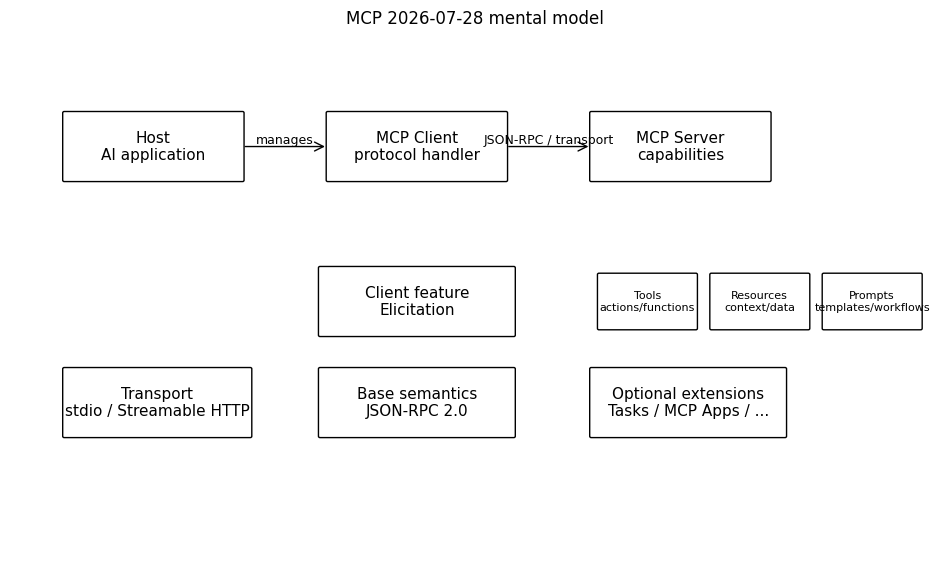

In [2]:
def box(ax, x, y, w, h, text, fontsize=11):
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", fill=False)
    ax.add_patch(p)
    ax.text(x+w/2, y+h/2, text, ha="center", va="center", fontsize=fontsize)
    return p

def arrow(ax, x1, y1, x2, y2, text=None):
    a = FancyArrowPatch((x1,y1),(x2,y2),arrowstyle="->",mutation_scale=16)
    ax.add_patch(a)
    if text:
        ax.text((x1+x2)/2, (y1+y2)/2+0.05, text, ha="center", fontsize=9)

fig, ax = plt.subplots()
ax.set_xlim(0, 12); ax.set_ylim(0, 8); ax.axis("off")
box(ax, 0.7, 5.8, 2.3, 1.0, "Host\nAI application")
box(ax, 4.1, 5.8, 2.3, 1.0, "MCP Client\nprotocol handler")
box(ax, 7.5, 5.8, 2.3, 1.0, "MCP Server\ncapabilities")
arrow(ax, 3.0, 6.3, 4.1, 6.3, "manages")
arrow(ax, 6.4, 6.3, 7.5, 6.3, "JSON-RPC / transport")

for i,(name,desc) in enumerate([
    ("Tools","actions/functions"),
    ("Resources","context/data"),
    ("Prompts","templates/workflows")
]):
    box(ax, 7.6+i*1.45, 3.6, 1.25, 0.8, f"{name}\n{desc}", 8)

box(ax, 4.0, 3.5, 2.5, 1.0, "Client feature\nElicitation")
box(ax, 0.7, 2.0, 2.4, 1.0, "Transport\nstdio / Streamable HTTP")
box(ax, 4.0, 2.0, 2.5, 1.0, "Base semantics\nJSON-RPC 2.0")
box(ax, 7.5, 2.0, 2.5, 1.0, "Optional extensions\nTasks / MCP Apps / ...")
plt.title("MCP 2026-07-28 mental model")
plt.show()

## Memory hooks

- **Model → Tools**
- **Application → Resources**
- **User → Prompts**
- **Request has ID**
- **Notification has no ID**
- **Protocol failure ≠ tool execution failure**
- **Modern request = self-contained stranger; it introduces itself every time**

# 2. Architecture: data layer vs transport layer

Separate these before solving scenarios.

### Data/protocol layer
Deals with:
- JSON-RPC requests, results, errors, notifications
- MCP methods
- `_meta`
- tools/resources/prompts
- MRTR
- result shapes
- pagination
- protocol error codes

### Transport layer
Deals with:
- stdio framing
- HTTP POST
- HTTP status
- SSE response streams
- TLS
- MCP HTTP headers
- OAuth bearer tokens / HTTP authorization boundary

A correct HTTP exchange can still contain an MCP error.
A valid MCP call can still produce a **business/tool failure**.

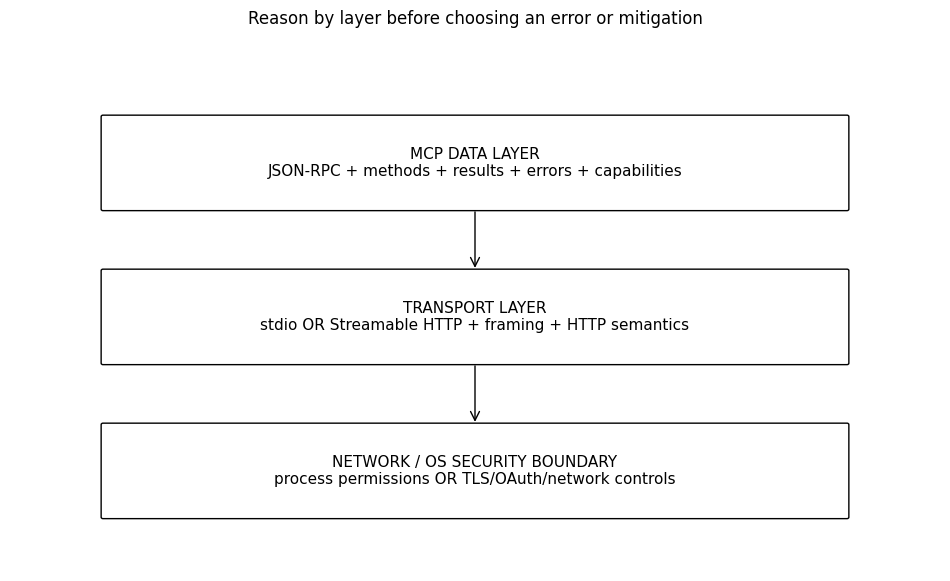

In [3]:
fig, ax = plt.subplots()
ax.set_xlim(0,10); ax.set_ylim(0,7); ax.axis("off")
box(ax, 1, 4.7, 8, 1.2, "MCP DATA LAYER\nJSON-RPC + methods + results + errors + capabilities")
box(ax, 1, 2.7, 8, 1.2, "TRANSPORT LAYER\nstdio OR Streamable HTTP + framing + HTTP semantics")
box(ax, 1, 0.7, 8, 1.2, "NETWORK / OS SECURITY BOUNDARY\nprocess permissions OR TLS/OAuth/network controls")
arrow(ax, 5,4.7,5,3.9)
arrow(ax, 5,2.7,5,1.9)
plt.title("Reason by layer before choosing an error or mitigation")
plt.show()

# 3. JSON-RPC 2.0 anatomy

MCP uses JSON-RPC 2.0 messages.

## Request
- `jsonrpc: "2.0"`
- `id`: request correlation identifier
- `method`: string
- `params`: method parameters

## Response
- same `id`
- exactly one of:
  - `result`
  - `error`

## Notification
- no `id`
- no response expected

MCP imposes stricter ID expectations than casual JSON-RPC implementations: treat request IDs as string/integer, non-null, and unique among outstanding requests.

Core error anchors:
- `-32700` Parse error
- `-32600` Invalid Request
- `-32601` Method not found
- `-32602` Invalid params
- `-32603` Internal error

In [4]:
REQUEST = {
    "jsonrpc": "2.0",
    "id": 42,
    "method": "tools/call",
    "params": {
        "name": "get_weather",
        "arguments": {"city": "Riga"},
        "_meta": {
            "io.modelcontextprotocol/protocolVersion": "2026-07-28",
            "io.modelcontextprotocol/clientCapabilities": {}
        }
    }
}
print(json.dumps(REQUEST, indent=2))

{
  "jsonrpc": "2.0",
  "id": 42,
  "method": "tools/call",
  "params": {
    "name": "get_weather",
    "arguments": {
      "city": "Riga"
    },
    "_meta": {
      "io.modelcontextprotocol/protocolVersion": "2026-07-28",
      "io.modelcontextprotocol/clientCapabilities": {}
    }
  }
}


# 4. Modern stateless lifecycle — what changed

The 2026-07-28 release moved the core away from the old session-oriented lifecycle.

High-value consequences:
- no modern `initialize` handshake before ordinary requests
- no protocol session affinity requirement
- every request carries its own protocol/capability context
- optional `server/discover` lets clients learn supported versions/capabilities up front
- any request can be routed to a compatible server instance
- application state can still exist, but protocol continuation must not depend on hidden transport-session affinity

Release overview:
https://blog.modelcontextprotocol.io/posts/2026-07-28/

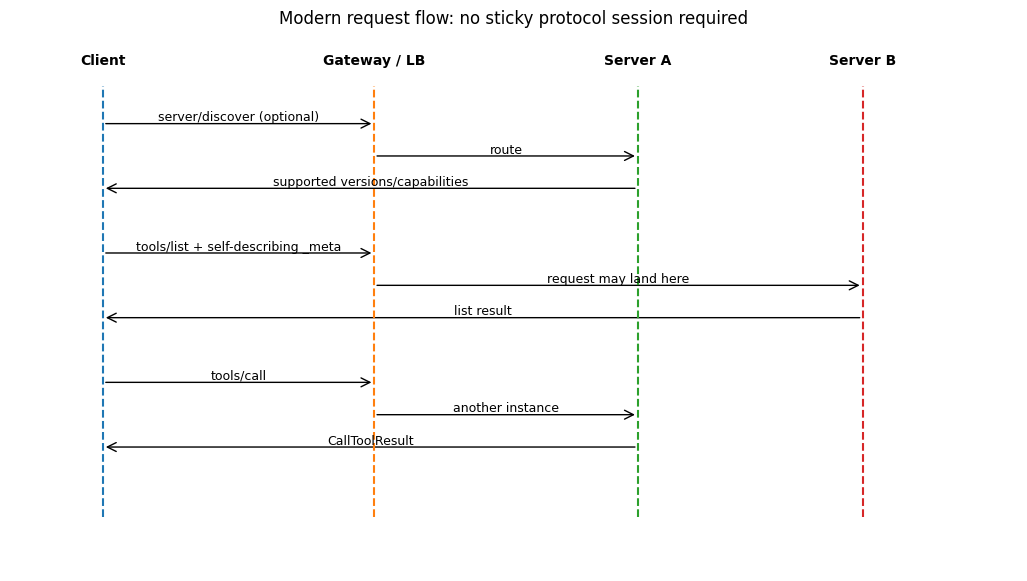

In [5]:
fig, ax = plt.subplots(figsize=(13,7))
ax.set_xlim(0,13); ax.set_ylim(0,10); ax.axis("off")
xC,xLB,xA,xB = 1.2,4.7,8.1,11.0
for x,n in [(xC,"Client"),(xLB,"Gateway / LB"),(xA,"Server A"),(xB,"Server B")]:
    ax.text(x,9.4,n,ha="center",weight="bold")
    ax.plot([x,x],[1,9],linestyle="--")

def msg(y, xa, xb, txt):
    arrow(ax, xa,y,xb,y,txt)

msg(8.3,xC,xLB,"server/discover (optional)")
msg(7.7,xLB,xA,"route")
msg(7.1,xA,xC,"supported versions/capabilities")
msg(5.9,xC,xLB,"tools/list + self-describing _meta")
msg(5.3,xLB,xB,"request may land here")
msg(4.7,xB,xC,"list result")
msg(3.5,xC,xLB,"tools/call")
msg(2.9,xLB,xA,"another instance")
msg(2.3,xA,xC,"CallToolResult")
plt.title("Modern request flow: no sticky protocol session required")
plt.show()

# 5. `server/discover`

Use discovery to learn server support before invoking other operations.

Conceptually it answers:
- which protocol versions are supported?
- what capabilities are available?
- what server information/instructions are advertised?

Important reasoning point:
**Discovery detects compatibility; it does not translate legacy semantics into modern semantics.**

Clients may also encounter version mismatch inline and react accordingly.

Certification trap:
Do not mentally reinsert the legacy `initialize → initialized` handshake into a 2026-07-28-only scenario.

# 6. Universal MCP operation decision tree

Use this order when reading scenario questions:

1. Is the JSON parseable?
2. Is it a valid JSON-RPC request?
3. Does the method exist?
4. Are required params / metadata structurally valid?
5. Are required capabilities declared?
6. Does the HTTP/auth boundary allow the request?
7. Does the MCP operation execute?
8. If it is a tool call, did the tool/business operation succeed?

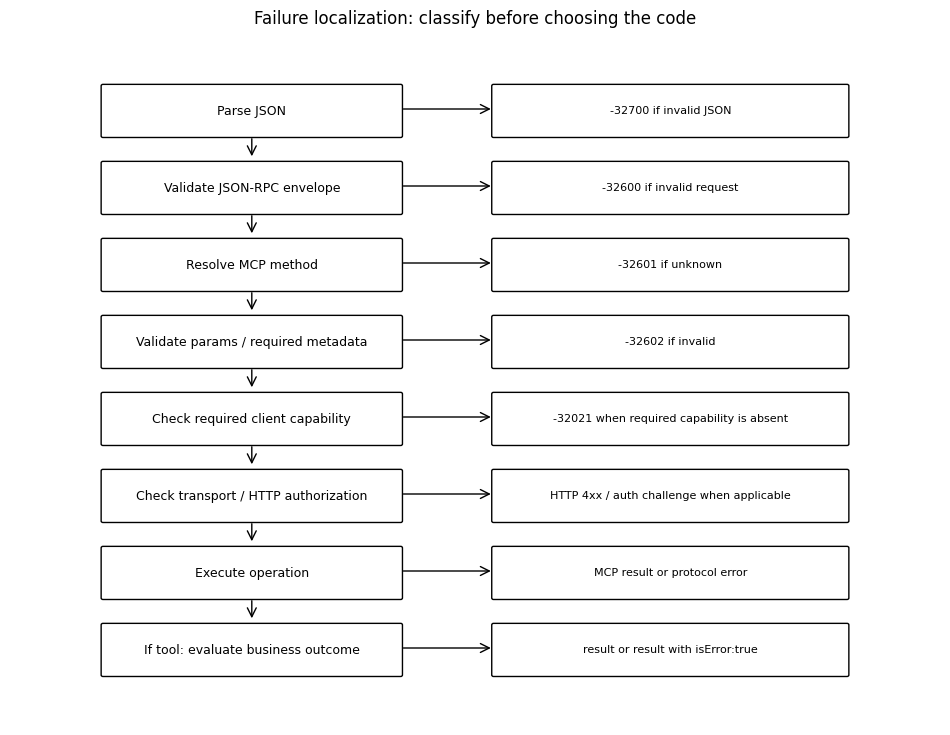

In [6]:
from matplotlib.patches import Rectangle

steps = [
    ("Parse JSON", "-32700 if invalid JSON"),
    ("Validate JSON-RPC envelope", "-32600 if invalid request"),
    ("Resolve MCP method", "-32601 if unknown"),
    ("Validate params / required metadata", "-32602 if invalid"),
    ("Check required client capability", "-32021 when required capability is absent"),
    ("Check transport / HTTP authorization", "HTTP 4xx / auth challenge when applicable"),
    ("Execute operation", "MCP result or protocol error"),
    ("If tool: evaluate business outcome", "result or result with isError:true"),
]
fig, ax = plt.subplots(figsize=(12,9))
ax.set_xlim(0,10); ax.set_ylim(0,len(steps)+1); ax.axis("off")
for i,(a,b) in enumerate(steps):
    y=len(steps)-i
    box(ax,1.0,y-0.35,3.2,0.65,a,9)
    box(ax,5.2,y-0.35,3.8,0.65,b,8)
    arrow(ax,4.2,y,5.2,y)
    if i < len(steps)-1:
        arrow(ax,2.6,y-0.35,2.6,y-1+0.35)
plt.title("Failure localization: classify before choosing the code")
plt.show()

# 7. The highest-value distinction: protocol error vs tool execution error

## Protocol error
The MCP server cannot validly perform the requested MCP operation.

Examples:
- malformed params
- unknown MCP method
- tool name cannot be resolved as a valid tool call
- required request metadata is invalid

Shape:
```json
{
  "jsonrpc": "2.0",
  "id": 7,
  "error": {
    "code": -32602,
    "message": "Invalid params"
  }
}
```

## Tool execution error
The `tools/call` itself was valid and the tool ran, but the underlying operation failed.

Shape:
```json
{
  "jsonrpc": "2.0",
  "id": 7,
  "result": {
    "resultType": "complete",
    "content": [{"type": "text", "text": "Customer does not exist"}],
    "isError": true
  }
}
```

**Exam heuristic:** ask *“Did the protocol reach the tool?”*

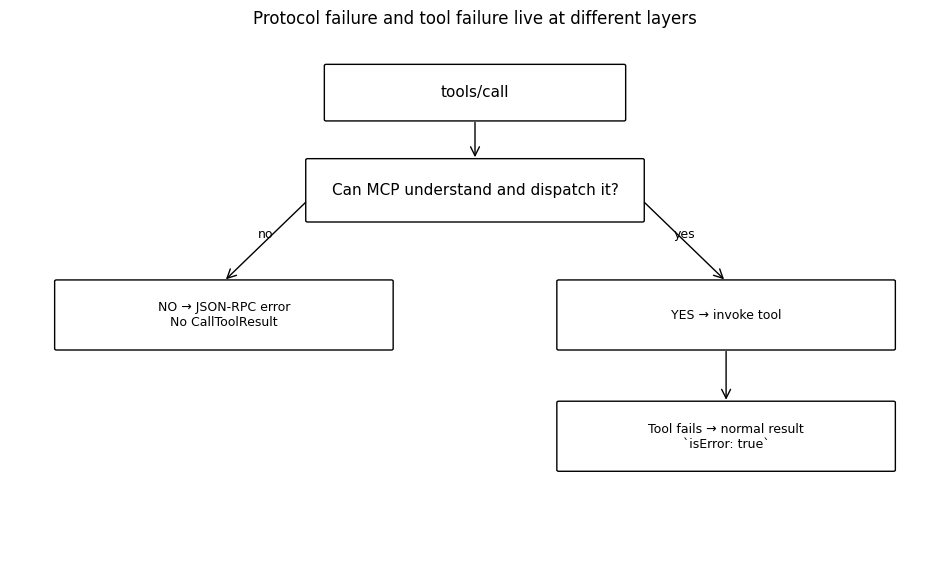

In [7]:
fig, ax = plt.subplots()
ax.set_xlim(0,10); ax.set_ylim(0,8); ax.axis("off")
box(ax,3.4,6.7,3.2,0.8,"tools/call")
box(ax,3.2,5.2,3.6,0.9,"Can MCP understand and dispatch it?")
arrow(ax,5,6.7,5,6.1)

box(ax,0.5,3.3,3.6,1.0,"NO → JSON-RPC error\nNo CallToolResult",9)
box(ax,5.9,3.3,3.6,1.0,"YES → invoke tool",9)
arrow(ax,3.2,5.5,2.3,4.3,"no")
arrow(ax,6.8,5.5,7.7,4.3,"yes")

box(ax,5.9,1.5,3.6,1.0,"Tool fails → normal result\n`isError: true`",9)
arrow(ax,7.7,3.3,7.7,2.5)
plt.title("Protocol failure and tool failure live at different layers")
plt.show()

# 8. Missing parameter cases — do not collapse them

“Missing parameter” can describe several different defects.

### Case A — structurally required property is absent
Example schema requires `city`, but `arguments` is `{}`.

This is a schema / MCP parameter validation problem.

### Case B — structurally valid value is semantically bad
`city = "Atlantis"` is a valid string, but the downstream weather provider has no such city.

The tool may execute and return `isError: true`.

### Case C — more user/client input is genuinely needed to continue
The server returns an **MRTR `input_required` result** on a method where MRTR is allowed.

The client gathers the requested input and retries the original operation.

In [8]:
cases = [
    ("arguments={}", "schema says city required", "protocol/validation failure"),
    ('city="Atlantis"', "schema valid, business lookup fails", "tool result + isError:true"),
    ("needs confirmation", "server can continue after input", "MRTR input_required"),
]
for title, reason, outcome in cases:
    print(f"{title:22} -> {reason:38} -> {outcome}")

arguments={}           -> schema says city required              -> protocol/validation failure
city="Atlantis"        -> schema valid, business lookup fails    -> tool result + isError:true
needs confirmation     -> server can continue after input        -> MRTR input_required


# 9. MRTR — Multi Round-Trip Requests

MRTR replaces the old mental model of a server freely initiating back-channel JSON-RPC requests in the middle of an operation.

Core flow:

1. Client sends an eligible request.
2. Server cannot finish yet.
3. Server returns `resultType: "input_required"`.
4. Result contains `inputRequests` and/or opaque `requestState`.
5. Client gathers answers.
6. Client **reissues the original operation as a new JSON-RPC request with a new ID**.
7. It includes `inputResponses` and echoes `requestState` exactly if supplied.
8. Server continues and eventually returns a completed result.

High-value scope rule:
MRTR `InputRequiredResult` is associated with:
- `tools/call`
- `resources/read`
- `prompts/get`

Spec page:
https://modelcontextprotocol.io/specification/2026-07-28/basic/patterns/mrtr

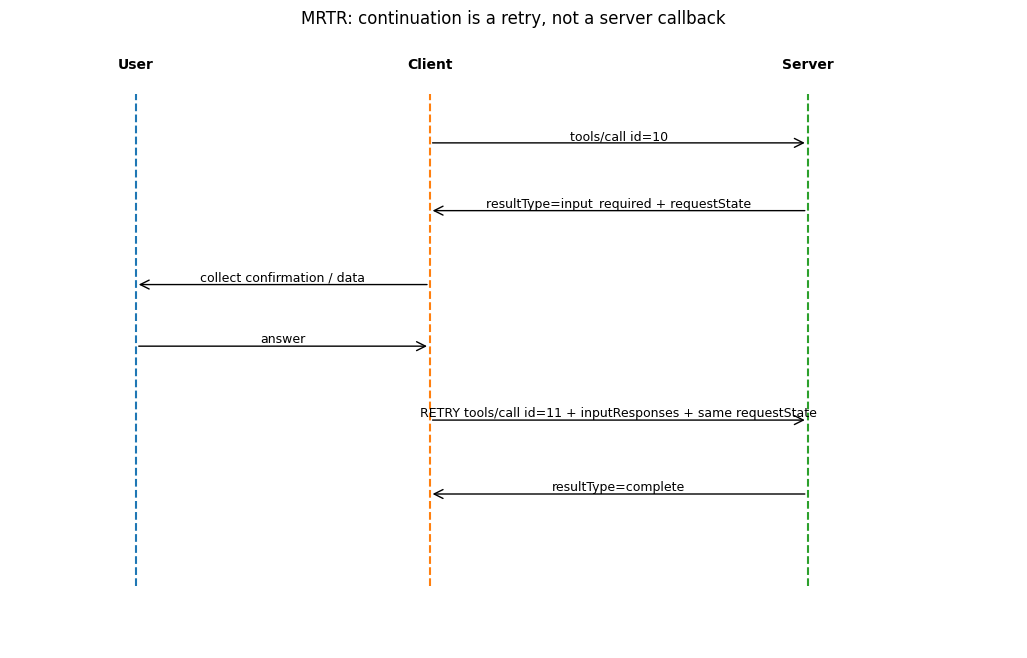

In [9]:
fig, ax = plt.subplots(figsize=(13,8))
ax.set_xlim(0,12); ax.set_ylim(0,10); ax.axis("off")
xs = {"User":1.5, "Client":5, "Server":9.5}
for n,x in xs.items():
    ax.text(x,9.4,n,ha="center",weight="bold")
    ax.plot([x,x],[1,9],linestyle="--")

def seq(y,a,b,t):
    arrow(ax,xs[a],y,xs[b],y,t)

seq(8.2,"Client","Server","tools/call id=10")
seq(7.1,"Server","Client","resultType=input_required + requestState")
seq(5.9,"Client","User","collect confirmation / data")
seq(4.9,"User","Client","answer")
seq(3.7,"Client","Server","RETRY tools/call id=11 + inputResponses + same requestState")
seq(2.5,"Server","Client","resultType=complete")
plt.title("MRTR: continuation is a retry, not a server callback")
plt.show()

## `requestState`: the sealed claim-ticket mental model

Client behavior:
- treat it as opaque
- echo exactly
- do not parse/modify
- do not reuse for another logical request

Server security reasoning:
- it crossed an untrusted boundary
- if it influences authorization or business logic, integrity/replay controls are necessary
- statelessness does **not** mean “trust whatever state blob comes back”

# 10. Tools

Tools are executable functions/actions exposed by a server.

Key operations:
- `tools/list`
- `tools/call`

Typical definition includes:
- `name`
- optional human-readable metadata such as title/description
- `inputSchema`
- optional `outputSchema`

2026-07-28 supports modern JSON Schema capabilities for tool schemas.

Important:
**Tool execution failure is represented in the tool result (`isError: true`) when the MCP call itself was valid.**

In [10]:
tool_definition = {
    "name": "create_ticket",
    "description": "Create a support ticket",
    "inputSchema": {
        "type": "object",
        "properties": {
            "title": {"type": "string"},
            "severity": {"type": "integer", "minimum": 1, "maximum": 5}
        },
        "required": ["title"]
    }
}
print(json.dumps(tool_definition, indent=2))

{
  "name": "create_ticket",
  "description": "Create a support ticket",
  "inputSchema": {
    "type": "object",
    "properties": {
      "title": {
        "type": "string"
      },
      "severity": {
        "type": "integer",
        "minimum": 1,
        "maximum": 5
      }
    },
    "required": [
      "title"
    ]
  }
}


# 11. Resources

Resources are server-provided context/data.

Typical operations:
- `resources/list`
- `resources/templates/list`
- `resources/read`

Think:
- tools = **do**
- resources = **read**
- prompts = **prepare interaction**

Modern change worth remembering:
missing/invalid resource targets are handled through modern invalid-parameter semantics rather than memorizing the old legacy resource-specific error as the modern answer.

# 12. Prompts

Prompts are reusable interaction templates.

Typical operations:
- `prompts/list`
- `prompts/get`

Reasoning:
- tool = function/action
- resource = data
- prompt = reusable message/workflow template

Do not answer a prompt question as if prompts are automatically model-selected tools.

# 13. Pagination

List operations may return an opaque continuation cursor.

Client loop:

1. issue list request
2. read items
3. if `nextCursor` exists:
   - call same list operation with cursor
4. stop when there is no next cursor

Rule:
**Cursor is opaque. Do not parse, increment, concatenate, or manufacture it.**

In [11]:
def consume_pages(fetch_page):
    cursor = None
    all_items = []
    while True:
        page = fetch_page(cursor)
        all_items.extend(page["items"])
        cursor = page.get("nextCursor")
        if not cursor:
            return all_items

# 14. Caching and invalidation

The 2026-07-28 release introduced cache hints for key list/read operations and deterministic ordering.

Study the interaction, not just the fields:

- server returns cacheability metadata such as `ttlMs` and `cacheScope`
- client may reuse a fresh cached response
- a relevant `list_changed` event can invalidate the logical freshness assumption
- deterministic ordering helps preserve upstream prompt-cache stability

Release overview explicitly calls out cacheable:
- `tools/list`
- `prompts/list`
- `resources/list`
- `resources/read`

Do not infer extra cacheable methods without checking their normative page/schema.

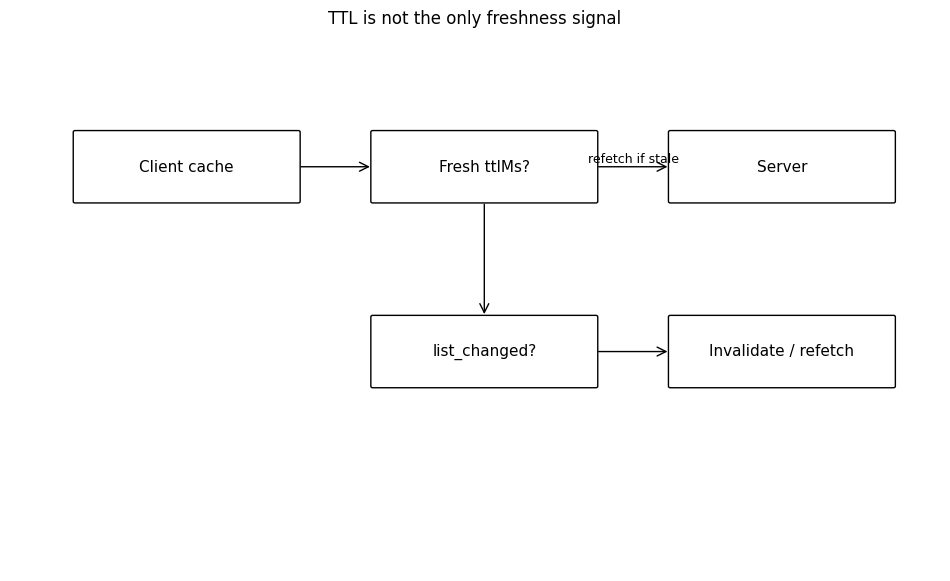

In [12]:
fig, ax = plt.subplots()
ax.set_xlim(0,10); ax.set_ylim(0,7); ax.axis("off")
box(ax,0.7,4.8,2.4,0.9,"Client cache")
box(ax,3.9,4.8,2.4,0.9,"Fresh ttlMs?")
box(ax,7.1,4.8,2.4,0.9,"Server")
arrow(ax,3.1,5.25,3.9,5.25)
arrow(ax,6.3,5.25,7.1,5.25,"refetch if stale")
box(ax,3.9,2.4,2.4,0.9,"list_changed?")
arrow(ax,5.1,4.8,5.1,3.3)
box(ax,7.1,2.4,2.4,0.9,"Invalidate / refetch")
arrow(ax,6.3,2.85,7.1,2.85)
plt.title("TTL is not the only freshness signal")
plt.show()

# 15. stdio transport

Use stdio for local subprocess-style integrations.

Mental model:
- client launches server process
- JSON-RPC travels over stdin/stdout
- stdout is protocol framing
- logs belong on stderr

Classic failure:
`print("Server starting")` to stdout can corrupt the JSON-RPC stream.

Also:
- stdio is not a TCP port
- relative paths can fail when the host launches the server from a different working directory

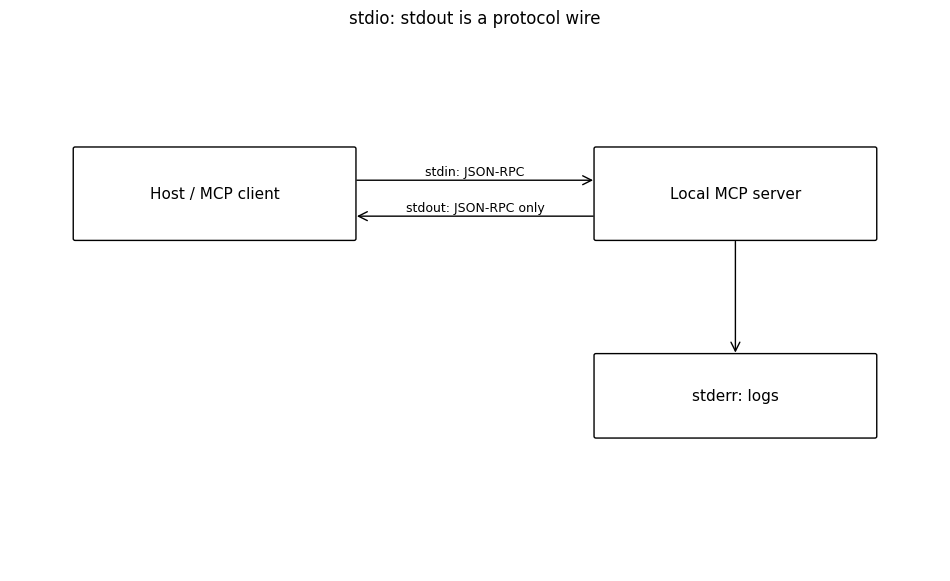

In [13]:
fig, ax = plt.subplots()
ax.set_xlim(0,10); ax.set_ylim(0,6); ax.axis("off")
box(ax,0.7,3.7,3.0,1.0,"Host / MCP client")
box(ax,6.3,3.7,3.0,1.0,"Local MCP server")
arrow(ax,3.7,4.35,6.3,4.35,"stdin: JSON-RPC")
arrow(ax,6.3,3.95,3.7,3.95,"stdout: JSON-RPC only")
box(ax,6.3,1.5,3.0,0.9,"stderr: logs")
arrow(ax,7.8,3.7,7.8,2.4)
plt.title("stdio: stdout is a protocol wire")
plt.show()

# 16. Streamable HTTP

Modern remote transport reasoning:

- client sends JSON-RPC using HTTP POST
- response may be a normal JSON payload or a per-request SSE stream
- authorization lives at the HTTP boundary
- the 2026-07-28 model removes the old session-affinity/resume assumptions
- broken request streams are not a reason to resurrect legacy `Last-Event-ID` logic

Separate:
**HTTP status / headers** from **JSON-RPC result/error**.

# 17. MCP routing headers

2026-07-28 introduces header mirroring so gateways can route/authorize/rate-limit without parsing the JSON body.

High-value names:
- `MCP-Protocol-Version`
- `Mcp-Method`
- `Mcp-Name` for target-bearing operations
- `Mcp-Param-*` for selected tool arguments

Mismatch between required mirrored headers and body can produce:
- HTTP 400
- JSON-RPC `-32020` (`HeaderMismatch`)

Official SDK migration guidance:
https://ts.sdk.modelcontextprotocol.io/v2/migration/support-2026-07-28

In [14]:
http_example = '''POST /mcp HTTP/1.1
Content-Type: application/json
MCP-Protocol-Version: 2026-07-28
Mcp-Method: tools/call
Mcp-Name: create_ticket

{"jsonrpc":"2.0","id":8,"method":"tools/call","params":{"name":"create_ticket", ...}}
'''
print(http_example)

POST /mcp HTTP/1.1
Content-Type: application/json
MCP-Protocol-Version: 2026-07-28
Mcp-Method: tools/call
Mcp-Name: create_ticket

{"jsonrpc":"2.0","id":8,"method":"tools/call","params":{"name":"create_ticket", ...}}



# 18. `x-mcp-header` / `Mcp-Param-*`

A tool schema may mark selected primitive arguments for HTTP-header mirroring.

Why:
- gateway routing
- rate limiting
- policy checks
- traffic shaping without JSON-body inspection

Security:
- do not put secrets/PII into routinely exposed intermediary-visible headers
- the server validates header/body consistency before dispatch

## Fact-check correction from the uploaded cheat sheet

The uploaded cheat sheet says JSON Schema `number` is explicitly excluded for `x-mcp-header`.
Current MCP tools documentation says the allowed primitive types include:
- `number`
- `string`
- `boolean`

Therefore **do not memorize “number is excluded.”**

Current documentation reference:
https://modelcontextprotocol.io/specification/draft/server/tools

# 19. Notification header caveat — another fact-check correction

The uploaded notes state that `Mcp-Method` is required on **every request AND notification**.

Current 2026-07-28 SDK/spec-aligned Streamable HTTP guidance is more nuanced:
- standard header presence is required for modern **request POSTs**
- notification POSTs are exempt from the presence requirement because this revision defines no client-to-server notifications over Streamable HTTP in that binding

So do not use the blanket phrase “every notification must have Mcp-Method” as a certification invariant unless the exact normative page says so for the scenario.

Reference:
https://ts.sdk.modelcontextprotocol.io/v2/migration/support-2026-07-28

# 20. Header mismatch decision tree

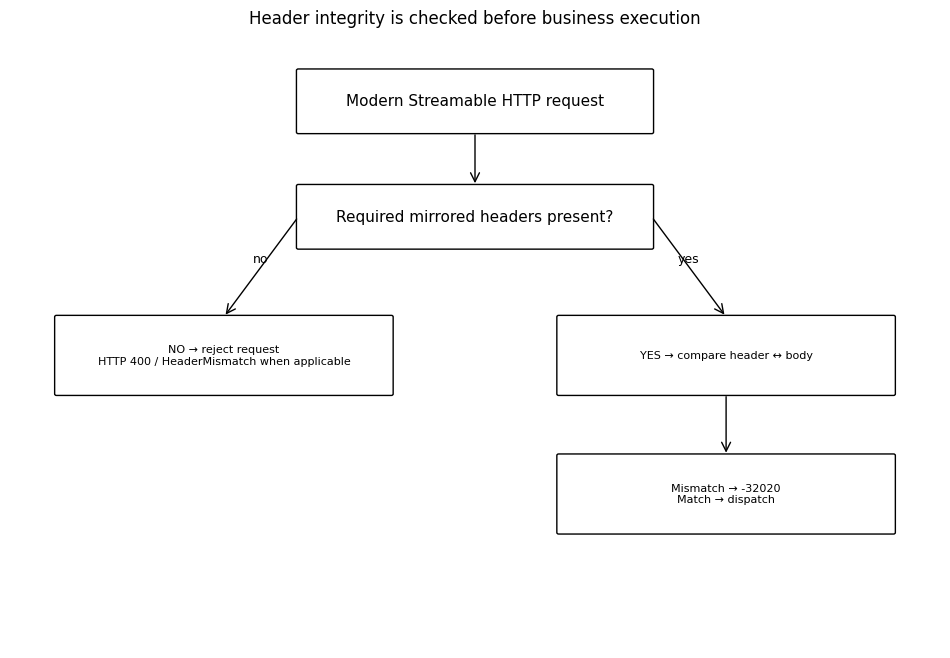

In [15]:
fig, ax = plt.subplots(figsize=(12,8))
ax.set_xlim(0,10); ax.set_ylim(0,8); ax.axis("off")
box(ax,3.1,6.7,3.8,0.8,"Modern Streamable HTTP request")
box(ax,3.1,5.2,3.8,0.8,"Required mirrored headers present?")
arrow(ax,5,6.7,5,6.0)
box(ax,0.5,3.3,3.6,1.0,"NO → reject request\nHTTP 400 / HeaderMismatch when applicable",8)
box(ax,5.9,3.3,3.6,1.0,"YES → compare header ↔ body",8)
arrow(ax,3.1,5.6,2.3,4.3,"no")
arrow(ax,6.9,5.6,7.7,4.3,"yes")
box(ax,5.9,1.5,3.6,1.0,"Mismatch → -32020\nMatch → dispatch",8)
arrow(ax,7.7,3.3,7.7,2.5)
plt.title("Header integrity is checked before business execution")
plt.show()

# 21. Authorization: keep HTTP auth separate from MCP semantics

Typical remote OAuth flow:

1. client requests protected MCP server
2. server returns 401 + `WWW-Authenticate`
3. client obtains Protected Resource Metadata
4. client discovers authorization server metadata
5. client registration / metadata path
6. user authorization + PKCE
7. authorization code exchange
8. client retries with bearer token
9. resource server validates token and authorizes request

High-value HTTP distinctions:
- **401**: missing/invalid/expired authentication → authenticate/re-authenticate
- **403**: identity is known but scope/permission is insufficient
- **400**: malformed/integrity problem, such as protocol header mismatch

Authorization spec:
https://modelcontextprotocol.io/specification/2026-07-28/basic/authorization

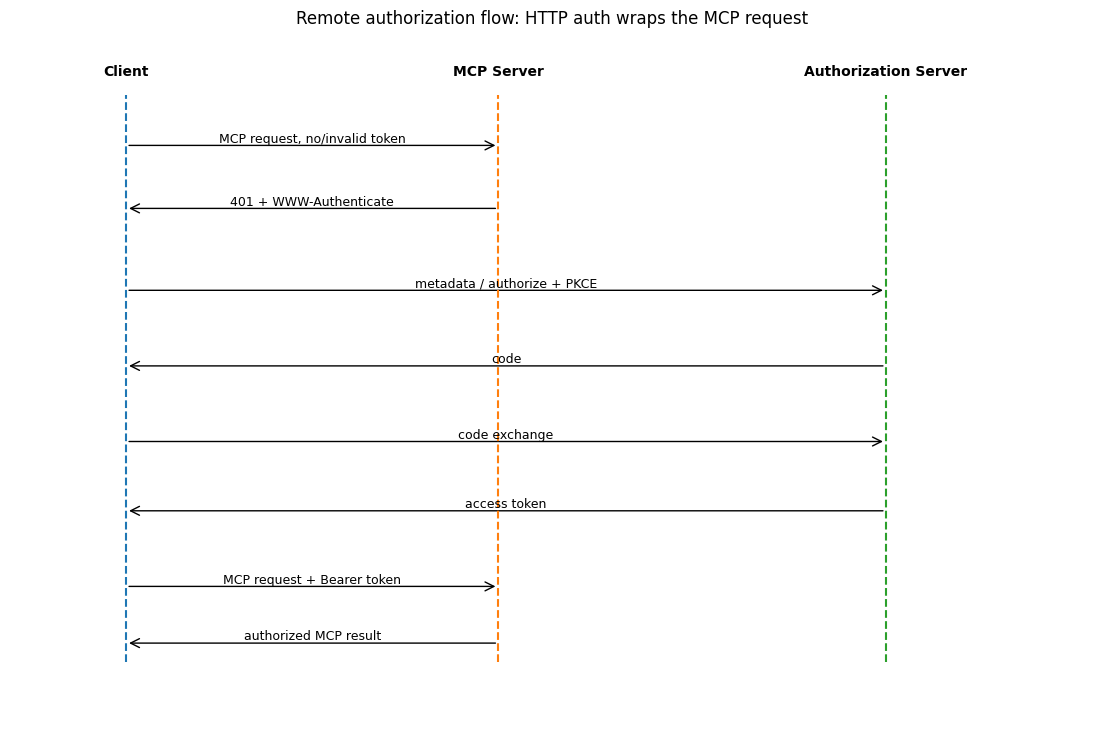

In [16]:
fig, ax = plt.subplots(figsize=(14,9))
ax.set_xlim(0,14); ax.set_ylim(0,11); ax.axis("off")
xs={"Client":1.5,"MCP Server":6.3,"Authorization Server":11.3}
for n,x in xs.items():
    ax.text(x,10.3,n,ha="center",weight="bold")
    ax.plot([x,x],[1,10],linestyle="--")
def s(y,a,b,t): arrow(ax,xs[a],y,xs[b],y,t)
s(9.2,"Client","MCP Server","MCP request, no/invalid token")
s(8.2,"MCP Server","Client","401 + WWW-Authenticate")
s(6.9,"Client","Authorization Server","metadata / authorize + PKCE")
s(5.7,"Authorization Server","Client","code")
s(4.5,"Client","Authorization Server","code exchange")
s(3.4,"Authorization Server","Client","access token")
s(2.2,"Client","MCP Server","MCP request + Bearer token")
s(1.3,"MCP Server","Client","authorized MCP result")
plt.title("Remote authorization flow: HTTP auth wraps the MCP request")
plt.show()

# 22. Token validation and token passthrough

Do not reason “the token verifies, therefore accept.”

Resource server validation must consider claims relevant to the server, especially:
- signature
- expiration
- issuer
- audience

Key exam trap:
A token minted for **Server B** is not automatically valid at **Server A**.

Token passthrough / cross-audience acceptance breaks the resource-server security boundary.

# 23. OAuth / metadata SSRF reasoning

Authorization discovery may cause network fetches to URLs influenced by external input.

Threat model:
- malicious metadata URL
- redirect to internal address
- cloud metadata endpoint
- DNS rebinding
- alternate IP encodings
- IPv6 / mapped address tricks

Certification reasoning:
**metadata discovery is still network access across a trust boundary.**

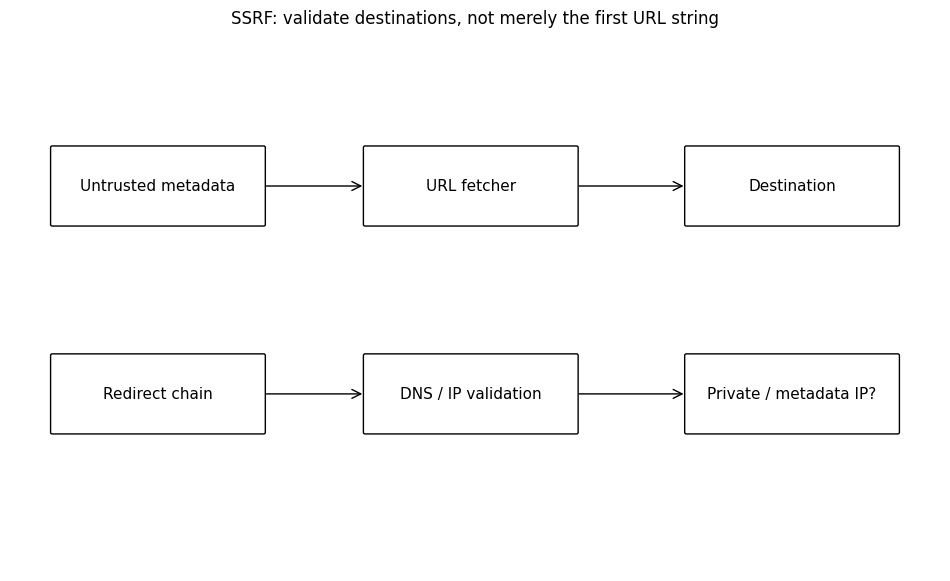

In [17]:
fig, ax = plt.subplots()
ax.set_xlim(0,11); ax.set_ylim(0,7); ax.axis("off")
box(ax,0.5,4.5,2.5,1.0,"Untrusted metadata")
box(ax,4.2,4.5,2.5,1.0,"URL fetcher")
box(ax,8.0,4.5,2.5,1.0,"Destination")
arrow(ax,3.0,5.0,4.2,5.0)
arrow(ax,6.7,5.0,8.0,5.0)
box(ax,0.5,1.8,2.5,1.0,"Redirect chain")
box(ax,4.2,1.8,2.5,1.0,"DNS / IP validation")
box(ax,8.0,1.8,2.5,1.0,"Private / metadata IP?")
arrow(ax,3.0,2.3,4.2,2.3)
arrow(ax,6.7,2.3,8.0,2.3)
plt.title("SSRF: validate destinations, not merely the first URL string")
plt.show()

# 24. Subscriptions

2026-07-28 introduces `subscriptions/listen` for opt-in long-lived change notification delivery.

Reasoning:
- client opens a listen request
- server acknowledges honored notification categories
- server streams matching notifications
- delivery is best-effort; do not assume replay
- abrupt loss means the client must reason about re-listening/refetching
- graceful close produces a final empty result before stream closure

Typical change categories include list changes and resource subscriptions.

Official SDK documentation:
https://py.sdk.modelcontextprotocol.io/v2/api/mcp/client/subscriptions/

# 25. Cancellation and timeout

Cancellation is a control signal, not proof that the underlying work instantly stopped.

Reasoning:
- requester may stop waiting
- requester may issue cancellation
- implementation should bound waiting with timeouts
- cancellation is generally cooperative
- do not equate “local timeout fired” with “server returned a particular JSON-RPC error”

This distinction also appears in Tasks: task cancellation intent does not guarantee terminal status will be `cancelled`.

# 26. Progress

Progress is associated with long-running request handling.

Study the correlation boundary:
- progress belongs to a request's execution
- it does not redefine JSON-RPC response semantics
- receiving progress should not create an infinite timeout extension policy

Certification question pattern:
“progress is being emitted, so should the client wait forever?” → **No.**

# 27. Completion

Completion provides suggestions while a client is filling prompt/resource-related arguments.

Typical operation:
- `completion/complete`

Failure reasoning:
- unsupported method → method-not-found semantics
- malformed reference/arguments → invalid params
- server failure → internal error

Security angle:
completion can accidentally disclose data through suggestions, so implementations should validate inputs and constrain disclosure.

# 28. Tasks extension — long-running durable work

Tasks are **not ordinary core lifecycle**; they are an optional extension.

Current Tasks extension:
- server may answer supported execution with `resultType: "task"`
- client receives a task handle / task ID
- `tasks/get` reads state
- `tasks/update` supplies mid-flight input
- `tasks/cancel` requests cancellation
- no `tasks/list`
- task creation is server-directed after client advertises extension support

Tasks extension:
https://tasks.extensions.modelcontextprotocol.io/specification/draft/tasks

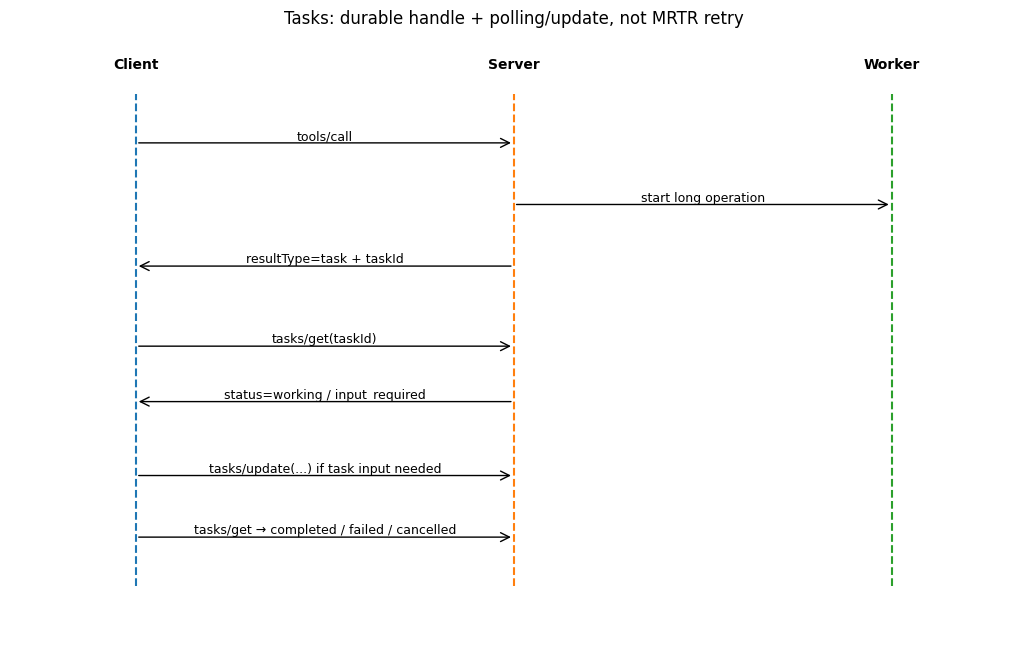

In [18]:
fig, ax = plt.subplots(figsize=(13,8))
ax.set_xlim(0,12); ax.set_ylim(0,10); ax.axis("off")
xs={"Client":1.5,"Server":6,"Worker":10.5}
for n,x in xs.items():
    ax.text(x,9.4,n,ha="center",weight="bold")
    ax.plot([x,x],[1,9],linestyle="--")
def q(y,a,b,t): arrow(ax,xs[a],y,xs[b],y,t)
q(8.2,"Client","Server","tools/call")
q(7.2,"Server","Worker","start long operation")
q(6.2,"Server","Client","resultType=task + taskId")
q(4.9,"Client","Server","tasks/get(taskId)")
q(4.0,"Server","Client","status=working / input_required")
q(2.8,"Client","Server","tasks/update(...) if task input needed")
q(1.8,"Client","Server","tasks/get → completed / failed / cancelled")
plt.title("Tasks: durable handle + polling/update, not MRTR retry")
plt.show()

# 29. MRTR vs Tasks — exam trap table

| Question | Core MRTR | Tasks extension |
|---|---|---|
| Continuation identity | opaque `requestState` if provided | `taskId` |
| Input mechanism | retry original request | `tasks/update` |
| JSON-RPC ID | retry uses a new ID | each task operation has its own request ID |
| Long-running durable state | not the main purpose | yes |
| Polling | not the core continuation model | `tasks/get` |
| Extension required | no, core pattern | yes |

# 30. Error-code map

Use categories rather than memorizing numbers in isolation.

## JSON-RPC core
- `-32700` Parse error
- `-32600` Invalid Request
- `-32601` Method not found
- `-32602` Invalid params
- `-32603` Internal error

## Modern MCP-specific anchors
- `-32020` HeaderMismatch
- `-32021` MissingRequiredClientCapability
- `-32022` UnsupportedProtocolVersion

The uploaded material also lists `-32001` as InvalidProtocolVersion. Treat MCP-specific code questions as revision-sensitive: confirm against the exact 2026-07-28 schema/spec page used by the exam.

Memory hook:
**20 / 21 / 22 = Header / Capability / Version**

In [19]:
errors = {
    -32700: "Parse error",
    -32600: "Invalid Request",
    -32601: "Method not found",
    -32602: "Invalid params",
    -32603: "Internal error",
    -32020: "HeaderMismatch",
    -32021: "MissingRequiredClientCapability",
    -32022: "UnsupportedProtocolVersion",
}
for k,v in errors.items():
    print(f"{k:>7}: {v}")

 -32700: Parse error
 -32600: Invalid Request
 -32601: Method not found
 -32602: Invalid params
 -32603: Internal error
 -32020: HeaderMismatch
 -32021: MissingRequiredClientCapability
 -32022: UnsupportedProtocolVersion


# 31. Malformed metadata vs missing capability

This is a subtle, high-value distinction.

### Missing required request metadata
The request is structurally malformed / invalid.

Think:
**the envelope itself is wrong**

### Capability metadata exists, but the needed capability is not declared
The request is structurally valid but incompatible with what the server needs.

Think:
**valid envelope, insufficient declared capability**

Do not collapse both into “client doesn't support it.”

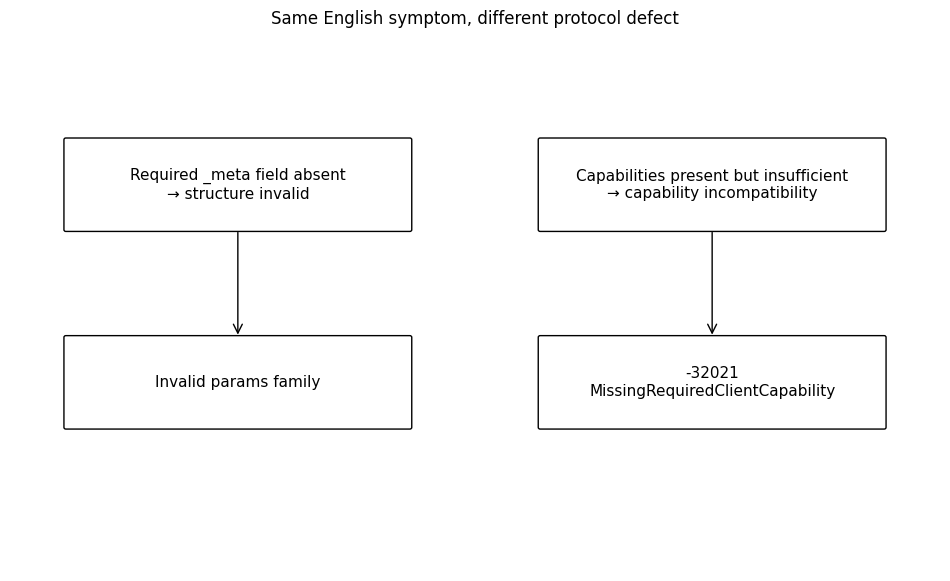

In [20]:
fig, ax = plt.subplots()
ax.set_xlim(0,10); ax.set_ylim(0,6); ax.axis("off")
box(ax,0.6,3.8,3.7,1.0,"Required _meta field absent\n→ structure invalid")
box(ax,5.7,3.8,3.7,1.0,"Capabilities present but insufficient\n→ capability incompatibility")
box(ax,0.6,1.6,3.7,1.0,"Invalid params family")
box(ax,5.7,1.6,3.7,1.0,"-32021\nMissingRequiredClientCapability")
arrow(ax,2.45,3.8,2.45,2.6)
arrow(ax,7.55,3.8,7.55,2.6)
plt.title("Same English symptom, different protocol defect")
plt.show()

# 32. Legacy vs modern

Always identify the protocol era before answering.

### Legacy-era instincts that can be wrong in a 2026-07-28 question
- `initialize` handshake
- `notifications/initialized`
- protocol session ID / sticky routing assumptions
- standalone legacy GET/SSE patterns
- SSE resume via `Last-Event-ID`
- legacy Tasks core surface

### Modern 2026-07-28 instincts
- stateless/self-contained requests
- per-request capability information
- optional `server/discover`
- MRTR continuation
- header routing
- cache hints
- extensions framework

**Deprecated ≠ removed.**
A deprecated feature may still function during its migration window.

# 33. Deprecation highlights

The 2026-07-28 release explicitly deprecates:
- Roots
- Sampling
- Logging
- legacy HTTP+SSE transport

The release establishes a minimum deprecation window rather than treating “deprecated” as “immediately gone.”

Do not answer “deprecated means forbidden/unavailable.”

# 34. Human consent and trust

Protocol correctness does not equal product safety.

Core security principles in the official overview include:
- user consent and control
- data privacy
- tool safety

Tool descriptions/annotations should not automatically be treated as trusted merely because they came through MCP.

Ask:
- what is the user authorizing?
- can the user see what action will occur?
- is consent narrow enough?
- is sensitive data crossing to a server?
- is an external command / URL being executed or opened safely?

# 35. Real use case A — CRM assistant

Scenario:
A sales assistant can:
- read account data as resources
- call `create_opportunity` as a tool
- use a prompt for a standardized deal-review workflow

Potential failures:
- missing required tool argument → protocol/validation problem
- customer ID valid shape but absent → tool execution error
- user approval needed before creation → MRTR elicitation/input-required flow
- downstream creation takes minutes → Tasks may be appropriate if extension is negotiated
- OAuth token lacks write scope → HTTP 403 / scope handling, not JSON-RPC invalid params

# 36. Real use case B — filesystem / code assistant

Local stdio server exposes:
- file resources
- search tools
- edit tools

Failure cases:
- accidental stdout logging corrupts protocol
- relative executable/path works in shell but fails from host
- file URI missing → resource read invalid target
- edit tool called with missing path → invalid params
- edit reaches filesystem but OS denies permission → tool execution failure
- destructive edit without user visibility/consent → product security problem even if protocol is valid

# 37. Real use case C — remote ticketing service behind a gateway

Architecture:
Host → MCP client → API gateway/WAF → MCP server → ticketing API

2026 benefits:
- stateless requests allow ordinary horizontal load balancing
- `Mcp-Method` / `Mcp-Name` enable gateway routing/policy
- selected `Mcp-Param-*` values can support traffic policy

Failure cases:
- header says `tools/call`, body says another method → HeaderMismatch
- bearer token absent → 401
- token valid but lacks ticket-write scope → 403
- ticket schema invalid → invalid params
- ticket API rejects business rule → `isError:true`

# 38. Failure-injection matrix

Use this as a testing checklist.

In [21]:
import pandas as pd

matrix = pd.DataFrame([
    ["JSON", "truncate body", "parse error", "-32700"],
    ["JSON-RPC", "omit method / invalid envelope", "invalid request", "-32600"],
    ["Method", "unknown MCP method", "method not found", "-32601"],
    ["Params", "missing required argument", "invalid params", "-32602"],
    ["Capability", "needed client capability undeclared", "capability error", "-32021"],
    ["HTTP header", "Mcp-Method/body mismatch", "400 + HeaderMismatch", "-32020"],
    ["Auth", "no/expired token", "401 challenge", "HTTP 401"],
    ["AuthZ", "valid token, insufficient scope", "step-up / denied", "HTTP 403"],
    ["Tool business", "downstream rejects operation", "tool error result", "isError:true"],
    ["stdio", "log to stdout", "framing/parse failure", "transport symptom"],
    ["MRTR", "retry with old ID", "protocol/client bug", "new ID required"],
    ["Tasks", "retry original call for task input", "wrong continuation", "use tasks/update"],
], columns=["Layer","Injected fault","Expected classification","Anchor"])
matrix

,Layer,Injected fault,Expected classification,Anchor
0,JSON,truncate body,parse error,-32700
1,JSON-RPC,omit method / invalid envelope,invalid request,-32600
2,Method,unknown MCP method,method not found,-32601
3,Params,missing required argument,invalid params,-32602
4,Capability,needed client capability undeclared,capability error,-32021
5,HTTP header,Mcp-Method/body mismatch,400 + HeaderMismatch,-32020
6,Auth,no/expired token,401 challenge,HTTP 401
7,AuthZ,"valid token, insufficient scope",step-up / denied,HTTP 403
8,Tool business,downstream rejects operation,tool error result,isError:true
9,stdio,log to stdout,framing/parse failure,transport symptom


# 39. Scenario-solving algorithm

When a certification scenario feels dense, run this sequence:

1. **Actor** — host, client, server, gateway, auth server, user, model?
2. **Operation** — tool, resource, prompt, completion, subscription, task, auth?
3. **Era** — modern 2026-07-28, legacy, or extension?
4. **Layer** — transport/HTTP or MCP/JSON-RPC?
5. **Envelope** — valid JSON? valid JSON-RPC? required params/meta?
6. **Capability** — required feature declared?
7. **Auth** — authenticated and authorized for this resource?
8. **Dispatch** — did the tool/resource/prompt operation actually run?
9. **Business outcome** — protocol success but operation failure?
10. **Trust boundary** — which values came back through an untrusted client/network?
11. **Continuation model** — MRTR retry or Task update/poll?
12. **Most specific rule** — choose the answer that explains the actual observed failure.

In [22]:
questions = [
    "Who is acting?",
    "Which operation?",
    "Modern, legacy, or extension?",
    "Transport or MCP layer?",
    "Malformed or merely unsupported?",
    "Capability mismatch?",
    "Authentication or authorization?",
    "Did execution reach the tool?",
    "MRTR or Tasks continuation?",
    "What crossed a trust boundary?",
]
for i,q in enumerate(questions,1):
    print(f"{i:>2}. {q}")

 1. Who is acting?
 2. Which operation?
 3. Modern, legacy, or extension?
 4. Transport or MCP layer?
 5. Malformed or merely unsupported?
 6. Capability mismatch?
 7. Authentication or authorization?
 8. Did execution reach the tool?
 9. MRTR or Tasks continuation?
10. What crossed a trust boundary?


# 40. Certification trap drills

Try to answer before expanding mentally.

### Drill 1
A tool call has valid JSON, a valid known method, but omits a required tool argument.

**Answer:** invalid parameter/schema path; do not call it a tool business failure.

### Drill 2
The argument is a valid string, but the downstream CRM rejects the customer ID.

**Answer:** tool execution failure; normal tool result may use `isError:true`.

### Drill 3
Server needs user confirmation to proceed with `tools/call`.

**Answer:** MRTR `input_required`; gather answer; retry original operation with a **new JSON-RPC ID**.

### Drill 4
A Task reports `input_required`.

**Answer:** Tasks continuation; use `tasks/update`, not an MRTR retry of the original `tools/call`.

### Drill 5
HTTP `Mcp-Method` says `resources/read`; body method says `tools/call`.

**Answer:** header/body integrity failure → HeaderMismatch path.

### Drill 6
Token signature is valid but `aud` is another MCP server.

**Answer:** reject; cryptographic validity is not authorization for this resource server.

### Drill 7
SSE response stream breaks and client proposes `Last-Event-ID`.

**Answer:** legacy instinct; modern study model reissues the lost operation as a new request rather than relying on old resumability.

# 41. Claim audit of the uploaded AI-generated notes

The uploaded material was useful for topic coverage, but several claims require qualification.

## Verified / strongly supported
- 2026-07-28 stateless core
- optional server discovery
- MRTR / `input_required`
- no ordinary modern initialization handshake
- request rerouting across server instances
- routing headers (`Mcp-Method`, `Mcp-Name`)
- cache hints / deterministic ordering
- OAuth hardening and issuer validation emphasis
- Tasks as an extension with `tasks/get`, `tasks/update`, `tasks/cancel`
- roots/sampling/logging deprecation
- protocol error vs tool execution error distinction
- modern resource-not-found behavior belongs under invalid-param semantics
- `subscriptions/listen`
- no `tasks/list` in the modern Tasks extension

## Corrected
1. **`x-mcp-header` and JSON Schema `number`**
   - Uploaded cheat sheet: says `number` is excluded.
   - Current MCP tools documentation: allows primitive `number`, `string`, `boolean`.
   - Study the current documentation, not the generated claim.

2. **“Mcp-Method required on every request AND notification”**
   - Too broad.
   - Current modern Streamable HTTP SDK/spec-aligned guidance requires standard header presence on request POSTs and explicitly exempts notification POSTs from the presence rule in this revision.

## Treat cautiously / verify from exact normative page if asked
- exact HTTP status mapping for every MCP-specific JSON-RPC code
- implementation-specific Inspector defaults/ports/exit behavior unless the exam objectives explicitly include Inspector
- SDK minimum runtime/version numbers
- governance/project membership details
- claims derived from SEP drafts rather than final 2026-07-28 normative text
- exact extension negotiation wording if a generic overview page still uses legacy “initialization” terminology

# 42. Rapid memory sheet

### Architecture
**Host has clients; a client relationship talks to a server.**

### Primitive control
**Model → Tools / App → Resources / User → Prompts**

### JSON-RPC
**Request ID / response same ID / notification no ID**

### Stateless modern MCP
**Every request introduces itself.**

### Error split
**Protocol cannot dispatch → JSON-RPC error**
**Tool ran but failed → result + `isError:true`**

### MRTR
**input_required → collect → retry original request with NEW ID**

### Tasks
**taskId → tasks/get / tasks/update / tasks/cancel**

### HTTP auth
**401 authenticate / 403 permission / 400 malformed-integrity**

### MCP modern error mnemonic
**20 Header / 21 Capability / 22 Version**

### stdio
**stdout protocol / stderr logs**

### Legacy trap
**No sticky session or Last-Event-ID resurrection in modern 2026-07-28 reasoning**

# 43. Self-test generator

In [23]:
import random

bank = [
    ("A valid tools/call reaches the tool but downstream rejects the account.", "Tool execution error; result with isError:true."),
    ("A tools/call omits a required argument.", "Invalid params/schema failure before legitimate business execution."),
    ("A server needs confirmation during an eligible tools/call.", "MRTR input_required, then retry original operation with a new JSON-RPC ID."),
    ("A Task needs user input.", "Use tasks/update for the task."),
    ("Mcp-Method disagrees with JSON-RPC method.", "HeaderMismatch path, -32020 / HTTP 400 in modern Streamable HTTP."),
    ("Bearer token is valid but has the wrong audience.", "Reject; token is not valid for this MCP resource server."),
    ("Server prints logs to stdout over stdio.", "Protocol framing may be corrupted; log to stderr."),
    ("Client receives nextCursor.", "Treat cursor as opaque and call the same list operation with it."),
    ("Notification contains no id.", "Correct notification shape; no response."),
    ("Client wants to use Last-Event-ID after a broken modern request stream.", "Legacy instinct; modern flow reissues as a new request."),
]

for q,a in random.sample(bank, 5):
    print("Q:", q)
    print("A:", a)
    print()

Q: A Task needs user input.
A: Use tasks/update for the task.

Q: Bearer token is valid but has the wrong audience.
A: Reject; token is not valid for this MCP resource server.

Q: A valid tools/call reaches the tool but downstream rejects the account.
A: Tool execution error; result with isError:true.

Q: Client receives nextCursor.
A: Treat cursor as opaque and call the same list operation with it.

Q: Notification contains no id.
A: Correct notification shape; no response.



# 44. Recommended study order

1. JSON-RPC envelope and error/result distinction
2. Modern stateless lifecycle and discovery
3. tools/resources/prompts control model
4. protocol error vs tool execution error
5. MRTR
6. Streamable HTTP headers
7. OAuth / 401 vs 403 vs malformed request
8. Tasks vs MRTR
9. caching / subscriptions / pagination
10. stdio debugging
11. deprecations / legacy traps
12. security threat scenarios

For every topic, practice answering:
- who owns the behavior?
- which layer?
- what is observable on the wire?
- what is the failure classification?
- what exact continuation/recovery action follows?

# 45. Official references to keep beside the notebook

Core:
- https://modelcontextprotocol.io/specification/2026-07-28
- https://modelcontextprotocol.io/llms.txt

Release summary:
- https://blog.modelcontextprotocol.io/posts/2026-07-28/

Key normative pages:
- Architecture: https://modelcontextprotocol.io/specification/2026-07-28/architecture
- Base: https://modelcontextprotocol.io/specification/2026-07-28/basic
- MRTR: https://modelcontextprotocol.io/specification/2026-07-28/basic/patterns/mrtr
- Streamable HTTP: https://modelcontextprotocol.io/specification/2026-07-28/basic/transports/streamable-http
- Authorization: https://modelcontextprotocol.io/specification/2026-07-28/basic/authorization
- Discovery: https://modelcontextprotocol.io/specification/2026-07-28/server/discover
- Tools: https://modelcontextprotocol.io/specification/2026-07-28/server/tools
- Resources: https://modelcontextprotocol.io/specification/2026-07-28/server/resources
- Prompts: https://modelcontextprotocol.io/specification/2026-07-28/server/prompts
- Pagination: https://modelcontextprotocol.io/specification/2026-07-28/server/utilities/pagination
- Completion: https://modelcontextprotocol.io/specification/2026-07-28/server/utilities/completion

Extensions:
- Tasks: https://tasks.extensions.modelcontextprotocol.io/specification/draft/tasks

SDK clarification used in audit:
- https://ts.sdk.modelcontextprotocol.io/v2/migration/support-2026-07-28

# PART II — Certification Reasoning

## Universal scenario solver

For every scenario, run this decision sequence:

**1. Who owns the behavior?**  
Host → Client → Server → downstream application/service.

**2. At what layer did it fail?**  
Transport/HTTP → JSON-RPC envelope → MCP method contract → capability/extension → application/tool execution.

**3. What can the caller actually observe?**  
HTTP status? JSON-RPC `error`? JSON-RPC `result`? `isError`? MRTR continuation? task state? notification?

**4. Is the question testing protocol era?**  
A plausible legacy answer can still be wrong for 2026-07-28.

**5. Is the wording normative?**  
“MUST” and “SHOULD” are not interchangeable.

### Core trap map

| Scenario clue | First classification to test |
|---|---|
| HTTP 200 + `result` + tool `isError` | Protocol success, tool/application failure |
| malformed JSON-RPC | JSON-RPC layer |
| valid method but missing required method parameter | method/parameter validation |
| missing required capability | capability contract |
| `input_required` | MRTR continuation |
| durable `working` / `completed` state | Tasks extension |
| `401` | authentication/authorization challenge path |
| `403` | authenticated but insufficient permission/scope |
| header/body routing mismatch | Streamable HTTP header validation |
| retry reaches different server instance | expected under stateless horizontal scaling |


In [24]:
# Certification decision-tree helper
def classify_scenario(*, http_status=None, jsonrpc_error=False, has_result=False,
                      tool_is_error=False, input_required=False, task_status=None):
    if http_status is not None and http_status >= 400 and not jsonrpc_error:
        return "Start at transport/HTTP or authorization layer."
    if jsonrpc_error:
        return "JSON-RPC / MCP protocol error path."
    if input_required:
        return "MRTR: caller must satisfy requested input and issue a new request."
    if task_status:
        return f"Tasks extension: durable task state = {task_status!r}."
    if has_result and tool_is_error:
        return "Protocol request succeeded; tool/application execution reported failure."
    if has_result:
        return "Successful protocol result; inspect method-specific semantics next."
    return "Insufficient evidence: identify actor, layer, observable, and protocol era."

examples = [
    dict(http_status=200, has_result=True, tool_is_error=True),
    dict(http_status=400, jsonrpc_error=True),
    dict(http_status=200, input_required=True),
    dict(http_status=200, task_status="working"),
]
for e in examples:
    print(e, "=>", classify_scenario(**e))


{'http_status': 200, 'has_result': True, 'tool_is_error': True} => Protocol request succeeded; tool/application execution reported failure.
{'http_status': 400, 'jsonrpc_error': True} => JSON-RPC / MCP protocol error path.
{'http_status': 200, 'input_required': True} => MRTR: caller must satisfy requested input and issue a new request.
{'http_status': 200, 'task_status': 'working'} => Tasks extension: durable task state = 'working'.


## Failure-case drill framework

For difficult questions, rewrite the prompt into:

**Observation → tempting wrong answer → correct layer → protocol rule → recovery**

Example:

**Observation:** `tools/call` returns HTTP 200 and a JSON-RPC `result`, but the tool result has `isError: true`.  
**Tempting mistake:** “HTTP 200 means the tool succeeded.”  
**Correct classification:** transport and JSON-RPC succeeded; tool execution failed.  
**Recovery:** handle the tool-level failure according to application semantics rather than inventing a JSON-RPC transport failure.

### MRTR trap
A retry after `input_required` is a **new JSON-RPC request**. Continuation information is carried explicitly; do not model it as hidden server session state.

### Statelessness trap
“Stateless MCP” does **not** mean an application cannot have state. Application state can be represented through explicit handles, IDs, task records, databases, or continuation data rather than an implicit protocol session.


# PART III — Interactive Exam Lab

The uploaded ZIP is embedded below as normalized question data.

Features:
- random quiz
- chapter quiz
- difficulty filter
- multi-select support
- scenario-oriented filtering
- answer reveal + explanation
- session scoring
- weak-topic tracking

**Important:** the answer key comes from the supplied question bank. Treat it as study material until fact-checked against the official specification.


In [25]:
QUESTION_BANK = [{"id": 1, "question": "Which of the following are part of the Model Context Protocol's official project scope? (Select all that apply.)", "options": [{"key": "A", "text": "The MCP Specification"}, {"key": "B", "text": "Language-specific MCP SDKs"}, {"key": "C", "text": "Development tools such as the MCP Inspector"}, {"key": "D", "text": "A hosted LLM inference service"}, {"key": "E", "text": "Reference server implementations"}], "answer": ["A", "B", "C", "E"], "explanation": "MCP's scope covers the specification, SDKs, development tools (like the Inspector), and reference server implementations. MCP does not provide model inference and doesn't dictate how applications use LLMs.", "difficulty": "medium", "chapter": "1", "tags": ["fundamentals", "scope"], "source_file": "questions/ch01-introduction-getting-started-multi.json"}, {"id": 2, "question": "According to the intro docs, which stakeholders gain the listed benefit from MCP? (Select all that apply.)", "options": [{"key": "A", "text": "Developers: reduced development time and complexity when building or integrating with AI applications"}, {"key": "B", "text": "AI applications/agents: access to an ecosystem of data sources, tools, and apps"}, {"key": "C", "text": "End users: more capable AI applications that can access their data and act on their behalf"}, {"key": "D", "text": "GPU vendors: reduced memory bandwidth requirements"}], "answer": ["A", "B", "C"], "explanation": "The intro lists exactly these three beneficiary groups. Hardware efficiency is not part of MCP's value proposition.", "difficulty": "medium", "chapter": "1", "tags": ["fundamentals", "ecosystem"], "source_file": "questions/ch01-introduction-getting-started-multi.json"}, {"id": 3, "question": "Which of the following are examples the documentation gives of what MCP can enable? (Select all that apply.)", "options": [{"key": "A", "text": "Agents accessing Google Calendar and Notion as a personalized assistant"}, {"key": "B", "text": "Claude Code generating a web app from a Figma design"}, {"key": "C", "text": "Enterprise chatbots connecting to multiple databases for chat-based analysis"}, {"key": "D", "text": "AI models creating 3D designs in Blender and printing them on a 3D printer"}, {"key": "E", "text": "Training a foundation model on private data"}], "answer": ["A", "B", "C", "D"], "explanation": "All four are flagship examples in the intro. Model training is out of scope — MCP is about context exchange, not model development.", "difficulty": "hard", "chapter": "1", "tags": ["fundamentals", "use-cases"], "source_file": "questions/ch01-introduction-getting-started-multi.json"}, {"id": 4, "question": "Which statements about MCP's design philosophy are true? (Select all that apply.)", "options": [{"key": "A", "text": "MCP focuses solely on the protocol for context exchange"}, {"key": "B", "text": "MCP dictates how AI applications must manage the context they receive"}, {"key": "C", "text": "MCP takes inspiration from the Language Server Protocol"}, {"key": "D", "text": "It reduces the M×N integration problem to roughly M+N implementations"}, {"key": "E", "text": "MCP requires all servers to be open source"}], "answer": ["A", "C", "D"], "explanation": "MCP deliberately does NOT dictate LLM usage or context management, and both open- and closed-source servers exist (the registry supports both). The LSP parallel and the M×N→M+N reduction are core framing.", "difficulty": "hard", "chapter": "1", "tags": ["fundamentals", "design", "mxn-problem"], "source_file": "questions/ch01-introduction-getting-started-multi.json"}, {"id": 5, "question": "Per the specification overview, MCP provides a standardized way for applications to... (Select all that apply.)", "options": [{"key": "A", "text": "share contextual information with language models"}, {"key": "B", "text": "expose tools and capabilities to AI systems"}, {"key": "C", "text": "build composable integrations and workflows"}, {"key": "D", "text": "train and fine-tune foundation models"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "The spec names exactly three: sharing context, exposing tools/capabilities, and composable integrations. Model training is out of scope, which also makes 'All of the above' wrong.", "difficulty": "medium", "chapter": "1", "tags": ["fundamentals", "spec", "standardization"], "source_file": "questions/ch01-introduction-getting-started-multi.json"}, {"id": 6, "question": "Which are core server primitives defined by the MCP specification? (Select all that apply.)", "options": [{"key": "A", "text": "Tools — callable functions invoked by the model"}, {"key": "B", "text": "Resources — readable context identified by URI"}, {"key": "C", "text": "Prompts — reusable templates the user selects"}, {"key": "D", "text": "Sessions — durable server-side conversation state"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Tools, resources, and prompts are the three server primitives. Protocol-level sessions were removed in 2026-07-28 (SEP-2567), so D — and therefore 'All of the above' — is wrong.", "difficulty": "medium", "chapter": "1", "tags": ["fundamentals", "primitives"], "source_file": "questions/ch01-introduction-getting-started-multi.json"}, {"id": 7, "question": "Which statements about MCP's governance artifacts are correct? (Select all that apply.)", "options": [{"key": "A", "text": "Specification changes are proposed via SEPs with PR-derived numbering"}, {"key": "B", "text": "Official extensions live in ext-prefixed repositories under the modelcontextprotocol GitHub org"}, {"key": "C", "text": "The specification uses BCP 14 / RFC 2119 keywords (MUST, SHOULD, MAY)"}, {"key": "D", "text": "SEPs are approved by a public token-holder vote"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "SEPs go through sponsors and maintainer review via PR labels — there is no token vote. A–C are accurate, so the all-of-the-above trap fails on D.", "difficulty": "hard", "chapter": "1", "tags": ["fundamentals", "governance", "seps"], "source_file": "questions/ch01-introduction-getting-started-multi.json"}, {"id": 8, "question": "MCP reduces integration effort because... (Select all that apply.)", "options": [{"key": "A", "text": "each AI application implements the client side of the protocol once"}, {"key": "B", "text": "each external system exposes one MCP server usable by any compliant client"}, {"key": "C", "text": "M applications × N systems collapses from M×N custom connectors to roughly M+N implementations"}, {"key": "D", "text": "every server must be rewritten for each new host application"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "D describes the world MCP replaces. The M+N economics only work because servers are host-agnostic.", "difficulty": "hard", "chapter": "1", "tags": ["fundamentals", "mxn-problem"], "source_file": "questions/ch01-introduction-getting-started-multi.json"}, {"id": 9, "question": "What does MCP stand for?", "options": [{"key": "A", "text": "Model Context Protocol"}, {"key": "B", "text": "Machine Communication Protocol"}, {"key": "C", "text": "Model Control Process"}, {"key": "D", "text": "Multi-Channel Platform"}], "answer": ["A"], "explanation": "MCP stands for Model Context Protocol, an open-source standard for connecting AI applications to external systems such as data sources, tools, and workflows.", "difficulty": "easy", "chapter": "1", "tags": ["mcp-basics", "definitions"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 10, "question": "The official documentation compares MCP to which everyday technology?", "options": [{"key": "A", "text": "A Wi-Fi router for AI models"}, {"key": "B", "text": "A USB-C port for AI applications"}, {"key": "C", "text": "A power adapter for LLMs"}, {"key": "D", "text": "An HDMI cable for data sources"}], "answer": ["B"], "explanation": "The docs describe MCP as being like a USB-C port for AI applications: just as USB-C standardizes how devices connect, MCP standardizes how AI applications connect to external systems.", "difficulty": "easy", "chapter": "1", "tags": ["mcp-basics", "analogies"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 11, "question": "Which of the following is NOT one of the categories of external systems MCP is designed to connect AI applications to?", "options": [{"key": "A", "text": "Data sources (e.g., local files, databases)"}, {"key": "B", "text": "Tools (e.g., search engines, calculators)"}, {"key": "C", "text": "Workflows (e.g., specialized prompts)"}, {"key": "D", "text": "GPU compute clusters for model training"}], "answer": ["D"], "explanation": "MCP connects AI applications to data sources, tools, and workflows. It does not concern itself with model training infrastructure.", "difficulty": "easy", "chapter": "1", "tags": ["mcp-basics", "scope"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 12, "question": "Which of the following projects is NOT part of the Model Context Protocol's official scope?", "options": [{"key": "A", "text": "The MCP Specification"}, {"key": "B", "text": "Language-specific MCP SDKs"}, {"key": "C", "text": "A hosted LLM inference API"}, {"key": "D", "text": "MCP reference server implementations"}], "answer": ["C"], "explanation": "MCP's scope includes the specification, SDKs, development tools (like the Inspector), and reference server implementations. MCP focuses solely on context exchange and does not dictate how AI applications use LLMs, nor does it provide model inference.", "difficulty": "medium", "chapter": "1", "tags": ["mcp-basics", "scope"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 13, "question": "According to the intro docs, what is the main benefit MCP delivers to developers?", "options": [{"key": "A", "text": "Free hosting for AI applications"}, {"key": "B", "text": "Reduced development time and complexity when building or integrating with AI applications and agents"}, {"key": "C", "text": "Guaranteed model accuracy improvements"}, {"key": "D", "text": "Automatic security auditing of servers"}], "answer": ["B"], "explanation": "For developers, MCP reduces development time and complexity: you build an integration once against a standard protocol instead of writing custom glue for every AI application.", "difficulty": "medium", "chapter": "1", "tags": ["mcp-basics", "ecosystem"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 14, "question": "Which of the following applications is listed in the docs as supporting MCP?", "options": [{"key": "A", "text": "Claude, ChatGPT, Visual Studio Code, and Cursor"}, {"key": "B", "text": "Only Anthropic products"}, {"key": "C", "text": "Only open-source terminal tools"}, {"key": "D", "text": "MCP has no client support yet"}], "answer": ["A"], "explanation": "MCP is an open protocol with broad ecosystem support: AI assistants like Claude and ChatGPT, and development tools like Visual Studio Code, Cursor, and MCPJam all support it — making it possible to build once and integrate everywhere.", "difficulty": "easy", "chapter": "1", "tags": ["mcp-basics", "ecosystem"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 15, "question": "Which of these is an example the docs give of what MCP can enable?", "options": [{"key": "A", "text": "Claude Code generating an entire web app from a Figma design"}, {"key": "B", "text": "Training a new foundation model from scratch"}, {"key": "C", "text": "Replacing the operating system kernel"}, {"key": "D", "text": "Compressing model weights for mobile devices"}], "answer": ["A"], "explanation": "Examples in the intro include agents accessing Google Calendar and Notion, Claude Code generating a web app from a Figma design, enterprise chatbots connecting to multiple databases, and AI models creating 3D designs in Blender.", "difficulty": "easy", "chapter": "1", "tags": ["mcp-basics", "use-cases"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 16, "question": "What benefit does MCP deliver to end users, according to the intro?", "options": [{"key": "A", "text": "Cheaper API pricing"}, {"key": "B", "text": "More capable AI applications that can access their data and take actions on their behalf when necessary"}, {"key": "C", "text": "Faster model inference"}, {"key": "D", "text": "Guaranteed privacy from all servers"}], "answer": ["B"], "explanation": "For end users, MCP results in more capable AI applications and agents which can access their data and take actions on their behalf when necessary.", "difficulty": "medium", "chapter": "1", "tags": ["mcp-basics", "ecosystem"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 17, "question": "Besides servers and clients, what third kind of thing does the getting-started guide invite you to build?", "options": [{"key": "A", "text": "MCP Apps — interactive apps that run inside AI clients"}, {"key": "B", "text": "MCP Kernels"}, {"key": "C", "text": "MCP Databases"}, {"key": "D", "text": "MCP Browsers"}], "answer": ["A"], "explanation": "The Start Building section lists three paths: build servers (expose data and tools), build clients (applications that connect to servers), and build MCP Apps (interactive apps that run inside AI clients).", "difficulty": "medium", "chapter": "1", "tags": ["mcp-basics", "mcp-apps"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 18, "question": "Which languages have official MCP SDKs referenced across the documentation?", "options": [{"key": "A", "text": "Python, TypeScript, Java, Kotlin, C#, Ruby, Rust, and Go"}, {"key": "B", "text": "Python and JavaScript only"}, {"key": "C", "text": "C and C++ only"}, {"key": "D", "text": "PHP, Perl, and Bash"}], "answer": ["A"], "explanation": "The build-server quickstart provides parallel tutorials in Python, TypeScript, Java (Spring AI), Kotlin, C#, Ruby, Rust (rmcp), and Go — all backed by official SDKs under the modelcontextprotocol GitHub organization.", "difficulty": "medium", "chapter": "1", "tags": ["mcp-basics", "sdks"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 19, "question": "Which of the following does MCP deliberately NOT specify?", "options": [{"key": "A", "text": "How tools are discovered by clients"}, {"key": "B", "text": "How AI applications use LLMs or manage the provided context"}, {"key": "C", "text": "The message format between clients and servers"}, {"key": "D", "text": "How servers describe their capabilities"}], "answer": ["B"], "explanation": "MCP focuses solely on the protocol for context exchange — it does not dictate how AI applications use LLMs or manage the context they receive. Discovery, message format, and capability description are all in scope.", "difficulty": "hard", "chapter": "1", "tags": ["mcp-basics", "scope", "design"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 20, "question": "Which repositories live under the modelcontextprotocol GitHub organization?", "options": [{"key": "A", "text": "Only the specification"}, {"key": "B", "text": "The specification (with the schema), language SDKs, the MCP Inspector, and reference server implementations (servers)"}, {"key": "C", "text": "Forks of popular LLM frameworks"}, {"key": "D", "text": "Only closed-source binaries"}], "answer": ["B"], "explanation": "github.com/modelcontextprotocol hosts the specification (whose TypeScript schema is authoritative), the SDKs (python-sdk, typescript-sdk, kotlin-sdk, csharp-sdk, go-sdk, etc.), the inspector developer tool, and the servers repository of reference implementations like the filesystem server.", "difficulty": "hard", "chapter": "1", "tags": ["mcp-basics", "github", "open-source"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 21, "question": "SCENARIO: Your company builds an AI assistant that must integrate with 12 internal systems (databases, ticketing, wikis). Each new AI application you adopt currently requires re-writing all 12 integrations. How does adopting MCP change this?", "options": [{"key": "A", "text": "It doesn't; every AI application still needs custom integrations"}, {"key": "B", "text": "You build each integration once as an MCP server; any MCP-capable host (Claude, VS Code, ChatGPT, etc.) can then connect to all of them through the standard protocol"}, {"key": "C", "text": "MCP merges all 12 systems into a single database"}, {"key": "D", "text": "MCP only works with cloud systems, so internal systems are excluded"}], "answer": ["B"], "explanation": "This is MCP's core value proposition — like USB-C, it standardizes the connection. Build each integration once as an MCP server, and the growing ecosystem of MCP hosts can use them without additional glue code, reducing development time and complexity.", "difficulty": "hard", "chapter": "1", "tags": ["mcp-basics", "scenario", "ecosystem"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 22, "question": "SCENARIO: An enterprise wants employees to analyze data across several internal databases through a chat interface. Which MCP-enabled pattern from the intro docs matches this need?", "options": [{"key": "A", "text": "An enterprise chatbot connecting to multiple databases across the organization via MCP servers, empowering users to analyze data using chat"}, {"key": "B", "text": "Exporting all databases to CSV weekly"}, {"key": "C", "text": "Fine-tuning a model on the databases"}, {"key": "D", "text": "Giving every employee direct SQL access"}], "answer": ["A"], "explanation": "This is one of the intro's flagship examples: enterprise chatbots can connect to multiple databases across an organization through MCP, letting users analyze data conversationally.", "difficulty": "medium", "chapter": "1", "tags": ["mcp-basics", "scenario", "use-cases"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 23, "question": "For whom does MCP 'reduce development time and complexity', and why is the protocol described as 'build once, integrate everywhere'?", "options": [{"key": "A", "text": "For model trainers, because MCP compresses training data"}, {"key": "B", "text": "For developers, because a server or client written against the open standard works across the whole ecosystem of MCP-supporting applications"}, {"key": "C", "text": "For GPU vendors, because MCP reduces memory usage"}, {"key": "D", "text": "For end users, because MCP removes the need for consent dialogs"}], "answer": ["B"], "explanation": "Because MCP is an open protocol supported across many clients and servers, developers build an integration once and it works everywhere MCP is supported — that's the 'build once and integrate everywhere' promise.", "difficulty": "hard", "chapter": "1", "tags": ["mcp-basics", "ecosystem", "developers"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 24, "question": "What is the 'M×N integration problem' that MCP solves?", "options": [{"key": "A", "text": "M models cannot share N GPUs"}, {"key": "B", "text": "Without a standard, M AI applications each need custom integrations with N external systems (M×N connectors); MCP reduces this to M+N — each app implements the protocol once, each system exposes one MCP server"}, {"key": "C", "text": "M users competing for N licenses"}, {"key": "D", "text": "Matrix multiplication overhead in transformers"}], "answer": ["B"], "explanation": "This is the core economic argument for MCP: instead of every AI application writing bespoke connectors for every tool and data source (M×N pairings), each side implements the open standard once, collapsing the integration work to M+N.", "difficulty": "medium", "chapter": "1", "tags": ["fundamentals", "mxn-problem", "standardization"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 25, "question": "MCP explicitly takes inspiration from which earlier protocol, and what is the parallel?", "options": [{"key": "A", "text": "HTTP/2 — both use binary framing"}, {"key": "B", "text": "The Language Server Protocol (LSP) — just as LSP standardized adding programming-language support across an ecosystem of development tools, MCP standardizes integrating context and tools into the ecosystem of AI applications"}, {"key": "C", "text": "SMTP — both route messages between servers"}, {"key": "D", "text": "OAuth — both delegate authorization"}], "answer": ["B"], "explanation": "The specification states this directly: LSP solved the same shape of problem for editors and languages that MCP solves for AI applications and external systems — one protocol replacing per-pair integrations.", "difficulty": "medium", "chapter": "1", "tags": ["fundamentals", "lsp", "history"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 26, "question": "According to the specification overview, MCP provides a standardized way for applications to do which three things?", "options": [{"key": "A", "text": "Share contextual information with language models, expose tools and capabilities to AI systems, and build composable integrations and workflows"}, {"key": "B", "text": "Train models, deploy models, and monitor models"}, {"key": "C", "text": "Encrypt data, compress data, and cache data"}, {"key": "D", "text": "Render UIs, store files, and send emails"}], "answer": ["A"], "explanation": "The spec's Overview names exactly these three: sharing contextual information with LLMs, exposing tools and capabilities to AI systems, and building composable integrations and workflows.", "difficulty": "medium", "chapter": "1", "tags": ["fundamentals", "standardization", "spec"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 27, "question": "Which top-level areas make up the MCP project and its documentation site?", "options": [{"key": "A", "text": "Only the specification"}, {"key": "B", "text": "Documentation, the Specification, Extensions, the Registry, SEPs (Specification Enhancement Proposals), and Community/governance"}, {"key": "C", "text": "A model zoo and a benchmark suite"}, {"key": "D", "text": "Frontend, backend, and database sections"}], "answer": ["B"], "explanation": "The project spans the docs/guides, the versioned specification, the optional Extensions framework, the MCP Registry for server discovery, the SEP process for proposing changes, and community governance (working groups, contributor ladder, policies).", "difficulty": "medium", "chapter": "1", "tags": ["fundamentals", "project-structure", "seps"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 28, "question": "What is a Specification Enhancement Proposal (SEP)?", "options": [{"key": "A", "text": "A paid support ticket"}, {"key": "B", "text": "The formal mechanism for proposing changes to the MCP specification — markdown documents with PR-derived numbering, sponsors, and status labels (e.g., SEP-2575 made MCP stateless, SEP-1865 defined MCP Apps)"}, {"key": "C", "text": "A server performance benchmark"}, {"key": "D", "text": "A security exploit report"}], "answer": ["B"], "explanation": "SEPs drive protocol evolution: 2026-07-28 formalized a PR-based SEP workflow (SEP-1850) with markdown files in the seps/ directory, sponsor responsibilities, and status via PR labels. Major changes like statelessness (SEP-2575), MRTR (SEP-2322), and deprecations (SEP-2577) all arrived as SEPs.", "difficulty": "hard", "chapter": "1", "tags": ["fundamentals", "seps", "governance"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 29, "question": "SCENARIO: A team of 5 AI products needs to integrate with 8 internal systems. Roughly how many integrations are needed without MCP versus with MCP?", "options": [{"key": "A", "text": "40 custom integrations without MCP; 13 protocol implementations (5 clients + 8 servers) with MCP"}, {"key": "B", "text": "13 without; 40 with"}, {"key": "C", "text": "8 either way"}, {"key": "D", "text": "5 either way"}], "answer": ["A"], "explanation": "The M×N problem concretely: 5×8 = 40 bespoke connectors without a standard. With MCP, each product implements the client side once and each system exposes one server — 5+8 = 13 — and every future addition costs one implementation, not a row or column of connectors.", "difficulty": "hard", "chapter": "1", "tags": ["fundamentals", "mxn-problem", "scenario"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 30, "question": "A QA team supports 5 AI applications and 8 internal systems. Today each app has a custom connector to each system. They are evaluating MCP. Which change best captures the architectural benefit MCP is intended to provide?", "options": [{"key": "A", "text": "Move model training to a shared GPU cluster"}, {"key": "B", "text": "Implement a common protocol boundary so apps and systems do not each need pairwise integrations"}, {"key": "C", "text": "Replace all eight systems with one database"}, {"key": "D", "text": "Require every AI app to use the same model"}], "answer": ["B"], "explanation": "MCP standardizes the connection between AI applications and external tools/data. The key benefit is reducing pairwise M×N integration work toward M+N implementations; it does not standardize models or replace backend systems.", "difficulty": "medium", "chapter": "1", "tags": ["mcp-basics", "integration", "tester-scenario"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 31, "question": "During acceptance testing, a product manager says, 'MCP should guarantee that two different LLMs give identical answers when connected to the same server.' What is the best response?", "options": [{"key": "A", "text": "Correct; deterministic model output is an MCP requirement"}, {"key": "B", "text": "Correct, but only over stdio"}, {"key": "C", "text": "Incorrect; MCP standardizes integration with tools/data, not model inference behavior"}, {"key": "D", "text": "Incorrect only when OAuth is enabled"}], "answer": ["C"], "explanation": "MCP defines how AI applications connect to tools, data, and workflows. It does not define or guarantee the reasoning or determinism of the underlying model.", "difficulty": "easy", "chapter": "1", "tags": ["scope", "mcp-basics", "tester-scenario"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 32, "question": "A test plan says: 'Verify the MCP server can be reused by more than one compatible host without rewriting the server for each host.' Which MCP value is this primarily testing?", "options": [{"key": "A", "text": "Portability and reduced vendor-specific integration"}, {"key": "B", "text": "SSE resumability"}, {"key": "C", "text": "Model training throughput"}, {"key": "D", "text": "Prompt determinism"}], "answer": ["A"], "explanation": "A core ecosystem benefit is that a server implements MCP once and can be consumed by compatible MCP clients/hosts, reducing vendor-specific connectors.", "difficulty": "easy", "chapter": "1", "tags": ["portability", "use-case", "tester-scenario"], "source_file": "questions/ch01-introduction-getting-started.json"}, {"id": 33, "question": "Which statements about MCP participants are correct? (Select all that apply.)", "options": [{"key": "A", "text": "The host is the AI application coordinating one or multiple MCP clients"}, {"key": "B", "text": "Each MCP client maintains a dedicated connection to exactly one server"}, {"key": "C", "text": "A remote Streamable HTTP server typically serves many clients"}, {"key": "D", "text": "Local STDIO servers typically serve many clients simultaneously"}, {"key": "E", "text": "The term 'MCP server' changes meaning depending on where the program runs"}], "answer": ["A", "B", "C"], "explanation": "Host→many clients, client↔one server; remote servers serve many clients while local STDIO servers typically serve a single client. 'MCP server' refers to the program serving context regardless of where it runs.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "participants", "cardinality"], "source_file": "questions/ch02-architecture-protocol-layers-multi.json"}, {"id": 34, "question": "Which responsibilities belong to the DATA layer (as opposed to the transport layer)? (Select all that apply.)", "options": [{"key": "A", "text": "Defining the JSON-RPC 2.0 message structure and semantics"}, {"key": "B", "text": "Core primitives such as tools, resources, and prompts"}, {"key": "C", "text": "Connection establishment and message framing"}, {"key": "D", "text": "Discovery of protocol versions and capabilities"}, {"key": "E", "text": "Transport-specific authorization"}], "answer": ["A", "B", "D"], "explanation": "The data layer (inner) covers JSON-RPC semantics, primitives, discovery, and notifications; the transport layer (outer) handles connections, framing, and transport-level authorization.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "layers"], "source_file": "questions/ch02-architecture-protocol-layers-multi.json"}, {"id": 35, "question": "Under the 2026-07-28 stateless model, which fields belong in every request's _meta? (Select all that apply.)", "options": [{"key": "A", "text": "io.modelcontextprotocol/protocolVersion (required)"}, {"key": "B", "text": "io.modelcontextprotocol/clientCapabilities (required)"}, {"key": "C", "text": "io.modelcontextprotocol/clientInfo (should be included unless configured not to)"}, {"key": "D", "text": "io.modelcontextprotocol/serverInfo (required on requests)"}, {"key": "E", "text": "Mcp-Session-Id (required on requests)"}], "answer": ["A", "B", "C"], "explanation": "Requests must carry protocolVersion and clientCapabilities, and clients should include clientInfo. serverInfo appears in the server's RESULT _meta, and Mcp-Session-Id was removed entirely.", "difficulty": "hard", "chapter": "2", "tags": ["architecture", "meta", "statelessness"], "source_file": "questions/ch02-architecture-protocol-layers-multi.json"}, {"id": 36, "question": "Which statements about 2026-07-28 change notifications are true? (Select all that apply.)", "options": [{"key": "A", "text": "They are opt-in via a subscriptions/listen request naming the wanted notification types"}, {"key": "B", "text": "The server acknowledges with notifications/subscriptions/acknowledged before other notifications on that subscription"}, {"key": "C", "text": "Every notification on the stream carries io.modelcontextprotocol/subscriptionId in _meta"}, {"key": "D", "text": "Delivery is guaranteed exactly-once across reconnects"}, {"key": "E", "text": "Request-scoped notifications like notifications/progress also travel on the subscriptions/listen stream"}], "answer": ["A", "B", "C"], "explanation": "Notifications are opt-in, acknowledged first, and tagged with the subscription ID (the listen request's JSON-RPC id). Delivery is best-effort (clients should also poll), and request-scoped notifications flow on the originating request's response stream instead.", "difficulty": "hard", "chapter": "2", "tags": ["architecture", "notifications", "subscriptions"], "source_file": "questions/ch02-architecture-protocol-layers-multi.json"}, {"id": 37, "question": "Which fields does a server/discover result contain? (Select all that apply.)", "options": [{"key": "A", "text": "supportedVersions — the protocol revisions the server speaks"}, {"key": "B", "text": "capabilities — including any supported extensions"}, {"key": "C", "text": "serverInfo — the server's identity"}, {"key": "D", "text": "ttlMs and cacheScope — how long and where the discovery result may be cached"}, {"key": "E", "text": "The result always includes a sessionToken for subsequent requests"}], "answer": ["A", "B", "C", "D"], "explanation": "All four are part of the mandatory server/discover response in 2026-07-28 — here 'All of the above' is genuinely correct, so both the individual letters and E count.", "difficulty": "hard", "chapter": "2", "tags": ["architecture", "discovery", "server-discover"], "source_file": "questions/ch02-architecture-protocol-layers-multi.json"}, {"id": 38, "question": "Which notification types can a client opt into via subscriptions/listen? (Select all that apply.)", "options": [{"key": "A", "text": "toolsListChanged"}, {"key": "B", "text": "promptsListChanged"}, {"key": "C", "text": "resourcesListChanged"}, {"key": "D", "text": "resourceSubscriptions (per-resource updates)"}, {"key": "E", "text": "progressUpdates"}], "answer": ["A", "B", "C", "D"], "explanation": "The four opt-in types are the list-changed trio plus resourceSubscriptions. Progress is request-scoped and flows on the originating request's response stream, never on subscriptions/listen.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "subscriptions", "notifications"], "source_file": "questions/ch02-architecture-protocol-layers-multi.json"}, {"id": 39, "question": "Under the stateless 2026-07-28 model, which statements are true? (Select all that apply.)", "options": [{"key": "A", "text": "Every request carries io.modelcontextprotocol/protocolVersion in _meta"}, {"key": "B", "text": "Every request carries io.modelcontextprotocol/clientCapabilities in _meta"}, {"key": "C", "text": "Clients SHOULD include io.modelcontextprotocol/clientInfo on each request"}, {"key": "D", "text": "Any server instance behind a load balancer can answer any request"}, {"key": "E", "text": "Servers MUST persist session state between requests for continuity"}], "answer": ["A", "B", "C", "D"], "explanation": "All four hold — self-contained requests are exactly what enables round-robin load balancing and serverless deployment. 'All of the above' is correct here.", "difficulty": "hard", "chapter": "2", "tags": ["architecture", "statelessness", "meta"], "source_file": "questions/ch02-architecture-protocol-layers-multi.json"}, {"id": 40, "question": "Which statements about the two transports are correct? (Select all that apply.)", "options": [{"key": "A", "text": "stdio: the client launches the server as a subprocess and speaks newline-delimited JSON-RPC over stdin/stdout"}, {"key": "B", "text": "stdio: stderr is the safe channel for logging"}, {"key": "C", "text": "Streamable HTTP: client messages travel as HTTP POST, optionally answered with an SSE stream"}, {"key": "D", "text": "Streamable HTTP: a broken SSE stream can be resumed with Last-Event-ID"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "SSE resumability was removed in 2026-07-28 — a broken stream loses the in-flight request, which the client re-issues with a new ID. That sinks D and the all-of-the-above option.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "transports"], "source_file": "questions/ch02-architecture-protocol-layers-multi.json"}, {"id": 41, "question": "In MCP's architecture, what is the role of the 'MCP Host'?", "options": [{"key": "A", "text": "The program that provides context data to clients"}, {"key": "B", "text": "The AI application that coordinates and manages one or multiple MCP clients"}, {"key": "C", "text": "The transport layer that frames JSON-RPC messages"}, {"key": "D", "text": "The authorization server that issues tokens"}], "answer": ["B"], "explanation": "The MCP host is the AI application (e.g., Claude Desktop, VS Code) that coordinates and manages MCP clients. Each client maintains a dedicated connection to one MCP server, and servers provide context to clients.", "difficulty": "easy", "chapter": "2", "tags": ["architecture", "participants"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 42, "question": "How many MCP servers does a single MCP client connect to?", "options": [{"key": "A", "text": "Exactly one — each client maintains a dedicated connection to one server"}, {"key": "B", "text": "Up to ten servers per client"}, {"key": "C", "text": "As many servers as the host configures"}, {"key": "D", "text": "Two: one local and one remote"}], "answer": ["A"], "explanation": "The host creates one MCP client for each MCP server it connects to. Each client maintains a dedicated one-to-one connection with its corresponding server.", "difficulty": "easy", "chapter": "2", "tags": ["architecture", "participants"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 43, "question": "Which two transport mechanisms does MCP support?", "options": [{"key": "A", "text": "WebSocket and gRPC"}, {"key": "B", "text": "Stdio and Streamable HTTP"}, {"key": "C", "text": "TCP sockets and GraphQL"}, {"key": "D", "text": "MQTT and Server-Sent Events only"}], "answer": ["B"], "explanation": "MCP supports the stdio transport (standard input/output for local processes) and the Streamable HTTP transport (HTTP POST with optional Server-Sent Events, used for remote servers).", "difficulty": "easy", "chapter": "2", "tags": ["architecture", "transports"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 44, "question": "What underlying RPC protocol does MCP's data layer use?", "options": [{"key": "A", "text": "gRPC"}, {"key": "B", "text": "SOAP"}, {"key": "C", "text": "JSON-RPC 2.0"}, {"key": "D", "text": "REST over HTTP/2"}], "answer": ["C"], "explanation": "The data layer implements a JSON-RPC 2.0 based exchange protocol that defines message structure and semantics, and the same JSON-RPC format is used across all transports.", "difficulty": "easy", "chapter": "2", "tags": ["architecture", "data-layer", "json-rpc"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 45, "question": "As of protocol version 2026-07-28, MCP is described as a stateless protocol. What does this mean in practice?", "options": [{"key": "A", "text": "Servers never store any data anywhere"}, {"key": "B", "text": "Every request carries the protocol version and relevant capabilities in its _meta field, so servers can process each request on its own"}, {"key": "C", "text": "Clients must reconnect after every request"}, {"key": "D", "text": "Notifications are no longer supported"}], "answer": ["B"], "explanation": "Statelessness means each request is self-contained: the _meta field carries io.modelcontextprotocol/protocolVersion and clientCapabilities (and normally clientInfo), so the server infers nothing from previous requests.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "statelessness", "meta"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 46, "question": "Which request lets a client learn a server's supported protocol versions, capabilities, and identity in a single call?", "options": [{"key": "A", "text": "initialize"}, {"key": "B", "text": "server/discover"}, {"key": "C", "text": "capabilities/get"}, {"key": "D", "text": "server/handshake"}], "answer": ["B"], "explanation": "The mandatory server/discover request returns supportedVersions, the server's capabilities object, and serverInfo in _meta. Calling it is optional for clients, since every request already carries per-request metadata, but every server must implement it.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "discovery"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 47, "question": "How does a client opt in to receiving change notifications (such as tool list changes) from a server in protocol version 2026-07-28?", "options": [{"key": "A", "text": "Notifications are always sent automatically to every connected client"}, {"key": "B", "text": "The client polls notifications/poll every few seconds"}, {"key": "C", "text": "The client opens a long-lived subscriptions/listen stream naming the notification types it wants"}, {"key": "D", "text": "The client sets a webhook URL during initialization"}], "answer": ["C"], "explanation": "Change notifications are opt-in: the client sends a subscriptions/listen request with a notifications filter (e.g., toolsListChanged: true). The server acknowledges with notifications/subscriptions/acknowledged and delivers matching notifications on that stream.", "difficulty": "hard", "chapter": "2", "tags": ["architecture", "notifications", "subscriptions"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 48, "question": "In a subscriptions/listen flow, what value does the io.modelcontextprotocol/subscriptionId field in each notification's _meta carry?", "options": [{"key": "A", "text": "A random UUID generated per notification"}, {"key": "B", "text": "The JSON-RPC ID of the subscriptions/listen request that opened the stream"}, {"key": "C", "text": "The server's version string"}, {"key": "D", "text": "A monotonically increasing sequence number"}], "answer": ["B"], "explanation": "Every notification on the stream carries a subscriptionId equal to the JSON-RPC ID of the subscriptions/listen request that opened it, letting clients correlate notifications with the subscription that produced them.", "difficulty": "hard", "chapter": "2", "tags": ["architecture", "notifications", "subscriptions"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 49, "question": "What guarantee does MCP make about delivery of change notifications?", "options": [{"key": "A", "text": "Exactly-once delivery is guaranteed"}, {"key": "B", "text": "At-least-once delivery is guaranteed"}, {"key": "C", "text": "Delivery is best effort; clients should also rely on polling to preserve freshness"}, {"key": "D", "text": "Notifications are retried indefinitely until acknowledged"}], "answer": ["C"], "explanation": "Notifications are best effort — there is no guarantee every notification is sent or received, particularly across transport reconnects, so clients should also poll to keep results fresh.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "notifications"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 50, "question": "Which statement about local vs remote MCP servers is correct?", "options": [{"key": "A", "text": "Local servers typically use the STDIO transport and serve a single client, while remote servers typically use Streamable HTTP and serve many clients"}, {"key": "B", "text": "Local servers must use HTTP; remote servers must use STDIO"}, {"key": "C", "text": "Remote servers cannot expose tools, only resources"}, {"key": "D", "text": "A server's location changes its protocol semantics"}], "answer": ["A"], "explanation": "'MCP server' refers to the program serving context regardless of where it runs. Local servers use STDIO and typically serve one client; remote servers use Streamable HTTP and typically serve many clients. The data layer semantics stay the same.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "transports"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 51, "question": "In the 2026-07-28 spec, what are the ttlMs and cacheScope fields returned in results like server/discover and tools/list used for?", "options": [{"key": "A", "text": "Rate limiting the client's requests"}, {"key": "B", "text": "Caching: ttlMs is a freshness hint in milliseconds and cacheScope indicates who may reuse the response"}, {"key": "C", "text": "Timing out slow tool calls"}, {"key": "D", "text": "Configuring the transport keep-alive interval"}], "answer": ["B"], "explanation": "Results carry caching hints: ttlMs tells the client how long the result stays fresh (e.g., a tool list cacheable for five minutes), and cacheScope indicates who may reuse it (e.g., public). A cached list should also be treated as stale once a list_changed notification arrives.", "difficulty": "hard", "chapter": "2", "tags": ["architecture", "caching"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 52, "question": "According to the specification overview, MCP takes inspiration from which existing protocol?", "options": [{"key": "A", "text": "The Language Server Protocol (LSP)"}, {"key": "B", "text": "The Simple Mail Transfer Protocol (SMTP)"}, {"key": "C", "text": "The Border Gateway Protocol (BGP)"}, {"key": "D", "text": "The Session Initiation Protocol (SIP)"}], "answer": ["A"], "explanation": "The spec notes that MCP takes inspiration from the Language Server Protocol, which standardized language support across development tools; MCP similarly standardizes integrating context and tools into AI applications.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "spec", "history"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 53, "question": "What is the authoritative source of truth for the MCP specification's protocol requirements?", "options": [{"key": "A", "text": "The TypeScript schema (schema.ts) in the specification repository"}, {"key": "B", "text": "A PDF published annually"}, {"key": "C", "text": "The Python SDK source code"}, {"key": "D", "text": "The MCP Inspector's behavior"}], "answer": ["A"], "explanation": "The specification defines the authoritative protocol requirements based on the TypeScript schema in schema.ts for each protocol version (e.g., schema/2026-07-28/schema.ts).", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "spec", "schema"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 54, "question": "SCENARIO: A client sends a request declaring protocol version 2026-07-28 in _meta, but the server only supports 2025-11-25. What happens according to the discovery/versioning model?", "options": [{"key": "A", "text": "The server silently downgrades and answers in the older format"}, {"key": "B", "text": "The server rejects the request with an UnsupportedProtocolVersionError listing the versions it supports, and the client retries with a mutually supported version"}, {"key": "C", "text": "The transport connection is terminated with no explanation"}, {"key": "D", "text": "The server forwards the request to a newer server"}], "answer": ["B"], "explanation": "If a server doesn't support the requested version, it rejects the request with an UnsupportedProtocolVersionError (-32022) whose data lists supported versions; the client can then retry with a version both sides support. server/discover's supportedVersions lets clients learn this up front.", "difficulty": "hard", "chapter": "2", "tags": ["architecture", "versioning", "scenario"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 55, "question": "How do the data layer and transport layer relate conceptually in MCP?", "options": [{"key": "A", "text": "The data layer is the inner layer (JSON-RPC protocol, primitives) and the transport layer is the outer layer (connections, framing, authorization)"}, {"key": "B", "text": "They are the same layer viewed from different sides"}, {"key": "C", "text": "The transport layer defines tools; the data layer defines HTTP headers"}, {"key": "D", "text": "The data layer only exists for stdio servers"}], "answer": ["A"], "explanation": "Conceptually the data layer (JSON-RPC 2.0 exchange, discovery, primitives, notifications) is the inner layer, wrapped by the transport layer (stdio or Streamable HTTP), which handles connection establishment, message framing, and authorization while keeping the same JSON-RPC format everywhere.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "layers"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 56, "question": "SCENARIO: An MCP host connects to 3 different MCP servers, and one of those servers (a remote one) also serves 50 other users' hosts. Describe the cardinality correctly.", "options": [{"key": "A", "text": "The host instantiates 3 MCP clients — one per server, each holding a dedicated 1:1 connection; the remote server meanwhile serves many clients (one per connected host)"}, {"key": "B", "text": "One client multiplexes all 3 servers"}, {"key": "C", "text": "Each server requires 3 clients"}, {"key": "D", "text": "Hosts connect to servers directly without clients"}], "answer": ["A"], "explanation": "Cardinality: Host → many clients; each client ↔ exactly one server (dedicated connection). Local STDIO servers typically serve a single client, while remote Streamable HTTP servers typically serve many clients across hosts.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "cardinality", "participants", "scenario"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 57, "question": "How does Streamable HTTP differ from the legacy HTTP+SSE transport it replaced?", "options": [{"key": "A", "text": "They are identical apart from the name"}, {"key": "B", "text": "Legacy HTTP+SSE used separate endpoints (a long-lived GET/SSE channel plus a POST endpoint); Streamable HTTP (introduced 2025-03-26) uses a single MCP endpoint where POST carries client messages with optional SSE streaming on the response — and HTTP+SSE is now formally Deprecated"}, {"key": "C", "text": "Streamable HTTP requires WebSockets"}, {"key": "D", "text": "HTTP+SSE was faster and remains recommended"}], "answer": ["B"], "explanation": "Streamable HTTP replaced the two-endpoint HTTP+SSE design with a single endpoint supporting POST plus optional SSE streaming. The 2026-07-28 revision reclassified HTTP+SSE as Deprecated under the lifecycle policy, with migration to Streamable HTTP.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "transports", "http-sse", "streamable-http"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 58, "question": "How does capability negotiation differ between the legacy and modern protocol eras?", "options": [{"key": "A", "text": "There is no capability negotiation in either era"}, {"key": "B", "text": "Legacy (≤2025-11-25): capabilities are exchanged once in the initialize handshake and apply to the whole session. Modern (2026-07-28): negotiation is per-request — the client declares clientCapabilities in every request's _meta, and the server's capabilities are discoverable via server/discover"}, {"key": "C", "text": "Capabilities are negotiated in DNS TXT records"}, {"key": "D", "text": "Only servers declare capabilities; clients never do"}], "answer": ["B"], "explanation": "Capability negotiation ensures unsupported operations are never attempted. Legacy sessions negotiated once at initialize; the stateless modern era moved this to per-request metadata plus the mandatory server/discover RPC, and MissingRequiredClientCapabilityError (-32021) fires when a needed client capability wasn't declared.", "difficulty": "hard", "chapter": "2", "tags": ["architecture", "capabilities", "negotiation", "eras"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 59, "question": "SCENARIO: In the docs' example, Visual Studio Code connects to the Sentry MCP server and then also to the local filesystem server. What happens inside VS Code?", "options": [{"key": "A", "text": "One shared client object handles both servers"}, {"key": "B", "text": "The VS Code runtime (the host) instantiates one MCP client object per connection — a second client is created for the filesystem server, each maintaining its own dedicated connection"}, {"key": "C", "text": "Sentry proxies the filesystem traffic"}, {"key": "D", "text": "VS Code must restart between servers"}], "answer": ["B"], "explanation": "This example illustrates the participant model: VS Code acts as the MCP host; connecting to each additional server instantiates an additional MCP client object dedicated to that server.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "participants", "scenario", "hosts"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 60, "question": "In the 2026-07-28 revision, what replaced the initialize/notifications/initialized handshake?", "options": [{"key": "A", "text": "A new handshake/start method that must be called once per connection"}, {"key": "B", "text": "Every request carries its protocol version and client capabilities in _meta; server/discover is available for up-front discovery"}, {"key": "C", "text": "An HTTP-only Mcp-Session-Id header that carries the negotiated capabilities"}, {"key": "D", "text": "A TLS extension that embeds the protocol version in the certificate"}], "answer": ["B"], "explanation": "SEP-2575 removed the handshake entirely. Each request self-describes via _meta (io.modelcontextprotocol/protocolVersion and clientCapabilities), and clients MAY call server/discover for up-front version/capability discovery. (Spec 2026-07-28 changelog, major change 2-3.)", "difficulty": "medium", "chapter": "2", "tags": ["stateless-core", "meta", "handshake"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 61, "question": "Which _meta fields are REQUIRED on every client request in protocol version 2026-07-28?", "options": [{"key": "A", "text": "io.modelcontextprotocol/protocolVersion, clientCapabilities, and clientInfo"}, {"key": "B", "text": "io.modelcontextprotocol/protocolVersion and clientCapabilities only"}, {"key": "C", "text": "io.modelcontextprotocol/clientInfo and clientCapabilities only"}, {"key": "D", "text": "io.modelcontextprotocol/protocolVersion only"}], "answer": ["B"], "explanation": "protocolVersion and clientCapabilities are required on every request. clientInfo is a SHOULD (recommended but optional), and logLevel is optional. A common trap is treating clientInfo as required. (Spec basic/index, per-request protocol fields table.)", "difficulty": "hard", "chapter": "2", "tags": ["stateless-core", "meta"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 62, "question": "A request arrives missing the required io.modelcontextprotocol/clientCapabilities _meta field. What must the server return?", "options": [{"key": "A", "text": "-32021 MissingRequiredClientCapability"}, {"key": "B", "text": "-32602 Invalid params, and on HTTP a 400 Bad Request status"}, {"key": "C", "text": "-32600 Invalid request, and on HTTP a 401 status"}, {"key": "D", "text": "It should process the request assuming empty capabilities"}], "answer": ["B"], "explanation": "A request missing a required _meta field is malformed: the server MUST reject it with -32602 (Invalid params) and HTTP 400. -32021 is different: it applies when the fields are present but a needed capability was not declared. (Spec basic/index.)", "difficulty": "medium", "chapter": "2", "tags": ["stateless-core", "meta", "error-codes"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 63, "question": "A client's request includes valid _meta, but processing it requires a capability the client did not declare in clientCapabilities. What does the spec require?", "options": [{"key": "A", "text": "The server proceeds and hopes the client can handle the response"}, {"key": "B", "text": "The server returns -32602 Invalid params"}, {"key": "C", "text": "The server returns MissingRequiredClientCapabilityError (-32021) with data.requiredCapabilities listing what is missing, HTTP 400"}, {"key": "D", "text": "The server silently downgrades to a reduced feature set"}], "answer": ["C"], "explanation": "A server MUST NOT rely on capabilities the client has not declared. If a needed capability is absent, it MUST return -32021 with data.requiredCapabilities listing the missing capabilities (HTTP 400). (Spec basic/index.)", "difficulty": "hard", "chapter": "2", "tags": ["stateless-core", "capabilities", "error-codes"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 64, "question": "Which statement about server/discover is correct in 2026-07-28?", "options": [{"key": "A", "text": "Clients MUST call it before any other request"}, {"key": "B", "text": "Servers MUST implement it; clients MAY call it (e.g., for up-front version selection or as a stdio backward-compatibility probe)"}, {"key": "C", "text": "It is optional for servers but mandatory for clients on stdio"}, {"key": "D", "text": "It replaces tools/list, prompts/list, and resources/list"}], "answer": ["B"], "explanation": "Servers MUST implement server/discover, but calling it is optional for clients - a client can invoke any RPC inline and handle UnsupportedProtocolVersionError. It is useful for presenting server info in one request and as the stdio legacy-vs-modern probe. (Spec server/discover.)", "difficulty": "medium", "chapter": "2", "tags": ["stateless-core", "discovery"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 65, "question": "Which set of information does a server/discover result carry?", "options": [{"key": "A", "text": "supportedVersions, capabilities (including extensions), serverInfo in _meta, optional instructions, plus ttlMs and cacheScope"}, {"key": "B", "text": "Only supportedVersions and a session token"}, {"key": "C", "text": "The complete tools, prompts, and resources catalogs"}, {"key": "D", "text": "The server's OAuth client_id and scopes_supported"}], "answer": ["A"], "explanation": "DiscoverResult includes supportedVersions, capabilities, _meta['io.modelcontextprotocol/serverInfo'], and optional instructions; the operation supports caching, so it also carries ttlMs and cacheScope. It does not return full primitive catalogs. (Spec server/discover.)", "difficulty": "medium", "chapter": "2", "tags": ["stateless-core", "discovery", "caching"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 66, "question": "A stdio server keeps a long-lived process per client and infers 'this connection already told me its capabilities' from an earlier request. Why does this violate 2026-07-28?", "options": [{"key": "A", "text": "stdio servers must restart after each request"}, {"key": "B", "text": "Servers MUST NOT rely on prior requests over the same connection for context; an open connection is not a session, and clients may interleave unrelated requests on one transport"}, {"key": "C", "text": "Capabilities may only be transmitted over HTTP headers"}, {"key": "D", "text": "It is allowed, as long as the process was launched by the client"}], "answer": ["B"], "explanation": "MCP is stateless: every request supplies its own metadata in _meta, and connection or process identity is explicitly not a proxy for session continuity. Cross-request state must use explicit identifiers passed on each request. (Spec basic/index, Statelessness.)", "difficulty": "hard", "chapter": "2", "tags": ["stateless-core", "statelessness", "stdio"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 67, "question": "A Streamable HTTP response stream breaks mid-request in the modern era. What must the client do?", "options": [{"key": "A", "text": "Reconnect with the Last-Event-ID header to resume the stream"}, {"key": "B", "text": "Send notifications/resume with the old request ID"}, {"key": "C", "text": "Re-issue the lost request as a new request with a new request ID"}, {"key": "D", "text": "Wait for the server to replay missed SSE events"}], "answer": ["C"], "explanation": "SSE resumability (Last-Event-ID and event IDs) was removed in 2026-07-28. A broken response stream loses the in-flight request; the client MUST re-issue it as a new request with a new ID. (Spec 2026-07-28 changelog, major change 9.)", "difficulty": "medium", "chapter": "2", "tags": ["stateless-core", "transports", "sse"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 68, "question": "Which statement about the resultType field is FALSE under 2026-07-28?", "options": [{"key": "A", "text": "A result with an unrecognized resultType value must be considered invalid by the client"}, {"key": "B", "text": "Clients must treat an absent resultType from an earlier-protocol server as \"complete\""}, {"key": "C", "text": "Extensions may add resultType values, but only ones advertised via capabilities count as supported"}, {"key": "D", "text": "A modern server may omit resultType on small results to save bytes"}], "answer": ["D"], "explanation": "Every result MUST include resultType in 2026-07-28 - there is no size exception. The other three statements are the exact spec rules: unrecognized values are invalid, absence from legacy servers means \"complete\", and extensions extend the value set via advertised capabilities. (Spec basic/index, ResultType.)", "difficulty": "hard", "chapter": "2", "tags": ["stateless-core", "result-type"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 69, "question": "Where does a modern server identify itself, and how much should clients trust that identity?", "options": [{"key": "A", "text": "In io.modelcontextprotocol/serverInfo within each result's _meta (SHOULD); it is self-reported and must not drive security decisions"}, {"key": "B", "text": "In a signed X-Server-Identity HTTP header that clients MUST verify"}, {"key": "C", "text": "Only in the server/discover response; other results never carry identity"}, {"key": "D", "text": "In the OAuth token's aud claim"}], "answer": ["A"], "explanation": "Servers SHOULD include io.modelcontextprotocol/serverInfo in every result's _meta. It is self-reported, intended for display/logging/debugging; implementations SHOULD NOT change behavior or make security decisions based on it. (Spec basic/index, per-response protocol fields.)", "difficulty": "medium", "chapter": "2", "tags": ["stateless-core", "meta", "server-info"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 70, "question": "You are drawing a test architecture. One desktop host connects to a filesystem server and a CRM server at the same time. Which structure is correct?", "options": [{"key": "A", "text": "One client instance talks directly to both servers"}, {"key": "B", "text": "The host manages separate client instances, each communicating with one server"}, {"key": "C", "text": "Both servers must share one client process and one JSON-RPC id space"}, {"key": "D", "text": "A server creates a client for the host"}], "answer": ["B"], "explanation": "The host can manage many clients, but each MCP client communicates with exactly one server. Think: host has clients; each client talks to one server.", "difficulty": "easy", "chapter": "2", "tags": ["architecture", "cardinality", "tester-scenario"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 71, "question": "A defect is filed because TLS termination is implemented in the transport/gateway layer rather than inside JSON-RPC method handling. Is that inherently an MCP layering violation?", "options": [{"key": "A", "text": "Yes; TLS belongs to the data layer"}, {"key": "B", "text": "No; transport concerns such as connections and transport-level auth belong to the transport layer"}, {"key": "C", "text": "Yes; all security must be implemented by tools/call"}, {"key": "D", "text": "No, because MCP has no transport layer"}], "answer": ["B"], "explanation": "MCP separates the data layer (JSON-RPC semantics and MCP primitives) from the transport layer (connections, framing, transport-level security/auth concerns).", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "layers", "tester-scenario"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 72, "question": "A remote MCP server accepts connections from many users. A tester assumes this means one MCP client object should be shared by all those users. What is wrong with the assumption?", "options": [{"key": "A", "text": "Nothing; client objects are globally shared by definition"}, {"key": "B", "text": "Remote servers may serve many clients, but the client-to-server protocol relationship is still one client instance to one server"}, {"key": "C", "text": "Remote servers are limited to one client"}, {"key": "D", "text": "Only stdio can have clients"}], "answer": ["B"], "explanation": "Server multi-client capacity does not change the client cardinality rule: an MCP client instance communicates with one server.", "difficulty": "medium", "chapter": "2", "tags": ["architecture", "cardinality", "tester-scenario"], "source_file": "questions/ch02-architecture-protocol-layers.json"}, {"id": 73, "question": "Which method/primitive pairings are correct? (Select all that apply.)", "options": [{"key": "A", "text": "tools/list and tools/call for tools"}, {"key": "B", "text": "resources/list, resources/templates/list, and resources/read for resources"}, {"key": "C", "text": "prompts/list and prompts/get for prompts"}, {"key": "D", "text": "prompts/call for executing prompts"}, {"key": "E", "text": "resources/write for updating resources"}], "answer": ["A", "B", "C"], "explanation": "Tools are discovered and executed (list/call); resources are listed, template-listed, and read (read-only); prompts are listed and retrieved with prompts/get. There is no prompts/call or resources/write.", "difficulty": "medium", "chapter": "3", "tags": ["server-features", "methods"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 74, "question": "Which fields appear in a tool definition returned by tools/list? (Select all that apply.)", "options": [{"key": "A", "text": "name — the unique identifier within the server's namespace"}, {"key": "B", "text": "title — a human-readable display name"}, {"key": "C", "text": "description — what the tool does and when to use it"}, {"key": "D", "text": "inputSchema — a JSON Schema for the expected parameters"}, {"key": "E", "text": "transport — the transport the tool requires"}], "answer": ["A", "B", "C", "D"], "explanation": "Tool objects carry name, title, description, and inputSchema (optionally an outputSchema). Transport is a connection-level concern, not per-tool metadata.", "difficulty": "medium", "chapter": "3", "tags": ["server-features", "tools", "schemas"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 75, "question": "Which statements about resources are true? (Select all that apply.)", "options": [{"key": "A", "text": "Each resource has a unique URI and declares a MIME type"}, {"key": "B", "text": "Direct resources use fixed URIs; resource templates use parameterized URIs like weather://forecast/{city}/{date}"}, {"key": "C", "text": "Resource templates support parameter completion"}, {"key": "D", "text": "Resources are model-controlled: the LLM decides when to fetch them"}, {"key": "E", "text": "Watching a resource for changes uses subscriptions/listen with a resourceSubscriptions filter"}], "answer": ["A", "B", "C", "E"], "explanation": "Resources are application-driven (the host decides retrieval and usage), not model-controlled — that's tools. Everything else is accurate, including the 2026-07-28 subscription mechanism.", "difficulty": "hard", "chapter": "3", "tags": ["server-features", "resources", "templates"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 76, "question": "Which human-oversight mechanisms do the docs suggest applications implement around tools? (Select all that apply.)", "options": [{"key": "A", "text": "Displaying available tools in the UI so users can scope what's available"}, {"key": "B", "text": "Approval dialogs for individual tool executions"}, {"key": "C", "text": "Permission settings for pre-approving certain safe operations"}, {"key": "D", "text": "Activity logs showing tool executions with their results"}, {"key": "E", "text": "A mandatory cooling-off delay before any tool runs"}], "answer": ["A", "B", "C", "D"], "explanation": "The four suggested mechanisms are UI visibility, per-execution approval, pre-approval permissions, and activity logs. No mandatory delay exists in the protocol or guidance.", "difficulty": "hard", "chapter": "3", "tags": ["server-features", "tools", "trust-safety"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 77, "question": "Match the interaction model: which pairings are correct per the spec? (Select all that apply.)", "options": [{"key": "A", "text": "Tools are model-controlled — the LLM decides when to invoke them (with user approval)"}, {"key": "B", "text": "Resources are application-controlled — the host decides when to fetch and use them"}, {"key": "C", "text": "Prompts are user-controlled — explicitly selected, e.g., as slash commands"}, {"key": "D", "text": "Prompts are model-controlled — the LLM injects them automatically"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "The control triad is tools→model, resources→application, prompts→user. D contradicts C, so 'All of the above' is a trap.", "difficulty": "medium", "chapter": "3", "tags": ["server-features", "control-model"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 78, "question": "Which fields can a resource returned by resources/list carry? (Select all that apply.)", "options": [{"key": "A", "text": "uri — the unique identifier"}, {"key": "B", "text": "name and title"}, {"key": "C", "text": "mimeType"}, {"key": "D", "text": "ttlMs and cacheScope on the surrounding list result"}, {"key": "E", "text": "sessionToken — required for subsequent resource reads"}], "answer": ["A", "B", "C", "D"], "explanation": "Resources carry uri, name/title, description, and mimeType, and since SEP-2549 the list result itself is a CacheableResult with ttlMs and cacheScope. Everything listed is true.", "difficulty": "medium", "chapter": "3", "tags": ["server-features", "resources", "caching"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 79, "question": "Which statements about tools/call results are correct in 2026-07-28? (Select all that apply.)", "options": [{"key": "A", "text": "The result carries a required resultType field"}, {"key": "B", "text": "resultType: \"input_required\" signals an MRTR interim result whose inputRequests need answering"}, {"key": "C", "text": "A tool failure is reported with isError rather than a JSON-RPC protocol error"}, {"key": "D", "text": "resultType: \"task\" is reserved for the Tasks extension"}, {"key": "E", "text": "The server MUST reject any result without a resultType field as a protocol error"}], "answer": ["A", "B", "C", "D"], "explanation": "All four are accurate: resultType is mandatory (SEP-2322), input_required drives MRTR, execution failures use isError inside the result, and 'task' is reserved for io.modelcontextprotocol/tasks.", "difficulty": "hard", "chapter": "3", "tags": ["server-features", "tools", "resulttype"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 80, "question": "Which statements about tool naming and schemas are true? (Select all that apply.)", "options": [{"key": "A", "text": "A tool's name must be unique within its server's namespace"}, {"key": "B", "text": "inputSchema is JSON Schema; since SEP-2106 any JSON Schema 2020-12 keywords are allowed"}, {"key": "C", "text": "On Streamable HTTP, the called tool's name is mirrored in the Mcp-Name header"}, {"key": "D", "text": "Two servers connected to one host may not expose tools with the same name"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Name uniqueness is per server — collisions across servers are the host's problem to disambiguate, so D is false and E falls with it.", "difficulty": "hard", "chapter": "3", "tags": ["server-features", "tools", "schemas", "headers"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 81, "question": "Which statements about tool-result content blocks are correct? (Select all that apply.)", "options": [{"key": "A", "text": "A single result may mix multiple block types (e.g., text plus an image)"}, {"key": "B", "text": "Image and audio blocks carry base64 data with a mimeType"}, {"key": "C", "text": "A resource link lets the client fetch large data on demand instead of inlining it"}, {"key": "D", "text": "Every result must contain exactly one text block"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Results are arrays — mixing types is the point, and there's no exactly-one-text-block rule (structured-only or media-only results are fine).", "difficulty": "medium", "chapter": "3", "tags": ["server-features", "content-blocks"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 82, "question": "Which of the following are methods used to interact with server primitives?", "options": [{"key": "A", "text": "tools/list"}, {"key": "B", "text": "resources/read"}, {"key": "C", "text": "prompts/get"}, {"key": "D", "text": "tools/execute"}], "answer": ["A", "B", "C"], "explanation": "The valid methods are tools/list, resources/read, and prompts/get. There is no tools/execute method - tools are invoked via tools/call.", "difficulty": "medium", "chapter": "ch03-server-concepts-multi", "tags": ["control-model", "methods"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 83, "question": "Which statements about the control model are correct?", "options": [{"key": "A", "text": "Tools are controlled by the model (LLM decides)"}, {"key": "B", "text": "Resources are controlled by the application (host decides)"}, {"key": "C", "text": "Prompts are controlled by the user (explicit selection)"}, {"key": "D", "text": "All three primitives are controlled by the server"}], "answer": ["A", "B", "C"], "explanation": "Tools = model-controlled, Resources = application-controlled, Prompts = user-controlled. The server exposes primitives but does not control who uses them.", "difficulty": "medium", "chapter": "ch03-server-concepts-multi", "tags": ["control-model", "do-vs-is"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 84, "question": "Which scenarios demonstrate correct use of the control model?", "options": [{"key": "A", "text": "User types /summarize to trigger a prompt"}, {"key": "B", "text": "Model decides to call get_weather to answer a question"}, {"key": "C", "text": "Host automatically includes project README as context"}, {"key": "D", "text": "Server sends a notification to the client"}], "answer": ["A", "B", "C"], "explanation": "/summarize is user-controlled (Prompt), get_weather is model-controlled (Tool), README is application-controlled (Resource). Server notifications are not part of the control model.", "difficulty": "hard", "chapter": "ch03-server-concepts-multi", "tags": ["control-model", "tools", "resources", "prompts"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 85, "question": "What are the two interaction paradigms in the control model?", "options": [{"key": "A", "text": "DO - model executes actions"}, {"key": "B", "text": "IS - model reads information"}, {"key": "C", "text": "RUN - server processes requests"}, {"key": "D", "text": "GET - client retrieves data"}], "answer": ["A", "B"], "explanation": "The control model has two paradigms: DO (model executes actions via Tools) and IS (model reads information via Resources). RUN and GET are not official terms.", "difficulty": "easy", "chapter": "ch03-server-concepts-multi", "tags": ["control-model", "do-vs-is"], "source_file": "questions/ch03-server-concepts-multi.json"}, {"id": 86, "question": "What are the three core primitives that MCP servers can expose?", "options": [{"key": "A", "text": "Tools, Resources, and Prompts"}, {"key": "B", "text": "Functions, Files, and Formats"}, {"key": "C", "text": "Actions, Events, and Streams"}, {"key": "D", "text": "Tools, Agents, and Memories"}], "answer": ["A"], "explanation": "Servers expose Tools (executable functions), Resources (read-only data sources providing context), and Prompts (reusable interaction templates).", "difficulty": "easy", "chapter": "3", "tags": ["server-concepts", "primitives"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 87, "question": "Who 'controls' each server primitive according to the interaction model in the docs?", "options": [{"key": "A", "text": "Tools: user, Resources: model, Prompts: application"}, {"key": "B", "text": "Tools: model, Resources: application, Prompts: user"}, {"key": "C", "text": "Tools: application, Resources: user, Prompts: model"}, {"key": "D", "text": "All three are controlled by the model"}], "answer": ["B"], "explanation": "Tools are model-controlled (the LLM decides when to invoke them), resources are application-driven (the host decides how to retrieve and use them), and prompts are user-controlled (requiring explicit invocation, e.g., via slash commands).", "difficulty": "medium", "chapter": "3", "tags": ["server-concepts", "control-model"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 88, "question": "Which pair of protocol methods is used to discover and execute tools?", "options": [{"key": "A", "text": "tools/find and tools/run"}, {"key": "B", "text": "tools/list and tools/call"}, {"key": "C", "text": "tools/get and tools/invoke"}, {"key": "D", "text": "list/tools and call/tools"}], "answer": ["B"], "explanation": "Clients discover tools with tools/list (returning definitions with JSON Schemas) and execute a specific tool with tools/call.", "difficulty": "easy", "chapter": "3", "tags": ["server-concepts", "tools", "methods"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 89, "question": "What schema language does MCP use to define and validate tool inputs?", "options": [{"key": "A", "text": "Protocol Buffers"}, {"key": "B", "text": "XML Schema (XSD)"}, {"key": "C", "text": "JSON Schema"}, {"key": "D", "text": "GraphQL SDL"}], "answer": ["C"], "explanation": "Each tool declares an inputSchema in JSON Schema, which enables type validation and documents required and optional parameters. Tools may also declare an optional outputSchema.", "difficulty": "medium", "chapter": "3", "tags": ["server-concepts", "tools", "schemas"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 90, "question": "How is a Resource uniquely identified in MCP?", "options": [{"key": "A", "text": "By a sequential integer ID assigned by the client"}, {"key": "B", "text": "By a unique URI, e.g., file:///path/to/document.md"}, {"key": "C", "text": "By its SHA-256 content hash"}, {"key": "D", "text": "By a (server name, index) tuple"}], "answer": ["B"], "explanation": "Each resource has a unique URI (such as file:///path/to/document.md) and declares its MIME type for appropriate content handling.", "difficulty": "medium", "chapter": "3", "tags": ["server-concepts", "resources"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 91, "question": "What distinguishes a Resource Template from a Direct Resource?", "options": [{"key": "A", "text": "Templates are write-enabled while direct resources are read-only"}, {"key": "B", "text": "Templates use dynamic URIs with parameters (e.g., travel://activities/{city}/{category}) while direct resources have fixed URIs"}, {"key": "C", "text": "Templates can only return JSON"}, {"key": "D", "text": "Templates are discovered via tools/list"}], "answer": ["B"], "explanation": "Direct resources are fixed URIs pointing to specific data; resource templates are dynamic URIs with parameters that enable flexible queries, discovered via resources/templates/list, and they support parameter completion.", "difficulty": "medium", "chapter": "3", "tags": ["server-concepts", "resources", "templates"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 92, "question": "Which protocol method retrieves the full definition of a specific prompt, including its arguments?", "options": [{"key": "A", "text": "prompts/get"}, {"key": "B", "text": "prompts/read"}, {"key": "C", "text": "prompts/call"}, {"key": "D", "text": "prompts/fetch"}], "answer": ["A"], "explanation": "prompts/list discovers available prompts, and prompts/get retrieves a full prompt definition with its arguments.", "difficulty": "medium", "chapter": "3", "tags": ["server-concepts", "prompts", "methods"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 93, "question": "A client wants to be notified when a specific resource changes. How does it accomplish this in the 2026-07-28 protocol?", "options": [{"key": "A", "text": "By calling resources/subscribe with the URI"}, {"key": "B", "text": "By sending a subscriptions/listen request with the resource URIs listed in the resourceSubscriptions filter"}, {"key": "C", "text": "By re-reading the resource on a timer; there is no notification mechanism"}, {"key": "D", "text": "By setting watch: true in resources/read"}], "answer": ["B"], "explanation": "To watch resources, the client sends subscriptions/listen with the URIs in the resourceSubscriptions filter; the server delivers notifications/resources/updated on the resulting stream whenever a watched resource changes.", "difficulty": "hard", "chapter": "3", "tags": ["server-concepts", "resources", "subscriptions"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 94, "question": "In the tools/call response, tool output is returned in which structure?", "options": [{"key": "A", "text": "A single plain string field named output"}, {"key": "B", "text": "A content array of typed content objects (e.g., type: \"text\")"}, {"key": "C", "text": "A base64-encoded blob"}, {"key": "D", "text": "An HTML document"}], "answer": ["B"], "explanation": "Tool responses return a content array of content objects, each with a type field (text, images, resources, etc.), enabling rich multi-format responses.", "difficulty": "easy", "chapter": "3", "tags": ["server-concepts", "tools", "responses"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 95, "question": "Which UI patterns do applications typically use to expose user-controlled prompts?", "options": [{"key": "A", "text": "Slash commands, command palettes, dedicated buttons, and context menus"}, {"key": "B", "text": "Only automatic invocation by the model"}, {"key": "C", "text": "Hidden system prompts the user never sees"}, {"key": "D", "text": "Email digests"}], "answer": ["A"], "explanation": "Prompts require explicit invocation, and applications commonly expose them via slash commands (e.g., /plan-vacation), command palettes, dedicated UI buttons, and context menus.", "difficulty": "medium", "chapter": "3", "tags": ["server-concepts", "prompts", "ux"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 96, "question": "SCENARIO: You're building an MCP server for a database. You want to expose (a) a way to run queries, (b) the database schema for context, and (c) few-shot examples showing how to query well. Which primitives map to (a), (b), and (c)?", "options": [{"key": "A", "text": "(a) Tool, (b) Resource, (c) Prompt"}, {"key": "B", "text": "(a) Resource, (b) Prompt, (c) Tool"}, {"key": "C", "text": "(a) Prompt, (b) Tool, (c) Resource"}, {"key": "D", "text": "All three should be tools"}], "answer": ["A"], "explanation": "This is the exact example from the architecture docs: a database server exposes tools for querying, a resource containing the schema, and a prompt with few-shot examples for interacting with the tools.", "difficulty": "hard", "chapter": "3", "tags": ["server-concepts", "scenario", "primitives"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 97, "question": "SCENARIO: A tool is registered as 'calculate' on a server that may later add currency conversion and unit conversion tools. Following the naming guidance from the tool discovery docs, what should you do?", "options": [{"key": "A", "text": "Keep 'calculate'; shorter names save tokens"}, {"key": "B", "text": "Use a clearer, namespaced-style name such as 'calculator_arithmetic' so the name uniquely and descriptively identifies the operation within the server's namespace"}, {"key": "C", "text": "Use a random UUID as the name"}, {"key": "D", "text": "Names don't matter because the title field is what the model sees"}], "answer": ["B"], "explanation": "The docs recommend names follow a clear naming pattern (e.g., calculator_arithmetic rather than just calculate). The name is the unique identifier and primary key for execution within the server's namespace, so descriptive, unambiguous names improve tool selection.", "difficulty": "hard", "chapter": "3", "tags": ["server-concepts", "scenario", "tools", "naming"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 98, "question": "SCENARIO: A user is filling in the {city} parameter of the resource template weather://forecast/{city}/{date} and types 'Par'. What MCP feature lets the application suggest 'Paris' or 'Park City'?", "options": [{"key": "A", "text": "Sampling"}, {"key": "B", "text": "Parameter completion on resource templates (also supported by prompts)"}, {"key": "C", "text": "Tool annotations"}, {"key": "D", "text": "Progress notifications"}], "answer": ["B"], "explanation": "Dynamic resources support parameter completion: typing 'Par' can suggest 'Paris' or 'Park City', helping users discover valid values without knowing exact formats. Prompts support argument completion similarly.", "difficulty": "medium", "chapter": "3", "tags": ["server-concepts", "scenario", "completion", "resources"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 99, "question": "Which method discovers Resource Templates specifically (as opposed to direct resources)?", "options": [{"key": "A", "text": "resources/list"}, {"key": "B", "text": "resources/templates/list"}, {"key": "C", "text": "templates/get"}, {"key": "D", "text": "resources/discover"}], "answer": ["B"], "explanation": "resources/list returns direct resource descriptors, while resources/templates/list returns resource template definitions (uriTemplate, name, title, description, mimeType). resources/read retrieves contents.", "difficulty": "hard", "chapter": "3", "tags": ["server-concepts", "resources", "methods"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 100, "question": "What human-oversight mechanisms do the docs suggest applications implement around model-controlled tools?", "options": [{"key": "A", "text": "None; tools should run silently"}, {"key": "B", "text": "Approval dialogs for executions, permission settings for pre-approving safe operations, UI display of available tools, and activity logs of executions"}, {"key": "C", "text": "A mandatory 24-hour delay before any tool runs"}, {"key": "D", "text": "Only server-side logging"}], "answer": ["B"], "explanation": "Because tools are model-controlled, MCP emphasizes human oversight: showing available tools in the UI, approval dialogs for individual executions, permission settings for pre-approved safe operations, and activity logs showing executions with results.", "difficulty": "easy", "chapter": "3", "tags": ["server-concepts", "tools", "trust-safety"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 101, "question": "Which content block types can appear in a tool result's content array?", "options": [{"key": "A", "text": "Only plain text"}, {"key": "B", "text": "Text, images, audio, resource links, and embedded resources"}, {"key": "C", "text": "Text and video only"}, {"key": "D", "text": "Raw binary streams without type information"}], "answer": ["B"], "explanation": "Tool results are arrays of typed content blocks: text content, image content, audio content (both base64 with a mimeType), resource links (a URI reference without inline contents), and embedded resources (full resource contents inside the result).", "difficulty": "medium", "chapter": "3", "tags": ["server-features", "tools", "content-blocks"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 102, "question": "What's the difference between a resource link and an embedded resource in a tool result?", "options": [{"key": "A", "text": "They are synonyms"}, {"key": "B", "text": "A resource link references a resource by URI without carrying its contents (the client may fetch it via resources/read); an embedded resource carries the full resource contents inline within the result"}, {"key": "C", "text": "Resource links are only for images"}, {"key": "D", "text": "Embedded resources must be fetched separately"}], "answer": ["B"], "explanation": "Links defer the payload — useful for large or optional data the client can read on demand; embedded resources inline the payload so no follow-up read is needed.", "difficulty": "hard", "chapter": "3", "tags": ["server-features", "content-blocks", "resources"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 103, "question": "How are binary payloads like images and audio carried in MCP content blocks?", "options": [{"key": "A", "text": "As raw bytes appended after the JSON"}, {"key": "B", "text": "Base64-encoded in the block's data field, accompanied by a mimeType so the client knows how to interpret them"}, {"key": "C", "text": "As URLs only — binary data cannot travel inline"}, {"key": "D", "text": "As hexadecimal strings in the params"}], "answer": ["B"], "explanation": "JSON-RPC is text-based, so image/audio content blocks carry base64 data plus a mimeType (e.g., image/png, audio/wav). Large binaries can alternatively be exposed as resources and referenced by link.", "difficulty": "medium", "chapter": "3", "tags": ["server-features", "content-blocks", "binary"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 104, "question": "During a conversation, the LLM decides on its own that calling get_weather would help answer the user, and the host shows an approval prompt before executing. Which primitive and control model is this?", "options": [{"key": "A", "text": "A Prompt - user-controlled"}, {"key": "B", "text": "A Resource - application-controlled"}, {"key": "C", "text": "A Tool - model-controlled, with human oversight via approval"}, {"key": "D", "text": "A Root - host-controlled"}], "answer": ["C"], "explanation": "Tools are model-controlled: the LLM decides when to invoke them, while the host keeps a human in the loop (visibility, per-call approval, pre-approval settings, activity logs). (MCP docs, server concepts control model.)", "difficulty": "medium", "chapter": "3", "tags": ["control-model", "tools"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 105, "question": "A host application automatically attaches the contents of file:///project/README.md to the model's context before a chat turn, without the model or the user asking. Which control model is exercised?", "options": [{"key": "A", "text": "Model-controlled, because the content reaches the model"}, {"key": "B", "text": "Application-controlled - Resources are retrieved and used at the host's discretion"}, {"key": "C", "text": "User-controlled, because the user owns the file"}, {"key": "D", "text": "Server-controlled, because the server exposes the URI"}], "answer": ["B"], "explanation": "Resources are application-driven: the host decides how and when to retrieve them and how to use them. Tools are model-controlled and Prompts are user-controlled - the classic Model->Tools, App->Resources, User->Prompts mapping. (MCP docs, server concepts.)", "difficulty": "medium", "chapter": "3", "tags": ["control-model", "resources"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 106, "question": "A user types the /code-review slash command, which the client fetched from a server via prompts/list. Which control model does this demonstrate?", "options": [{"key": "A", "text": "Model-controlled"}, {"key": "B", "text": "Application-controlled"}, {"key": "C", "text": "User-controlled"}, {"key": "D", "text": "Transport-controlled"}], "answer": ["C"], "explanation": "Prompts are user-controlled templates: they require explicit user invocation, typically surfaced as slash commands or menu entries. (MCP docs, server concepts.)", "difficulty": "easy", "chapter": "3", "tags": ["control-model", "prompts"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 107, "question": "A tool's downstream API returns HTTP 500 while executing tools/call. What should the MCP server return?", "options": [{"key": "A", "text": "A JSON-RPC error response with code -32603"}, {"key": "B", "text": "A normal result (resultType \"complete\") whose payload sets isError: true and describes the failure"}, {"key": "C", "text": "resultType \"input_required\" so the client can retry"}, {"key": "D", "text": "HTTP 500 with an empty body"}], "answer": ["B"], "explanation": "Tool *execution* failures are reported inside the result via isError: true, so the model can see and react to the failure. JSON-RPC errors are reserved for protocol-level problems (unknown tool, invalid params, server bugs). (MCP docs, tools; a classic exam trap.)", "difficulty": "hard", "chapter": "3", "tags": ["tools", "error-handling", "is-error"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 108, "question": "Two different servers connected to the same host both expose a tool named search. Who is responsible for disambiguating?", "options": [{"key": "A", "text": "The spec forbids connecting both servers simultaneously"}, {"key": "B", "text": "Tool names must be globally unique across the ecosystem, so one server is non-compliant"}, {"key": "C", "text": "Tool names are unique per server; handling cross-server collisions (e.g., prefixing) is the host's responsibility"}, {"key": "D", "text": "The registry rejects duplicate tool names at publish time"}], "answer": ["C"], "explanation": "Uniqueness is scoped to a single server. When multiple servers collide, the host disambiguates - commonly by prefixing tool names with a server identifier. (MCP docs, server concepts.)", "difficulty": "medium", "chapter": "3", "tags": ["tools", "naming", "host"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 109, "question": "Which of the following is one of the spec's Security and Trust key principles, stated correctly?", "options": [{"key": "A", "text": "Tool descriptions and annotations are considered untrusted unless obtained from a trusted server"}, {"key": "B", "text": "Servers must sandbox every tool in a container"}, {"key": "C", "text": "Hosts may transmit resource data to third parties as long as it is encrypted"}, {"key": "D", "text": "User consent is only required for write operations, not reads"}], "answer": ["A"], "explanation": "Under Tool Safety, tools represent arbitrary code execution and descriptions/annotations are untrusted unless from a trusted server. The other statements contradict the principles: hosts must not transmit resource data elsewhere without consent, and explicit consent covers all data access and operations. (Spec 2026-07-28 overview, Security and Trust.)", "difficulty": "hard", "chapter": "3", "tags": ["security-principles", "tool-safety"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 110, "question": "Which method does the client use to discover available tools from a server?", "options": [{"key": "A", "text": "prompts/list"}, {"key": "B", "text": "resources/list"}, {"key": "C", "text": "tools/list"}, {"key": "D", "text": "tools/call"}], "answer": ["C"], "explanation": "The tools/list method returns all available tools. tools/call is used to invoke a tool, not discover it.", "difficulty": "medium", "chapter": "ch03-server-concepts", "tags": ["control-model", "tools", "methods"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 111, "question": "In the control model, Tools are considered 'DO' primitives because:", "options": [{"key": "A", "text": "The model reads data from them"}, {"key": "B", "text": "The model executes actions through them"}, {"key": "C", "text": "The application controls them"}, {"key": "D", "text": "The user must approve them"}], "answer": ["B"], "explanation": "Tools are 'DO' primitives - the model decides to execute an action. Resources are 'IS' primitives - the model reads information.", "difficulty": "easy", "chapter": "ch03-server-concepts", "tags": ["control-model", "do-vs-is"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 112, "question": "When the model decides to call a tool, what happens before execution?", "options": [{"key": "A", "text": "Server automatically executes"}, {"key": "B", "text": "Model sends request directly"}, {"key": "C", "text": "Host obtains user consent"}, {"key": "D", "text": "Client validates the request"}], "answer": ["C"], "explanation": "The host must obtain user consent before executing a tool. This is a key security principle - human-in-the-loop.", "difficulty": "medium", "chapter": "ch03-server-concepts", "tags": ["control-model", "tools", "approval", "security"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 113, "question": "A user asks the AI to 'read the README file and then fix the bug'. Which sequence of primitives is MOST likely?", "options": [{"key": "A", "text": "Resource (read file) -> Tool (fix bug)"}, {"key": "B", "text": "Tool (read file) -> Tool (fix bug)"}, {"key": "C", "text": "Prompt (template) -> Resource (file) -> Tool (fix)"}, {"key": "D", "text": "Root (access) -> Tool (fix bug)"}], "answer": ["A"], "explanation": "Reading a file is a Resource (application-controlled, IS). Fixing a bug is a Tool (model-controlled, DO). The host decides which resources to include, then the model decides which tools to call.", "difficulty": "hard", "chapter": "ch03-server-concepts", "tags": ["control-model", "tools", "resources", "scenario"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 114, "question": "A tool successfully runs but the downstream business API rejects the operation. The server returns a normal tools/call result with isError:true. A tester reports 'The server should have returned a JSON-RPC protocol error instead.' Which assessment is best?", "options": [{"key": "A", "text": "The tester is right; all tool failures are protocol errors"}, {"key": "B", "text": "The implementation is reasonable: tool execution failures belong in the tool result, while protocol errors describe protocol/request failures"}, {"key": "C", "text": "The result must be a notification"}, {"key": "D", "text": "The server must retry forever"}], "answer": ["B"], "explanation": "A tool can execute at the protocol level yet fail at the application/tool level. MCP represents that with isError:true in the tool result rather than turning every business failure into a JSON-RPC protocol error.", "difficulty": "medium", "chapter": "3", "tags": ["tools", "errors", "tester-scenario"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 115, "question": "A host automatically invokes a destructive tool whenever the model suggests it, with no UI visibility or approval policy. Which concern should a tester raise?", "options": [{"key": "A", "text": "Tools are user-controlled and can never be model-selected"}, {"key": "B", "text": "Tool calls may cause side effects; the host should provide appropriate human oversight such as visibility/approval controls"}, {"key": "C", "text": "Resources must be converted to prompts first"}, {"key": "D", "text": "The tool name must start with rpc."}], "answer": ["B"], "explanation": "Tools are model-controlled in the control model and may cause side effects. Human oversight mechanisms such as visibility, per-call approval, pre-approval settings, and logs are important safety controls.", "difficulty": "medium", "chapter": "3", "tags": ["tools", "safety", "tester-scenario"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 116, "question": "A product UI labels a read-only document exposed at file:///docs/readme.md as a 'tool'. What is the most useful testing correction?", "options": [{"key": "A", "text": "Treat it as a resource because it is data identified by a URI"}, {"key": "B", "text": "Treat it as a prompt because users can read it"}, {"key": "C", "text": "Treat it as a tool because all server features are tools"}, {"key": "D", "text": "Treat it as OAuth metadata"}], "answer": ["A"], "explanation": "Resources represent data the application can read, commonly identified by URIs. Tools are callable functions/actions; prompts are reusable interaction templates.", "difficulty": "easy", "chapter": "3", "tags": ["resources", "control-model", "tester-scenario"], "source_file": "questions/ch03-server-concepts.json"}, {"id": 117, "question": "Which statements about elicitation are correct? (Select all that apply.)", "options": [{"key": "A", "text": "Form mode collects structured data against a schema the client uses to build and validate an input form"}, {"key": "B", "text": "URL mode sends the user to a URL out of band, suitable for credentials and third-party OAuth"}, {"key": "C", "text": "Servers must not use form mode for passwords, API keys, tokens, or payment credentials"}, {"key": "D", "text": "The server delivers elicitation/create as a direct server-initiated request over a reverse channel in 2026-07-28"}, {"key": "E", "text": "Users may decline or cancel an elicitation"}], "answer": ["A", "B", "C", "E"], "explanation": "All are true except D: under 2026-07-28, elicitation rides the MRTR pattern — the server returns an InputRequiredResult and the client retries the original request with inputResponses; server-initiated requests are gone.", "difficulty": "medium", "chapter": "4", "tags": ["client-features", "elicitation", "mrtr"], "source_file": "questions/ch04-client-concepts-multi.json"}, {"id": 118, "question": "Which client-side features are deprecated as of protocol version 2026-07-28? (Select all that apply.)", "options": [{"key": "A", "text": "Sampling"}, {"key": "B", "text": "Roots"}, {"key": "C", "text": "Elicitation"}, {"key": "D", "text": "Protocol-level logging via notifications/message"}, {"key": "E", "text": "Tools"}], "answer": ["A", "B", "D"], "explanation": "SEP-2577 deprecates Roots, Sampling, and Logging. Elicitation remains active (now via MRTR), and tools are a core server primitive.", "difficulty": "medium", "chapter": "4", "tags": ["client-features", "deprecations"], "source_file": "questions/ch04-client-concepts-multi.json"}, {"id": 119, "question": "For URL-mode elicitation, which client behaviors does the specification require or describe? (Select all that apply.)", "options": [{"key": "A", "text": "Show the full URL to the user"}, {"key": "B", "text": "Gather explicit consent before opening the URL"}, {"key": "C", "text": "Never fetch the URL automatically"}, {"key": "D", "text": "Capture the data the user enters on the target site and return it to the server"}, {"key": "E", "text": "Learn only whether the user consented"}], "answer": ["A", "B", "C", "E"], "explanation": "URL mode exists precisely so the data stays out of band: the client shows the URL, gets consent, never auto-fetches, and learns only the consent outcome. Capturing the entered data would defeat the mode's purpose.", "difficulty": "hard", "chapter": "4", "tags": ["client-features", "elicitation", "security"], "source_file": "questions/ch04-client-concepts-multi.json"}, {"id": 120, "question": "Which fields belonged to the (deprecated) sampling request's modelPreferences? (Select all that apply.)", "options": [{"key": "A", "text": "hints — suggested model names"}, {"key": "B", "text": "costPriority"}, {"key": "C", "text": "speedPriority"}, {"key": "D", "text": "intelligencePriority"}, {"key": "E", "text": "gpuMemoryLimit"}], "answer": ["A", "B", "C", "D"], "explanation": "modelPreferences carried model hints plus three 0–1 priorities (cost, speed, intelligence) guiding the client's model selection. There is no GPU field.", "difficulty": "hard", "chapter": "4", "tags": ["client-features", "sampling"], "source_file": "questions/ch04-client-concepts-multi.json"}, {"id": 121, "question": "In the MRTR pattern, which elements appear in the flow? (Select all that apply.)", "options": [{"key": "A", "text": "The server returns an InputRequiredResult with resultType: \"input_required\""}, {"key": "B", "text": "The inputRequests field carries the elicitations or other requests needing answers"}, {"key": "C", "text": "The client retries the ORIGINAL request, attaching inputResponses keyed to the requests"}, {"key": "D", "text": "The server-echoed requestState rides along so any stateless instance can resume the work"}, {"key": "E", "text": "The client MUST send a new tools/call for each inputRequest in parallel"}], "answer": ["A", "B", "C", "D"], "explanation": "That is the complete MRTR loop (SEP-2322): interim result → client gathers input → retry with inputResponses + requestState. All statements hold.", "difficulty": "hard", "chapter": "4", "tags": ["client-features", "mrtr"], "source_file": "questions/ch04-client-concepts-multi.json"}, {"id": 122, "question": "Which data may a server legitimately collect via FORM-mode elicitation? (Select all that apply.)", "options": [{"key": "A", "text": "A project name (string with a description)"}, {"key": "B", "text": "A priority level (enum of low/medium/high)"}, {"key": "C", "text": "A boolean confirmation"}, {"key": "D", "text": "The user's GitHub personal access token"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Form mode is for ordinary structured data. Credentials — passwords, API keys, tokens, payment details — must never go through form mode; that's what URL mode exists for.", "difficulty": "medium", "chapter": "4", "tags": ["client-features", "elicitation", "security"], "source_file": "questions/ch04-client-concepts-multi.json"}, {"id": 123, "question": "Which migrations does the changelog suggest for the features deprecated by SEP-2577? (Select all that apply.)", "options": [{"key": "A", "text": "Roots → pass directories/files via tool parameters, resource URIs, or server configuration"}, {"key": "B", "text": "Sampling → integrate directly with LLM provider APIs"}, {"key": "C", "text": "Logging → log to stderr (stdio) or use OpenTelemetry"}, {"key": "D", "text": "Roots → replace with the ping method"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "A–C are the documented migration paths. ping was itself removed in 2026-07-28, so D is doubly wrong.", "difficulty": "medium", "chapter": "4", "tags": ["client-features", "deprecations", "migration"], "source_file": "questions/ch04-client-concepts-multi.json"}, {"id": 124, "question": "Why did 2026-07-28 remove notifications/elicitation/complete and the elicitationId field? (Select all that apply.)", "options": [{"key": "A", "text": "Under MRTR, the client learns the outcome by retrying the original request, so a server-initiated completion signal no longer fits"}, {"key": "B", "text": "Server-to-client requests outside a request's response no longer exist in the stateless model"}, {"key": "C", "text": "Servers needing to correlate an elicitation across retries encode their own identifier in requestState"}, {"key": "D", "text": "Elicitation as a whole was removed from the protocol"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Elicitation survives — only its 2025-11-25 completion-notification plumbing went away, replaced by the MRTR retry loop. D is the snuck-in falsehood.", "difficulty": "hard", "chapter": "4", "tags": ["client-features", "elicitation", "changelog"], "source_file": "questions/ch04-client-concepts-multi.json"}, {"id": 125, "question": "What does the Elicitation client feature allow an MCP server to do?", "options": [{"key": "A", "text": "Request LLM completions from the client"}, {"key": "B", "text": "Request specific information or input from the user during an interaction"}, {"key": "C", "text": "Read arbitrary files on the client machine"}, {"key": "D", "text": "Register new tools on the client"}], "answer": ["B"], "explanation": "Elicitation gives servers a structured way to request information from users on demand — for example, asking for seat preferences or booking confirmation — instead of requiring all information up front.", "difficulty": "easy", "chapter": "4", "tags": ["client-concepts", "elicitation"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 126, "question": "Which two modes does elicitation support in the 2026-07-28 protocol?", "options": [{"key": "A", "text": "Sync mode and async mode"}, {"key": "B", "text": "Form mode and URL mode"}, {"key": "C", "text": "Text mode and voice mode"}, {"key": "D", "text": "Inline mode and modal mode"}], "answer": ["B"], "explanation": "Form mode has the client collect structured data from the user against a schema; URL mode has the user open a URL so the interaction happens out of band — suitable for sensitive flows like credential entry or third-party OAuth.", "difficulty": "medium", "chapter": "4", "tags": ["client-concepts", "elicitation", "modes"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 127, "question": "How is an elicitation/create request delivered to the client in protocol version 2026-07-28?", "options": [{"key": "A", "text": "As a server-initiated JSON-RPC request over a reverse channel"}, {"key": "B", "text": "Via the Multi Round-Trip Requests (MRTR) pattern: the server responds to the original request with an InputRequiredResult whose inputRequests carry the elicitation, and the client retries the original request with inputResponses"}, {"key": "C", "text": "By email to the registered user"}, {"key": "D", "text": "As an HTTP 302 redirect"}], "answer": ["B"], "explanation": "Elicitation follows the MRTR pattern. When a server needs user input mid-request (e.g., during tools/call), it returns an InputRequiredResult containing elicitation/create requests; the client gathers input and retries the original request, attaching inputResponses and echoing any requestState.", "difficulty": "hard", "chapter": "4", "tags": ["client-concepts", "elicitation", "mrtr"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 128, "question": "Why should servers use URL mode instead of form mode when requesting credentials such as passwords or API keys?", "options": [{"key": "A", "text": "URL mode is faster to render"}, {"key": "B", "text": "Form mode has a character limit"}, {"key": "C", "text": "URL mode keeps the sensitive data out of band, so it never passes through the client or the LLM context"}, {"key": "D", "text": "Form mode is deprecated"}], "answer": ["C"], "explanation": "Servers must not use form mode for sensitive information like passwords, API keys, tokens, or payment credentials. URL mode keeps the interaction between the user and the target site, so the data never passes through the client or the LLM context.", "difficulty": "medium", "chapter": "4", "tags": ["client-concepts", "elicitation", "security"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 129, "question": "Which client primitives are deprecated as of protocol version 2026-07-28?", "options": [{"key": "A", "text": "Elicitation and notifications"}, {"key": "B", "text": "Sampling and roots (and protocol-level logging on the server side)"}, {"key": "C", "text": "Tools and prompts"}, {"key": "D", "text": "Nothing has been deprecated"}], "answer": ["B"], "explanation": "Sampling and roots are deprecated as of 2026-07-28 and scheduled for removal. New implementations should integrate directly with LLM provider APIs (instead of sampling) and pass directories via tool parameters, resource URIs, or configuration (instead of roots). Protocol logging via notifications/message is also deprecated in favor of stderr/OpenTelemetry.", "difficulty": "medium", "chapter": "4", "tags": ["client-concepts", "deprecations"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 130, "question": "Before its deprecation, what was the purpose of the Roots feature?", "options": [{"key": "A", "text": "Granting servers superuser (root) access"}, {"key": "B", "text": "Communicating filesystem boundaries — file:// URIs indicating directories where servers should focus their operations"}, {"key": "C", "text": "Defining the root JSON-RPC endpoint"}, {"key": "D", "text": "Pinning TLS root certificates"}], "answer": ["B"], "explanation": "Roots were file:// URIs that told servers which directories were in scope. Importantly, they were a coordination mechanism, not a security boundary — the spec said servers SHOULD respect them, and real enforcement belongs at the OS level.", "difficulty": "medium", "chapter": "4", "tags": ["client-concepts", "roots"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 131, "question": "In a (now deprecated) sampling request, what do the modelPreferences priority fields express?", "options": [{"key": "A", "text": "costPriority, speedPriority, and intelligencePriority — relative weights guiding the client's model selection"}, {"key": "B", "text": "The exact model version the client must use, with no flexibility"}, {"key": "C", "text": "GPU memory limits for inference"}, {"key": "D", "text": "The order in which tools should be called"}], "answer": ["A"], "explanation": "modelPreferences included model hints plus costPriority, speedPriority, and intelligencePriority values (0–1) so the client could pick an appropriate model while keeping full control over permissions and security.", "difficulty": "hard", "chapter": "4", "tags": ["client-concepts", "sampling"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 132, "question": "What is the key distinction between an MCP 'host' and an MCP 'client'?", "options": [{"key": "A", "text": "There is none; the terms are interchangeable"}, {"key": "B", "text": "The host is the application users interact with, while clients are the protocol-level components that each handle one server connection"}, {"key": "C", "text": "The host runs remotely and the client runs locally"}, {"key": "D", "text": "The client manages the UI while the host manages the network"}], "answer": ["B"], "explanation": "The host application (like Claude.ai or an IDE) manages the overall user experience and coordinates multiple clients; each client handles direct communication with exactly one server.", "difficulty": "easy", "chapter": "4", "tags": ["client-concepts", "participants"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 133, "question": "Which method does a server use to request user input via elicitation?", "options": [{"key": "A", "text": "elicitation/create"}, {"key": "B", "text": "user/ask"}, {"key": "C", "text": "input/request"}, {"key": "D", "text": "elicit/form"}], "answer": ["A"], "explanation": "Servers request user input with elicitation/create requests, delivered inside an InputRequiredResult via the Multi Round-Trip Requests pattern.", "difficulty": "easy", "chapter": "4", "tags": ["client-concepts", "elicitation", "methods"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 134, "question": "How does a client tell a server that it supports elicitation?", "options": [{"key": "A", "text": "By declaring \"elicitation\": {} in the io.modelcontextprotocol/clientCapabilities field of each request's _meta"}, {"key": "B", "text": "By sending elicitation/enable once"}, {"key": "C", "text": "By setting an HTTP header X-Elicitation: on"}, {"key": "D", "text": "Support is assumed for all clients"}], "answer": ["A"], "explanation": "Client capabilities travel with every request in _meta under io.modelcontextprotocol/clientCapabilities; declaring elicitation there tells the server it can gather additional input from the user when requested.", "difficulty": "easy", "chapter": "4", "tags": ["client-concepts", "capabilities", "meta"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 135, "question": "SCENARIO: While processing a tools/call to finalize a vacation booking, your server realizes it needs the traveler's seat preference and booking confirmation. What is the appropriate mechanism?", "options": [{"key": "A", "text": "Fail the call with an error telling the user to retry with more arguments"}, {"key": "B", "text": "Respond with an InputRequiredResult carrying a form-mode elicitation/create request with a schema (e.g., confirmBooking boolean, seatPreference enum), then complete the retried call using the user's responses"}, {"key": "C", "text": "Silently pick a window seat"}, {"key": "D", "text": "Email the user a form"}], "answer": ["B"], "explanation": "This is the elicitation pattern: rather than failing when data is missing, the server pauses via MRTR, requests structured input against a schema, and the client retries the original request with the collected inputResponses.", "difficulty": "medium", "chapter": "4", "tags": ["client-concepts", "elicitation", "scenario"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 136, "question": "When a client receives an elicitation request, which options must the user have?", "options": [{"key": "A", "text": "Only 'submit'; declining is not part of the model"}, {"key": "B", "text": "Provide the requested information, decline to provide it (optionally explaining why), or cancel the entire operation"}, {"key": "C", "text": "Approve within 30 seconds or the server crashes"}, {"key": "D", "text": "Forward the request to another user"}], "answer": ["B"], "explanation": "Elicitation is designed to respect user autonomy: users can provide the information through appropriate UI controls, decline with an optional explanation, or cancel the operation. Clients validate responses against the schema before returning them.", "difficulty": "medium", "chapter": "4", "tags": ["client-concepts", "elicitation", "ux"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 137, "question": "SCENARIO: A server sends a URL-mode elicitation asking the user to authorize a third-party account. Which client behavior is correct per the docs?", "options": [{"key": "A", "text": "The client fetches the URL itself to save the user a step"}, {"key": "B", "text": "The client shows the full URL, gathers explicit consent before opening it, never fetches it automatically, and only learns whether the user consented — the interaction stays between the user and the target site"}, {"key": "C", "text": "The client embeds the URL in an invisible iframe"}, {"key": "D", "text": "The client extracts credentials from the page and returns them to the server"}], "answer": ["B"], "explanation": "For URL mode, clients show the full URL and require explicit consent before opening it, and never fetch it automatically. The client only learns whether the user consented; the data exchanged stays out of band, which is exactly why URL mode suits credential and OAuth flows.", "difficulty": "hard", "chapter": "4", "tags": ["client-concepts", "elicitation", "scenario", "security"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 138, "question": "What should new implementations do instead of using the deprecated sampling primitive?", "options": [{"key": "A", "text": "Use roots instead"}, {"key": "B", "text": "Integrate directly with LLM provider APIs"}, {"key": "C", "text": "Poll the client for completions"}, {"key": "D", "text": "Embed a local model in every server"}], "answer": ["B"], "explanation": "Sampling is deprecated as of 2026-07-28 and scheduled for removal; the docs direct new implementations to integrate directly with LLM provider APIs.", "difficulty": "medium", "chapter": "4", "tags": ["client-concepts", "sampling", "deprecations"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 139, "question": "When (deprecated) sampling requests include tool use, what constraint applies?", "options": [{"key": "A", "text": "The tools must be ones the server already exposes via tools/list"}, {"key": "B", "text": "Clients declare support through the sampling.tools capability, and servers must not send tool-enabled sampling requests to clients that haven't declared it; the tool definitions are scoped to that sampling request"}, {"key": "C", "text": "Tool use in sampling is unrestricted"}, {"key": "D", "text": "Only read-only tools may be included"}], "answer": ["B"], "explanation": "Servers can include a tools array and optional toolChoice in a sampling request. The definitions are scoped to that request (they needn't match the server's own tools), but this is gated on the client declaring the sampling.tools capability.", "difficulty": "hard", "chapter": "4", "tags": ["client-concepts", "sampling", "capabilities"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 140, "question": "Put the MRTR flow in the correct order: (1) server returns InputRequiredResult, (2) client sends the initial request, (3) server returns a complete result, (4) client retries the original request with inputResponses and echoed requestState, (5) client gathers input from the user.", "options": [{"key": "A", "text": "2, 1, 5, 4, 3"}, {"key": "B", "text": "1, 2, 5, 4, 3"}, {"key": "C", "text": "2, 5, 1, 4, 3"}, {"key": "D", "text": "2, 1, 4, 5, 3"}], "answer": ["A"], "explanation": "Client sends the request; server answers resultType \"input_required\" with inputRequests and requestState; client gathers the answers; client retries the original request with inputResponses plus the echoed requestState; server completes. (Spec basic/patterns/mrtr.)", "difficulty": "easy", "chapter": "4", "tags": ["mrtr", "flow"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 141, "question": "On which client requests MAY a server return an InputRequiredResult?", "options": [{"key": "A", "text": "Any request, including tools/list and server/discover"}, {"key": "B", "text": "Only tools/call"}, {"key": "C", "text": "prompts/get, resources/read, and tools/call - and servers MUST NOT send it on any other request"}, {"key": "D", "text": "Only requests sent over Streamable HTTP"}], "answer": ["C"], "explanation": "The MRTR supported-requests table lists exactly prompts/get, resources/read, and tools/call. InputRequiredResult on anything else is a protocol violation. (Spec basic/patterns/mrtr, Supported Requests.)", "difficulty": "medium", "chapter": "4", "tags": ["mrtr", "supported-requests"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 142, "question": "What kinds of request objects may appear as values in an InputRequiredResult's inputRequests map?", "options": [{"key": "A", "text": "ElicitRequest, CreateMessageRequest (sampling), or ListRootsRequest"}, {"key": "B", "text": "Any JSON-RPC request the server defines"}, {"key": "C", "text": "Only ElicitRequest, since sampling and roots are removed"}, {"key": "D", "text": "tools/call requests aimed back at the client"}], "answer": ["A"], "explanation": "inputRequests values MUST be one of ElicitRequest, CreateMessageRequest, or ListRootsRequest, keyed by server-assigned identifiers unique within the request. Sampling and roots are deprecated but still ride MRTR during the deprecation window - a favorite trap. (Spec basic/patterns/mrtr.)", "difficulty": "medium", "chapter": "4", "tags": ["mrtr", "input-requests"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 143, "question": "Which client behavior around requestState is compliant?", "options": [{"key": "A", "text": "Base64-decode requestState to pre-fill the elicitation form"}, {"key": "B", "text": "Echo the exact requestState value on the retry, without inspecting, parsing, or modifying it - and omit it entirely if the server sent none"}, {"key": "C", "text": "Attach the requestState to a parallel tools/call to reuse the server's context"}, {"key": "D", "text": "Cache requestState and reuse it for future unrelated requests to skip prompts"}], "answer": ["B"], "explanation": "requestState is opaque to clients: they MUST NOT inspect, parse, modify, or assume anything about it; MUST echo it exactly on the retry; MUST NOT include one if none was given; and MUST NOT use it for any other request. (Spec basic/patterns/mrtr, client requirements.)", "difficulty": "hard", "chapter": "4", "tags": ["mrtr", "request-state"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 144, "question": "When a client retries the original request in an MRTR flow, what must be true of the JSON-RPC id?", "options": [{"key": "A", "text": "It must be identical to the initial request's id so the server can correlate them"}, {"key": "B", "text": "It must be null to mark it as a retry"}, {"key": "C", "text": "It must be different from the initial request's id - the retry is an independent request"}, {"key": "D", "text": "It must be the requestState value"}], "answer": ["C"], "explanation": "The initial request and the retry are completely independent requests, so the retry MUST use a different id. Correlation happens through the echoed requestState, not the JSON-RPC id. (Spec basic/patterns/mrtr, client requirements.)", "difficulty": "medium", "chapter": "4", "tags": ["mrtr", "json-rpc"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 145, "question": "A server wants to return an InputRequiredResult that contains neither inputRequests nor requestState. Is that allowed?", "options": [{"key": "A", "text": "Yes - both fields are optional"}, {"key": "B", "text": "No - every InputRequiredResult MUST include at least one of inputRequests or requestState"}, {"key": "C", "text": "Yes, but only on prompts/get"}, {"key": "D", "text": "No - both fields are always required together"}], "answer": ["B"], "explanation": "Each field is individually optional, but the spec requires at least one of them in every InputRequiredResult; an empty one would give the client nothing to act on. (Spec basic/patterns/mrtr, server requirement 6.)", "difficulty": "hard", "chapter": "4", "tags": ["mrtr", "input-required-result"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 146, "question": "A client's per-request capabilities do not declare elicitation. The server still needs user input to finish a tools/call. What may the server do?", "options": [{"key": "A", "text": "Include an elicitation/create entry in inputRequests anyway - the client will figure it out"}, {"key": "B", "text": "Fall back to a server-initiated elicitation/create request over the same stream"}, {"key": "C", "text": "It MUST NOT include elicitation requests in inputRequests for that client; it can fail the request or complete without that input"}, {"key": "D", "text": "Return resultType \"task\" to force the input later"}], "answer": ["C"], "explanation": "Servers MUST NOT send an inputRequests entry the client has not declared support for. Server-initiated requests no longer exist in the modern era, so the server must handle the request without elicitation or fail it. (Spec basic/patterns/mrtr, server requirement 7.)", "difficulty": "hard", "chapter": "4", "tags": ["mrtr", "capabilities"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 147, "question": "requestState passes through the client on every MRTR retry. What does the spec require of servers when this state influences authorization or business logic?", "options": [{"key": "A", "text": "Nothing - clients are trusted to echo it faithfully"}, {"key": "B", "text": "Treat it as attacker-controlled input: protect its integrity (e.g., HMAC or AEAD) and reject state that fails verification; bind principal, TTL, and originating request inside the protected payload to bound replay"}, {"key": "C", "text": "Encrypt it with the client's public key"}, {"key": "D", "text": "Store a copy server-side and compare on retry"}], "answer": ["B"], "explanation": "Servers MUST treat requestState as attacker-controlled. If it affects authorization, resource access, or business logic they MUST integrity-protect it and reject failures; they SHOULD embed the authenticated principal, a short TTL, and an identifier of the originating request. Single-use invariants still need server-side enforcement. (Spec basic/patterns/mrtr, server requirements 4-5.)", "difficulty": "hard", "chapter": "4", "tags": ["mrtr", "request-state", "security"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 148, "question": "A client's retry omits one of the answers the server asked for, and the server cannot proceed without it. What SHOULD the server do?", "options": [{"key": "A", "text": "Return -32602 Invalid params"}, {"key": "B", "text": "Return a new InputRequiredResult requesting the missing information again"}, {"key": "C", "text": "Complete the request with default values"}, {"key": "D", "text": "Close the connection to reset the flow"}], "answer": ["B"], "explanation": "If necessary information is missing, the server SHOULD respond with a fresh InputRequiredResult re-requesting it rather than erroring; unexpected extra fields in InputResponses are simply ignored. Servers may loop like this across multiple attempts. (Spec basic/patterns/mrtr, error handling.)", "difficulty": "medium", "chapter": "4", "tags": ["mrtr", "error-handling"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 149, "question": "Why does MRTR let stateless server fleets handle elicitation without sticky routing or shared storage?", "options": [{"key": "A", "text": "Load balancers pin MRTR retries to the original instance via a cookie"}, {"key": "B", "text": "The server encodes everything it needs into requestState, which the client echoes back - so any instance can reconstitute the state from the retry alone"}, {"key": "C", "text": "The client stores the server's internal state in localStorage"}, {"key": "D", "text": "MRTR requires a Redis-compatible shared cache"}], "answer": ["B"], "explanation": "The retry is self-contained: the instance handling it needs nothing beyond the request itself, because the prior context travels in the opaque requestState. That removes shared-storage and stateful load-balancing requirements. (Spec basic/patterns/mrtr, basic workflow.)", "difficulty": "medium", "chapter": "4", "tags": ["mrtr", "statelessness", "scaling"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 150, "question": "An InputRequiredResult arrives carrying only requestState and no inputRequests. What may the client do?", "options": [{"key": "A", "text": "Treat it as a protocol error"}, {"key": "B", "text": "Retry the original request immediately, echoing the requestState"}, {"key": "C", "text": "Prompt the user with a generic form"}, {"key": "D", "text": "Send tasks/get to fetch the pending questions"}], "answer": ["B"], "explanation": "If inputRequests is absent the client MAY retry the original request immediately (with the echoed requestState). Only when inputRequests is present must the client construct the requested inputs first. (Spec basic/patterns/mrtr, client requirement 1.)", "difficulty": "medium", "chapter": "4", "tags": ["mrtr", "flow"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 151, "question": "Which resultType value marks an MRTR interim result?", "options": [{"key": "A", "text": "\"pending\""}, {"key": "B", "text": "\"input_required\""}, {"key": "C", "text": "\"task\""}, {"key": "D", "text": "\"incomplete\""}], "answer": ["B"], "explanation": "An InputRequiredResult is identified by resultType \"input_required\". \"complete\" is a normal final result and \"task\" belongs to the Tasks extension. (Spec basic/index, ResultType.)", "difficulty": "easy", "chapter": "4", "tags": ["mrtr", "result-type"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 152, "question": "A modern client sends tools/call with protocolVersion in _meta but omits clientCapabilities entirely. The server returns -32602 with HTTP 400. Is that consistent with the study material?", "options": [{"key": "A", "text": "No; missing clientCapabilities must be -32021"}, {"key": "B", "text": "Yes; a required _meta field is missing, so the request itself is malformed"}, {"key": "C", "text": "No; it must be -32601"}, {"key": "D", "text": "Yes, but only for stdio"}], "answer": ["B"], "explanation": "Distinguish malformed metadata from an undeclared needed capability. Missing required _meta fields such as clientCapabilities => -32602/HTTP 400. If capabilities are present but a needed capability is undeclared => -32021.", "difficulty": "hard", "chapter": "4", "tags": ["client", "meta", "errors", "tester-scenario"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 153, "question": "A client declares clientCapabilities, but not the capability needed for an input request the server wants to use. What should the tester expect rather than a generic malformed-request error?", "options": [{"key": "A", "text": "-32021 MissingRequiredClientCapability"}, {"key": "B", "text": "-32700 Parse error"}, {"key": "C", "text": "-32601 Method not found"}, {"key": "D", "text": "A successful complete result"}], "answer": ["A"], "explanation": "The request can be structurally valid while lacking a capability needed for the operation. That maps to -32021, with requiredCapabilities identifying what is missing.", "difficulty": "medium", "chapter": "4", "tags": ["client", "capabilities", "errors", "tester-scenario"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 154, "question": "A client receives serverInfo in a result and uses the self-reported product name as proof that the server is trusted for authorization. What should a security test assert?", "options": [{"key": "A", "text": "This is correct if the name contains modelcontextprotocol"}, {"key": "B", "text": "serverInfo is display/logging metadata and must not be used as a security identity decision"}, {"key": "C", "text": "Trust it only on stdio"}, {"key": "D", "text": "Trust it if resultType is complete"}], "answer": ["B"], "explanation": "serverInfo is self-reported informational metadata. It is useful for display/logging, not for authentication or authorization decisions.", "difficulty": "medium", "chapter": "4", "tags": ["client", "server-info", "security", "tester-scenario"], "source_file": "questions/ch04-client-concepts.json"}, {"id": 155, "question": "Which logging calls are UNSAFE in a STDIO-based MCP server because they write to stdout? (Select all that apply.)", "options": [{"key": "A", "text": "print() in Python"}, {"key": "B", "text": "console.log() in TypeScript/JavaScript"}, {"key": "C", "text": "console.error() in TypeScript/JavaScript"}, {"key": "D", "text": "System.out.println() in Java"}, {"key": "E", "text": "fmt.Println() in Go"}], "answer": ["A", "B", "D", "E"], "explanation": "Anything writing to stdout corrupts the JSON-RPC stream: print(), console.log(), System.out.println(), fmt.Println(). console.error() writes to stderr and is safe (as are logging libraries targeting stderr/files).", "difficulty": "medium", "chapter": "5", "tags": ["build-server", "logging", "stdio"], "source_file": "questions/ch05-building-servers-multi.json"}, {"id": 156, "question": "Your server doesn't appear in Claude for Desktop after editing claude_desktop_config.json. Which checks match the official troubleshooting list? (Select all that apply.)", "options": [{"key": "A", "text": "Validate the config file's JSON syntax"}, {"key": "B", "text": "Ensure the server path is absolute, not relative"}, {"key": "C", "text": "Fully quit and reopen Claude Desktop (closing the window isn't enough)"}, {"key": "D", "text": "Check ~/Library/Logs/Claude (mcp.log, mcp-server-NAME.log) for errors"}, {"key": "E", "text": "Reinstall the operating system"}], "answer": ["A", "B", "C", "D"], "explanation": "The documented checklist: config syntax, absolute paths, a complete restart, and reading the MCP logs. OS reinstall is not on the list.", "difficulty": "medium", "chapter": "5", "tags": ["build-server", "troubleshooting", "claude-desktop"], "source_file": "questions/ch05-building-servers-multi.json"}, {"id": 157, "question": "Which deployment paths does the build-mcp-server agent skill choose between? (Select all that apply.)", "options": [{"key": "A", "text": "Remote Streamable HTTP (default for wrapping cloud APIs)"}, {"key": "B", "text": "MCP Apps (interactive widgets rendered in chat)"}, {"key": "C", "text": "MCP Bundles / MCPB (local server packaged with its runtime)"}, {"key": "D", "text": "Local stdio (prototyping, with an upgrade path to MCPB)"}, {"key": "E", "text": "Browser extension"}], "answer": ["A", "B", "C", "D"], "explanation": "The skill routes to one of four paths: remote Streamable HTTP, MCP apps (via build-mcp-app), MCPB (via build-mcpb), or local stdio. Browser extensions aren't a path.", "difficulty": "hard", "chapter": "5", "tags": ["agent-skills", "deployment"], "source_file": "questions/ch05-building-servers-multi.json"}, {"id": 158, "question": "In the build-client tutorial, which statements about tool-call handling are correct? (Select all that apply.)", "options": [{"key": "A", "text": "The client fetches tools/list and maps each tool's name, description, and input schema into the model API's tool format"}, {"key": "B", "text": "A failing tool answers with is_error set rather than raising in the client"}, {"key": "C", "text": "Tool results are appended to the conversation and sent back to the model for a final response"}, {"key": "D", "text": "The model executes tools directly on the server without the client's involvement"}, {"key": "E", "text": "CallToolResult.content is a list of typed blocks, so code narrows to text blocks before reading .text"}], "answer": ["A", "B", "C", "E"], "explanation": "The client is always in the loop: it maps tools for the model, executes the model's requested calls through the MCP session, checks is_error, and feeds results back. The model never talks to the server directly.", "difficulty": "hard", "chapter": "5", "tags": ["build-client", "tools", "error-handling"], "source_file": "questions/ch05-building-servers-multi.json"}, {"id": 159, "question": "Which entries belong in a claude_desktop_config.json server definition? (Select all that apply.)", "options": [{"key": "A", "text": "command — the executable to launch"}, {"key": "B", "text": "args — arguments such as the absolute path to your server script"}, {"key": "C", "text": "env — environment variables like API keys"}, {"key": "D", "text": "port — the TCP port Claude should connect to"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "STDIO servers are subprocesses: command/args/env under the mcpServers key. There is no port — stdio doesn't use TCP, which sinks D and E.", "difficulty": "medium", "chapter": "5", "tags": ["build-server", "claude-desktop", "configuration"], "source_file": "questions/ch05-building-servers-multi.json"}, {"id": 160, "question": "Which system requirements do the official quickstarts state? (Select all that apply.)", "options": [{"key": "A", "text": "Python quickstart: Python 3.10+ and MCP SDK 2.0.0+"}, {"key": "B", "text": "TypeScript quickstart: Node.js 20 or higher"}, {"key": "C", "text": "Client tutorial (Python): uv for project setup and an Anthropic API key in .env"}, {"key": "D", "text": "Inspector: Node 22.19.0 or newer"}, {"key": "E", "text": "Inspector: Node 18 or higher with npm installed"}], "answer": ["A", "B", "C", "D"], "explanation": "All four requirements come straight from the docs — a legitimate 'All of the above'.", "difficulty": "medium", "chapter": "5", "tags": ["build-server", "build-client", "requirements"], "source_file": "questions/ch05-building-servers-multi.json"}, {"id": 161, "question": "Your freshly-configured stdio server crashes Claude Desktop's connection immediately. Which are plausible documented causes? (Select all that apply.)", "options": [{"key": "A", "text": "A print()/console.log() call writing to stdout and corrupting the JSON-RPC stream"}, {"key": "B", "text": "A relative path in args that resolves differently for the Claude Desktop process"}, {"key": "C", "text": "Invalid JSON syntax in claude_desktop_config.json"}, {"key": "D", "text": "Only closing the Claude window instead of fully quitting after the config change"}, {"key": "E", "text": "The server not implementing notifications/initialized handshake"}], "answer": ["A", "B", "C", "D"], "explanation": "Every one of these is on the official troubleshooting list, making E correct too.", "difficulty": "hard", "chapter": "5", "tags": ["build-server", "troubleshooting", "stdio"], "source_file": "questions/ch05-building-servers-multi.json"}, {"id": 162, "question": "Which statements about the MCP server-development agent skills are correct? (Select all that apply.)", "options": [{"key": "A", "text": "The mcp-server-dev plugin bundles build-mcp-server, build-mcp-app, and build-mcpb"}, {"key": "B", "text": "Remote Streamable HTTP is the default path for wrapping cloud APIs"}, {"key": "C", "text": "MCPB packages a local server together with its runtime for one-click install"}, {"key": "D", "text": "The skills only support Python servers"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "The skills cover multiple languages and deployment shapes; the Python-only claim is false, so 'All of the above' fails.", "difficulty": "hard", "chapter": "5", "tags": ["agent-skills", "deployment", "mcpb"], "source_file": "questions/ch05-building-servers-multi.json"}, {"id": 163, "question": "When building a STDIO-based MCP server, why must you never write log messages to stdout (e.g., with print() or console.log())?", "options": [{"key": "A", "text": "stdout is reserved for the operating system"}, {"key": "B", "text": "Writing to stdout corrupts the JSON-RPC messages and breaks the server"}, {"key": "C", "text": "stdout output is too slow for logging"}, {"key": "D", "text": "It exposes secrets to the user"}], "answer": ["B"], "explanation": "On the STDIO transport, stdout carries the JSON-RPC protocol messages, so any extra output corrupts them. Log to stderr instead (e.g., Python's logging module, console.error(), eprintln!()). For HTTP-based servers, stdout logging is fine.", "difficulty": "easy", "chapter": "5", "tags": ["build-server", "logging", "stdio"], "source_file": "questions/ch05-building-servers.json"}, {"id": 164, "question": "In which file do you register MCP servers for Claude for Desktop?", "options": [{"key": "A", "text": "~/.mcp/servers.yaml"}, {"key": "B", "text": "claude_desktop_config.json, under the mcpServers key"}, {"key": "C", "text": "package.json, under the mcp key"}, {"key": "D", "text": "settings.ini in the install directory"}], "answer": ["B"], "explanation": "Servers are added to claude_desktop_config.json (on macOS at ~/Library/Application Support/Claude/) under the mcpServers key, each entry specifying the command and args used to launch the server.", "difficulty": "easy", "chapter": "5", "tags": ["build-server", "configuration", "claude-desktop"], "source_file": "questions/ch05-building-servers.json"}, {"id": 165, "question": "Why do the docs insist on absolute paths (not relative paths) in claude_desktop_config.json server entries?", "options": [{"key": "A", "text": "Relative paths are rejected by the JSON parser"}, {"key": "B", "text": "The working directory of a server launched by the client may be undefined (e.g., / on macOS), so relative paths resolve unpredictably"}, {"key": "C", "text": "Absolute paths load faster"}, {"key": "D", "text": "Relative paths only work on Windows"}], "answer": ["B"], "explanation": "Because the client could be started from anywhere, the spawned server's working directory may be undefined. Absolute paths in configuration and .env files ensure reliable operation.", "difficulty": "medium", "chapter": "5", "tags": ["build-server", "configuration", "debugging"], "source_file": "questions/ch05-building-servers.json"}, {"id": 166, "question": "After editing claude_desktop_config.json, what must you do for the changes to take effect?", "options": [{"key": "A", "text": "Nothing; the file is hot-reloaded"}, {"key": "B", "text": "Fully quit and restart Claude for Desktop — simply closing the window is not enough"}, {"key": "C", "text": "Run claude --reload from the terminal"}, {"key": "D", "text": "Reboot the operating system"}], "answer": ["B"], "explanation": "You must fully quit the application (Cmd+Q on macOS, or Quit/Exit from the system tray on Windows) and reopen it. Closing the window does not fully quit the app, so the configuration changes will not be picked up.", "difficulty": "medium", "chapter": "5", "tags": ["build-server", "claude-desktop", "troubleshooting"], "source_file": "questions/ch05-building-servers.json"}, {"id": 167, "question": "In the Python quickstart weather server, what does the MCPServer class use to automatically generate tool definitions?", "options": [{"key": "A", "text": "A separate tools.yaml manifest"}, {"key": "B", "text": "Python type hints and docstrings on the decorated functions"}, {"key": "C", "text": "Reflection on function bytecode"}, {"key": "D", "text": "A GUI-based schema editor"}], "answer": ["B"], "explanation": "The MCPServer class uses Python type hints and docstrings to automatically generate tool definitions, so a function decorated with @mcp.tool() gets its schema and description from its signature and docstring.", "difficulty": "medium", "chapter": "5", "tags": ["build-server", "python-sdk", "tools"], "source_file": "questions/ch05-building-servers.json"}, {"id": 168, "question": "When a user asks a question in an MCP host like Claude for Desktop, what is the correct order of events?", "options": [{"key": "A", "text": "The server picks a tool, executes it, and sends the answer directly to the user"}, {"key": "B", "text": "The client sends the question to the model; the model decides which tool(s) to use; the client executes them through the MCP server; results return to the model, which formulates the response shown to the user"}, {"key": "C", "text": "The model connects directly to the MCP server over TCP and streams the answer"}, {"key": "D", "text": "The user must manually invoke each tool before asking the question"}], "answer": ["B"], "explanation": "Under the hood: the client sends the question to the model, the model analyzes available tools and picks one or more, the client executes them via the MCP server, results go back to the model, and the model formulates the natural-language response.", "difficulty": "hard", "chapter": "5", "tags": ["build-server", "flow", "hosts"], "source_file": "questions/ch05-building-servers.json"}, {"id": 169, "question": "In the 'Build with Agent Skills' guide, which deployment path is the default recommendation for a server wrapping a cloud API?", "options": [{"key": "A", "text": "Local stdio"}, {"key": "B", "text": "Remote Streamable HTTP"}, {"key": "C", "text": "An MCP Bundle (MCPB)"}, {"key": "D", "text": "A browser extension"}], "answer": ["B"], "explanation": "Remote Streamable HTTP is the default for anything wrapping a cloud API: zero install friction, one deployment serves all users, and OAuth flows work properly since the server can handle redirects and token storage.", "difficulty": "medium", "chapter": "5", "tags": ["agent-skills", "deployment"], "source_file": "questions/ch05-building-servers.json"}, {"id": 170, "question": "What problem do MCP Bundles (MCPB) solve?", "options": [{"key": "A", "text": "They compress protocol messages for slow networks"}, {"key": "B", "text": "They package a local stdio server together with its runtime as a single .mcpb archive, so users can install it without setting up Node or Python"}, {"key": "C", "text": "They bundle multiple remote servers behind one URL"}, {"key": "D", "text": "They convert servers into browser apps"}], "answer": ["B"], "explanation": "MCPB packages a local server with its runtime as one .mcpb archive — the right path when the server must touch the user's machine (local files, desktop apps, localhost services) but users shouldn't need a dev environment.", "difficulty": "medium", "chapter": "5", "tags": ["agent-skills", "mcpb", "distribution"], "source_file": "questions/ch05-building-servers.json"}, {"id": 171, "question": "The reference mcp-server-dev plugin provides three composing skills. Which option lists them correctly?", "options": [{"key": "A", "text": "build-mcp-server, build-mcp-app, build-mcpb"}, {"key": "B", "text": "scaffold-server, test-server, deploy-server"}, {"key": "C", "text": "mcp-init, mcp-auth, mcp-deploy"}, {"key": "D", "text": "server-skill, client-skill, registry-skill"}], "answer": ["A"], "explanation": "The plugin ships build-mcp-server (the entry point that interrogates the use case), build-mcp-app (interactive UI widgets rendered in chat), and build-mcpb (packaging a local stdio server with its runtime).", "difficulty": "hard", "chapter": "5", "tags": ["agent-skills", "tooling"], "source_file": "questions/ch05-building-servers.json"}, {"id": 172, "question": "What are the system requirements for the Python weather-server quickstart?", "options": [{"key": "A", "text": "Python 3.10 or higher and Python MCP SDK 2.0.0 or higher"}, {"key": "B", "text": "Python 2.7 and any SDK version"}, {"key": "C", "text": "Python 3.6 with pip only"}, {"key": "D", "text": "Anaconda is mandatory"}], "answer": ["A"], "explanation": "The quickstart requires Python 3.10+ and the Python MCP SDK 2.0.0+, using uv to set up the project and install mcp[cli].", "difficulty": "easy", "chapter": "5", "tags": ["build-server", "python-sdk", "requirements"], "source_file": "questions/ch05-building-servers.json"}, {"id": 173, "question": "In the TypeScript quickstart, which function is safe to use for logging in a STDIO server?", "options": [{"key": "A", "text": "console.log()"}, {"key": "B", "text": "console.error(), because it writes to stderr"}, {"key": "C", "text": "process.stdout.write()"}, {"key": "D", "text": "alert()"}], "answer": ["B"], "explanation": "console.log() writes to stdout and would corrupt the JSON-RPC stream; console.error() writes to stderr, which is safe (and is captured by hosts like Claude Desktop into the server's log file).", "difficulty": "easy", "chapter": "5", "tags": ["build-server", "typescript-sdk", "logging"], "source_file": "questions/ch05-building-servers.json"}, {"id": 174, "question": "SCENARIO: You added your new server to claude_desktop_config.json, restarted the window, but the server doesn't appear under Connectors. Which troubleshooting sequence matches the docs?", "options": [{"key": "A", "text": "Reinstall the operating system"}, {"key": "B", "text": "Check the config file's JSON syntax, make sure the server path is absolute (not relative), and fully quit Claude Desktop (Cmd+Q / tray Quit) before reopening — closing the window isn't a real restart"}, {"key": "C", "text": "Switch the server to HTTP transport; stdio is unsupported in Claude Desktop"}, {"key": "D", "text": "Rename the server to 'default'"}], "answer": ["B"], "explanation": "The troubleshooting guide lists exactly this: verify claude_desktop_config.json syntax, use absolute paths, and restart Claude Desktop completely. Logs in ~/Library/Logs/Claude (mcp.log, mcp-server-NAME.log) help diagnose further.", "difficulty": "medium", "chapter": "5", "tags": ["build-server", "scenario", "troubleshooting"], "source_file": "questions/ch05-building-servers.json"}, {"id": 175, "question": "SCENARIO: Your weather quickstart server returns 'Failed to retrieve grid point data' when asked about London. What is the most likely cause?", "options": [{"key": "A", "text": "The JSON-RPC id was a string instead of a number"}, {"key": "B", "text": "The coordinates are outside the US — the server uses the US National Weather Service API, which only supports US locations"}, {"key": "C", "text": "stdout logging corrupted the transport"}, {"key": "D", "text": "The tool name contains an underscore"}], "answer": ["B"], "explanation": "The quickstart uses api.weather.gov (NWS), so only US locations work. The docs list non-US coordinates, NWS API outages, and rate limiting as the usual causes of this error.", "difficulty": "hard", "chapter": "5", "tags": ["build-server", "scenario", "troubleshooting", "apis"], "source_file": "questions/ch05-building-servers.json"}, {"id": 176, "question": "In the C# quickstart, why must you use Host.CreateEmptyApplicationBuilder instead of CreateDefaultBuilder for a STDIO server?", "options": [{"key": "A", "text": "CreateDefaultBuilder is deprecated in .NET"}, {"key": "B", "text": "CreateEmptyApplicationBuilder ensures the server writes no additional messages to the console, which would otherwise corrupt the STDIO protocol stream"}, {"key": "C", "text": "It enables HTTPS by default"}, {"key": "D", "text": "It is required for dependency injection"}], "answer": ["B"], "explanation": "The default builder writes startup messages to the console (stdout). For STDIO transport that would corrupt JSON-RPC messages, so the quickstart uses CreateEmptyApplicationBuilder. The same principle appears in Java (banner off) and other SDKs.", "difficulty": "hard", "chapter": "5", "tags": ["build-server", "csharp-sdk", "stdio"], "source_file": "questions/ch05-building-servers.json"}, {"id": 177, "question": "SCENARIO: You ask an agent with the build-mcp-server skill installed to 'help me build an MCP server for our CRM'. What does the skill do before writing any code?", "options": [{"key": "A", "text": "Immediately generates a random scaffold"}, {"key": "B", "text": "Runs a short discovery phase asking what it connects to, who will use it, action surface size, user interaction needs, and upstream auth — then recommends a deployment path"}, {"key": "C", "text": "Asks only for your API key"}, {"key": "D", "text": "Downloads all reference servers"}], "answer": ["B"], "explanation": "The entry skill interrogates the use case first (connection target, audience, action surface, interaction needs, auth) and then recommends one of four deployment paths — remote Streamable HTTP, MCP apps, MCPB, or local stdio — skipping ahead if your opening message already covers the answers.", "difficulty": "medium", "chapter": "5", "tags": ["agent-skills", "scenario", "workflow"], "source_file": "questions/ch05-building-servers.json"}, {"id": 178, "question": "In the build-client Python tutorial, what does the 'async with Client(...)' block represent?", "options": [{"key": "A", "text": "Only a timeout wrapper"}, {"key": "B", "text": "The entire connection lifecycle: entering it launches the server subprocess and agrees a protocol version; leaving it disconnects and shuts the subprocess down"}, {"key": "C", "text": "A database transaction"}, {"key": "D", "text": "A retry loop for failed queries"}], "answer": ["B"], "explanation": "The tutorial stresses there is no connect/close pair to call: the async with block owns the whole lifecycle — launch, version agreement, and clean shutdown — with nothing to close by hand.", "difficulty": "easy", "chapter": "5", "tags": ["build-client", "python-sdk", "lifecycle"], "source_file": "questions/ch05-building-servers.json"}, {"id": 179, "question": "In the client tutorial, how should your code detect that a tool call failed?", "options": [{"key": "A", "text": "Wrap call_tool in try/except; failing tools always raise"}, {"key": "B", "text": "Check result.is_error — a tool that raises on the server does not raise in the client; it answers with is_error set, and passing that flag to the model lets it read the message and try something else"}, {"key": "C", "text": "Check for an HTTP 500 status"}, {"key": "D", "text": "Compare the output against an empty string"}], "answer": ["B"], "explanation": "CallToolResult carries content blocks plus an is_error flag. The best-practices section says explicitly: check result.is_error rather than expecting a failing tool to raise.", "difficulty": "medium", "chapter": "5", "tags": ["build-client", "error-handling", "tools"], "source_file": "questions/ch05-building-servers.json"}, {"id": 180, "question": "SCENARIO: A user submits a query to your MCP-powered chatbot client. Which sequence of steps does the tutorial describe?", "options": [{"key": "A", "text": "The server answers the user directly, bypassing the model"}, {"key": "B", "text": "Client fetches the tool list from the server → sends the query plus tool descriptions to Claude → Claude decides which tools to use → client executes them through the server → results go back to Claude → Claude produces the natural-language response shown to the user"}, {"key": "C", "text": "Claude connects to the MCP server directly over stdio"}, {"key": "D", "text": "The user must pick a tool manually before typing the query"}], "answer": ["B"], "explanation": "This seven-step flow (list tools, send with query, model decides, client executes via server, results back, model responds, display) is the core loop every quickstart client implements.", "difficulty": "medium", "chapter": "5", "tags": ["build-client", "scenario", "flow"], "source_file": "questions/ch05-building-servers.json"}, {"id": 181, "question": "SCENARIO: Your new client connects to the weather server but the very first response takes ~25 seconds, and a teammate suggests killing the process. Per the troubleshooting guidance, what's correct?", "options": [{"key": "A", "text": "Anything over 5 seconds indicates a broken transport"}, {"key": "B", "text": "The first response can take up to 30 seconds while the server initializes, Claude processes the query, and tools execute; subsequent responses are faster — don't interrupt the initial waiting period"}, {"key": "C", "text": "Restart the OS networking stack"}, {"key": "D", "text": "Switch the model to a smaller one to fix startup time"}], "answer": ["B"], "explanation": "The troubleshooting section notes the first response may take up to 30 seconds (server init + model processing + tool execution) and that this is normal; later responses are typically faster.", "difficulty": "hard", "chapter": "5", "tags": ["build-client", "scenario", "troubleshooting"], "source_file": "questions/ch05-building-servers.json"}, {"id": 182, "question": "Why does the Python client tutorial run input() via asyncio.to_thread in the chat loop?", "options": [{"key": "A", "text": "input() is deprecated in Python 3.10"}, {"key": "B", "text": "input() blocks, so running it on a worker thread keeps the event loop free to service the MCP connection while the user types"}, {"key": "C", "text": "To capture keystrokes for autocomplete"}, {"key": "D", "text": "Threads are required for stdout logging"}], "answer": ["B"], "explanation": "Because input() is blocking, calling it directly would stall the asyncio event loop and the connection with it; asyncio.to_thread moves it to a worker thread.", "difficulty": "medium", "chapter": "5", "tags": ["build-client", "python-sdk", "async"], "source_file": "questions/ch05-building-servers.json"}, {"id": 183, "question": "An MCP stdio server works when started manually from its project directory but fails when launched by the desktop client. The config uses relative paths. What should the tester try first?", "options": [{"key": "A", "text": "Change the JSON-RPC version to 1.0"}, {"key": "B", "text": "Use absolute executable/script paths and fully restart the client"}, {"key": "C", "text": "Add a TCP port to the stdio config"}, {"key": "D", "text": "Enable Last-Event-ID"}], "answer": ["B"], "explanation": "Desktop clients may launch the process with a different working directory. Absolute paths remove that dependency; stdio does not use a TCP port.", "difficulty": "easy", "chapter": "5", "tags": ["building-servers", "debugging", "paths", "tester-scenario"], "source_file": "questions/ch05-building-servers.json"}, {"id": 184, "question": "A local stdio server prints debug messages to stdout between JSON-RPC messages. Intermittent parse errors appear. What is the likely cause?", "options": [{"key": "A", "text": "stdout is the protocol channel and logging there corrupts framing; log to stderr"}, {"key": "B", "text": "The server needs OAuth"}, {"key": "C", "text": "The tool list must be alphabetized"}, {"key": "D", "text": "The client must use HTTP GET"}], "answer": ["A"], "explanation": "For stdio, stdout is protocol-only. Human-readable logs should go to stderr so they do not become invalid protocol frames.", "difficulty": "medium", "chapter": "5", "tags": ["stdio", "logging", "debugging", "tester-scenario"], "source_file": "questions/ch05-building-servers.json"}, {"id": 185, "question": "A developer adds a 'port': 8080 property to a local stdio server configuration and expects the client to connect there. What should the test review flag?", "options": [{"key": "A", "text": "Nothing; port is mandatory for stdio"}, {"key": "B", "text": "stdio communicates through the launched process's stdin/stdout, not a TCP port"}, {"key": "C", "text": "Port 8080 is reserved for MCP"}, {"key": "D", "text": "The port should be 6274"}], "answer": ["B"], "explanation": "stdio is process-based IPC over stdin/stdout. A TCP port belongs to network transports, not the stdio connection model.", "difficulty": "easy", "chapter": "5", "tags": ["stdio", "configuration", "tester-scenario"], "source_file": "questions/ch05-building-servers.json"}, {"id": 186, "question": "Which implementation guidelines apply to progressive tool discovery? (Select all that apply.)", "options": [{"key": "A", "text": "Offer multiple detail levels (name-only, name+description, full schema)"}, {"key": "B", "text": "Cache tool definitions host-side once fetched"}, {"key": "C", "text": "Refresh the search catalog when notifications/tools/list_changed arrives"}, {"key": "D", "text": "Group tools by their source server"}, {"key": "E", "text": "Re-sort the tools array on every turn to keep it alphabetical"}], "answer": ["A", "B", "C", "D"], "explanation": "The first four are the documented guidelines. Re-sorting the tools array mid-conversation is an anti-pattern — it invalidates provider prompt caches.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery"], "source_file": "questions/ch06-client-best-practices-multi.json"}, {"id": 187, "question": "Which security considerations apply to programmatic tool calling (code mode)? (Select all that apply.)", "options": [{"key": "A", "text": "Per-call authorization: approving the script does not grant blanket approval for every runtime call"}, {"key": "B", "text": "The sandbox should have no direct network access"}, {"key": "C", "text": "API keys and tokens stay with the host broker, never exposed to generated code"}, {"key": "D", "text": "Tool results from one server can be trusted as clean input to another server"}, {"key": "E", "text": "Set timeouts and memory limits, and validate/truncate sandbox output before returning it to the model"}], "answer": ["A", "B", "C", "E"], "explanation": "All listed protections are documented except D: cross-server data flow is explicitly untrusted — tool results from one server are untrusted input to another, and the broker applies the same review policy as for direct calls.", "difficulty": "hard", "chapter": "6", "tags": ["client-best-practices", "code-mode", "security"], "source_file": "questions/ch06-client-best-practices-multi.json"}, {"id": 188, "question": "Which discovery strategies does the guide list for implementing a search_tools meta-tool? (Select all that apply.)", "options": [{"key": "A", "text": "Keyword-based matching (BM25, regex)"}, {"key": "B", "text": "Embedding-based vector similarity"}, {"key": "C", "text": "Subagent-based selection using a small fast model"}, {"key": "D", "text": "Hybrid combinations of the above"}, {"key": "E", "text": "Round-robin rotation through all tools"}], "answer": ["A", "B", "C", "D"], "explanation": "Keyword, embedding, subagent, and hybrid are the four strategies; providers' built-in tool search may be preferred when available. Round-robin isn't a strategy.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery", "strategies"], "source_file": "questions/ch06-client-best-practices-multi.json"}, {"id": 189, "question": "To preserve provider prompt caching while doing progressive discovery, which practices does the guide recommend? (Select all that apply.)", "options": [{"key": "A", "text": "Append newly discovered definitions after the cache breakpoint instead of re-sorting the tools array"}, {"key": "B", "text": "Route every call through a single stable call_tool({name, args}) meta-tool so the array never changes"}, {"key": "C", "text": "Treat server disconnection as a conversation-boundary operation rather than per-turn"}, {"key": "D", "text": "Remove and re-add tool definitions each turn to keep context minimal"}, {"key": "E", "text": "Consult the provider's caching documentation"}], "answer": ["A", "B", "C", "E"], "explanation": "Adding/removing definitions mid-conversation invalidates the cached prompt prefix and can cost more than it saves — exactly what option D would cause.", "difficulty": "hard", "chapter": "6", "tags": ["client-best-practices", "prompt-caching"], "source_file": "questions/ch06-client-best-practices-multi.json"}, {"id": 190, "question": "When does the client-best-practices guide say progressive tool discovery pays off? (Select all that apply.)", "options": [{"key": "A", "text": "When connected servers expose large tool catalogs that would consume a noticeable share of the context window (roughly the 1–5%+ territory)"}, {"key": "B", "text": "When tool definitions crowd out room for actual conversation"}, {"key": "C", "text": "When most tools are irrelevant to any single task"}, {"key": "D", "text": "When the host connects to exactly one server exposing two tools"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Progressive discovery trades latency for context savings — worthwhile for large catalogs, pointless overhead for two tools.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery"], "source_file": "questions/ch06-client-best-practices-multi.json"}, {"id": 191, "question": "In the code-mode architecture, which security properties does the guide require or recommend? (Select all that apply.)", "options": [{"key": "A", "text": "The sandbox has no direct network access — all tool calls go through the host broker"}, {"key": "B", "text": "Credentials live with the broker and are never injected into generated code"}, {"key": "C", "text": "Each runtime tool call is authorized individually; approving the script is not blanket approval"}, {"key": "D", "text": "isError tool results surface as exceptions the generated code can handle"}, {"key": "E", "text": "The sandbox may make direct HTTP calls if the host approves them upfront"}], "answer": ["A", "B", "C", "D"], "explanation": "All four are the documented pillars of safe programmatic tool calling, so E is genuinely correct.", "difficulty": "hard", "chapter": "6", "tags": ["client-best-practices", "code-mode", "security"], "source_file": "questions/ch06-client-best-practices-multi.json"}, {"id": 192, "question": "Which practices protect provider prompt caches during a long agentic session? (Select all that apply.)", "options": [{"key": "A", "text": "Keeping the tools array byte-stable and appending new definitions only after the cache breakpoint"}, {"key": "B", "text": "Relying on servers returning tools/list in deterministic order"}, {"key": "C", "text": "Routing execution through one stable call_tool meta-tool so definitions never churn"}, {"key": "D", "text": "Re-shuffling tool order each turn to surface the most relevant tools first"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Re-ordering is the classic cache-killer — the spec even added the deterministic-order recommendation (minor change 3) for exactly this reason.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "prompt-caching"], "source_file": "questions/ch06-client-best-practices-multi.json"}, {"id": 193, "question": "Which steps make up the progressive-discovery loop? (Select all that apply.)", "options": [{"key": "A", "text": "Catalog: fetch lightweight tool identities (names, short descriptions)"}, {"key": "B", "text": "Inspect: pull the full schema only for candidate tools"}, {"key": "C", "text": "Execute: call the chosen tool with validated arguments"}, {"key": "D", "text": "Retrain: fine-tune the model on the tool schemas"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Catalog → inspect → execute is the loop; no fine-tuning is involved anywhere in MCP.", "difficulty": "hard", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery"], "source_file": "questions/ch06-client-best-practices-multi.json"}, {"id": 194, "question": "What problem does progressive tool discovery solve for MCP hosts connected to many servers?", "options": [{"key": "A", "text": "Slow network transports"}, {"key": "B", "text": "Loading every tool definition into the model's context upfront wastes tokens, adds latency, and degrades model performance"}, {"key": "C", "text": "Servers refusing to list their tools"}, {"key": "D", "text": "OAuth token expiry"}], "answer": ["B"], "explanation": "With hundreds of tools, upfront definitions can consume most of the context window. Progressive discovery defers injecting definitions, exposing a lightweight search_tools meta-tool and loading full definitions only as needed.", "difficulty": "easy", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery", "context"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 195, "question": "In the three-layer progressive discovery pattern, what are the layers?", "options": [{"key": "A", "text": "Catalog, Inspect, Execute"}, {"key": "B", "text": "Search, Sort, Send"}, {"key": "C", "text": "List, Cache, Call"}, {"key": "D", "text": "Discover, Authorize, Invoke"}], "answer": ["A"], "explanation": "Layer 1 (Catalog): a search_tools meta-tool returns matching names with brief descriptions. Layer 2 (Inspect): the model fetches the full definition of only the tool it needs. Layer 3 (Execute): the model calls the tool with full knowledge of its interface.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 196, "question": "What threshold do the docs recommend for switching from loading all tools to progressive discovery?", "options": [{"key": "A", "text": "When more than 100 servers are connected"}, {"key": "B", "text": "When tool definitions consume roughly 1%–5% of the context window"}, {"key": "C", "text": "When any single tool schema exceeds 1 MB"}, {"key": "D", "text": "Progressive discovery should always be used, regardless of size"}], "answer": ["B"], "explanation": "For a small tool set, loading everything is fine. Clients should implement a threshold as a percentage of the context window — for example 1%–5% — and switch to progressive discovery once tool definitions cross it.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery", "thresholds"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 197, "question": "What is 'programmatic tool calling' (code mode)?", "options": [{"key": "A", "text": "The model writes code that calls tools; the code runs in a sandbox and only the final result returns to the model"}, {"key": "B", "text": "Tools written exclusively in Python"}, {"key": "C", "text": "A mode where the server executes tools without client approval"}, {"key": "D", "text": "Pre-compiling tool schemas to WebAssembly"}], "answer": ["A"], "explanation": "Instead of round-tripping every intermediate result through the model's context, the model writes a script against typed APIs generated from MCP tool schemas. The sandbox executes it, intermediate data flows between servers via the host broker, and only e.g. a console.log summary returns to the model.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "code-mode"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 198, "question": "In a code-mode architecture, which statement about credentials and network access is correct?", "options": [{"key": "A", "text": "The sandbox holds API keys so tool calls are faster"}, {"key": "B", "text": "The sandbox should have no direct network access; credentials are held by the host broker, which adds authentication when forwarding calls to servers"}, {"key": "C", "text": "The model receives all tokens so it can decide which to use"}, {"key": "D", "text": "Each MCP server pushes its credentials into the sandbox at startup"}], "answer": ["B"], "explanation": "The sandbox is isolated: its only interface is the generated function stubs that route back to the host. The host acts as broker, holds authorization tokens, enforces per-call authorization, and never exposes credentials to model-generated code.", "difficulty": "hard", "chapter": "6", "tags": ["client-best-practices", "code-mode", "security"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 199, "question": "How should generated code-mode wrappers handle an MCP tool response with isError: true?", "options": [{"key": "A", "text": "Ignore it, since the transport succeeded"}, {"key": "B", "text": "Convert it into a thrown exception so model-authored code can use try/catch"}, {"key": "C", "text": "Retry the call automatically up to 10 times"}, {"key": "D", "text": "Terminate the sandbox immediately without reporting"}], "answer": ["B"], "explanation": "MCP tool errors arrive as successful responses with isError: true, not transport failures. Wrappers should convert this into a thrown exception; if an uncaught error ends the script, surface it as the script's result so the model can self-correct.", "difficulty": "hard", "chapter": "6", "tags": ["client-best-practices", "code-mode", "error-handling"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 200, "question": "Which of these is a recommended implementation guideline for progressive discovery?", "options": [{"key": "A", "text": "Re-fetch tools/list from the server every time a definition is needed"}, {"key": "B", "text": "Cache tool definitions host-side once fetched, and re-index the search catalog when a notifications/tools/list_changed arrives"}, {"key": "C", "text": "Hide the source server of each tool from the model"}, {"key": "D", "text": "Only ever expose one tool at a time"}], "answer": ["B"], "explanation": "Guidelines include offering multiple detail levels, caching definitions host-side, refreshing the catalog on list_changed notifications, and grouping tools by server so the model can reason about related capabilities.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery", "caching"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 201, "question": "Why can adding or removing tool definitions mid-conversation be costly even when it saves definition tokens?", "options": [{"key": "A", "text": "Servers charge per tools/list call"}, {"key": "B", "text": "It invalidates the provider's prompt cache (which includes the tools array), and the resulting cache miss can cost more tokens than the definitions removed"}, {"key": "C", "text": "It forces the client to reconnect to every server"}, {"key": "D", "text": "JSON-RPC requires renumbering all message IDs"}], "answer": ["B"], "explanation": "Most providers cache the prompt prefix including the tools array. To preserve caching, append newly discovered definitions after the cache breakpoint or route calls through a single stable call_tool meta-tool, and treat server disconnection as a conversation-boundary operation.", "difficulty": "hard", "chapter": "6", "tags": ["client-best-practices", "prompt-caching"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 202, "question": "In progressive discovery, what does the lightweight search_tools meta-tool return?", "options": [{"key": "A", "text": "Full JSON Schemas for every tool on every server"}, {"key": "B", "text": "Concise matches: tool names and one-line descriptions only"}, {"key": "C", "text": "Executable code for each tool"}, {"key": "D", "text": "A ranked list of servers to disconnect"}], "answer": ["B"], "explanation": "The catalog layer returns only names and brief descriptions (e.g., salesforce_updateRecord — 'Update fields on a Salesforce object'); the model then inspects the full definition of just the tool it needs.", "difficulty": "easy", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 203, "question": "What is the main drawback of direct tool calling when chaining multiple tools together?", "options": [{"key": "A", "text": "Tools cannot be chained at all"}, {"key": "B", "text": "Every intermediate result flows through the model's context, consuming tokens and adding latency even when the model doesn't need it"}, {"key": "C", "text": "It requires OAuth for every call"}, {"key": "D", "text": "It only works over stdio"}], "answer": ["B"], "explanation": "With direct calling, each invocation is a round trip through the model. Programmatic tool calling (code mode) fixes this by letting data flow between servers inside a sandbox, with only the final summary returning to the model.", "difficulty": "easy", "chapter": "6", "tags": ["client-best-practices", "code-mode"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 204, "question": "Under dynamic server management, what can a host do instead of connecting to every configured server at startup?", "options": [{"key": "A", "text": "Nothing; all servers must connect at startup"}, {"key": "B", "text": "Keep a registry of available servers, connect to a server only when the model needs its capabilities, and disconnect servers no longer relevant to free context"}, {"key": "C", "text": "Merge all servers into one process"}, {"key": "D", "text": "Randomly sample three servers per conversation"}], "answer": ["B"], "explanation": "Progressive discovery extends to whole servers: maintain a registry with high-level descriptions, connect on demand (e.g., enable_server('salesforce')), and disconnect when done. This suits general-purpose agents where intent isn't known upfront.", "difficulty": "easy", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery", "servers"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 205, "question": "Which discovery strategies do the docs list for implementing search_tools?", "options": [{"key": "A", "text": "Keyword-based, embedding-based, subagent-based, and hybrid approaches"}, {"key": "B", "text": "Alphabetical sorting only"}, {"key": "C", "text": "Random selection with retries"}, {"key": "D", "text": "Manual user selection for every call"}], "answer": ["A"], "explanation": "Options include keyword matching (BM25/regex), vector-similarity embeddings, a small fast subagent model (e.g., Claude Haiku) selecting tools, or hybrids. Some providers (OpenAI, Anthropic) offer built-in tool search you may prefer.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "progressive-discovery", "strategies"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 206, "question": "SCENARIO: A task requires reading thousands of error log entries, deduplicating them, and filing one ticket per unique error. Which approach keeps the log data out of the model's context?", "options": [{"key": "A", "text": "Direct tool calling with the full log dump returned to the model each time"}, {"key": "B", "text": "Code mode: the model writes a script that calls logging_getLogs, filters and deduplicates inside the sandbox, calls ticketing_createIssue per unique error, and returns only a one-line console.log summary"}, {"key": "C", "text": "Asking the user to paste the logs manually"}, {"key": "D", "text": "Increasing the model's max tokens"}], "answer": ["B"], "explanation": "This is the canonical code-mode example: log data and ticket creation flow between servers through the host broker without entering the model's context; only the summary line (e.g., 'Filed 7 tickets from 3,214 error logs') returns.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "code-mode", "scenario"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 207, "question": "SCENARIO: A user approves a code-mode script that will call ticketing_createIssue in a loop. Mid-run, the script tries to call payments_transferFunds, which the user never discussed. What does the security guidance say the host broker should do?", "options": [{"key": "A", "text": "Allow it — approving the script grants blanket approval for all runtime calls"}, {"key": "B", "text": "Evaluate each sandbox-originated call against the granted approval: script approval is not blanket approval, so a call outside the grant (like payments_transferFunds) requires its own authorization"}, {"key": "C", "text": "Kill the sandbox and delete all tickets already created"}, {"key": "D", "text": "Log it silently and continue"}], "answer": ["B"], "explanation": "Per-call authorization: the broker is still the MCP host for spec purposes. Hosts may grant categorical approval (e.g., 'allow ticketing_createIssue for this run') rather than prompting per iteration, but every call must still be evaluated against that grant — approving the script does not approve everything it might do.", "difficulty": "hard", "chapter": "6", "tags": ["client-best-practices", "code-mode", "security", "scenario"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 208, "question": "When a tool provides no outputSchema, what does the guidance recommend for typing its results in code mode?", "options": [{"key": "A", "text": "Refuse to call the tool"}, {"key": "B", "text": "Prefer a generic type (any/string) and handle unstructured output downstream; optionally use a host-brokered extract(value, ExpectedType) helper backed by a fast model for single-shot calls, validating the result before use"}, {"key": "C", "text": "Guess the schema from the tool's name"}, {"key": "D", "text": "Always regenerate the whole API from scratch"}], "answer": ["B"], "explanation": "The simple path is a generic type — the real fix is server authors providing outputSchema. An extract() helper routed through the host (never giving the sandbox network access) can coerce values via a small model, but it adds latency and can hallucinate, so validate against the expected type.", "difficulty": "hard", "chapter": "6", "tags": ["client-best-practices", "code-mode", "schemas"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 209, "question": "A host has 2,000 available tools and injects every full schema into every model turn. Context use and latency become poor. Which strategy should a tester expect a scalable client to consider?", "options": [{"key": "A", "text": "Progressive tool discovery: catalog, inspect likely candidates, then execute"}, {"key": "B", "text": "Convert every tool into a resource"}, {"key": "C", "text": "Disable tool descriptions"}, {"key": "D", "text": "Use one OAuth token for all servers"}], "answer": ["A"], "explanation": "Progressive discovery keeps a lightweight catalog, retrieves detailed schemas only for likely tools, then executes. This reduces context pressure for large catalogs.", "difficulty": "medium", "chapter": "6", "tags": ["client-best-practices", "tool-discovery", "tester-scenario"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 210, "question": "A client caches a tool catalog. It receives notifications/tools/list_changed while the previous TTL has not expired. What behavior should the test expect?", "options": [{"key": "A", "text": "Keep using the cache until TTL expiry"}, {"key": "B", "text": "Invalidate/refresh because list_changed overrides the unexpired TTL"}, {"key": "C", "text": "Ignore the notification because notifications never affect caches"}, {"key": "D", "text": "Restart the server"}], "answer": ["B"], "explanation": "The study material explicitly states that list_changed beats an unexpired TTL.", "difficulty": "medium", "chapter": "6", "tags": ["caching", "notifications", "tester-scenario"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 211, "question": "Generated code in a sandbox calls tools through the host broker. The user approved running the script once. The implementation then treats that as blanket approval for every tool call the script makes. What is the concern?", "options": [{"key": "A", "text": "No concern; script approval equals all future tool approvals"}, {"key": "B", "text": "Code mode still requires per-call authorization; credentials also remain with the broker"}, {"key": "C", "text": "Sandbox code should receive raw OAuth refresh tokens"}, {"key": "D", "text": "Code mode requires direct network access"}], "answer": ["B"], "explanation": "In code mode, tool calls still follow per-call authorization. Credentials remain with the broker and generated code should not get direct network credentials.", "difficulty": "hard", "chapter": "6", "tags": ["code-mode", "authorization", "tester-scenario"], "source_file": "questions/ch06-client-best-practices.json"}, {"id": 212, "question": "Authorization is optional for MCP servers, but strongly recommended when... (Select all that apply.)", "options": [{"key": "A", "text": "the server accesses user-specific data such as emails, documents, or databases"}, {"key": "B", "text": "you need to audit who performed which actions"}, {"key": "C", "text": "the server grants access to APIs requiring user consent"}, {"key": "D", "text": "you're building for enterprise environments with strict access controls"}, {"key": "E", "text": "the server only performs pure, stateless math with no data access"}], "answer": ["A", "B", "C", "D"], "explanation": "The tutorial lists user data, auditing, consent-gated APIs, enterprise controls, and per-user rate limiting/usage tracking as the triggers. A pure calculator has no such need.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "when"], "source_file": "questions/ch07-authorization-multi.json"}, {"id": 213, "question": "Order-independent: which steps are genuinely part of the MCP OAuth authorization flow? (Select all that apply.)", "options": [{"key": "A", "text": "Server returns 401 with WWW-Authenticate pointing at the Protected Resource Metadata"}, {"key": "B", "text": "Client fetches PRM, then the authorization server's metadata (OIDC discovery or RFC 8414)"}, {"key": "C", "text": "Client registers (pre-registered, DCR, or CIMD) and sends the user to the authorization endpoint"}, {"key": "D", "text": "Client exchanges the authorization code for tokens using PKCE"}, {"key": "E", "text": "Client embeds the access token in the JSON-RPC id field of each request"}], "answer": ["A", "B", "C", "D"], "explanation": "Steps A–D are the flow. Tokens travel in the Authorization: Bearer header — never in the JSON-RPC message itself.", "difficulty": "hard", "chapter": "7", "tags": ["authorization", "flow", "oauth"], "source_file": "questions/ch07-authorization-multi.json"}, {"id": 214, "question": "Which RFC/standard pairings used by MCP authorization are correct? (Select all that apply.)", "options": [{"key": "A", "text": "RFC 9728 — Protected Resource Metadata"}, {"key": "B", "text": "RFC 8414 — Authorization Server Metadata"}, {"key": "C", "text": "RFC 7591 — Dynamic Client Registration"}, {"key": "D", "text": "RFC 8707 — Resource Indicators"}, {"key": "E", "text": "RFC 2616 — Token introspection"}], "answer": ["A", "B", "C", "D"], "explanation": "The four pairings are correct; RFC 2616 is the old HTTP/1.1 spec — token introspection is RFC 7662.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "rfcs"], "source_file": "questions/ch07-authorization-multi.json"}, {"id": 215, "question": "Which items appear on the authorization tutorial's 'pitfalls to avoid' list? (Select all that apply.)", "options": [{"key": "A", "text": "Implementing token validation logic yourself instead of using well-tested libraries"}, {"key": "B", "text": "Logging Authorization headers, tokens, or secrets"}, {"key": "C", "text": "Accepting generic audiences (like 'api') or unrelated resources"}, {"key": "D", "text": "Tying authorization decisions to the Mcp-Session-Id header"}, {"key": "E", "text": "Returning WWW-Authenticate challenges on 401 responses"}], "answer": ["A", "B", "C", "D"], "explanation": "A–D are pitfalls (session identifiers are untrusted input; never tie authorization to them). Returning proper WWW-Authenticate challenges is a recommended practice, not a pitfall.", "difficulty": "hard", "chapter": "7", "tags": ["authorization", "pitfalls"], "source_file": "questions/ch07-authorization-multi.json"}, {"id": 216, "question": "Which requirements does the 2026-07-28 authorization spec place on MCP clients? (Select all that apply.)", "options": [{"key": "A", "text": "Validate a present iss parameter against the recorded issuer before redeeming the authorization code"}, {"key": "B", "text": "Key persisted client credentials by issuer and never reuse them with a different authorization server"}, {"key": "C", "text": "Specify an appropriate application_type during Dynamic Client Registration"}, {"key": "D", "text": "Use PKCE in the authorization code flow"}, {"key": "E", "text": "Maintain a persistent session using Mcp-Session-Id across all requests"}], "answer": ["A", "B", "C", "D"], "explanation": "SEP-2468, SEP-2352, SEP-837, and the OAuth 2.1 baseline respectively — all four are real MUSTs, so 'All of the above' stands.", "difficulty": "hard", "chapter": "7", "tags": ["authorization", "oauth", "changelog"], "source_file": "questions/ch07-authorization-multi.json"}, {"id": 217, "question": "Which client-registration mechanisms exist for MCP, and in what standing? (Select all that apply.)", "options": [{"key": "A", "text": "Pre-registered static clients"}, {"key": "B", "text": "Dynamic Client Registration (RFC 7591) — still works, but deprecated"}, {"key": "C", "text": "Client ID Metadata Documents (CIMD) — the recommended replacement, using a URL as the client ID"}, {"key": "D", "text": "API-key self-registration defined by the MCP spec"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Static registration, DCR (deprecated), and CIMD are the three; MCP defines no API-key registration scheme.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "registration", "cimd", "dcr"], "source_file": "questions/ch07-authorization-multi.json"}, {"id": 218, "question": "A request hits your protected MCP server. Which response pairings are correct? (Select all that apply.)", "options": [{"key": "A", "text": "No token, or an expired/invalid one → 401 with a WWW-Authenticate challenge pointing at the Protected Resource Metadata"}, {"key": "B", "text": "Valid token missing a needed scope → 403 with insufficient_scope, prompting client step-up for the scope union"}, {"key": "C", "text": "Mcp-Name header contradicting the body → 400 with HeaderMismatch (-32020)"}, {"key": "D", "text": "Valid token for a different audience → accept it, since the issuer matches"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Audience mismatch means rejection — accepting it is the token-passthrough anti-pattern. That false D poisons the all-of-the-above option.", "difficulty": "hard", "chapter": "7", "tags": ["authorization", "status-codes", "audience"], "source_file": "questions/ch07-authorization-multi.json"}, {"id": 219, "question": "Which discovery documents and standards participate in the MCP OAuth flow? (Select all that apply.)", "options": [{"key": "A", "text": "Protected Resource Metadata (RFC 9728), found via the WWW-Authenticate header"}, {"key": "B", "text": "Authorization Server Metadata (RFC 8414 or OIDC discovery)"}, {"key": "C", "text": "Resource Indicators (RFC 8707) binding tokens to the target server"}, {"key": "D", "text": "WSDL service descriptions"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "PRM → AS metadata → resource-bound token request is the discovery chain. WSDL belongs to SOAP, not OAuth.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "discovery", "rfcs"], "source_file": "questions/ch07-authorization-multi.json"}, {"id": 220, "question": "MCP's authorization model follows the conventions of which framework?", "options": [{"key": "A", "text": "SAML 2.0"}, {"key": "B", "text": "OAuth 2.1"}, {"key": "C", "text": "Kerberos"}, {"key": "D", "text": "Basic authentication over HTTPS"}], "answer": ["B"], "explanation": "MCP authorization follows OAuth 2.1 conventions (authorization code flow with PKCE), building on standards like RFC 8414 (auth server metadata), RFC 7591 (dynamic client registration), RFC 9728 (protected resource metadata), and RFC 8707 (resource indicators).", "difficulty": "easy", "chapter": "7", "tags": ["authorization", "oauth"], "source_file": "questions/ch07-authorization.json"}, {"id": 221, "question": "When an unauthenticated client first contacts a protected MCP server, how does the server kick off the authorization flow?", "options": [{"key": "A", "text": "It returns 200 with a login form"}, {"key": "B", "text": "It responds 401 Unauthorized with a WWW-Authenticate header whose resource_metadata parameter points to the Protected Resource Metadata document"}, {"key": "C", "text": "It silently drops the connection"}, {"key": "D", "text": "It redirects the client to google.com/oauth"}], "answer": ["B"], "explanation": "The server answers 401 and the WWW-Authenticate header carries resource_metadata, pointing to the PRM document (RFC 9728) at a well-known path. The client fetches it to learn the authorization server(s), supported scopes, and resource information.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "prm", "discovery"], "source_file": "questions/ch07-authorization.json"}, {"id": 222, "question": "What is Dynamic Client Registration (DCR) used for in MCP authorization?", "options": [{"key": "A", "text": "Registering new tools at runtime"}, {"key": "B", "text": "Allowing an MCP client to register itself with an authorization server on the fly, instead of being pre-registered"}, {"key": "C", "text": "Registering the MCP server in the public registry"}, {"key": "D", "text": "Rotating TLS certificates"}], "answer": ["B"], "explanation": "With DCR (RFC 7591), the client posts its information (name, redirect URIs, grant types) to the authorization server's registration_endpoint and receives client registration details, avoiding manual pre-registration. If neither DCR nor pre-registration is available, the client should let the user enter client information manually.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "dcr"], "source_file": "questions/ch07-authorization.json"}, {"id": 223, "question": "Why is validating the aud (audience) claim of an access token critical for an MCP server?", "options": [{"key": "A", "text": "It determines the token's encryption algorithm"}, {"key": "B", "text": "It verifies the token was actually issued for this MCP server, preventing token reuse across services and token passthrough scenarios"}, {"key": "C", "text": "It contains the user's display name"}, {"key": "D", "text": "It sets the token's expiry time"}], "answer": ["B"], "explanation": "The audience embeds the intended destination in the token. Checking that aud matches the MCP server's resource prevents accepting tokens minted for other APIs — a key defense against the token passthrough anti-pattern.", "difficulty": "hard", "chapter": "7", "tags": ["authorization", "tokens", "audience"], "source_file": "questions/ch07-authorization.json"}, {"id": 224, "question": "According to the authorization tutorial, when is OAuth-based authorization typically NOT necessary for an MCP server?", "options": [{"key": "A", "text": "When the server is hosted in the cloud"}, {"key": "B", "text": "When the server uses the STDIO transport locally — it can use environment-based credentials instead"}, {"key": "C", "text": "When the server has fewer than five tools"}, {"key": "D", "text": "When users are on the same corporate network"}], "answer": ["B"], "explanation": "OAuth flows are designed for HTTP-based transports with remotely hosted servers. Local STDIO servers can use environment-based credentials or credentials from embedded libraries, since they run on the user's machine.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "stdio", "credentials"], "source_file": "questions/ch07-authorization.json"}, {"id": 225, "question": "Once the OAuth flow completes, how does an MCP client authenticate requests to the MCP server?", "options": [{"key": "A", "text": "By appending ?token=... to every URL"}, {"key": "B", "text": "By sending the access token in the Authorization: Bearer header"}, {"key": "C", "text": "By embedding the token in the JSON-RPC id field"}, {"key": "D", "text": "By client TLS certificates only"}], "answer": ["B"], "explanation": "The client includes the access token in the Authorization header as a Bearer token; the server must validate the token (e.g., via introspection or JWT validation) before processing the request.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "tokens"], "source_file": "questions/ch07-authorization.json"}, {"id": 226, "question": "Which of the following is listed as an authorization pitfall to avoid?", "options": [{"key": "A", "text": "Using well-tested libraries for token validation"}, {"key": "B", "text": "Using short-lived access tokens"}, {"key": "C", "text": "Logging Authorization headers and tokens for easier debugging"}, {"key": "D", "text": "Returning WWW-Authenticate challenges on 401"}], "answer": ["C"], "explanation": "Never log credentials: no Authorization headers, tokens, codes, or secrets; scrub query strings and redact sensitive fields. The other options are recommended practices, not pitfalls.", "difficulty": "hard", "chapter": "7", "tags": ["authorization", "pitfalls", "logging"], "source_file": "questions/ch07-authorization.json"}, {"id": 227, "question": "Which RFC defines the Protected Resource Metadata document used in MCP authorization discovery?", "options": [{"key": "A", "text": "RFC 9728"}, {"key": "B", "text": "RFC 2616"}, {"key": "C", "text": "RFC 6455"}, {"key": "D", "text": "RFC 791"}], "answer": ["A"], "explanation": "RFC 9728 defines Protected Resource Metadata. Related standards: RFC 8414 (Authorization Server Metadata), RFC 7591 (Dynamic Client Registration), and RFC 8707 (Resource Indicators).", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "rfcs"], "source_file": "questions/ch07-authorization.json"}, {"id": 228, "question": "Is authorization mandatory for MCP servers?", "options": [{"key": "A", "text": "Yes, every MCP server must implement OAuth"}, {"key": "B", "text": "No — it's optional, but strongly recommended when the server accesses user-specific data, needs auditing, requires user consent, targets enterprises, or needs per-user rate limiting"}, {"key": "C", "text": "Only remote servers are allowed to have authorization"}, {"key": "D", "text": "Authorization is decided by the model at runtime"}], "answer": ["B"], "explanation": "Authorization is optional in MCP, but strongly recommended for servers handling user data, auditable actions, consent-gated APIs, enterprise access controls, or per-user rate limiting/usage tracking.", "difficulty": "easy", "chapter": "7", "tags": ["authorization", "basics"], "source_file": "questions/ch07-authorization.json"}, {"id": 229, "question": "After the user consents at the authorization endpoint, what does the client exchange the authorization code for?", "options": [{"key": "A", "text": "A username and password"}, {"key": "B", "text": "Tokens — an access token (and typically a refresh token) returned with token_type and expires_in"}, {"key": "C", "text": "A client certificate"}, {"key": "D", "text": "A session cookie for the MCP server"}], "answer": ["B"], "explanation": "The authorization server redirects back with an authorization code, which the client exchanges at the token endpoint for an access token (plus refresh token, token_type Bearer, expires_in), following standard OAuth 2.1 authorization code with PKCE.", "difficulty": "easy", "chapter": "7", "tags": ["authorization", "oauth", "tokens"], "source_file": "questions/ch07-authorization.json"}, {"id": 230, "question": "Which OAuth extension does MCP's authorization code flow use to protect the code exchange?", "options": [{"key": "A", "text": "PKCE (Proof Key for Code Exchange)"}, {"key": "B", "text": "SAML assertions"}, {"key": "C", "text": "HTTP Digest authentication"}, {"key": "D", "text": "Kerberos tickets"}], "answer": ["A"], "explanation": "The user authorization step follows standard OAuth 2.1 authorization code with PKCE conventions, which protects the authorization code exchange against interception.", "difficulty": "easy", "chapter": "7", "tags": ["authorization", "oauth", "pkce"], "source_file": "questions/ch07-authorization.json"}, {"id": 231, "question": "SCENARIO: Your MCP server at http://localhost:3000 introspects a token and finds aud: [\"account\", \"test-client\"] — neither matching your server's resource. The token is otherwise valid and unexpired. What should your server do?", "options": [{"key": "A", "text": "Accept it; the token is valid and active"}, {"key": "B", "text": "Reject the request — none of the audiences match the configured resource, so the token was not issued for this server"}, {"key": "C", "text": "Accept it but log a warning"}, {"key": "D", "text": "Forward the token to the downstream API to let it decide"}], "answer": ["B"], "explanation": "The tutorial's verifier does exactly this: it checks each audience against the server's resource URL and rejects when none match. Accepting foreign-audience tokens is the token passthrough anti-pattern.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "audience", "scenario"], "source_file": "questions/ch07-authorization.json"}, {"id": 232, "question": "In the Keycloak tutorial, how does the example MCP server verify that a received token is valid?", "options": [{"key": "A", "text": "By comparing it to a hardcoded string"}, {"key": "B", "text": "Via OAuth 2.0 Token Introspection (RFC 7662) against Keycloak's introspection endpoint (JWT validation via libraries is an equally valid alternative)"}, {"key": "C", "text": "By asking the MCP client to vouch for it"}, {"key": "D", "text": "Tokens are trusted implicitly over localhost"}], "answer": ["B"], "explanation": "The sample servers post the token to Keycloak's introspection endpoint using the server's own client credentials, checking active, scope, expiry, and audience. The docs note introspection is one of several valid approaches — standalone JWT-validation libraries work too.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "introspection", "keycloak"], "source_file": "questions/ch07-authorization.json"}, {"id": 233, "question": "SCENARIO: Your MCP client connects to a server whose authorization server does not support Dynamic Client Registration, and your client is not pre-registered with it. What does the tutorial say is the client developer's responsibility?", "options": [{"key": "A", "text": "Refuse to connect permanently"}, {"key": "B", "text": "Provide an affordance for the end user to enter client registration information manually"}, {"key": "C", "text": "Generate a random client_id and hope it works"}, {"key": "D", "text": "Fall back to sending no credentials"}], "answer": ["B"], "explanation": "When neither DCR nor pre-registration is available, it's the client developer's responsibility to let the end user enter client information manually so the flow can still complete.", "difficulty": "hard", "chapter": "7", "tags": ["authorization", "dcr", "scenario"], "source_file": "questions/ch07-authorization.json"}, {"id": 234, "question": "Why should MCP servers 'return proper challenges' on a 401?", "options": [{"key": "A", "text": "To satisfy HTTP/2 framing rules"}, {"key": "B", "text": "Including WWW-Authenticate with Bearer, realm, and resource_metadata lets clients discover how to authenticate automatically"}, {"key": "C", "text": "To trigger the browser's basic-auth popup"}, {"key": "D", "text": "Challenges are only needed on 500 errors"}], "answer": ["B"], "explanation": "The 401 challenge is the entry point of the whole discovery chain: without WWW-Authenticate carrying resource_metadata (and optionally required scopes), the client can't find the PRM document or the authorization server and the flow can't start.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "challenges", "discovery"], "source_file": "questions/ch07-authorization.json"}, {"id": 235, "question": "SCENARIO: Match the HTTP status a protected MCP server should return: (1) request with no token or an invalid/expired token; (2) valid token lacking a required scope; (3) request whose Mcp-Name header contradicts the body.", "options": [{"key": "A", "text": "(1) 401 Unauthorized with a WWW-Authenticate challenge; (2) 403 with insufficient_scope (triggering step-up); (3) 400 Bad Request with the HeaderMismatch error"}, {"key": "B", "text": "(1) 403; (2) 401; (3) 500"}, {"key": "C", "text": "All three return 401"}, {"key": "D", "text": "(1) 400; (2) 400; (3) 401"}], "answer": ["A"], "explanation": "401 means authenticate (the WWW-Authenticate header kicks off discovery); 403 insufficient_scope means the identity is known but lacks permission, prompting step-up authorization for additional scopes; 400 + HeaderMismatch (-32020) covers malformed requests whose headers and body disagree.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "status-codes", "scenario"], "source_file": "questions/ch07-authorization.json"}, {"id": 236, "question": "After a 403 insufficient_scope challenge, which scopes should the client request when re-authorizing?", "options": [{"key": "A", "text": "Only the newly challenged scopes, discarding old ones"}, {"key": "B", "text": "The union of previously granted scopes and the newly challenged scopes, so the new token covers everything the old one did plus the new requirement"}, {"key": "C", "text": "All scopes in scopes_supported, always"}, {"key": "D", "text": "No scopes; scopes are server-side only"}], "answer": ["B"], "explanation": "Scope accumulation is a client-side responsibility in the step-up flow: compute the union of held and challenged scopes so previously granted permissions aren't lost, while servers stay stateless about client scope sets.", "difficulty": "medium", "chapter": "7", "tags": ["authorization", "scopes", "step-up"], "source_file": "questions/ch07-authorization.json"}, {"id": 237, "question": "SCENARIO: A client connects to a brand-new protected server and receives 401 with WWW-Authenticate but NO scope parameter. Per the scope selection strategy, what should it request?", "options": [{"key": "A", "text": "No scopes at all"}, {"key": "B", "text": "Fall back to requesting all scopes listed in the PRM document's scopes_supported, letting the authorization server and end user decide during consent"}, {"key": "C", "text": "Invent scopes based on tool names"}, {"key": "D", "text": "Abort the connection"}], "answer": ["B"], "explanation": "When the initial challenge carries no scope parameter, the documented fallback is to request everything in scopes_supported — general-purpose MCP clients lack domain knowledge to pick, so the authorization server and user determine appropriate permissions at consent time.", "difficulty": "hard", "chapter": "7", "tags": ["authorization", "scopes", "scenario", "discovery"], "source_file": "questions/ch07-authorization.json"}, {"id": 238, "question": "A remote MCP request has no access token. Which response should an OAuth test primarily expect?", "options": [{"key": "A", "text": "200 with an empty tool list"}, {"key": "B", "text": "401 with WWW-Authenticate information that leads the client toward protected-resource metadata"}, {"key": "C", "text": "403 insufficient_scope"}, {"key": "D", "text": "400 HeaderMismatch"}], "answer": ["B"], "explanation": "401 means authentication is missing/invalid. The client uses the challenge to discover protected-resource metadata and continue the OAuth flow.", "difficulty": "medium", "chapter": "7", "tags": ["oauth", "401", "tester-scenario"], "source_file": "questions/ch07-authorization.json"}, {"id": 239, "question": "A client has a valid access token, but the requested operation needs an additional scope. Which outcome best matches the expected flow?", "options": [{"key": "A", "text": "401 and delete all credentials"}, {"key": "B", "text": "403 insufficient_scope, then request the union of existing and newly required scopes"}, {"key": "C", "text": "400 because scopes are HTTP headers"}, {"key": "D", "text": "-32700 parse error"}], "answer": ["B"], "explanation": "A valid identity/token with insufficient permission is a 403 step-up case. The client should request the union of old and newly needed scopes rather than dropping existing ones.", "difficulty": "hard", "chapter": "7", "tags": ["oauth", "403", "scopes", "tester-scenario"], "source_file": "questions/ch07-authorization.json"}, {"id": 240, "question": "Server A accepts an access token whose audience is Server B because both services use the same identity provider. Which security assertion should fail?", "options": [{"key": "A", "text": "None; same issuer makes tokens interchangeable"}, {"key": "B", "text": "Audience validation: a server must not accept tokens minted for another audience"}, {"key": "C", "text": "PKCE is optional for this reason"}, {"key": "D", "text": "Only refresh tokens have an audience"}], "answer": ["B"], "explanation": "Token passthrough/interchange is forbidden. The resource server must validate that the token audience is itself, in addition to signature, expiry, and issuer.", "difficulty": "hard", "chapter": "7", "tags": ["oauth", "audience", "token-passthrough", "tester-scenario"], "source_file": "questions/ch07-authorization.json"}, {"id": 241, "question": "Which risks does the token passthrough anti-pattern create? (Select all that apply.)", "options": [{"key": "A", "text": "Circumvention of security controls like rate limiting and traffic monitoring that depend on token audience"}, {"key": "B", "text": "Loss of accountability: downstream logs attribute requests to the wrong identity"}, {"key": "C", "text": "The server becoming a proxy for data exfiltration with stolen tokens"}, {"key": "D", "text": "Trust-boundary breakage: a token accepted by multiple services lets one compromise spread"}, {"key": "E", "text": "Improved latency due to skipped validation"}], "answer": ["A", "B", "C", "D"], "explanation": "All four risks are documented reasons the spec forbids passthrough. 'Improved latency' is not a recognized benefit — validation must happen.", "difficulty": "hard", "chapter": "8", "tags": ["security", "token-passthrough"], "source_file": "questions/ch08-security-best-practices-multi.json"}, {"id": 242, "question": "Which SSRF mitigations should server-deployed MCP clients implement when fetching OAuth-related URLs? (Select all that apply.)", "options": [{"key": "A", "text": "Require HTTPS, allowing http:// only for loopback during development"}, {"key": "B", "text": "Block private and reserved IP ranges (10.0.0.0/8, 172.16.0.0/12, 192.168.0.0/16, 169.254.0.0/16)"}, {"key": "C", "text": "Validate redirect targets with the same rules instead of blindly following them"}, {"key": "D", "text": "Hand-roll custom IP-parsing validation to catch encoding tricks"}, {"key": "E", "text": "Consider egress proxies (e.g., Smokescreen) that block internal destinations by design"}], "answer": ["A", "B", "C", "E"], "explanation": "A, B, C, and E are the documented mitigations. D is explicitly warned against: avoid manual IP validation, since attackers exploit octal/hex/IPv4-mapped-IPv6 encodings that custom parsers miss.", "difficulty": "hard", "chapter": "8", "tags": ["security", "ssrf"], "source_file": "questions/ch08-security-best-practices-multi.json"}, {"id": 243, "question": "Before executing a one-click local MCP server configuration, the client MUST... (Select all that apply.)", "options": [{"key": "A", "text": "show the exact command that will be executed, without truncation"}, {"key": "B", "text": "clearly identify it as a potentially dangerous operation that executes code"}, {"key": "C", "text": "require explicit user approval before proceeding"}, {"key": "D", "text": "allow the user to cancel"}, {"key": "E", "text": "upload the command to a central review service first"}], "answer": ["A", "B", "C", "D"], "explanation": "The four MUSTs are full command display, danger identification, explicit approval, and cancellation. Central review is not required (sandboxing and dangerous-pattern warnings are SHOULDs).", "difficulty": "medium", "chapter": "8", "tags": ["security", "local-servers", "consent"], "source_file": "questions/ch08-security-best-practices-multi.json"}, {"id": 244, "question": "Which of these are listed as common scope-design MISTAKES? (Select all that apply.)", "options": [{"key": "A", "text": "Publishing all possible scopes in scopes_supported"}, {"key": "B", "text": "Using wildcard or omnibus scopes like *, all, or full-access"}, {"key": "C", "text": "Bundling unrelated privileges to preempt future prompts"}, {"key": "D", "text": "Emitting precise scope challenges instead of the full catalog"}, {"key": "E", "text": "Treating claimed scopes in a token as sufficient without server-side authorization logic"}], "answer": ["A", "B", "C", "E"], "explanation": "A, B, C, and E are on the common-mistakes list. Emitting precise challenges (D) is the recommended behavior, not a mistake.", "difficulty": "hard", "chapter": "8", "tags": ["security", "scopes", "least-privilege"], "source_file": "questions/ch08-security-best-practices-multi.json"}, {"id": 245, "question": "Which mitigations does the security-best-practices doc give for the confused deputy problem? (Select all that apply.)", "options": [{"key": "A", "text": "Obtain per-client user consent — do not rely on a consent cookie set for a different dynamically-registered client"}, {"key": "B", "text": "Treat a static client ID fronting many downstream clients as a high-risk pattern"}, {"key": "C", "text": "Validate redirect URIs strictly against registered values"}, {"key": "D", "text": "Skip the consent screen for returning users to reduce friction"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "The attack works precisely because a cached consent cookie skips the screen while the attacker swaps in their redirect URI. D is the vulnerability, not the mitigation.", "difficulty": "hard", "chapter": "8", "tags": ["security", "confused-deputy"], "source_file": "questions/ch08-security-best-practices-multi.json"}, {"id": 246, "question": "Which statements about server-minted state handles (the 2026-07-28 replacement for sessions) are true? (Select all that apply.)", "options": [{"key": "A", "text": "A handle is NOT proof of identity — authorization must come from the verified token on each request"}, {"key": "B", "text": "Handles should be generated with secure randomness, not guessable sequences"}, {"key": "C", "text": "Servers should bind stored state to the authenticated user (e.g., key by user_id:handle) so a stolen handle is useless cross-user"}, {"key": "D", "text": "A handle may safely double as a bearer credential since it's random"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Random ≠ authorization: the doc's core rule is that handles reference state while the token authorizes. Treating the handle as a credential recreates session hijacking.", "difficulty": "hard", "chapter": "8", "tags": ["security", "state-handles", "statelessness"], "source_file": "questions/ch08-security-best-practices-multi.json"}, {"id": 247, "question": "Which claims must a resource server verify on an inbound access token? (Select all that apply.)", "options": [{"key": "A", "text": "The signature, against the issuer's published keys"}, {"key": "B", "text": "The expiry (exp)"}, {"key": "C", "text": "The audience (aud) — the token was issued for THIS server"}, {"key": "D", "text": "The issuer (iss) — a trusted authorization server"}, {"key": "E", "text": "The token type (typ) header must be JWT for all MCP access tokens"}], "answer": ["A", "B", "C", "D"], "explanation": "Signature, expiry, audience, and issuer together are the minimum bar; audience validation is what kills token passthrough. All true, so E holds.", "difficulty": "medium", "chapter": "8", "tags": ["security", "tokens", "validation"], "source_file": "questions/ch08-security-best-practices-multi.json"}, {"id": 248, "question": "Which URL-scheme rules apply when a client opens an OAuth authorization URL? (Select all that apply.)", "options": [{"key": "A", "text": "Only http:// and https:// URLs may be opened"}, {"key": "B", "text": "The URL must never be passed to a shell or interpreted as a command"}, {"key": "C", "text": "Custom schemes like myapp:// from an untrusted server should be rejected for the authorization step"}, {"key": "D", "text": "javascript: URLs are acceptable if the authorization server is trusted"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "javascript: (and file:, custom schemes) in an attacker-influenced URL is an execution vector — exactly what the rule exists to block.", "difficulty": "medium", "chapter": "8", "tags": ["security", "oauth", "url-schemes"], "source_file": "questions/ch08-security-best-practices-multi.json"}, {"id": 249, "question": "What is the 'token passthrough' anti-pattern?", "options": [{"key": "A", "text": "Forwarding refresh tokens over plain HTTP"}, {"key": "B", "text": "An MCP server accepting tokens from a client without validating they were issued to the MCP server, and forwarding them to a downstream API"}, {"key": "C", "text": "Storing tokens in a database"}, {"key": "D", "text": "Re-using one PKCE verifier across flows"}], "answer": ["B"], "explanation": "Token passthrough is explicitly forbidden: MCP servers MUST NOT accept tokens that were not explicitly issued for them. Accepting and forwarding foreign-audience tokens circumvents security controls, breaks audit trails, and creates confused deputy risks.", "difficulty": "medium", "chapter": "8", "tags": ["security", "token-passthrough"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 250, "question": "Which combination of conditions enables the confused deputy attack against an MCP proxy server?", "options": [{"key": "A", "text": "HTTPS everywhere, short-lived tokens, and PKCE"}, {"key": "B", "text": "A static client ID with the third-party auth server, dynamic client registration for MCP clients, a consent cookie set after first authorization, and no per-client consent at the proxy"}, {"key": "C", "text": "Rate limiting combined with token rotation"}, {"key": "D", "text": "Using JWTs instead of opaque tokens"}], "answer": ["B"], "explanation": "When the proxy uses one static client ID upstream, allows clients to register dynamically, and the third-party server skips consent because of a cookie, an attacker can register a malicious redirect URI and steal authorization codes. The mitigation is mandatory per-client consent before forwarding to third-party authorization.", "difficulty": "hard", "chapter": "8", "tags": ["security", "confused-deputy", "oauth"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 251, "question": "During OAuth metadata discovery, why should server-deployed MCP clients block requests to addresses like http://169.254.169.254/?", "options": [{"key": "A", "text": "That range is reserved for IPv6 tunneling"}, {"key": "B", "text": "It is the cloud metadata endpoint; a malicious server could use SSRF via crafted metadata URLs to exfiltrate cloud credentials"}, {"key": "C", "text": "Requests to it are always rate-limited"}, {"key": "D", "text": "It only serves IPv4 traffic"}], "answer": ["B"], "explanation": "A malicious MCP server can point resource_metadata or authorization endpoints at internal resources. 169.254.169.254 is the AWS/GCP/Azure metadata service, which can leak IAM credentials — one reason clients should enforce HTTPS, block private/link-local IP ranges, validate redirects, and consider egress proxies.", "difficulty": "medium", "chapter": "8", "tags": ["security", "ssrf"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 252, "question": "Since MCP 2026-07-28 is stateless, servers that need multi-request state mint explicit state handles (e.g., a cart ID). What is the core mitigation against state handle hijacking?", "options": [{"key": "A", "text": "Encrypting the handle with the client's public key"}, {"key": "B", "text": "Never treating possession of a handle as authentication: verify every request, use secure random handles, and bind handles server-side to the authenticated user"}, {"key": "C", "text": "Making handles sequential so they are easy to audit"}, {"key": "D", "text": "Embedding the handle in the URL path"}], "answer": ["B"], "explanation": "Servers MUST verify all inbound requests and MUST NOT treat handle possession as authentication. Handles should be non-deterministic, ideally expiring, and bound server-side (e.g., keyed as user_id:handle from the verified token) so a guessed handle can't be used by another principal.", "difficulty": "hard", "chapter": "8", "tags": ["security", "state-handles", "statelessness"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 253, "question": "Which URL schemes may an MCP client accept for OAuth authorization URLs?", "options": [{"key": "A", "text": "Any scheme, as long as the URL is well-formed"}, {"key": "B", "text": "Only http:// and https:// — with http restricted to loopback addresses during development; javascript:, data:, file:, and vbscript: must be rejected"}, {"key": "C", "text": "https:// and ftp://"}, {"key": "D", "text": "Custom app schemes like myapp:// only"}], "answer": ["B"], "explanation": "Malicious servers can supply javascript: URLs (XSS) or shell-injection payloads. Clients MUST allowlist http/https only (http only for loopback in development), MUST NOT open URLs via shell commands, and should sanitize all URLs received from servers.", "difficulty": "medium", "chapter": "8", "tags": ["security", "oauth-url-validation", "xss"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 254, "question": "What must an MCP client do before executing a one-click local MCP server configuration?", "options": [{"key": "A", "text": "Nothing, if the server comes from the official registry"}, {"key": "B", "text": "Show the exact, untruncated command to be executed, identify it as potentially dangerous, and require explicit user approval"}, {"key": "C", "text": "Run the command once in dry-run mode"}, {"key": "D", "text": "Upload the command to a virus scanner"}], "answer": ["B"], "explanation": "Because local servers can execute arbitrary code with the client's privileges, one-click configuration MUST show the exact command (with arguments), clearly flag the risk, require explicit approval, and allow cancellation. Sandboxing and dangerous-pattern warnings are additionally recommended.", "difficulty": "medium", "chapter": "8", "tags": ["security", "local-servers", "consent"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 255, "question": "What scope design does the security guidance recommend for MCP servers?", "options": [{"key": "A", "text": "One omnibus scope like full-access to minimize consent dialogs"}, {"key": "B", "text": "A progressive, least-privilege model: minimal initial scopes, with incremental elevation via targeted WWW-Authenticate scope challenges when privileged operations are attempted"}, {"key": "C", "text": "Wildcard scopes per department"}, {"key": "D", "text": "No scopes at all; rely on network isolation"}], "answer": ["B"], "explanation": "Broad up-front scopes expand blast radius and obscure audit trails. The recommendation is minimal initial scopes (e.g., mcp:tools-basic), step-up authorization via precise scope challenges, and client-side accumulation of the union of granted and newly challenged scopes.", "difficulty": "hard", "chapter": "8", "tags": ["security", "scopes", "least-privilege"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 256, "question": "According to the spec's Security and Trust & Safety principles, what must happen before a host invokes any tool?", "options": [{"key": "A", "text": "The tool must be signed by Anthropic"}, {"key": "B", "text": "The host must obtain explicit user consent, and users should understand what the tool does"}, {"key": "C", "text": "The server must pass a benchmark suite"}, {"key": "D", "text": "The tool must run once in a simulator"}], "answer": ["B"], "explanation": "Tools represent arbitrary code execution. Hosts must obtain explicit user consent before invoking any tool, tool descriptions/annotations should be treated as untrusted unless from a trusted server, and users must retain control over data sharing and actions.", "difficulty": "medium", "chapter": "8", "tags": ["security", "consent", "tools"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 257, "question": "Should you write your own token validation and authorization logic from scratch for an MCP server?", "options": [{"key": "A", "text": "Yes, custom code is always more secure"}, {"key": "B", "text": "No — use off-the-shelf, well-tested libraries; implementing it yourself makes mistakes far more likely unless you're a security expert"}, {"key": "C", "text": "Only if the server is written in Rust"}, {"key": "D", "text": "Token validation is optional"}], "answer": ["B"], "explanation": "The guidance is explicit: do not implement token validation or authorization logic yourself. Use well-tested, secure libraries for token validation and authorization decisions.", "difficulty": "easy", "chapter": "8", "tags": ["security", "tokens", "best-practices"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 258, "question": "When is plain http:// acceptable for OAuth-related MCP URLs?", "options": [{"key": "A", "text": "Whenever the server is behind a firewall"}, {"key": "B", "text": "Only for loopback addresses (localhost, 127.0.0.1, ::1) during development; production must use HTTPS"}, {"key": "C", "text": "Always, since tokens are already encrypted"}, {"key": "D", "text": "Never, not even for localhost"}], "answer": ["B"], "explanation": "HTTPS must be enforced in production. The only exception is loopback addresses during local development — aligning with OAuth 2.1's requirement of HTTPS for all protocol URLs except loopback redirects.", "difficulty": "easy", "chapter": "8", "tags": ["security", "https", "development"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 259, "question": "Why does the security guidance recommend short-lived access tokens?", "options": [{"key": "A", "text": "They are smaller and faster to parse"}, {"key": "B", "text": "If a malicious actor steals a token, a short lifetime limits how long they can maintain access"}, {"key": "C", "text": "Authorization servers charge per token-hour"}, {"key": "D", "text": "Long-lived tokens are not valid JSON"}], "answer": ["B"], "explanation": "Short-lived tokens shrink the window of usefulness for stolen credentials. Combined with secure encrypted storage and cache eviction of expired tokens, this limits the blast radius of a leak.", "difficulty": "easy", "chapter": "8", "tags": ["security", "tokens", "lifetimes"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 260, "question": "Which of these should NEVER appear in your MCP server's logs?", "options": [{"key": "A", "text": "Request timing and correlation IDs"}, {"key": "B", "text": "Authorization headers, tokens, authorization codes, and secrets"}, {"key": "C", "text": "Tool names being invoked"}, {"key": "D", "text": "Error patterns"}], "answer": ["B"], "explanation": "Never log credentials: no Authorization headers, tokens, codes, or secrets. Scrub query strings and headers, and redact sensitive fields in structured logs. Timing, correlation IDs, tool executions, and error patterns are exactly what you should log.", "difficulty": "easy", "chapter": "8", "tags": ["security", "logging"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 261, "question": "SCENARIO: A client sends your MCP server a syntactically valid, unexpired JWT originally issued for a company's calendar API. Your server forwards it to its downstream API, which accepts it. What have you just implemented?", "options": [{"key": "A", "text": "Federated single sign-on, which is encouraged"}, {"key": "B", "text": "The forbidden token passthrough anti-pattern — the server accepted a token not issued for it and forwarded it, circumventing security controls and breaking audit trails"}, {"key": "C", "text": "Correct OAuth 2.1 behavior"}, {"key": "D", "text": "Resource indicator negotiation"}], "answer": ["B"], "explanation": "MCP servers MUST NOT accept tokens not explicitly issued for them. Passing them through bypasses rate limiting and validation, makes logs attribute requests to the wrong identity, and can turn the server into a data-exfiltration proxy.", "difficulty": "medium", "chapter": "8", "tags": ["security", "token-passthrough", "scenario"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 262, "question": "SCENARIO: A user previously authorized your MCP proxy against a third-party API. Weeks later, they click a link from an attacker; the third-party auth server sees its old consent cookie for your static client ID, skips the consent screen, and the authorization code lands on the attacker's redirect URI (registered via DCR). Which mitigation would have stopped this?", "options": [{"key": "A", "text": "Longer-lived consent cookies"}, {"key": "B", "text": "The proxy implementing per-client consent — maintaining a registry of approved client_ids per user and showing its own consent page BEFORE forwarding to third-party authorization, plus strict exact-match redirect URI validation"}, {"key": "C", "text": "Switching from OAuth to API keys"}, {"key": "D", "text": "Using GET instead of POST for the token exchange"}], "answer": ["B"], "explanation": "This is the confused deputy attack. The mitigation: per-client consent storage checked before initiating third-party authorization, an MCP-level consent page identifying the client and redirect_uri, CSRF-protected state handling, and exact-string redirect URI matching.", "difficulty": "hard", "chapter": "8", "tags": ["security", "confused-deputy", "scenario"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 263, "question": "SCENARIO: Your stateless MCP shopping server mints cart handles as sequential integers (cart-1041, cart-1042, ...) and any request presenting a handle can modify that cart. An attacker increments the number and edits another user's cart. Which two fixes does the guidance require/recommend?", "options": [{"key": "A", "text": "Rate limiting alone"}, {"key": "B", "text": "Verify authorization on every inbound request (never treat handle possession as authentication), and use secure non-deterministic handles bound server-side to the authenticated user (e.g., keyed as user_id:handle from the verified token)"}, {"key": "C", "text": "Encode the handle in base64"}, {"key": "D", "text": "Move the handle to a custom HTTP header"}], "answer": ["B"], "explanation": "State handle hijacking mitigations: servers MUST verify all requests and MUST NOT treat handle possession as authentication; handles SHOULD be securely random (ideally expiring) and bound server-side to the verified user so even a guessed handle is rejected for other principals.", "difficulty": "hard", "chapter": "8", "tags": ["security", "state-handles", "scenario"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 264, "question": "Which key principles does the specification's 'Security and Trust & Safety' section define?", "options": [{"key": "A", "text": "User Consent and Control, Data Privacy, and Tool Safety (earlier revisions also listed LLM Sampling Controls as a fourth, before sampling's deprecation)"}, {"key": "B", "text": "Speed, Scale, and Simplicity"}, {"key": "C", "text": "Encryption, Compression, and Caching"}, {"key": "D", "text": "Availability, Latency, and Throughput"}], "answer": ["A"], "explanation": "The 2026-07-28 spec lists User Consent and Control (explicit consent for all data access and operations), Data Privacy (hosts must not transmit resource data without consent), and Tool Safety (tools are arbitrary code; descriptions are untrusted unless from a trusted server). Pre-2026 revisions included LLM Sampling Controls as a fourth principle.", "difficulty": "easy", "chapter": "8", "tags": ["security", "principles", "trust-safety"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 265, "question": "SCENARIO: Your MCP server's JWT validator checks signature, expiry, and issuer — but not the aud claim. A partner service's leaked token (valid, same issuer, audience 'https://billing.internal') is replayed against your server. What happens, and what's the fix?", "options": [{"key": "A", "text": "Nothing happens; the issuer check is sufficient"}, {"key": "B", "text": "The token is accepted despite being minted for another service — an audience validation failure. Fix: verify the aud claim matches your server's resource identifier and reject all others, per the token passthrough prohibition"}, {"key": "C", "text": "The token is rejected because JWTs are single-use"}, {"key": "D", "text": "TLS prevents this attack entirely"}], "answer": ["B"], "explanation": "Audience validation failure is one of token passthrough's two critical dimensions: same-issuer tokens for other resources must be rejected. Servers MUST NOT accept tokens not explicitly issued for them — signature/expiry/issuer checks alone don't establish the token was meant for you.", "difficulty": "medium", "chapter": "8", "tags": ["security", "audience", "tokens", "scenario"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 266, "question": "Which combination of conditions makes an MCP proxy server vulnerable to the confused deputy attack?", "options": [{"key": "A", "text": "PKCE enabled + short-lived tokens + refresh rotation"}, {"key": "B", "text": "Static client ID at the third-party AS + dynamic client registration for MCP clients + a consent cookie set after first authorization + no per-client consent at the proxy"}, {"key": "C", "text": "Wildcard scopes + long-lived refresh tokens"}, {"key": "D", "text": "stdio transport + unsandboxed subprocesses"}], "answer": ["B"], "explanation": "All four conditions together let an attacker register a malicious client with their own redirect_uri, reuse the victim's consent cookie (set for the proxy's static client ID), skip the consent screen, and receive the authorization code. (Security Best Practices, Confused Deputy.)", "difficulty": "hard", "chapter": "8", "tags": ["attack-patterns", "confused-deputy", "oauth"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 267, "question": "What is the required mitigation for the confused deputy problem in MCP proxy servers?", "options": [{"key": "A", "text": "Rotate the static client ID daily"}, {"key": "B", "text": "Per-client consent: keep a registry of approved client_id values per user and check it BEFORE forwarding to the third-party authorization flow"}, {"key": "C", "text": "Disable dynamic client registration entirely"}, {"key": "D", "text": "Use longer authorization codes"}], "answer": ["B"], "explanation": "Proxies MUST implement per-client consent that runs before the third-party flow, storing decisions bound to the specific client_id - never trusting a consent cookie that reflects a different client. The consent UI must show the client name, scopes, and redirect_uri. (Security Best Practices, Confused Deputy mitigation.)", "difficulty": "medium", "chapter": "8", "tags": ["attack-patterns", "confused-deputy", "consent"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 268, "question": "For an MCP proxy's OAuth flow, when must the state-tracking cookie or session be set, and why?", "options": [{"key": "A", "text": "Before showing the consent screen, so the state survives a refresh"}, {"key": "B", "text": "Immediately before redirecting to the third-party IdP, and only AFTER the user approved consent - otherwise an attacker can bypass the consent screen with a crafted request"}, {"key": "C", "text": "After the token exchange completes"}, {"key": "D", "text": "State cookies are forbidden; use localStorage"}], "answer": ["B"], "explanation": "Setting the state cookie before consent approval renders the consent screen ineffective. State values must also be cryptographically random, single-use, short-lived, and validated exactly at the callback. (Security Best Practices, OAuth state parameter validation.)", "difficulty": "hard", "chapter": "8", "tags": ["attack-patterns", "oauth", "state-parameter"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 269, "question": "Why is token passthrough forbidden for MCP servers?", "options": [{"key": "A", "text": "It doubles token size on the wire"}, {"key": "B", "text": "Accepting tokens not issued to the MCP server (wrong audience) breaks OAuth boundaries, bypasses rate limiting and audit controls, and lets the server be used as a proxy for exfiltration - servers MUST NOT accept tokens not explicitly issued for them"}, {"key": "C", "text": "It only works with opaque tokens, not JWTs"}, {"key": "D", "text": "It requires dynamic client registration, which is deprecated"}], "answer": ["B"], "explanation": "The two failure dimensions are audience-validation failure and forwarding unvalidated tokens downstream, which creates confused-deputy trust problems, breaks accountability/audit trails, and circumvents security controls. (Security Best Practices, Token Passthrough.)", "difficulty": "medium", "chapter": "8", "tags": ["attack-patterns", "token-passthrough", "aud"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 270, "question": "During OAuth discovery, which attacker-controllable inputs create SSRF risk for an MCP client?", "options": [{"key": "A", "text": "Only the token endpoint URL"}, {"key": "B", "text": "The resource_metadata URL from WWW-Authenticate, the authorization_servers URLs in Protected Resource Metadata, and endpoint URLs in Authorization Server Metadata"}, {"key": "C", "text": "The JSON-RPC id field"}, {"key": "D", "text": "The Mcp-Method header"}], "answer": ["B"], "explanation": "A malicious server controls all three discovery inputs and can point them at internal IPs, localhost services, or the 169.254.169.254 cloud metadata endpoint - the client then fetches them. (Security Best Practices, SSRF attack description.)", "difficulty": "medium", "chapter": "8", "tags": ["attack-patterns", "ssrf", "oauth-discovery"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 271, "question": "Which SSRF mitigation set matches the guidance for server-deployed MCP clients?", "options": [{"key": "A", "text": "Allow http:// everywhere but log each request"}, {"key": "B", "text": "Require HTTPS except loopback during development; block private/reserved ranges (10/8, 172.16/12, 192.168/16, 127/8, 169.254/16 incl. metadata endpoints, fc00::/7, fe80::/10); avoid hand-rolled IP validation; validate redirect hops; consider egress proxies and DNS pinning against TOCTOU"}, {"key": "C", "text": "Resolve DNS once at startup and cache forever"}, {"key": "D", "text": "Only fetch metadata over HTTP/2"}], "answer": ["B"], "explanation": "This is the full mitigation list. Manual IP parsing is explicitly discouraged because attackers exploit octal/hex/IPv4-mapped-IPv6 encodings; DNS rebinding creates time-of-check/time-of-use gaps; egress proxies like Smokescreen block internal destinations by design. (Security Best Practices, SSRF mitigation.)", "difficulty": "hard", "chapter": "8", "tags": ["attack-patterns", "ssrf", "mitigations"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 272, "question": "An attacker guesses another user's shopping-cart handle and passes it as a tool argument. What server design defeats this state-handle hijacking?", "options": [{"key": "A", "text": "Treat possession of the handle as proof of identity for speed"}, {"key": "B", "text": "Never treat handle possession as authentication: verify the bearer token on every request, mint non-deterministic random handles, and bind state server-side as <user_id>:<handle> where user_id comes from the verified token"}, {"key": "C", "text": "Use sequential integer handles so collisions are detectable"}, {"key": "D", "text": "Embed the user's password inside the handle"}], "answer": ["B"], "explanation": "Servers MUST NOT treat a state handle as authentication and MUST verify all inbound requests. Random, expiring handles plus server-side binding to the authenticated principal mean a guessed handle is useless to another caller. (Security Best Practices, State Handle Hijacking.)", "difficulty": "medium", "chapter": "8", "tags": ["attack-patterns", "state-handles", "statelessness"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 273, "question": "A client offers one-click installation of a local MCP server from a link. Which consent behavior does the spec REQUIRE before executing anything?", "options": [{"key": "A", "text": "Show a spinner while installing to avoid alarming the user"}, {"key": "B", "text": "Display the exact, untruncated command with all arguments, identify it as a potentially dangerous operation that executes code, require explicit approval, and let the user cancel"}, {"key": "C", "text": "Only require consent when the command contains sudo"}, {"key": "D", "text": "Run the command in a VM first and show the output"}], "answer": ["B"], "explanation": "These four are the MUSTs for one-click local server configuration. SHOULDs add highlighting dangerous patterns (sudo, rm -rf), warning on sensitive paths, and sandboxing spawned servers. (Security Best Practices, Local MCP Server Compromise.)", "difficulty": "medium", "chapter": "8", "tags": ["attack-patterns", "local-servers", "consent"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 274, "question": "A malicious server returns javascript:alert(document.cookie) as its OAuth authorization URL. Which client rules prevent the resulting XSS/RCE class of attacks?", "options": [{"key": "A", "text": "Open the URL in a private browsing window"}, {"key": "B", "text": "Allow only http(s) schemes (http solely for loopback in development), reject javascript:/data:/file:/vbscript:, and never open URLs via shell commands - use non-shell platform mechanisms"}, {"key": "C", "text": "URL-encode the value before opening it"}, {"key": "D", "text": "Only open URLs shorter than 2048 characters"}], "answer": ["B"], "explanation": "Clients MUST validate authorization URL schemes with an allowlist and MUST NOT shell out to open URLs (shell interpretation enables command injection). Combined with a proxy architecture, such XSS can escalate to full RCE via stdio process spawning. (Security Best Practices, OAuth Authorization URL Validation.)", "difficulty": "medium", "chapter": "8", "tags": ["attack-patterns", "url-schemes", "xss"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 275, "question": "A client holding scopes [read:files] gets 403 insufficient_scope with scope=\"write:files\" when calling a privileged tool. What should it request when re-authorizing, and why?", "options": [{"key": "A", "text": "Only write:files - minimal privilege means dropping old scopes"}, {"key": "B", "text": "The union of previously requested and newly challenged scopes (read:files write:files), so previously granted permissions are not lost while the server stays stateless about client scope sets"}, {"key": "C", "text": "All scopes in scopes_supported, to avoid future prompts"}, {"key": "D", "text": "An admin scope that implies both"}], "answer": ["B"], "explanation": "Scope accumulation is a client-side responsibility: clients SHOULD compute the union of prior and challenged scopes on step-up. Requesting only the new scope loses existing grants; requesting the full catalog is the scope-inflation anti-pattern (wildcards, bundling, publishing everything in scopes_supported). (Security Best Practices, Scope Minimization.)", "difficulty": "hard", "chapter": "8", "tags": ["attack-patterns", "scopes", "step-up"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 276, "question": "A server follows a resource_metadata URL supplied through an authentication challenge. The URL resolves to 169.254.169.254. What security test should catch this?", "options": [{"key": "A", "text": "Prompt injection"}, {"key": "B", "text": "SSRF protection blocking link-local/metadata-service addresses"}, {"key": "C", "text": "JSON-RPC batch ordering"}, {"key": "D", "text": "Tool-name collision"}], "answer": ["B"], "explanation": "Authentication metadata locations can be attacker-controlled. SSRF defenses should block private/reserved/link-local destinations such as 169.254.169.254 and validate redirects/DNS behavior.", "difficulty": "hard", "chapter": "8", "tags": ["security", "ssrf", "tester-scenario"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 277, "question": "A server receives a requestState value from an MRTR retry, decodes it, and trusts an embedded user ID without integrity protection. What is the core problem?", "options": [{"key": "A", "text": "requestState is guaranteed trustworthy because the server originally created it"}, {"key": "B", "text": "requestState returns through the client and must be treated as attacker-controlled; protect sensitive state with integrity/authenticity controls"}, {"key": "C", "text": "requestState must always be JSON"}, {"key": "D", "text": "The same JSON-RPC id should have been reused"}], "answer": ["B"], "explanation": "Even server-minted state is round-tripped through an untrusted client. If it affects authorization/business logic, it needs integrity protection and replay defenses.", "difficulty": "hard", "chapter": "8", "tags": ["security", "mrtr", "request-state", "tester-scenario"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 278, "question": "An installer link would launch a local MCP server with a shell command. The UI hides the command and starts immediately after one click. Which requirement is most relevant?", "options": [{"key": "A", "text": "One-click configs should show the full command, flag risk, require explicit approval, and be cancellable"}, {"key": "B", "text": "All local commands are trusted by definition"}, {"key": "C", "text": "The command should be placed in stdout"}, {"key": "D", "text": "Only remote servers need user consent"}], "answer": ["A"], "explanation": "Malicious one-click configuration is a known risk. The user should see what will execute, receive a danger signal, explicitly approve, and be able to cancel.", "difficulty": "medium", "chapter": "8", "tags": ["security", "local-install", "tester-scenario"], "source_file": "questions/ch08-security-best-practices.json"}, {"id": 279, "question": "Which properties are shared across the Inspector's web, CLI, and TUI clients? (Select all that apply.)", "options": [{"key": "A", "text": "The same transports"}, {"key": "B", "text": "The same catalog/config file handling"}, {"key": "C", "text": "The same OAuth state on disk"}, {"key": "D", "text": "The same protocol-era negotiation (legacy vs modern)"}, {"key": "E", "text": "The same flag set — every flag works in all three"}], "answer": ["A", "B", "C", "D"], "explanation": "All three are built on one shared core, so transports, config resolution, OAuth state, and era negotiation behave identically. Flags differ per client (e.g., --method is CLI-only, --dev is web-only).", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "overview"], "source_file": "questions/ch09-mcp-inspector-multi.json"}, {"id": 280, "question": "Which CLI exit-code interpretations are correct? (Select all that apply.)", "options": [{"key": "A", "text": "0 — success"}, {"key": "B", "text": "2 — no MCP App found on the tool during an --app-info probe"}, {"key": "C", "text": "3 — server requires authentication"}, {"key": "D", "text": "4 — server unreachable (DNS, refused, timeout)"}, {"key": "E", "text": "5 — usage error (the catch-all)"}], "answer": ["A", "B", "C", "D"], "explanation": "0/2/3/4 are right. Exit 5 means a tool error (isError: true or tool not found); the usage/unexpected catch-all is exit 1.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "cli", "exit-codes"], "source_file": "questions/ch09-mcp-inspector-multi.json"}, {"id": 281, "question": "Which statements about --catalog vs --config are true? (Select all that apply.)", "options": [{"key": "A", "text": "--catalog is writable and is created and seeded if the file doesn't exist"}, {"key": "B", "text": "--config is read-only, never written, and errors if the file is missing"}, {"key": "C", "text": "The two flags are mutually exclusive"}, {"key": "D", "text": "--config files can be edited from the web UI"}, {"key": "E", "text": "--catalog defaults to ~/.mcp-inspector/mcp.json (or MCP_CATALOG_PATH)"}], "answer": ["A", "B", "C", "E"], "explanation": "A --config file is served as-is and is not editable in the web UI — that's the point of using it for someone else's config. Everything else is accurate.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "configuration", "catalog"], "source_file": "questions/ch09-mcp-inspector-multi.json"}, {"id": 282, "question": "For non-interactive/CI OAuth handling, which CLI flags exist? (Select all that apply.)", "options": [{"key": "A", "text": "--stored-auth-only — never start interactive OAuth; fail fast if no stored token"}, {"key": "B", "text": "--use-stored-auth — reuse (and refresh) a token the web Inspector already obtained"}, {"key": "C", "text": "--wait-for-auth <sec> — poll the state file until a token appears"}, {"key": "D", "text": "--print-handoff — print the deep link and port-forward command a human needs to complete OAuth remotely"}, {"key": "E", "text": "--skip-oauth-forever — permanently disable authorization"}], "answer": ["A", "B", "C", "D"], "explanation": "The first four are real flags covering CI and web-to-CLI handoff. There is no --skip-oauth-forever.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "cli", "oauth", "ci"], "source_file": "questions/ch09-mcp-inspector-multi.json"}, {"id": 283, "question": "Which statements about launching the Inspector are correct? (Select all that apply.)", "options": [{"key": "A", "text": "It runs via npx @modelcontextprotocol/inspector with no installation"}, {"key": "B", "text": "It requires Node 22.19.0 or newer"}, {"key": "C", "text": "The web client prints a URL containing a one-time session token"}, {"key": "D", "text": "The web UI listens on 6274 while the CLI/TUI OAuth callback uses 6276"}, {"key": "E", "text": "It must be installed globally via npm install -g before first use"}], "answer": ["A", "B", "C", "D"], "explanation": "All four launch facts are documented, so the all-of-the-above option is genuinely right.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "launch", "ports"], "source_file": "questions/ch09-mcp-inspector-multi.json"}, {"id": 284, "question": "Which combinations or usages do the Inspector docs explicitly forbid or refuse? (Select all that apply.)", "options": [{"key": "A", "text": "Combining DANGEROUSLY_OMIT_AUTH with DANGEROUSLY_BIND_ALL_INTERFACES"}, {"key": "B", "text": "Passing --catalog and --config together"}, {"key": "C", "text": "Using --method (a CLI flag) on the web client"}, {"key": "D", "text": "Running two Inspector instances on one machine"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Auth-off plus all-interfaces would expose an unauthenticated proxy to the network, and catalog/config are mutually exclusive; --method is CLI-only. Multiple instances are fine.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "flags", "security"], "source_file": "questions/ch09-mcp-inspector-multi.json"}, {"id": 285, "question": "Which Inspector features help debug the 2026-07-28 protocol era specifically? (Select all that apply.)", "options": [{"key": "A", "text": "A protocol-era selector negotiating auto, modern, or legacy per connection"}, {"key": "B", "text": "A populated server/discover view when connected modern"}, {"key": "C", "text": "Network-level visibility of the mirrored Mcp-* headers"}, {"key": "D", "text": "Rendering of MCP Apps in a sandboxed Apps tab"}, {"key": "E", "text": "Built-in load testing to stress-test server capacity"}], "answer": ["A", "B", "C", "D"], "explanation": "Era negotiation, discover inspection, header visibility, and the Apps tab are all part of Inspector V2 — E is correct.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "protocol-eras", "apps"], "source_file": "questions/ch09-mcp-inspector-multi.json"}, {"id": 286, "question": "Which CLI exit-code interpretations are right? (Select all that apply.)", "options": [{"key": "A", "text": "0 — success"}, {"key": "B", "text": "1 — usage or unexpected error (the catch-all)"}, {"key": "C", "text": "3 — the server requires authentication"}, {"key": "D", "text": "5 — a tool error (isError: true, or tool not found)"}, {"key": "E", "text": "2 — the server is unreachable"}], "answer": ["A", "B", "C", "D"], "explanation": "Exit 2 means no MCP App was found during an --app-info probe; unreachable servers exit 4.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "cli", "exit-codes"], "source_file": "questions/ch09-mcp-inspector-multi.json"}, {"id": 287, "question": "The MCP Inspector ships as a single package with three clients. Which are they?", "options": [{"key": "A", "text": "Web, CLI, and TUI"}, {"key": "B", "text": "Desktop, Mobile, and Web"}, {"key": "C", "text": "GUI, REPL, and Daemon"}, {"key": "D", "text": "Chrome, Firefox, and Safari extensions"}], "answer": ["A"], "explanation": "@modelcontextprotocol/inspector provides three clients behind one binary: the Web UI (default), the CLI (--cli, scriptable for CI and agents), and the TUI (--tui, an interactive terminal UI). All share the same core, transports, config files, and OAuth state.", "difficulty": "easy", "chapter": "9", "tags": ["inspector", "overview"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 288, "question": "How do you launch the MCP Inspector against a local stdio server without installing anything globally?", "options": [{"key": "A", "text": "pip install mcp-inspector && mcp-inspector"}, {"key": "B", "text": "npx @modelcontextprotocol/inspector node path/to/server/index.js"}, {"key": "C", "text": "docker run mcp/inspector"}, {"key": "D", "text": "cargo install inspector && inspector serve"}], "answer": ["B"], "explanation": "The Inspector runs directly through npx (requiring Node 22.19.0+). The command prints a URL containing a one-time session token to open in the browser.", "difficulty": "easy", "chapter": "9", "tags": ["inspector", "quickstart"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 289, "question": "Which flags does the mcp-inspector launcher itself own?", "options": [{"key": "A", "text": "All flags; it validates everything before forwarding"}, {"key": "B", "text": "Only the mode flag (--web/--cli/--tui) and -h/--help; everything else is defined by the selected client"}, {"key": "C", "text": "--method and --format"}, {"key": "D", "text": "--catalog and --config"}], "answer": ["B"], "explanation": "The launcher is thin: it owns the mode flag and help. Mode flags are recognized only at the front of the command line; the first unowned token ends launcher parsing and everything after it is forwarded to the client unchanged.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "configuration", "flags"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 290, "question": "What is the key difference between the Inspector's --catalog and --config flags?", "options": [{"key": "A", "text": "--catalog is for HTTP servers and --config is for stdio servers"}, {"key": "B", "text": "--catalog is a writable server list (created and seeded if missing, default ~/.mcp-inspector/mcp.json); --config is read-only, never written, and errors if the file is missing"}, {"key": "C", "text": "They are aliases of each other"}, {"key": "D", "text": "--config can be combined with --catalog to merge lists"}], "answer": ["B"], "explanation": "--catalog is the Inspector's own editable working set; --config serves someone else's file as-is and guarantees the Inspector will not touch it. They are mutually exclusive and neither combines with an ad-hoc target.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "configuration", "catalog"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 291, "question": "In the Inspector CLI, what does exit code 3 mean?", "options": [{"key": "A", "text": "The tool returned isError: true"}, {"key": "B", "text": "The server requires authentication (401/403, WWW-Authenticate, OAuth)"}, {"key": "C", "text": "The server was unreachable"}, {"key": "D", "text": "No MCP App was found on the tool"}], "answer": ["B"], "explanation": "CLI exit codes are stable failure classes: 0 success, 1 usage/unexpected, 2 no MCP App on the tool, 3 auth required, 4 server unreachable, 5 tool error or tool not found. On non-zero exits the CLI also writes a single JSON error line to stderr.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "cli", "exit-codes"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 292, "question": "How do --tool-arg and --tool-args-json differ when passing tool arguments in the Inspector CLI?", "options": [{"key": "A", "text": "They are identical except for quoting style"}, {"key": "B", "text": "--tool-arg coerces values by JSON-parsing them (so \"012\" becomes 12), while --tool-args-json passes the whole object verbatim with no coercion; the two are mutually exclusive"}, {"key": "C", "text": "--tool-args-json only works over HTTP transports"}, {"key": "D", "text": "--tool-arg supports at most one argument"}], "answer": ["B"], "explanation": "--tool-arg key=value JSON-parses each value (count=1 becomes a number), which can surprise you with strings like \"012\". --tool-args-json takes the entire argument object at once and passes it verbatim. They cannot be combined.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "cli", "arguments"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 293, "question": "Which CLI flag is recommended for CI runs so the Inspector never starts interactive OAuth and fails fast if no stored token exists?", "options": [{"key": "A", "text": "--use-stored-auth"}, {"key": "B", "text": "--stored-auth-only"}, {"key": "C", "text": "--relogin"}, {"key": "D", "text": "--wait-for-auth 0"}], "answer": ["B"], "explanation": "--stored-auth-only never starts interactive OAuth or step-up and never opens a browser: it uses tokens from the shared store if present and otherwise fails immediately with auth_required — exactly what CI wants.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "cli", "oauth", "ci"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 294, "question": "Why must the Inspector's OAuth callback URL bind a loopback host (localhost, 127.0.0.0/8, or [::1])?", "options": [{"key": "A", "text": "Authorization servers only allow loopback redirect URIs"}, {"key": "B", "text": "The local callback listener receives the authorization code over plaintext http, so any non-loopback host is rejected — and there is no flag to override this"}, {"key": "C", "text": "DNS resolution is disabled in the Inspector"}, {"key": "D", "text": "IPv6 is not supported"}], "answer": ["B"], "explanation": "Because the code arrives over plaintext http, binding anything but loopback would expose it on the network. The web client listens on http://localhost:6274/oauth/callback and the CLI/TUI share http://127.0.0.1:6276/oauth/callback; if your browser is on another machine, forward the port instead.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "oauth", "callback"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 295, "question": "Which pair of web-backend environment variables should NEVER be combined?", "options": [{"key": "A", "text": "HOST and CLIENT_PORT"}, {"key": "B", "text": "DANGEROUSLY_OMIT_AUTH and DANGEROUSLY_BIND_ALL_INTERFACES"}, {"key": "C", "text": "ALLOWED_ORIGINS and NO_PROXY"}, {"key": "D", "text": "MCP_DEBUG and DEBUG"}], "answer": ["B"], "explanation": "DANGEROUSLY_OMIT_AUTH disables the API token check and DANGEROUSLY_BIND_ALL_INTERFACES exposes the backend on all interfaces. Combined, anyone who can reach the backend can drive it — and it spawns processes and holds OAuth tokens.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "security", "environment"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 296, "question": "What does the bare -- separator do in an Inspector web/CLI invocation like mcp-inspector node build/index.js -- --config /etc/myserver.conf?", "options": [{"key": "A", "text": "It comments out the rest of the line"}, {"key": "B", "text": "Everything after -- is passed to the target server command as its own arguments, so flags like --config aren't eaten by the Inspector"}, {"key": "C", "text": "It switches the Inspector into verbose mode"}, {"key": "D", "text": "It separates multiple servers"}], "answer": ["B"], "explanation": "Web and CLI split arguments at a bare --: everything after it goes to the target command. Without it, --config would be read as the Inspector's own read-only-session flag.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "cli", "flags"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 297, "question": "What is the minimum Node.js version required to run the MCP Inspector?", "options": [{"key": "A", "text": "Node 14"}, {"key": "B", "text": "Node 22.19.0 or newer"}, {"key": "C", "text": "Node 16.0.0"}, {"key": "D", "text": "Any version with npx"}], "answer": ["B"], "explanation": "The Inspector requires Node 22.19.0 or newer and runs directly through npx with no installation required.", "difficulty": "easy", "chapter": "9", "tags": ["inspector", "requirements"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 298, "question": "What is the default port of the Inspector's web UI?", "options": [{"key": "A", "text": "3000"}, {"key": "B", "text": "6274 (configurable via CLIENT_PORT)"}, {"key": "C", "text": "8080"}, {"key": "D", "text": "443"}], "answer": ["B"], "explanation": "The web UI defaults to port 6274 (CLIENT_PORT env var changes it), binding to localhost by default; its OAuth callback is http://localhost:6274/oauth/callback, while CLI/TUI use port 6276.", "difficulty": "easy", "chapter": "9", "tags": ["inspector", "web", "ports"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 299, "question": "SCENARIO: Your CI pipeline must fail the build if the server doesn't expose a tool named get_weather, without any interactive login. Which invocation matches the docs' recipe?", "options": [{"key": "A", "text": "mcp-inspector --web and a human checks the browser"}, {"key": "B", "text": "mcp-inspector --cli --config ./ci-servers.json --server my-server --stored-auth-only --method tools/list --format json | jq -e '.result.tools | map(.name) | index(\"get_weather\")'"}, {"key": "C", "text": "curl the server directly with no protocol handshake"}, {"key": "D", "text": "mcp-inspector --tui with expect scripts"}], "answer": ["B"], "explanation": "The CI recipe uses the CLI with --stored-auth-only (fail fast if no stored token), --method tools/list, --format json for clean piping, and jq -e to make the exit code reflect whether the tool exists.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "cli", "ci", "scenario"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 300, "question": "What does the CLI's --app-info flag do?", "options": [{"key": "A", "text": "Prints the Inspector's version"}, {"key": "B", "text": "Reports whether a tool ships an MCP App UI (its ui:// resource, CSP, permissions) WITHOUT calling the tool, so pipelines can decide if a browser is needed"}, {"key": "C", "text": "Installs the app locally"}, {"key": "D", "text": "Opens the app in the default browser"}], "answer": ["B"], "explanation": "--app-info probes tools for MCP App UIs without invoking them. With tools/call it emits one JSON line; with tools/list it emits NDJSON per tool. Exit codes distinguish outcomes: 0 has app, 2 no app, 5 missing tool.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "cli", "mcp-apps"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 301, "question": "SCENARIO: Two CLI OAuth flows run concurrently on one machine and the second fails with EADDRINUSE. Why, and what are the documented workarounds?", "options": [{"key": "A", "text": "The OAuth state file is corrupted; delete ~/.mcp-inspector"}, {"key": "B", "text": "Only one process can hold the default callback port (6276) at a time; use a different fixed port per instance via --callback-url, or http://127.0.0.1:0/... for an OS-assigned ephemeral port if the auth server supports dynamic redirect-URI registration"}, {"key": "C", "text": "The server blocked the client's IP"}, {"key": "D", "text": "Node 22 removed concurrent sockets"}], "answer": ["B"], "explanation": "The CLI and TUI share the loopback callback listener on port 6276, and only one process can bind it. Workarounds: distinct fixed ports per instance, or port 0 for an ephemeral port — remembering redirect URIs must exactly match what's registered.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "oauth", "callback", "scenario"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 302, "question": "What does the Inspector's 'protocol era' setting control?", "options": [{"key": "A", "text": "The UI color theme"}, {"key": "B", "text": "Whether the connection negotiates legacy MCP (initialize handshake, ≤2025-11-25) or modern MCP (2026-07-28: per-request metadata, server/discover, sessionless), with an auto mode that probes"}, {"key": "C", "text": "Whether logs are shown"}, {"key": "D", "text": "The OAuth grant type"}], "answer": ["B"], "explanation": "All three Inspector clients share protocol-era negotiation: legacy uses the initialize handshake, modern uses per-request _meta and server/discover with sessionless HTTP, and protocolEra can be set to auto, modern, or legacy (defaulting to legacy in catalog files).", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "protocol-eras"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 303, "question": "Which client configs can the Inspector's web client import to populate its catalog?", "options": [{"key": "A", "text": "Only its own catalog format"}, {"key": "B", "text": "Existing configs from Claude Desktop, Cursor, Cline, or VS Code — or a registry server.json"}, {"key": "C", "text": "Only Docker Compose files"}, {"key": "D", "text": "Kubernetes manifests"}], "answer": ["B"], "explanation": "You don't have to hand-write catalog files: the web client can import an existing client config from Claude Desktop, Cursor, Cline, or VS Code, or a registry server.json (covered in the Recipes page).", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "recipes", "configuration"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 304, "question": "Where in the Inspector's web client can you review OAuth discovery results, the registered client, granted scopes, and clear OAuth state?", "options": [{"key": "A", "text": "The Connection Info panel"}, {"key": "B", "text": "The browser's address bar"}, {"key": "C", "text": "A separate desktop app"}, {"key": "D", "text": "Only in the server's logs"}], "answer": ["A"], "explanation": "The web client's Connection Info panel shows discovery results, the registered client, granted scopes, and token state, and offers a 'Clear OAuth state' action. The TUI exposes the same fields in its Auth tab (opened with 'a').", "difficulty": "easy", "chapter": "9", "tags": ["inspector", "web", "oauth"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 305, "question": "SCENARIO: Mid-session, a request to a connected server fails with 403 insufficient_scope. What does the Inspector do?", "options": [{"key": "A", "text": "Drops the connection and requires a full restart"}, {"key": "B", "text": "Handles step-up without dropping the connection: it re-authorizes for the union of held and required scopes (banner in web, y/N prompt on stderr in CLI), so the new token covers everything the old one did plus the new scopes"}, {"key": "C", "text": "Silently retries with the same token forever"}, {"key": "D", "text": "Deletes the stored OAuth state"}], "answer": ["B"], "explanation": "Mid-session re-authorization covers both cases: 401 (expired/revoked → re-run flow and retry) and 403 insufficient_scope (step-up for the scope union). Enterprise-managed step-up re-mints silently with no prompt.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "oauth", "step-up", "scenario"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 306, "question": "How does the TUI differ from the web and CLI clients in server selection from a catalog/config file?", "options": [{"key": "A", "text": "The TUI cannot read files at all"}, {"key": "B", "text": "The --server flag is web/CLI-only; the TUI loads every server in the file and lets you choose interactively"}, {"key": "C", "text": "The TUI only supports HTTP servers"}, {"key": "D", "text": "The TUI requires a separate catalog format"}], "answer": ["B"], "explanation": "The shared server-selection flags note this divergence: --server <name> picks one named server on web and CLI, whereas the TUI loads all servers from the file for interactive selection.", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "tui", "flags"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 307, "question": "An Inspector CLI run in CI exits with code 3. Another exits with code 5. What happened?", "options": [{"key": "A", "text": "3 = server unreachable; 5 = usage error"}, {"key": "B", "text": "3 = server requires authentication (401/403, OAuth); 5 = tools/call returned isError: true or the tool was not found"}, {"key": "C", "text": "3 = no MCP App on the tool; 5 = success with warnings"}, {"key": "D", "text": "3 = timeout; 5 = malformed catalog"}], "answer": ["B"], "explanation": "Exit codes: 0 success, 1 usage/unexpected, 2 no MCP App (--app-info), 3 auth required, 4 server unreachable, 5 tool error/not found. Each non-zero exit also writes one JSON error line to stderr for branching. (Inspector docs, CLI client.)", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "cli", "exit-codes"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 308, "question": "Which flag makes Inspector CLI authentication predictable in CI, and what does it do?", "options": [{"key": "A", "text": "--relogin: forces a fresh browser OAuth flow"}, {"key": "B", "text": "--stored-auth-only: never starts interactive OAuth or step-up and never auto-opens a browser; uses tokens from the shared store if present, otherwise fails immediately with auth_required"}, {"key": "C", "text": "--wait-for-auth: blocks for 15 minutes on the callback"}, {"key": "D", "text": "--print-handoff: disables auth entirely"}], "answer": ["B"], "explanation": "--stored-auth-only is the CI flag: fail fast instead of hanging on a localhost OAuth callback nobody will complete. --use-stored-auth reuses (and refreshes) tokens the web Inspector already obtained. (Inspector docs, CLI authorization.)", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "cli", "auth", "ci"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 309, "question": "Why must DANGEROUSLY_OMIT_AUTH never be combined with DANGEROUSLY_BIND_ALL_INTERFACES on the Inspector web backend?", "options": [{"key": "A", "text": "The flags conflict and crash the process"}, {"key": "B", "text": "The backend spawns processes and holds OAuth tokens; removing the session-token check while binding 0.0.0.0 lets anyone who can reach the port drive it - effectively remote code execution plus token theft"}, {"key": "C", "text": "It disables the MCP Apps sandbox port"}, {"key": "D", "text": "It breaks the ALLOWED_ORIGINS allow-list"}], "answer": ["B"], "explanation": "Individually each flag has narrow uses; together they expose an unauthenticated process-spawning, token-holding backend to the network. Relatedly, the OAuth callback URL must stay on loopback (default 127.0.0.1:6276) because the code arrives over plaintext http; the web UI defaults to port 6274. (Inspector docs, Configuration and flags.)", "difficulty": "hard", "chapter": "9", "tags": ["inspector", "security", "environment-variables"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 310, "question": "A tester launches MCP Inspector with --config pointing to a file that does not exist and expects Inspector to create it with sample servers. What should actually happen?", "options": [{"key": "A", "text": "It should create and seed it"}, {"key": "B", "text": "--config is read-only and should error if the file is missing; --catalog is the writable/seeding mode"}, {"key": "C", "text": "It should silently switch to --catalog"}, {"key": "D", "text": "It should create an OAuth token instead"}], "answer": ["B"], "explanation": "The cheat sheet distinguishes writable --catalog from read-only --config. --config is never written/seeded and errors when the file is absent.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "config", "tester-scenario"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 311, "question": "A CI job uses Inspector against a server requiring OAuth, but interactive browser login is impossible. Which option is designed to make this fail fast instead of hanging for interaction?", "options": [{"key": "A", "text": "--stored-auth-only"}, {"key": "B", "text": "--bind-all"}, {"key": "C", "text": "--seed-oauth"}, {"key": "D", "text": "--last-event-id"}], "answer": ["A"], "explanation": "The study material calls out --stored-auth-only for CI so the run fails quickly if stored authentication is unavailable.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "ci", "oauth", "tester-scenario"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 312, "question": "A security review finds Inspector configured with both DANGEROUSLY_OMIT_AUTH and DANGEROUSLY_BIND_ALL_INTERFACES. What is the correct test disposition?", "options": [{"key": "A", "text": "Accept; the two settings cancel each other out"}, {"key": "B", "text": "Reject the configuration; the material explicitly warns never to combine them"}, {"key": "C", "text": "Accept only on port 6274"}, {"key": "D", "text": "Convert the server to stdio automatically"}], "answer": ["B"], "explanation": "Disabling auth while binding broadly can expose the Inspector interface. The cheat sheet explicitly says never combine these dangerous settings.", "difficulty": "medium", "chapter": "9", "tags": ["inspector", "security", "tester-scenario"], "source_file": "questions/ch09-mcp-inspector.json"}, {"id": 313, "question": "Which events does the debugging guide list as important to log? (Select all that apply.)", "options": [{"key": "A", "text": "Startup steps"}, {"key": "B", "text": "Resource access"}, {"key": "C", "text": "Tool execution"}, {"key": "D", "text": "Error conditions and performance metrics"}, {"key": "E", "text": "Raw Authorization headers for reproduction"}], "answer": ["A", "B", "C", "D"], "explanation": "Startup, resource access, tool execution, errors, and performance metrics are the list. Credentials must never be logged.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "logging"], "source_file": "questions/ch10-debugging-multi.json"}, {"id": 314, "question": "A client fails to connect. Which steps are on the official connection-troubleshooting checklist? (Select all that apply.)", "options": [{"key": "A", "text": "Check the client's logs"}, {"key": "B", "text": "Verify the server process is running"}, {"key": "C", "text": "Test the server standalone with the MCP Inspector"}, {"key": "D", "text": "Call server/discover to verify protocol compatibility"}, {"key": "E", "text": "Flush the OS DNS cache as the first step"}], "answer": ["A", "B", "C", "D"], "explanation": "Logs, process check, Inspector, and protocol verification via server/discover (plus inspecting the per-request _meta fields) are the documented steps. DNS flushing isn't part of the checklist.", "difficulty": "hard", "chapter": "10", "tags": ["debugging", "troubleshooting", "checklist"], "source_file": "questions/ch10-debugging-multi.json"}, {"id": 315, "question": "Which error-code interpretations from the 2026-07-28 debugging guidance are correct? (Select all that apply.)", "options": [{"key": "A", "text": "-32022 UnsupportedProtocolVersionError — the data field lists the server's supported versions"}, {"key": "B", "text": "-32021 MissingRequiredClientCapabilityError — names client capabilities the server needs but the request didn't declare"}, {"key": "C", "text": "-32602 Invalid params — also returned when a request is missing required _meta fields"}, {"key": "D", "text": "-32020 HeaderMismatch — Streamable HTTP headers disagree with the body"}, {"key": "E", "text": "-32700 — the server ran out of memory"}], "answer": ["A", "B", "C", "D"], "explanation": "A–D are correct. -32700 is JSON-RPC's Parse error (invalid JSON), not an out-of-memory signal.", "difficulty": "hard", "chapter": "10", "tags": ["debugging", "error-codes"], "source_file": "questions/ch10-debugging-multi.json"}, {"id": 316, "question": "Which statements about Claude Desktop's MCP logs are accurate? (Select all that apply.)", "options": [{"key": "A", "text": "macOS location: ~/Library/Logs/Claude"}, {"key": "B", "text": "Windows location: %APPDATA%\\Claude\\logs"}, {"key": "C", "text": "mcp.log holds general connection logging"}, {"key": "D", "text": "mcp-server-SERVERNAME.log captures each server's stderr output"}, {"key": "E", "text": "Logs are only available with a paid plan"}], "answer": ["A", "B", "C", "D"], "explanation": "Locations and file roles are as documented; logging is built in, not gated.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "logs", "claude-desktop"], "source_file": "questions/ch10-debugging-multi.json"}, {"id": 317, "question": "Which are documented debugging workflows for a misbehaving local server? (Select all that apply.)", "options": [{"key": "A", "text": "Test it standalone in the Inspector before blaming the host integration"}, {"key": "B", "text": "Tail ~/Library/Logs/Claude/mcp-server-NAME.log to read the server's stderr"}, {"key": "C", "text": "Add stderr logging around startup, tool execution, and error paths"}, {"key": "D", "text": "Add print() statements to trace the message flow on stdio"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "print() writes to stdout and corrupts the protocol stream — the one thing you must not do on a stdio server.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "stdio", "logs"], "source_file": "questions/ch10-debugging-multi.json"}, {"id": 318, "question": "Your modern client gets error -32021 from a server. Which statements apply? (Select all that apply.)", "options": [{"key": "A", "text": "The error is MissingRequiredClientCapabilityError"}, {"key": "B", "text": "The server needs a client capability (possibly an extension) the request's _meta didn't declare"}, {"key": "C", "text": "The fix is declaring the capability in io.modelcontextprotocol/clientCapabilities on each request"}, {"key": "D", "text": "The error means the JSON was unparseable"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "-32021 is the capability-gap error in the MCP-reserved range; unparseable JSON is -32700.", "difficulty": "hard", "chapter": "10", "tags": ["debugging", "error-codes", "capabilities"], "source_file": "questions/ch10-debugging-multi.json"}, {"id": 319, "question": "Which places surface MCP diagnostics in Claude Desktop? (Select all that apply.)", "options": [{"key": "A", "text": "mcp.log for general connection events"}, {"key": "B", "text": "mcp-server-NAME.log for a specific server's stderr"}, {"key": "C", "text": "The Developer settings / tools UI showing server status"}, {"key": "D", "text": "The macOS Console app is required to decrypt the logs"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Logs are plain files under ~/Library/Logs/Claude (or %APPDATA%\\Claude\\logs) — nothing is encrypted.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "claude-desktop", "logs"], "source_file": "questions/ch10-debugging-multi.json"}, {"id": 320, "question": "A dual-era server serves an old IDE plugin and a new agent. Which debugging expectations are correct? (Select all that apply.)", "options": [{"key": "A", "text": "A legacy client's traffic starts with an initialize handshake and may carry no modern protocol header"}, {"key": "B", "text": "A modern client's requests each carry protocol metadata in _meta and can hit any instance"}, {"key": "C", "text": "The server routes per request, so both clients can share one deployment"}, {"key": "D", "text": "Version negotiation automatically translates legacy requests into modern ones"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Negotiation detects era, it doesn't bridge it — the server (or SDK) must actually implement both legs; nothing translates on the wire for free.", "difficulty": "hard", "chapter": "10", "tags": ["debugging", "protocol-eras", "dual-era"], "source_file": "questions/ch10-debugging-multi.json"}, {"id": 321, "question": "According to the debugging guide, what should be your first stop when an MCP integration misbehaves?", "options": [{"key": "A", "text": "Rewriting the server in another language"}, {"key": "B", "text": "The MCP Inspector — an interactive, transport-agnostic testing UI"}, {"key": "C", "text": "Filing a GitHub issue immediately"}, {"key": "D", "text": "Packet capture with Wireshark"}], "answer": ["B"], "explanation": "The Inspector lets you connect to stdio or Streamable HTTP servers, invoke tools/prompts/resources, and watch the notification stream — it should be your first stop before deeper debugging.", "difficulty": "easy", "chapter": "10", "tags": ["debugging", "inspector"], "source_file": "questions/ch10-debugging.json"}, {"id": 322, "question": "Where does Claude Desktop write its MCP-related log files on macOS?", "options": [{"key": "A", "text": "/var/log/claude/"}, {"key": "B", "text": "~/Library/Logs/Claude (e.g., mcp.log and mcp-server-SERVERNAME.log)"}, {"key": "C", "text": "~/Documents/Claude/logs"}, {"key": "D", "text": "/tmp/claude-mcp.log"}], "answer": ["B"], "explanation": "Logs live in ~/Library/Logs/Claude: mcp.log contains general connection logging, and mcp-server-SERVERNAME.log files capture each server's stderr output. On Windows they're under %APPDATA%\\Claude\\logs.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "logs", "claude-desktop"], "source_file": "questions/ch10-debugging.json"}, {"id": 323, "question": "For a server using the Streamable HTTP transport, how should you handle logging (as opposed to a stdio server)?", "options": [{"key": "A", "text": "stderr is captured by the client, so keep using it"}, {"key": "B", "text": "Use server-side log aggregation or OpenTelemetry, plus standard HTTP tooling to inspect requests — the client does not capture stderr"}, {"key": "C", "text": "Send everything via notifications/message, the recommended mechanism"}, {"key": "D", "text": "HTTP servers cannot log at all"}], "answer": ["B"], "explanation": "For stdio servers, stderr is captured by the host automatically. For Streamable HTTP servers the client doesn't capture stderr, so use your own aggregation or OpenTelemetry; note that protocol-level logging (notifications/message) is deprecated as of 2026-07-28.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "logging", "transports"], "source_file": "questions/ch10-debugging.json"}, {"id": 324, "question": "A request is rejected with error code -32021 (MissingRequiredClientCapabilityError). What does this indicate?", "options": [{"key": "A", "text": "The server does not support the requested protocol version"}, {"key": "B", "text": "The server needs a capability (such as elicitation) that the request's clientCapabilities in _meta did not declare"}, {"key": "C", "text": "The tool arguments failed schema validation"}, {"key": "D", "text": "The OAuth token expired"}], "answer": ["B"], "explanation": "-32021 names client capabilities the server requires but the request didn't declare. By contrast, -32022 (UnsupportedProtocolVersionError) lists the server's supported versions, and -32602 (Invalid params) covers requests missing required _meta fields or otherwise malformed input.", "difficulty": "hard", "chapter": "10", "tags": ["debugging", "error-codes", "capabilities"], "source_file": "questions/ch10-debugging.json"}, {"id": 325, "question": "MCP servers launched over stdio inherit only a limited set of environment variables. How do you provide additional ones in claude_desktop_config.json?", "options": [{"key": "A", "text": "They must be baked into the binary"}, {"key": "B", "text": "Add an env key to the server's entry, e.g., \"env\": { \"MYAPP_API_KEY\": \"some_key\" }"}, {"key": "C", "text": "Set them in the shell before launching Claude; they always propagate"}, {"key": "D", "text": "Use a .envrc file next to the config"}], "answer": ["B"], "explanation": "Stdio-launched servers inherit only a limited, platform-dependent subset of environment variables, so custom variables are specified via the env key in the server's configuration entry.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "environment", "configuration"], "source_file": "questions/ch10-debugging.json"}, {"id": 326, "question": "How do clients opt in to receiving log messages from a server under the 2026-07-28 per-request logging model?", "options": [{"key": "A", "text": "By calling logging/setLevel once per session"}, {"key": "B", "text": "By setting the io.modelcontextprotocol/logLevel field in the request's _meta; servers must not send notifications/message for requests that omit it"}, {"key": "C", "text": "Logging is always on at debug level"}, {"key": "D", "text": "By subscribing to a logs:// resource"}], "answer": ["B"], "explanation": "MCP defines eight RFC 5424 severity levels, and clients opt in per request via the io.modelcontextprotocol/logLevel _meta field. This replaces the legacy session-wide logging/setLevel model (and the mechanism as a whole is deprecated in favor of stderr/OpenTelemetry).", "difficulty": "hard", "chapter": "10", "tags": ["debugging", "logging", "meta"], "source_file": "questions/ch10-debugging.json"}, {"id": 327, "question": "How do you enable Chrome DevTools inside Claude Desktop for client-side debugging?", "options": [{"key": "A", "text": "It is enabled by default with F12"}, {"key": "B", "text": "Create a developer_settings.json containing {\"allowDevTools\": true}, then open DevTools with Command-Option-I (macOS) or Ctrl+Alt+I (Windows)"}, {"key": "C", "text": "Launch Claude with the --devtools flag"}, {"key": "D", "text": "Install a separate debug build of Claude"}], "answer": ["B"], "explanation": "Writing {\"allowDevTools\": true} to developer_settings.json in Claude's application support directory enables DevTools; you'll see two windows (main content and title bar) and can use the Console and Network panels to inspect errors, payloads, and timing.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "devtools", "claude-desktop"], "source_file": "questions/ch10-debugging.json"}, {"id": 328, "question": "For a local stdio server, what happens to messages the server writes to stderr?", "options": [{"key": "A", "text": "They are discarded"}, {"key": "B", "text": "They are captured automatically by the host application (e.g., into Claude Desktop's mcp-server-NAME.log)"}, {"key": "C", "text": "They corrupt the protocol like stdout does"}, {"key": "D", "text": "They are sent to the model as context"}], "answer": ["B"], "explanation": "With the stdio transport, everything logged to stderr is captured by the host automatically — which is why stderr is the correct logging destination for stdio servers, while stdout is reserved for JSON-RPC.", "difficulty": "easy", "chapter": "10", "tags": ["debugging", "logging", "stdio"], "source_file": "questions/ch10-debugging.json"}, {"id": 329, "question": "Which events does the debugging guide list as important to log?", "options": [{"key": "A", "text": "Startup steps, resource access, tool execution, error conditions, and performance metrics"}, {"key": "B", "text": "Only fatal crashes"}, {"key": "C", "text": "User passwords for reproduction"}, {"key": "D", "text": "Nothing; logging slows servers down"}], "answer": ["A"], "explanation": "Important events to log: startup steps, resource access, tool execution, error conditions, and performance metrics — with structured formats, context, timestamps, and request IDs.", "difficulty": "easy", "chapter": "10", "tags": ["debugging", "logging", "best-practices"], "source_file": "questions/ch10-debugging.json"}, {"id": 330, "question": "Where are Claude Desktop's MCP log files located on Windows?", "options": [{"key": "A", "text": "C:\\Program Files\\Claude\\logs"}, {"key": "B", "text": "%APPDATA%\\Claude\\logs"}, {"key": "C", "text": "C:\\Windows\\Temp\\claude"}, {"key": "D", "text": "The Windows Event Viewer only"}], "answer": ["B"], "explanation": "On Windows the logs are under %APPDATA%\\Claude\\logs (on macOS: ~/Library/Logs/Claude). They capture connection events, configuration issues, runtime errors, and message exchanges.", "difficulty": "easy", "chapter": "10", "tags": ["debugging", "logs", "windows"], "source_file": "questions/ch10-debugging.json"}, {"id": 331, "question": "How many log severity levels does MCP define, and from which standard do they come?", "options": [{"key": "A", "text": "Three levels from POSIX"}, {"key": "B", "text": "Eight levels (debug through emergency) from RFC 5424 (syslog)"}, {"key": "C", "text": "Five levels from log4j"}, {"key": "D", "text": "Ten custom levels"}], "answer": ["B"], "explanation": "MCP defines eight RFC 5424 severity levels, from debug through emergency. Under 2026-07-28, clients opt in per request via the io.modelcontextprotocol/logLevel _meta field.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "logging", "levels"], "source_file": "questions/ch10-debugging.json"}, {"id": 332, "question": "SCENARIO: Your server runs perfectly when you launch it from your project directory in a terminal, but fails to find its data files when Claude Desktop launches it. What's the most likely cause?", "options": [{"key": "A", "text": "Claude Desktop blocks file access entirely"}, {"key": "B", "text": "The server uses relative paths, and the working directory of a client-launched server may be undefined (like / on macOS) — switch to absolute paths in config and .env files"}, {"key": "C", "text": "The transport changed from stdio to HTTP"}, {"key": "D", "text": "Node and Python resolve paths differently"}], "answer": ["B"], "explanation": "Servers launched via a client's config can't rely on the working directory. Testing from a terminal masks the problem because the cwd is your project directory. The fix is absolute paths everywhere; the env key may also be needed since stdio servers inherit a limited environment.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "scenario", "working-directory"], "source_file": "questions/ch10-debugging.json"}, {"id": 333, "question": "SCENARIO: A hand-rolled client's requests are all rejected with error -32602 (Invalid params), even simple tools/list calls. Given the 2026-07-28 per-request metadata rules, what should you check first?", "options": [{"key": "A", "text": "Whether the server is out of disk space"}, {"key": "B", "text": "Whether every request's _meta carries the required io.modelcontextprotocol/protocolVersion and io.modelcontextprotocol/clientCapabilities fields — a request missing either is rejected with -32602"}, {"key": "C", "text": "Whether the JSON-RPC id is a UUID"}, {"key": "D", "text": "Whether OAuth scopes include mcp:tools"}], "answer": ["B"], "explanation": "Every request must carry protocolVersion and clientCapabilities in _meta (and should carry clientInfo). Requests missing a required field are rejected with -32602 — the same code as other malformed input — so inspecting _meta is the first debugging step.", "difficulty": "hard", "chapter": "10", "tags": ["debugging", "scenario", "meta", "error-codes"], "source_file": "questions/ch10-debugging.json"}, {"id": 334, "question": "SCENARIO: A client fails to connect to a server and you suspect a protocol-version mismatch. Per the debugging guide, how do you confirm and resolve it?", "options": [{"key": "A", "text": "Downgrade the client until it works"}, {"key": "B", "text": "Call server/discover to see the server's supported versions; if you get UnsupportedProtocolVersionError (-32022), its data field lists the versions the server supports, so you can pick a mutual one"}, {"key": "C", "text": "Clear the DNS cache"}, {"key": "D", "text": "Increase the connection timeout"}], "answer": ["B"], "explanation": "The connection-problems checklist says to verify protocol compatibility by calling server/discover; a -32022 error explicitly lists the server's supported versions in its data field, telling you exactly which version to retry with.", "difficulty": "hard", "chapter": "10", "tags": ["debugging", "scenario", "versioning", "error-codes"], "source_file": "questions/ch10-debugging.json"}, {"id": 335, "question": "According to the 'testing changes' guidance, which tool supports the quickest iteration loop while developing a server?", "options": [{"key": "A", "text": "Rebuilding the host application"}, {"key": "B", "text": "The MCP Inspector — while configuration or server-code changes in a client like Claude Desktop require a full client restart"}, {"key": "C", "text": "Editing the model's system prompt"}, {"key": "D", "text": "tcpdump"}], "answer": ["B"], "explanation": "For quick iteration, use the Inspector during development. Configuration and server code changes in a real client require restarting it (fully quitting Claude Desktop, not just closing the window).", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "workflow", "inspector"], "source_file": "questions/ch10-debugging.json"}, {"id": 336, "question": "A server launched through stdio immediately disconnects. Which debugging sequence is most aligned with the study guide?", "options": [{"key": "A", "text": "Change OAuth scopes, then clear DNS, then retrain the model"}, {"key": "B", "text": "Check client logs, verify the server process, test it standalone in Inspector, then check version/capability compatibility"}, {"key": "C", "text": "Delete all tools and retry"}, {"key": "D", "text": "Switch to legacy HTTP+SSE first"}], "answer": ["B"], "explanation": "The guide's connection-failure checklist starts with logs/process state, then standalone Inspector testing, then server/discover/version-capability checks.", "difficulty": "easy", "chapter": "10", "tags": ["debugging", "workflow", "tester-scenario"], "source_file": "questions/ch10-debugging.json"}, {"id": 337, "question": "A server works in Inspector but not in the desktop host. What does that evidence most strongly suggest?", "options": [{"key": "A", "text": "The MCP server can never be at fault"}, {"key": "B", "text": "Focus next on host-specific launch configuration, environment, permissions, or compatibility rather than assuming basic server functionality is broken"}, {"key": "C", "text": "Inspector guarantees production security"}, {"key": "D", "text": "The server must use port 6274"}], "answer": ["B"], "explanation": "Passing standalone Inspector tests narrows the fault domain. It does not prove perfection, but it makes host-specific configuration/environment a high-value next area to investigate.", "difficulty": "medium", "chapter": "10", "tags": ["debugging", "fault-isolation", "tester-scenario"], "source_file": "questions/ch10-debugging.json"}, {"id": 338, "question": "A tester sees readable log lines mixed into a captured stdio protocol transcript. What is the most diagnostic next check?", "options": [{"key": "A", "text": "Whether the server is writing logs to stdout instead of stderr"}, {"key": "B", "text": "Whether the OAuth audience is plural"}, {"key": "C", "text": "Whether tasks/get is enabled"}, {"key": "D", "text": "Whether the Registry name uses reverse DNS"}], "answer": ["A"], "explanation": "Readable logs in the protocol stream strongly suggest stdout contamination. For stdio, logs belong on stderr.", "difficulty": "easy", "chapter": "10", "tags": ["debugging", "stdio", "tester-scenario"], "source_file": "questions/ch10-debugging.json"}, {"id": 339, "question": "Which members can legally appear in a JSON-RPC 2.0 Request object? (Select all that apply.)", "options": [{"key": "A", "text": "jsonrpc (must be exactly \"2.0\")"}, {"key": "B", "text": "method (a String; names starting with 'rpc.' are reserved)"}, {"key": "C", "text": "params (optional; must be an Array or Object when present)"}, {"key": "D", "text": "id (String, Number, or Null; omit it to make the request a notification)"}, {"key": "E", "text": "headers (an Object of transport headers)"}], "answer": ["A", "B", "C", "D"], "explanation": "jsonrpc, method, params, and id are the four members. Transport headers live outside the JSON-RPC payload.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "request"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals-multi.json"}, {"id": 340, "question": "Which statements about JSON-RPC 2.0 Response objects are true? (Select all that apply.)", "options": [{"key": "A", "text": "Exactly one of result or error must be present — never both"}, {"key": "B", "text": "The id must equal the request's id"}, {"key": "C", "text": "If the request's id couldn't be detected (parse error / invalid request), the response id must be Null"}, {"key": "D", "text": "A response is returned for every notification"}, {"key": "E", "text": "The error object's code must be an integer"}], "answer": ["A", "B", "C", "E"], "explanation": "Notifications get no response by definition — the server MUST NOT reply to them, even inside batches. The other four rules are verbatim from the spec.", "difficulty": "hard", "chapter": "11", "tags": ["json-rpc", "response", "errors"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals-multi.json"}, {"id": 341, "question": "Which reserved error-code facts are correct? (Select all that apply.)", "options": [{"key": "A", "text": "-32700 Parse error — invalid JSON received"}, {"key": "B", "text": "-32601 Method not found"}, {"key": "C", "text": "-32602 Invalid params"}, {"key": "D", "text": "-32000 to -32099 is reserved for implementation-defined server errors"}, {"key": "E", "text": "-32768 to -32000 is freely available for application-defined errors"}], "answer": ["A", "B", "C", "D"], "explanation": "The -32768..-32000 range is RESERVED for pre-defined errors; the remainder of the space (outside it) is what's available for application-defined errors.", "difficulty": "hard", "chapter": "11", "tags": ["json-rpc", "error-codes"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals-multi.json"}, {"id": 342, "question": "Which batch-call rules does the JSON-RPC 2.0 spec state? (Select all that apply.)", "options": [{"key": "A", "text": "The server may process batch requests concurrently and in any order"}, {"key": "B", "text": "Responses may return in any order; clients match by id"}, {"key": "C", "text": "Notifications within a batch produce no Response objects"}, {"key": "D", "text": "A batch of only notifications returns nothing at all (not an empty array)"}, {"key": "E", "text": "An empty array [] is a valid no-op"}], "answer": ["A", "B", "C", "D"], "explanation": "All but E: an empty array is invalid and yields a single -32600 Invalid Request error response.", "difficulty": "hard", "chapter": "11", "tags": ["json-rpc", "batch"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals-multi.json"}, {"id": 343, "question": "Per the JSON-RPC 2.0 specification, which statements about notifications are true? (Select all that apply.)", "options": [{"key": "A", "text": "A notification is a Request object without an id member"}, {"key": "B", "text": "The server MUST NOT reply to a notification — not even with an error"}, {"key": "C", "text": "Notifications signal the sender's disinterest in any response"}, {"key": "D", "text": "A request with id: null is a notification"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Omitting id makes a notification; id: null is a (discouraged) regular request, kept distinct because v1 used null-id notifications.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "notifications"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals-multi.json"}, {"id": 344, "question": "Which id-related rules does the JSON-RPC 2.0 spec state? (Select all that apply.)", "options": [{"key": "A", "text": "The id must be a String, a Number, or Null if present"}, {"key": "B", "text": "Null as an id value is discouraged"}, {"key": "C", "text": "Fractional number ids should be avoided because they may not round-trip exactly"}, {"key": "D", "text": "The response id must equal the request id, or be Null when the request id couldn't be determined"}, {"key": "E", "text": "The id must always be a String — numeric ids are not permitted"}], "answer": ["A", "B", "C", "D"], "explanation": "Every clause is verbatim from §4 and §5 of the spec — a legitimate all-of-the-above.", "difficulty": "hard", "chapter": "11", "tags": ["json-rpc", "id", "spec"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals-multi.json"}, {"id": 345, "question": "Which error codes carry their standard JSON-RPC meaning? (Select all that apply.)", "options": [{"key": "A", "text": "-32700 Parse error"}, {"key": "B", "text": "-32600 Invalid Request"}, {"key": "C", "text": "-32601 Method not found"}, {"key": "D", "text": "-32603 Internal error"}, {"key": "E", "text": "-32099 Application-defined error (reserved for future MCP use)"}], "answer": ["A", "B", "C", "D"], "explanation": "The classic quartet (plus -32602 Invalid params) — all correct, so E is too.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "error-codes"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals-multi.json"}, {"id": 346, "question": "Which statements about method names and reserved space are correct? (Select all that apply.)", "options": [{"key": "A", "text": "Method names beginning with 'rpc.' are reserved for rpc-internal methods and extensions"}, {"key": "B", "text": "The error-code range -32768 to -32000 is reserved for pre-defined errors"}, {"key": "C", "text": "MCP additionally reserves -32020 to -32099 for the specification, leaving -32000 to -32019 implementation-defined"}, {"key": "D", "text": "Application servers may freely define a method named rpc.status"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "rpc.-prefixed names are exactly what applications must NOT define; A–C are the correct layering of JSON-RPC and MCP reservations.", "difficulty": "hard", "chapter": "11", "tags": ["json-rpc", "reserved", "mcp-error-codes"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals-multi.json"}, {"id": 347, "question": "How is JSON-RPC described in the opening of its specification?", "options": [{"key": "A", "text": "A stateless, light-weight remote procedure call (RPC) protocol that is transport agnostic"}, {"key": "B", "text": "A stateful streaming protocol tied to HTTP/2"}, {"key": "C", "text": "A binary serialization format"}, {"key": "D", "text": "A database query language"}], "answer": ["A"], "explanation": "JSON-RPC is a stateless, light-weight RPC protocol using JSON as its data format. It is transport agnostic — usable in-process, over sockets, over HTTP, or in other message-passing environments — which is why MCP can run it over both stdio and Streamable HTTP.", "difficulty": "easy", "chapter": "11", "tags": ["json-rpc", "basics"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 348, "question": "What value must the jsonrpc member of every request and response contain?", "options": [{"key": "A", "text": "Exactly the String \"2.0\""}, {"key": "B", "text": "The number 2"}, {"key": "C", "text": "Any version string the server prefers"}, {"key": "D", "text": "It is optional"}], "answer": ["A"], "explanation": "The jsonrpc member MUST be exactly \"2.0\". This is also how 2.0 messages are distinguished from JSON-RPC 1.0, which lacks the member.", "difficulty": "easy", "chapter": "11", "tags": ["json-rpc", "format"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 349, "question": "Which members can a JSON-RPC 2.0 Request object contain?", "options": [{"key": "A", "text": "jsonrpc, method, params (optional), and id"}, {"key": "B", "text": "url, headers, and body"}, {"key": "C", "text": "type, payload, and checksum"}, {"key": "D", "text": "jsonrpc, function, and args"}], "answer": ["A"], "explanation": "A request carries jsonrpc (\"2.0\"), method (a String naming the method), optional params (a Structured value), and id (String, Number, or Null) — omit the id and the request becomes a notification.", "difficulty": "easy", "chapter": "11", "tags": ["json-rpc", "request"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 350, "question": "What is a JSON-RPC Notification?", "options": [{"key": "A", "text": "A response the server sends without being asked"}, {"key": "B", "text": "A Request object without an id member — the client isn't interested in a response, and the server MUST NOT reply"}, {"key": "C", "text": "Any message with id: 0"}, {"key": "D", "text": "A batch of exactly one request"}], "answer": ["B"], "explanation": "A notification is a request with no id. No response is returned — even for errors — so notifications are not confirmable. MCP uses this for messages like notifications/tools/list_changed.", "difficulty": "easy", "chapter": "11", "tags": ["json-rpc", "notifications"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 351, "question": "What are the two allowed parameter structures for params?", "options": [{"key": "A", "text": "By-position (an Array in the server's expected order) or by-name (an Object with exactly-matching, case-sensitive member names)"}, {"key": "B", "text": "Comma-separated strings or XML"}, {"key": "C", "text": "Only flat key=value pairs"}, {"key": "D", "text": "Positional integers only"}], "answer": ["A"], "explanation": "If present, params MUST be Structured: an Array for by-position calls, or an Object for by-name calls whose names must match the method's expected parameters exactly, including case. MCP uses by-name params.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "params"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 352, "question": "Which rule governs the result and error members of a Response object?", "options": [{"key": "A", "text": "Both must always be present"}, {"key": "B", "text": "Exactly one must be included: result is required on success, error on failure, and both MUST NOT appear together"}, {"key": "C", "text": "result may contain an error object"}, {"key": "D", "text": "error is optional even on failure"}], "answer": ["B"], "explanation": "A response contains either result (success) or error (failure), never both. The response also echoes the request's id so the client can correlate them.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "response"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 353, "question": "What are the members of a JSON-RPC Error object?", "options": [{"key": "A", "text": "code (an integer), message (a concise String), and optional data with additional information"}, {"key": "B", "text": "status, reason, and stacktrace"}, {"key": "C", "text": "errno and strerror"}, {"key": "D", "text": "level, source, and detail"}], "answer": ["A"], "explanation": "The error object has code (MUST be an integer), message (a short single-sentence description), and optional data (Primitive or Structured, server-defined). MCP uses data e.g. to list supported versions in an UnsupportedProtocolVersionError.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "errors"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 354, "question": "Match the reserved error code to its meaning: -32700, -32600, -32601, -32602, -32603.", "options": [{"key": "A", "text": "Parse error, Invalid Request, Method not found, Invalid params, Internal error"}, {"key": "B", "text": "Internal error, Parse error, Invalid params, Method not found, Invalid Request"}, {"key": "C", "text": "Timeout, Overload, Not found, Bad gateway, Unavailable"}, {"key": "D", "text": "They are all synonyms for 'server error'"}], "answer": ["A"], "explanation": "-32700 Parse error (invalid JSON), -32600 Invalid Request, -32601 Method not found, -32602 Invalid params, -32603 Internal error. -32000 to -32099 are reserved for implementation-defined server errors, and the whole -32768..-32000 range is reserved.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "error-codes"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 355, "question": "Which range of error codes is reserved for implementation-defined server errors?", "options": [{"key": "A", "text": "-32000 to -32099"}, {"key": "B", "text": "400 to 599"}, {"key": "C", "text": "-1 to -99"}, {"key": "D", "text": "1000 to 1999"}], "answer": ["A"], "explanation": "-32000 to -32099 is reserved for implementation-defined server errors within the larger reserved range -32768 to -32000. MCP defines codes such as -32021 and -32022 for protocol-specific failures. The remainder of the space is available for application-defined errors.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "error-codes"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 356, "question": "What restrictions and recommendations apply to the id member of a Request?", "options": [{"key": "A", "text": "It must be a UUID"}, {"key": "B", "text": "It MUST be a String, Number, or Null if included; Null is discouraged (it's used for responses with unknown id), and Numbers SHOULD NOT contain fractional parts"}, {"key": "C", "text": "It must increase monotonically"}, {"key": "D", "text": "Booleans are allowed"}], "answer": ["B"], "explanation": "The id is client-established and echoed back by the server. Null is discouraged because error responses to unparseable requests use id: null, and fractional numbers are discouraged since many decimal fractions can't be represented exactly in binary.", "difficulty": "hard", "chapter": "11", "tags": ["json-rpc", "id", "correlation"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 357, "question": "SCENARIO: A server receives {\"jsonrpc\": \"2.0\", \"method\": \"foobar\", \"id\": \"1\"} but has no method named foobar. What does it return?", "options": [{"key": "A", "text": "{\"jsonrpc\": \"2.0\", \"error\": {\"code\": -32601, \"message\": \"Method not found\"}, \"id\": \"1\"}"}, {"key": "B", "text": "An empty 200 response"}, {"key": "C", "text": "{\"result\": null, \"id\": \"1\"}"}, {"key": "D", "text": "Nothing; unknown methods are ignored"}], "answer": ["A"], "explanation": "A call to a non-existent method returns error -32601 Method not found, echoing the request's id — this example appears verbatim in the specification.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "scenario", "errors"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 358, "question": "SCENARIO: A server receives text that is not valid JSON at all. What id does the error response carry, and why?", "options": [{"key": "A", "text": "The id from the broken request, recovered heuristically"}, {"key": "B", "text": "id: null — because the id could not be detected in the malformed request, the spec mandates Null (with error -32700 Parse error)"}, {"key": "C", "text": "A freshly generated id"}, {"key": "D", "text": "No response is ever sent for parse errors"}], "answer": ["B"], "explanation": "When there is an error detecting the id (Parse error / Invalid Request), the response id MUST be Null. This is also why using Null as a request id is discouraged — it's reserved for 'unknown id' responses.", "difficulty": "hard", "chapter": "11", "tags": ["json-rpc", "scenario", "errors", "id"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 359, "question": "Which statements about batch calls are correct?", "options": [{"key": "A", "text": "Responses must be returned in the same order as the requests"}, {"key": "B", "text": "The server may process batch requests concurrently and return responses in any order; clients match them by id. Notifications in a batch get no response, and a batch of all notifications returns nothing at all"}, {"key": "C", "text": "Batches may contain at most 10 requests"}, {"key": "D", "text": "An empty array [] is a valid no-op batch"}], "answer": ["B"], "explanation": "Batch responses MAY come back in any order (match by id), notifications get no response objects, and if no responses remain the server returns nothing rather than an empty array. An empty array is invalid and yields a single -32600 error.", "difficulty": "hard", "chapter": "11", "tags": ["json-rpc", "batch"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 360, "question": "Which method names are reserved in JSON-RPC 2.0?", "options": [{"key": "A", "text": "Names beginning with 'rpc.' (rpc followed by a period) — reserved for rpc-internal methods and extensions"}, {"key": "B", "text": "Names containing underscores"}, {"key": "C", "text": "Names longer than 32 characters"}, {"key": "D", "text": "Names beginning with capital letters"}], "answer": ["A"], "explanation": "Method names beginning with rpc. are reserved for system extensions and MUST NOT be used for anything else. MCP's method names (tools/list, server/discover, etc.) use slash-separated namespaces, avoiding the reserved prefix.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "methods", "reserved"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 361, "question": "SCENARIO: In an MCP session you observe the message {\"jsonrpc\": \"2.0\", \"method\": \"notifications/tools/list_changed\", \"params\": {...}} with no id field, and the client sends nothing back. Is this correct JSON-RPC behavior?", "options": [{"key": "A", "text": "No; every message requires a response"}, {"key": "B", "text": "Yes: a request without an id is a notification, and per JSON-RPC 2.0 the receiver MUST NOT reply — exactly how MCP delivers change notifications"}, {"key": "C", "text": "No; the server should have used id: null"}, {"key": "D", "text": "Only if the transport is HTTP"}], "answer": ["B"], "explanation": "This ties MCP back to its JSON-RPC foundation: notifications omit the id, expect no response, and receivers must not reply. MCP's notifications/* messages follow these semantics precisely.", "difficulty": "hard", "chapter": "11", "tags": ["json-rpc", "scenario", "notifications", "mcp"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 362, "question": "Match the MCP-specific error codes introduced in 2026-07-28: -32020, -32021, -32022.", "options": [{"key": "A", "text": "HeaderMismatch, MissingRequiredClientCapability, UnsupportedProtocolVersion"}, {"key": "B", "text": "UnsupportedProtocolVersion, HeaderMismatch, MissingRequiredClientCapability"}, {"key": "C", "text": "MissingRequiredClientCapability, UnsupportedProtocolVersion, HeaderMismatch"}, {"key": "D", "text": "ParseError, InvalidRequest, MethodNotFound"}], "answer": ["A"], "explanation": "Memory hook: '20-21-22 = Header, Capability, Version'. -32020 HeaderMismatch, -32021 MissingRequiredClientCapability, -32022 UnsupportedProtocolVersion. (Spec basic/index, error codes.)", "difficulty": "medium", "chapter": "11", "tags": ["error-codes", "mcp-errors"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 363, "question": "How does 2026-07-28 partition the JSON-RPC implementation-defined server-error range (-32000 to -32099)?", "options": [{"key": "A", "text": "The whole range is now reserved for the MCP specification"}, {"key": "B", "text": "-32000 to -32019 is legacy implementation territory (grandfathered; no NEW codes may be allocated there), while -32020 to -32099 is reserved exclusively for the MCP specification"}, {"key": "C", "text": "-32000 to -32049 for clients, -32050 to -32099 for servers"}, {"key": "D", "text": "The range is deprecated; all errors must use positive codes"}], "answer": ["B"], "explanation": "New codes MUST NOT be allocated in -32000..-32019, and implementations MUST NOT emit undefined codes from the spec-reserved -32020..-32099 sub-range. Codes for new purposes SHOULD live outside the JSON-RPC reserved range entirely. (Spec basic/index, error code allocation policy.)", "difficulty": "hard", "chapter": "11", "tags": ["error-codes", "allocation-policy"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 364, "question": "A modern client requests a nonexistent resource URI. Which error should the server emit, and how should the client treat -32002?", "options": [{"key": "A", "text": "Emit -32002; clients must reject -32602"}, {"key": "B", "text": "Emit -32602 (Invalid params); the server MUST NOT emit -32002, but clients SHOULD still accept -32002 from servers on earlier protocol versions"}, {"key": "C", "text": "Emit -32601 (Method not found)"}, {"key": "D", "text": "Emit HTTP 404 with no JSON-RPC body"}], "answer": ["B"], "explanation": "SEP-2164 moved resource-not-found from -32002 to -32602 to align with JSON-RPC. -32002 (and -32042) remain reserved-but-forbidden for modern servers, while clients keep accepting them for backward compatibility. Trap 10 material. (Spec basic/index and changelog.)", "difficulty": "medium", "chapter": "11", "tags": ["error-codes", "resources", "backward-compat"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 365, "question": "Which statement about JSON-RPC request IDs is specific to MCP and stricter than base JSON-RPC 2.0?", "options": [{"key": "A", "text": "IDs may be floats"}, {"key": "B", "text": "The ID MUST NOT be null, MUST be a string or integer, and MUST NOT match any other request the sender has issued and not yet received a response for"}, {"key": "C", "text": "IDs must be UUIDv4 strings"}, {"key": "D", "text": "IDs are optional on requests"}], "answer": ["B"], "explanation": "Base JSON-RPC merely discourages null IDs; MCP forbids them outright and requires uniqueness among the sender's outstanding requests. Notifications still carry no ID at all. (Spec basic/index, Requests.)", "difficulty": "hard", "chapter": "11", "tags": ["error-codes", "json-rpc", "request-id"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 366, "question": "A client sends a request pinned to protocol version 2025-11-25 to a server that only supports 2026-07-28. What does the modern spec say happens?", "options": [{"key": "A", "text": "The server silently answers in its own version"}, {"key": "B", "text": "The server returns UnsupportedProtocolVersionError (-32022); the client could have avoided this by checking supportedVersions via server/discover first"}, {"key": "C", "text": "The server downgrades and emulates the legacy handshake"}, {"key": "D", "text": "The transport layer rejects the TCP connection"}], "answer": ["B"], "explanation": "Version mismatches surface as UnsupportedProtocolVersionError. Negotiation detects mismatch - it does not bridge eras; a dual-era server routes per request, but a modern-only server errors. (Spec 2026-07-28 changelog, major change 2; server/discover.)", "difficulty": "medium", "chapter": "11", "tags": ["error-codes", "versioning"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 367, "question": "A JSON-RPC notification includes \"id\": 7 and the receiver sends a response. Which issue should the tester identify first?", "options": [{"key": "A", "text": "No issue; notifications require IDs"}, {"key": "B", "text": "A notification must have no id and must not receive a response; with an id it is request-shaped"}, {"key": "C", "text": "The id must be null instead"}, {"key": "D", "text": "The method must start with rpc."}], "answer": ["B"], "explanation": "Notifications have no id and receivers do not reply. MCP also forbids null request IDs, so id:null is not a workaround.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "notifications", "tester-scenario"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 368, "question": "A response object contains both result and error for the same id. What should a protocol conformance test conclude?", "options": [{"key": "A", "text": "Valid if resultType is complete"}, {"key": "B", "text": "Invalid: a JSON-RPC response has result XOR error, never both"}, {"key": "C", "text": "Valid only over SSE"}, {"key": "D", "text": "Valid if the error code is -32603"}], "answer": ["B"], "explanation": "JSON-RPC responses are mutually exclusive: success uses result, failure uses error.", "difficulty": "easy", "chapter": "11", "tags": ["json-rpc", "responses", "tester-scenario"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 369, "question": "Two requests are outstanding with IDs 10 and 11. Responses arrive in the opposite order. The client reports a failure because it expected FIFO ordering. What is the bug?", "options": [{"key": "A", "text": "The server; responses must preserve request order"}, {"key": "B", "text": "The client; it should correlate responses by id rather than arrival order"}, {"key": "C", "text": "Both IDs should be null"}, {"key": "D", "text": "Batching is required"}], "answer": ["B"], "explanation": "JSON-RPC correlation is by id. Responses, including batch responses, can arrive in a different order from requests.", "difficulty": "medium", "chapter": "11", "tags": ["json-rpc", "ids", "tester-scenario"], "source_file": "questions/ch11-json-rpc-2-0-fundamentals.json"}, {"id": 370, "question": "Which header requirements apply to 2026-07-28 Streamable HTTP POST requests? (Select all that apply.)", "options": [{"key": "A", "text": "Mcp-Method is required on every request"}, {"key": "B", "text": "Mcp-Name is required for tools/call, resources/read, and prompts/get"}, {"key": "C", "text": "Servers reject requests where headers and body disagree (400 + HeaderMismatch, -32020)"}, {"key": "D", "text": "Mcp-Session-Id is required for session affinity"}, {"key": "E", "text": "x-mcp-header annotations can surface tool parameters as Mcp-Param-* headers"}], "answer": ["A", "B", "C", "E"], "explanation": "Mcp-Session-Id was removed with protocol sessions. The rest is SEP-2243's header model, enabling gateways to route without parsing bodies.", "difficulty": "medium", "chapter": "12", "tags": ["transports", "headers", "sep-2243"], "source_file": "questions/ch12-transports-protocol-utilities-multi.json"}, {"id": 371, "question": "Which things were REMOVED from the Streamable HTTP transport in 2026-07-28? (Select all that apply.)", "options": [{"key": "A", "text": "Protocol-level sessions and the Mcp-Session-Id header"}, {"key": "B", "text": "SSE stream resumability and message redelivery (Last-Event-ID, SSE event IDs)"}, {"key": "C", "text": "The standalone HTTP GET endpoint for server-to-client notifications"}, {"key": "D", "text": "The POST method for client messages"}, {"key": "E", "text": "The initialize/notifications/initialized handshake"}], "answer": ["A", "B", "C", "E"], "explanation": "Sessions, resumability, the GET notification endpoint (replaced by subscriptions/listen), and the handshake are gone. POST remains the way client messages travel.", "difficulty": "hard", "chapter": "12", "tags": ["transports", "removals", "statelessness"], "source_file": "questions/ch12-transports-protocol-utilities-multi.json"}, {"id": 372, "question": "Which results must carry ttlMs and cacheScope under the CacheableResult requirement? (Select all that apply.)", "options": [{"key": "A", "text": "tools/list"}, {"key": "B", "text": "prompts/list"}, {"key": "C", "text": "resources/list and resources/templates/list"}, {"key": "D", "text": "resources/read"}, {"key": "E", "text": "tools/call"}], "answer": ["A", "B", "C", "D"], "explanation": "SEP-2549 requires the caching fields on the list endpoints and resources/read. Tool execution results are not cacheable list results.", "difficulty": "medium", "chapter": "12", "tags": ["utilities", "caching", "sep-2549"], "source_file": "questions/ch12-transports-protocol-utilities-multi.json"}, {"id": 373, "question": "Which statements about progress and cancellation are correct? (Select all that apply.)", "options": [{"key": "A", "text": "Progress requires the client to include a progressToken in the request's _meta"}, {"key": "B", "text": "notifications/progress flows on the response stream of the request it relates to"}, {"key": "C", "text": "Cancellation is a notification (notifications/cancelled) referencing the requestId, expecting no reply"}, {"key": "D", "text": "A cancelled request still receives a normal final response"}, {"key": "E", "text": "The subscriptions/listen stream carries progress notifications"}], "answer": ["A", "B", "C"], "explanation": "Progress rides the originating request's response stream (not subscriptions/listen), and a cancelled request produces no response — the server stops work and frees resources.", "difficulty": "hard", "chapter": "12", "tags": ["utilities", "progress", "cancellation"], "source_file": "questions/ch12-transports-protocol-utilities-multi.json"}, {"id": 374, "question": "Which _meta observability keys did SEP-414 standardize, and with what effect? (Select all that apply.)", "options": [{"key": "A", "text": "traceparent"}, {"key": "B", "text": "tracestate"}, {"key": "C", "text": "baggage"}, {"key": "D", "text": "A trace can follow one tool call from host through SDK, server, and downstream systems as a single span tree"}, {"key": "E", "text": "A monotonically increasing request counter for rate limiting"}], "answer": ["A", "B", "C", "D"], "explanation": "The three W3C Trace Context keys plus the resulting end-to-end correlation — everything listed is right.", "difficulty": "hard", "chapter": "12", "tags": ["transports", "observability", "opentelemetry"], "source_file": "questions/ch12-transports-protocol-utilities-multi.json"}, {"id": 375, "question": "Which requests require the Mcp-Name header on Streamable HTTP? (Select all that apply.)", "options": [{"key": "A", "text": "tools/call"}, {"key": "B", "text": "resources/read"}, {"key": "C", "text": "prompts/get"}, {"key": "D", "text": "tools/list"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Only the three that name a target carry Mcp-Name; list calls carry just Mcp-Method. 'All of the above' fails on D.", "difficulty": "medium", "chapter": "12", "tags": ["transports", "headers", "sep-2243"], "source_file": "questions/ch12-transports-protocol-utilities-multi.json"}, {"id": 376, "question": "How does subscriptions/listen behave? (Select all that apply.)", "options": [{"key": "A", "text": "It is a single long-lived POST whose response stream carries the opted-in notifications"}, {"key": "B", "text": "The client names the notification types it wants; the server acknowledges via notifications/subscriptions/acknowledged"}, {"key": "C", "text": "The subscriptionId equals the listen request's JSON-RPC id and tags every notification"}, {"key": "D", "text": "Delivery is guaranteed and replayed after reconnect"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Delivery is best-effort — resumability was removed, so clients should still poll or refresh after a dropped stream. D poisons E.", "difficulty": "hard", "chapter": "12", "tags": ["transports", "subscriptions", "notifications"], "source_file": "questions/ch12-transports-protocol-utilities-multi.json"}, {"id": 377, "question": "Which caching statements from SEP-2549 are correct? (Select all that apply.)", "options": [{"key": "A", "text": "ttlMs is a freshness hint in milliseconds"}, {"key": "B", "text": "cacheScope: \"public\" permits shared intermediaries to cache; \"private\" restricts caching to the client"}, {"key": "C", "text": "A list_changed notification supersedes an unexpired TTL"}, {"key": "D", "text": "The fields appear on tools/list, prompts/list, resources/list, resources/templates/list, and resources/read results"}, {"key": "E", "text": "TTL values must be set by the server and cannot be overridden by the client"}], "answer": ["A", "B", "C", "D"], "explanation": "All four describe the CacheableResult contract accurately.", "difficulty": "medium", "chapter": "12", "tags": ["transports", "caching", "sep-2549"], "source_file": "questions/ch12-transports-protocol-utilities-multi.json"}, {"id": 378, "question": "How are JSON-RPC messages exchanged over the stdio transport?", "options": [{"key": "A", "text": "The client launches the server as a subprocess; messages flow over the server's standard input and output, and stderr is reserved for logging"}, {"key": "B", "text": "Over a Unix socket created by the server"}, {"key": "C", "text": "Via shared memory segments"}, {"key": "D", "text": "Through temporary files polled every second"}], "answer": ["A"], "explanation": "With stdio, the host launches the server process and speaks JSON-RPC over stdin/stdout — which is why any stray stdout output (print, console.log) corrupts the protocol, and logging must go to stderr.", "difficulty": "easy", "chapter": "12", "tags": ["transports", "stdio"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 379, "question": "How does the Streamable HTTP transport exchange messages?", "options": [{"key": "A", "text": "WebSocket frames only"}, {"key": "B", "text": "HTTP POST for client-to-server messages, with optional Server-Sent Events for streaming server output"}, {"key": "C", "text": "gRPC bidirectional streams"}, {"key": "D", "text": "FTP file transfers"}], "answer": ["B"], "explanation": "Streamable HTTP uses HTTP POST for client-to-server messages with optional SSE for streaming. It enables remote servers and supports standard HTTP authentication (bearer tokens, API keys, custom headers), with OAuth recommended for obtaining tokens.", "difficulty": "easy", "chapter": "12", "tags": ["transports", "streamable-http"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 380, "question": "Which HTTP header is now required on EVERY Streamable HTTP POST request in 2026-07-28?", "options": [{"key": "A", "text": "Mcp-Session-Id"}, {"key": "B", "text": "Mcp-Method (with Mcp-Name additionally required for tools/call, resources/read, and prompts/get)"}, {"key": "C", "text": "X-Requested-With"}, {"key": "D", "text": "Mcp-Token"}], "answer": ["B"], "explanation": "SEP-2243 requires the Mcp-Method header on every request; Mcp-Name is required for the request types that name a target (tools/call, resources/read, prompts/get). Gateways, rate limiters, and WAFs can then route and meter on headers without parsing the JSON body.", "difficulty": "medium", "chapter": "12", "tags": ["transports", "headers", "sep-2243"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 381, "question": "SCENARIO: A Streamable HTTP request arrives with the header Mcp-Name: search but the JSON body actually calls the tool 'delete_records'. What must a server that processes the body do?", "options": [{"key": "A", "text": "Trust the body silently"}, {"key": "B", "text": "Reject the request — headers and body that disagree yield 400 Bad Request with the HeaderMismatch JSON-RPC error (-32020)"}, {"key": "C", "text": "Execute both tools"}, {"key": "D", "text": "Trust the header and call 'search'"}], "answer": ["B"], "explanation": "Because intermediaries may authorize on headers, the spec anticipates spoofing: servers reject requests where the headers and body disagree, returning 400 with the HeaderMismatchError (-32020, renumbered from -32001).", "difficulty": "hard", "chapter": "12", "tags": ["transports", "headers", "scenario", "error-codes"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 382, "question": "What happened to the Mcp-Session-Id header in the 2026-07-28 revision?", "options": [{"key": "A", "text": "It was made mandatory"}, {"key": "B", "text": "It was removed along with protocol-level sessions — list endpoints no longer vary per connection, and cross-call state uses explicit server-minted handles passed as tool arguments"}, {"key": "C", "text": "It was renamed to Mcp-Connection-Id"}, {"key": "D", "text": "It now carries the OAuth token"}], "answer": ["B"], "explanation": "SEP-2567 removed sessions and Mcp-Session-Id. This eliminates sticky routing and shared session stores, letting servers run behind ordinary round-robin load balancers and on serverless platforms.", "difficulty": "medium", "chapter": "12", "tags": ["transports", "statelessness", "sessions"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 383, "question": "SCENARIO: An SSE response stream breaks mid-request under 2026-07-28. Your legacy code tries to resume with the Last-Event-ID header. What actually happens?", "options": [{"key": "A", "text": "The server replays missed events from the event ID"}, {"key": "B", "text": "Resumability and message redelivery were removed: a broken response stream loses the in-flight request, and the client MUST re-issue it as a new request with a new request ID"}, {"key": "C", "text": "The server pauses the request until reconnection"}, {"key": "D", "text": "The stream automatically migrates to WebSocket"}], "answer": ["B"], "explanation": "SEP-2575 removed SSE stream resumability (Last-Event-ID and SSE event IDs). Losing the stream loses the in-flight request; the client re-issues it fresh with a new request ID.", "difficulty": "hard", "chapter": "12", "tags": ["transports", "sse", "scenario", "resumability"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 384, "question": "What is the x-mcp-header annotation used for?", "options": [{"key": "A", "text": "Marking a header as deprecated"}, {"key": "B", "text": "Letting a tool parameter be mirrored into a custom HTTP header (e.g., a 'city' argument annotated x-mcp-header: \"City\" appears as Mcp-Param-City), so infrastructure can route on parameter values"}, {"key": "C", "text": "Encrypting individual headers"}, {"key": "D", "text": "Declaring the server's version"}], "answer": ["B"], "explanation": "SEP-2243 adds support for custom headers derived from tool parameters via x-mcp-header schema annotations, surfacing selected argument values as Mcp-Param-* headers for gateways.", "difficulty": "medium", "chapter": "12", "tags": ["transports", "headers", "sep-2243"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 385, "question": "How does progress reporting work for a long-running MCP request?", "options": [{"key": "A", "text": "The client polls a /progress REST endpoint"}, {"key": "B", "text": "The client includes a progressToken in the request's _meta; the server emits notifications/progress carrying that token, and the client matches notifications back to the originating call"}, {"key": "C", "text": "Progress is emailed to the user"}, {"key": "D", "text": "Progress is only available via the Tasks extension"}], "answer": ["B"], "explanation": "progressToken is a reserved _meta key (part of RequestMetaObject in the 2026-07-28 schema). Servers send notifications/progress tagged with the token; these request-scoped notifications flow on the response stream of the request they relate to, not the subscriptions/listen stream.", "difficulty": "medium", "chapter": "12", "tags": ["utilities", "progress", "meta"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 386, "question": "On which stream do request-scoped notifications such as notifications/progress travel in 2026-07-28?", "options": [{"key": "A", "text": "The subscriptions/listen stream, like all notifications"}, {"key": "B", "text": "The response stream of the request they relate to"}, {"key": "C", "text": "A dedicated WebSocket"}, {"key": "D", "text": "They are batched into the final result"}], "answer": ["B"], "explanation": "The changelog is explicit: request-scoped notifications like notifications/progress and notifications/message continue to flow on the response stream of their originating request; subscriptions/listen carries only the opted-in change notifications.", "difficulty": "medium", "chapter": "12", "tags": ["utilities", "progress", "notifications"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 387, "question": "How does pagination work for list operations like tools/list?", "options": [{"key": "A", "text": "Clients pass page and pageSize integers"}, {"key": "B", "text": "Cursor-based: the client passes an opaque cursor token representing the current position, and the server returns results starting after it (with a next cursor when more remain)"}, {"key": "C", "text": "Servers always return everything in one response"}, {"key": "D", "text": "Pagination uses HTTP Range headers"}], "answer": ["B"], "explanation": "The schema defines Cursor as 'an opaque token representing the current pagination position'; list requests accept an optional cursor parameter, and clients treat it as opaque rather than parsing or constructing it.", "difficulty": "medium", "chapter": "12", "tags": ["utilities", "pagination", "cursor"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 388, "question": "Which server utility helps users fill in valid values for prompt arguments and resource template parameters?", "options": [{"key": "A", "text": "Completion (argument autocompletion, e.g., suggesting 'Paris' for a partial 'Par')"}, {"key": "B", "text": "Sampling"}, {"key": "C", "text": "Caching"}, {"key": "D", "text": "Progress"}], "answer": ["A"], "explanation": "The completion utility provides autocompletion for prompt arguments and resource template parameters, letting users discover valid values without knowing exact formats.", "difficulty": "easy", "chapter": "12", "tags": ["utilities", "completion"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 389, "question": "SCENARIO: A tools/list response arrives with ttlMs: 300000 and cacheScope: \"public\". Then a notifications/tools/list_changed arrives after two minutes. Can the client keep using its cached list for the remaining three minutes?", "options": [{"key": "A", "text": "Yes; the TTL always wins"}, {"key": "B", "text": "No — a cached list must be treated as stale once a list_changed notification arrives, even before its TTL expires"}, {"key": "C", "text": "Only if cacheScope is private"}, {"key": "D", "text": "Yes, but only for read operations"}], "answer": ["B"], "explanation": "ttlMs is a freshness hint and cacheScope (public/private) governs shared-intermediary caching, but the caching rules say a list_changed notification supersedes the TTL: treat the cached list as stale immediately.", "difficulty": "medium", "chapter": "12", "tags": ["utilities", "caching", "scenario"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 390, "question": "Why does the 2026-07-28 spec recommend servers return tools from tools/list in a deterministic order?", "options": [{"key": "A", "text": "Alphabetical order is easier to read"}, {"key": "B", "text": "A stable order enables client-side caching and improves LLM prompt cache hit rates, since the tools array often sits in the cached prompt prefix"}, {"key": "C", "text": "JSON requires sorted arrays"}, {"key": "D", "text": "It prevents pagination"}], "answer": ["B"], "explanation": "This minor change recognizes that tool definitions live in the model's prompt: if their order shifts between calls, prompt caches are invalidated. Deterministic ordering keeps both client caches and provider prompt caches effective.", "difficulty": "hard", "chapter": "12", "tags": ["utilities", "caching", "prompt-caching"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 391, "question": "SCENARIO: Your ops team wants per-tool rate limiting at the API gateway without decrypting and parsing JSON-RPC bodies. Which 2026-07-28 feature makes this practical?", "options": [{"key": "A", "text": "Sticky sessions keyed on Mcp-Session-Id"}, {"key": "B", "text": "The required Mcp-Method and Mcp-Name headers: the invoked method and target tool are visible in HTTP headers, so gateways, WAFs, and rate limiters can route, meter, and authorize at the edge"}, {"key": "C", "text": "Base64-encoding the request body"}, {"key": "D", "text": "Switching to the stdio transport"}], "answer": ["B"], "explanation": "Header-based routing (SEP-2243) is designed exactly for this: a tools/call to 'search' arrives as Mcp-Method: tools/call and Mcp-Name: search, making per-tool policy at the edge practical without body inspection.", "difficulty": "hard", "chapter": "12", "tags": ["transports", "headers", "scenario", "gateways"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 392, "question": "How does a client cancel an in-flight request?", "options": [{"key": "A", "text": "By closing the TCP connection, which servers interpret as cancellation"}, {"key": "B", "text": "By sending a notifications/cancelled notification referencing the requestId; the server should stop work and free resources, sending no response for the cancelled request"}, {"key": "C", "text": "By calling DELETE /requests/{id}"}, {"key": "D", "text": "Requests cannot be cancelled in MCP"}], "answer": ["B"], "explanation": "Cancellation is one of MCP's cross-cutting patterns: a JSON-RPC notification (notifications/cancelled) carries the requestId of the in-flight request; being a notification, it expects no reply, and the cancelled request produces no response.", "difficulty": "medium", "chapter": "12", "tags": ["utilities", "cancellation"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 393, "question": "Under SEP-2243, which Streamable HTTP POST messages must carry the Mcp-Method header, and why does it exist?", "options": [{"key": "A", "text": "Only tools/call; it enables retries"}, {"key": "B", "text": "All requests AND notifications; it lets load balancers, gateways, and WAFs route and apply policy without parsing (or even decrypting) the JSON body"}, {"key": "C", "text": "Only requests with an id; notifications are exempt"}, {"key": "D", "text": "Only requests to legacy servers"}], "answer": ["B"], "explanation": "Mcp-Method mirrors the JSON-RPC method for every POST, including notifications, so intermediaries avoid deep packet inspection. Mcp-Name additionally accompanies tools/call, resources/read, and prompts/get. (SEP-2243, Standard Headers.)", "difficulty": "medium", "chapter": "12", "tags": ["http-headers", "sep-2243", "transports"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 394, "question": "What value does the Mcp-Name header carry for each of tools/call, resources/read, and prompts/get?", "options": [{"key": "A", "text": "params.name for tools/call and prompts/get, and params.uri for resources/read"}, {"key": "B", "text": "params.uri for all three"}, {"key": "C", "text": "The server's registry name"}, {"key": "D", "text": "The JSON-RPC id"}], "answer": ["A"], "explanation": "Mcp-Name mirrors the target's identifier: the tool name, the resource URI, or the prompt name. It is required on exactly those three request types. (SEP-2243, Standard Headers table.)", "difficulty": "medium", "chapter": "12", "tags": ["http-headers", "sep-2243"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 395, "question": "A gateway routes on Mcp-Name: tenant-a while the body actually calls a tool for tenant-b. How must a body-processing server respond, and what attack does this rule block?", "options": [{"key": "A", "text": "Honor the body silently - headers are advisory"}, {"key": "B", "text": "Reject with HTTP 400 and JSON-RPC HeaderMismatch (-32020 in the final spec; originally numbered -32001 in the SEP), preventing header spoofing that routes around security policy while executing a different operation"}, {"key": "C", "text": "Return 403 insufficient_scope"}, {"key": "D", "text": "Strip the header and forward downstream"}], "answer": ["B"], "explanation": "Any component that processes the body MUST validate headers against body values and reject mismatches with 400 + HeaderMismatch. Otherwise a malicious client could evade region routing, tenant rate limits, or WAF policy. Note the renumbering: -32001 -> -32020. (SEP-2243 server behavior + changelog minor change 12.)", "difficulty": "hard", "chapter": "12", "tags": ["http-headers", "sep-2243", "error-codes", "spoofing"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 396, "question": "Which x-mcp-header rule set is correct for custom Mcp-Param-* headers?", "options": [{"key": "A", "text": "Any JSON type may be mirrored, including objects"}, {"key": "B", "text": "Only primitive types (string, integer, boolean - explicitly NOT number); values must be case-insensitively unique in the schema; clients MUST reject violating tool definitions by excluding that tool from tools/list; sensitive parameters SHOULD NOT be marked since headers are visible to intermediaries"}, {"key": "C", "text": "Only top-level required parameters may be mirrored"}, {"key": "D", "text": "The feature is optional for clients but mandatory for servers"}], "answer": ["B"], "explanation": "x-mcp-header is limited to primitives (number is excluded; integers within the JS safe range), names must be unique case-insensitively and match HTTP token syntax, invalid definitions cause the client to drop that one tool (not the whole list), and passwords/API keys/PII should never be mirrored. Servers MAY use the feature; clients MUST support it. (SEP-2243, custom headers.)", "difficulty": "hard", "chapter": "12", "tags": ["http-headers", "sep-2243", "x-mcp-header"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 397, "question": "A tool argument value is \"Hello, 世界\". How does the client transmit it in an Mcp-Param-* header?", "options": [{"key": "A", "text": "As-is - HTTP headers accept UTF-8"}, {"key": "B", "text": "Base64-encoded with the sentinel wrapper, e.g. Mcp-Param-Greeting: =?base64?...?=, because non-ASCII values (like leading/trailing whitespace or control characters) cannot ride as plain header values"}, {"key": "C", "text": "URL-encoded with %XX escapes"}, {"key": "D", "text": "The header is silently omitted"}], "answer": ["B"], "explanation": "Values with non-ASCII characters, leading/trailing whitespace, or control characters MUST be Base64-encoded and wrapped in the case-sensitive =?base64?...?= sentinel. Plain ASCII values like us-west1 travel readably. Header names are case-insensitive; method values are case-sensitive. (SEP-2243, Value Encoding.)", "difficulty": "medium", "chapter": "12", "tags": ["http-headers", "sep-2243", "encoding"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 398, "question": "A Streamable HTTP client sends a tools/call body, but the Mcp-Method header says resources/read. What should the gateway/server test expect?", "options": [{"key": "A", "text": "Ignore the header and execute the body"}, {"key": "B", "text": "HTTP 400 plus HeaderMismatch (-32020)"}, {"key": "C", "text": "401 because headers are authentication"}, {"key": "D", "text": "A complete result with a warning"}], "answer": ["B"], "explanation": "The method header and JSON-RPC body must agree. A mismatch is a 400 HeaderMismatch (-32020).", "difficulty": "hard", "chapter": "12", "tags": ["transport", "headers", "tester-scenario"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 399, "question": "An SSE response stream breaks halfway through a modern request. The client reconnects with Last-Event-ID and expects replay from the break point. What should be corrected?", "options": [{"key": "A", "text": "Nothing; resumability is mandatory"}, {"key": "B", "text": "Modern resumability was removed; re-issue the lost request as a new request with a new JSON-RPC id"}, {"key": "C", "text": "Reuse the same id so the server resumes state"}, {"key": "D", "text": "Switch to HTTP GET"}], "answer": ["B"], "explanation": "In the modern stateless model, Last-Event-ID resumability is removed. A lost request is re-issued independently with a new id.", "difficulty": "hard", "chapter": "12", "tags": ["transport", "sse", "stateless", "tester-scenario"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 400, "question": "A Streamable HTTP implementation exposes one POST endpoint and can return either a JSON response or an SSE stream for that POST. A tester rejects it because 'MCP requires a separate GET/SSE endpoint.' Which statement is correct?", "options": [{"key": "A", "text": "The tester is applying the legacy HTTP+SSE model; modern Streamable HTTP uses the single POST endpoint model"}, {"key": "B", "text": "The tester is correct for all versions"}, {"key": "C", "text": "MCP requires WebSockets instead"}, {"key": "D", "text": "stdio also requires GET"}], "answer": ["A"], "explanation": "The two-endpoint GET/SSE + POST design is legacy/deprecated. Streamable HTTP uses POST for client messages and may stream the POST response with SSE.", "difficulty": "medium", "chapter": "12", "tags": ["transport", "streamable-http", "tester-scenario"], "source_file": "questions/ch12-transports-protocol-utilities.json"}, {"id": 401, "question": "Which elements make up the MCP Apps security model? (Select all that apply.)", "options": [{"key": "A", "text": "Mandatory sandboxed iframes for all UI content"}, {"key": "B", "text": "A host-constructed CSP from server-declared domains, defaulting to deny-all network when nothing is declared"}, {"key": "C", "text": "Auditable JSON-RPC-over-postMessage communication between UI and host"}, {"key": "D", "text": "UI-triggered tool calls go through the host's ordinary audit and consent path"}, {"key": "E", "text": "UI resources fetch data directly from the internet, bypassing the host"}], "answer": ["A", "B", "C", "D"], "explanation": "The whole point of the model is that nothing bypasses the host: sandboxed iframes, declared-domain CSP (hosts may tighten, never loosen), auditable messaging, and consent-gated tool calls.", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "mcp-apps", "security"], "source_file": "questions/ch13-extensions-multi.json"}, {"id": 402, "question": "Which task statuses are TERMINAL in the Tasks extension? (Select all that apply.)", "options": [{"key": "A", "text": "completed"}, {"key": "B", "text": "failed"}, {"key": "C", "text": "cancelled"}, {"key": "D", "text": "working"}, {"key": "E", "text": "input_required"}], "answer": ["A", "B", "C"], "explanation": "completed, failed, and cancelled are terminal — once reached, state never changes. working and input_required are in-progress states.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "tasks", "lifecycle"], "source_file": "questions/ch13-extensions-multi.json"}, {"id": 403, "question": "Which obligations does the Tasks extension place on a consuming CLIENT? (Select all that apply.)", "options": [{"key": "A", "text": "Declare io.modelcontextprotocol/tasks in its per-request capabilities"}, {"key": "B", "text": "Handle polymorphic results: a supported request may return either the normal result or a CreateTaskResult"}, {"key": "C", "text": "Poll tasks/get respecting pollIntervalMs until a terminal status"}, {"key": "D", "text": "Persist task IDs durably so polling survives a crash or restart"}, {"key": "E", "text": "Send tasks/result to block until completion"}], "answer": ["A", "B", "C", "D"], "explanation": "tasks/result was the old blocking method removed in the redesign — polling via tasks/get replaced it. The other four are the documented client steps (plus answering input_required via tasks/update).", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "tasks", "clients"], "source_file": "questions/ch13-extensions-multi.json"}, {"id": 404, "question": "Which statements about the extensions framework are true? (Select all that apply.)", "options": [{"key": "A", "text": "Extensions are always opt-in, requiring explicit support from both client and server"}, {"key": "B", "text": "Identifiers follow {vendor-prefix}/{extension-name}; official ones use io.modelcontextprotocol"}, {"key": "C", "text": "Official extensions live in MCP GitHub org repos prefixed ext-"}, {"key": "D", "text": "An extension support matrix documents which clients implement which official extensions"}, {"key": "E", "text": "Any server may silently enable an extension for clients that never declared it"}], "answer": ["A", "B", "C", "D"], "explanation": "Negotiation is mandatory in both directions — e.g., a server must never return a task to a client that didn't declare the tasks extension.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "framework", "negotiation"], "source_file": "questions/ch13-extensions-multi.json"}, {"id": 405, "question": "Which method names exist in the redesigned Tasks extension? (Select all that apply.)", "options": [{"key": "A", "text": "tasks/get — poll current state and, at terminal status, the result or error"}, {"key": "B", "text": "tasks/update — supply inputResponses for an input_required task"}, {"key": "C", "text": "tasks/cancel — cooperative cancellation intent"}, {"key": "D", "text": "tasks/list — enumerate all tasks on the server"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "tasks/list existed in the experimental core feature and was removed in the extension redesign (SEP-2663), along with the blocking tasks/result.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "tasks", "methods"], "source_file": "questions/ch13-extensions-multi.json"}, {"id": 406, "question": "Which statements about MCP Apps resources are correct? (Select all that apply.)", "options": [{"key": "A", "text": "UI resources use the ui:// URI scheme"}, {"key": "B", "text": "The MIME type is text/html;profile=mcp-app"}, {"key": "C", "text": "A tool links to its UI via _meta.ui.resourceUri"}, {"key": "D", "text": "The View communicates with the host via JSON-RPC over postMessage"}, {"key": "E", "text": "MCP Apps are rendered inside an iframe with no host communication"}], "answer": ["A", "B", "C", "D"], "explanation": "The full linkage chain is accurate end to end — a true all-of-the-above.", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "mcp-apps", "ui-resources"], "source_file": "questions/ch13-extensions-multi.json"}, {"id": 407, "question": "Which properties does the Tasks extension require of task IDs and task creation? (Select all that apply.)", "options": [{"key": "A", "text": "Task IDs are generated with sufficient entropy to prevent enumeration"}, {"key": "B", "text": "The task must be durably created (findable via tasks/get) before the CreateTaskResult is sent"}, {"key": "C", "text": "The CreateTaskResult carries taskId, initial status, ttlMs, and pollIntervalMs"}, {"key": "D", "text": "Servers may return a task to any client, since tasks are server-directed"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Server-directed creation is still capability-gated: a task must never go to a client that didn't declare io.modelcontextprotocol/tasks in its per-request capabilities.", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "tasks", "security"], "source_file": "questions/ch13-extensions-multi.json"}, {"id": 408, "question": "Which auth extension matches which deployment need? (Select all that apply.)", "options": [{"key": "A", "text": "Nightly unattended data-sync agent → OAuth Client Credentials (io.modelcontextprotocol/oauth-client-credentials)"}, {"key": "B", "text": "Company-wide zero-touch server provisioning via the IdP → Enterprise-Managed Authorization"}, {"key": "C", "text": "EMA lets the IdP scope access by user group (e.g., engineering read-only vs marketing read/write)"}, {"key": "D", "text": "Both extensions activate by default whenever a server advertises them"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Extensions are never active by default — the client must declare support. That false D takes E down with it.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "auth", "ema", "client-credentials"], "source_file": "questions/ch13-extensions-multi.json"}, {"id": 409, "question": "What are MCP extensions?", "options": [{"key": "A", "text": "Mandatory add-ons every implementation must support"}, {"key": "B", "text": "Optional, versioned additions to the core protocol that require explicit support from both client and server, negotiated via the extension capabilities mechanism"}, {"key": "C", "text": "Browser plugins for the Inspector"}, {"key": "D", "text": "Paid features licensed by Anthropic"}], "answer": ["B"], "explanation": "Extensions add modular, specialized, or experimental functionality beyond the core protocol. They are always opt-in and negotiated: clients declare them in the extensions field of clientCapabilities, and servers advertise theirs via server/discover.", "difficulty": "easy", "chapter": "13", "tags": ["extensions", "basics"], "source_file": "questions/ch13-extensions.json"}, {"id": 410, "question": "What format do extension identifiers follow?", "options": [{"key": "A", "text": "{vendor-prefix}/{extension-name}, e.g., io.modelcontextprotocol/tasks; official extensions use the io.modelcontextprotocol prefix"}, {"key": "B", "text": "Sequential integers assigned by the registry"}, {"key": "C", "text": "UUIDs"}, {"key": "D", "text": "ext-<name>-v<number> only"}], "answer": ["A"], "explanation": "Extensions are identified as {vendor-prefix}/{extension-name}. Official extensions use the io.modelcontextprotocol vendor prefix and live in MCP GitHub org repositories with an ext- prefix (ext-apps, ext-tasks, ext-auth).", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "identifiers"], "source_file": "questions/ch13-extensions.json"}, {"id": 411, "question": "How is extension support negotiated in the 2026-07-28 protocol?", "options": [{"key": "A", "text": "Via a dedicated extensions/negotiate RPC"}, {"key": "B", "text": "Clients declare supported extensions in the extensions field of the io.modelcontextprotocol/clientCapabilities sent in each request's _meta; servers advertise theirs in the capabilities returned by server/discover"}, {"key": "C", "text": "By exchanging config files out of band"}, {"key": "D", "text": "Extensions are enabled by default unless disabled"}], "answer": ["B"], "explanation": "The changelog added an extensions field to both ClientCapabilities and ServerCapabilities. Both sides must declare support — extensions are never active by default.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "negotiation", "capabilities"], "source_file": "questions/ch13-extensions.json"}, {"id": 412, "question": "What do MCP Apps enable?", "options": [{"key": "A", "text": "Running MCP servers inside mobile apps"}, {"key": "B", "text": "Servers delivering interactive UI elements (charts, forms, dashboards, video players) that render inline within conversations in MCP hosts"}, {"key": "C", "text": "Compiling servers to native binaries"}, {"key": "D", "text": "App-store distribution of servers"}], "answer": ["B"], "explanation": "MCP Apps let tools return interactive HTML interfaces rendered directly in the chat — data visualizations, forms, dashboards — instead of only text and structured data.", "difficulty": "easy", "chapter": "13", "tags": ["extensions", "mcp-apps"], "source_file": "questions/ch13-extensions.json"}, {"id": 413, "question": "How does an MCP App link a tool to its user interface?", "options": [{"key": "A", "text": "The tool declares a UI resource using the ui:// URI scheme, and references it via metadata (_meta.ui.resourceUri) so the host can fetch and render it"}, {"key": "B", "text": "The tool returns raw HTML in its text content"}, {"key": "C", "text": "The host guesses the UI from the tool name"}, {"key": "D", "text": "UIs are uploaded to the registry separately"}], "answer": ["A"], "explanation": "MCP Apps introduces predeclared UI resources on the ui:// scheme (MIME type text/html;profile=mcp-app), tool-UI linkage via _meta.ui.resourceUri, and bidirectional communication — the extension identifier is io.modelcontextprotocol/ui.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "mcp-apps", "ui-resources"], "source_file": "questions/ch13-extensions.json"}, {"id": 414, "question": "SCENARIO: A user clicks a button inside an MCP App's rendered widget, which triggers another tool call. From a security standpoint, how does this action flow?", "options": [{"key": "A", "text": "The iframe calls the server's API directly over the network"}, {"key": "B", "text": "The UI runs in a mandatory sandboxed iframe and communicates with the host via JSON-RPC over postMessage; the tool call is proxied through the host and goes through the host's ordinary audit and consent path"}, {"key": "C", "text": "The click is converted to a shell command"}, {"key": "D", "text": "UI actions bypass consent because the user already approved rendering"}], "answer": ["B"], "explanation": "MCP Apps' security model: mandatory iframe sandboxing, host-constructed CSP from server-declared domains (default deny-all network), and auditable JSON-RPC/postMessage communication. A UI-triggered tool call gets the same consent treatment as a direct one.", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "mcp-apps", "security", "scenario"], "source_file": "questions/ch13-extensions.json"}, {"id": 415, "question": "What problem does the Tasks extension solve?", "options": [{"key": "A", "text": "Slow JSON parsing"}, {"key": "B", "text": "Long-running operations: instead of blocking, the server returns a durable task handle so clients can poll for progress, provide mid-flight input, and retrieve the result even after reconnecting"}, {"key": "C", "text": "Scheduling cron jobs on the client"}, {"key": "D", "text": "Compressing large tool results"}], "answer": ["B"], "explanation": "Tasks (io.modelcontextprotocol/tasks) address CI pipelines, batch processing, human approvals, and similar work: no long-lived connections, crash resilience via durable task IDs, progress visibility, and mid-flight interaction.", "difficulty": "easy", "chapter": "13", "tags": ["extensions", "tasks"], "source_file": "questions/ch13-extensions.json"}, {"id": 416, "question": "How is a task returned to the client, and how does the client get the result?", "options": [{"key": "A", "text": "Via a webhook the client registers"}, {"key": "B", "text": "The server returns a CreateTaskResult (resultType: \"task\") with a taskId, initial status, TTL, and suggested poll interval; the client polls tasks/get (respecting pollIntervalMs) until a terminal status, where result or error appears"}, {"key": "C", "text": "The server emails the result"}, {"key": "D", "text": "The client blocks on tasks/result"}], "answer": ["B"], "explanation": "The 2026-07-28 redesign replaced the blocking tasks/result with polling via tasks/get (plus tasks/update for input and tasks/cancel). The task must be durably created before the CreateTaskResult is sent.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "tasks", "polling"], "source_file": "questions/ch13-extensions.json"}, {"id": 417, "question": "Which task statuses exist, and which are terminal?", "options": [{"key": "A", "text": "working, input_required, completed, failed, cancelled — with completed, failed, and cancelled terminal"}, {"key": "B", "text": "queued, running, done"}, {"key": "C", "text": "open and closed"}, {"key": "D", "text": "pending, active, archived, purged"}], "answer": ["A"], "explanation": "Tasks carry status metadata: working, input_required (server needs client input via inputRequests/tasks/update), and the terminal states completed (result field), failed (error field), and cancelled. Terminal state never changes.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "tasks", "lifecycle"], "source_file": "questions/ch13-extensions.json"}, {"id": 418, "question": "SCENARIO: A server wants to return a task handle for a slow tools/call, but the incoming request's clientCapabilities did not include the tasks extension. What must the server do?", "options": [{"key": "A", "text": "Return the task anyway; clients must handle it"}, {"key": "B", "text": "Never return a task to a client that didn't declare support — verify the extension in the per-request capabilities first, and otherwise process the request synchronously"}, {"key": "C", "text": "Return an empty result"}, {"key": "D", "text": "Convert the task to an elicitation"}], "answer": ["B"], "explanation": "Task creation is server-directed but capability-gated: before returning a CreateTaskResult, the server must verify the client included io.modelcontextprotocol/tasks in its per-request capabilities.", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "tasks", "scenario", "capabilities"], "source_file": "questions/ch13-extensions.json"}, {"id": 419, "question": "Is task cancellation guaranteed to stop the work?", "options": [{"key": "A", "text": "Yes; tasks/cancel kills the worker immediately"}, {"key": "B", "text": "No — cancellation is cooperative: the server acknowledges the intent, but the task may still reach a non-cancelled terminal status"}, {"key": "C", "text": "Only if the task is younger than its TTL"}, {"key": "D", "text": "Cancellation is not part of the extension"}], "answer": ["B"], "explanation": "tasks/cancel signals intent; the server acks with an empty result and honors it when possible, but is not obligated to stop the work.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "tasks", "cancellation"], "source_file": "questions/ch13-extensions.json"}, {"id": 420, "question": "What does the OAuth Client Credentials auth extension add to MCP?", "options": [{"key": "A", "text": "Passwordless logins for humans"}, {"key": "B", "text": "Machine-to-machine authentication via the OAuth 2.1 client credentials flow — no user interaction, using pre-registered client credentials established out of band"}, {"key": "C", "text": "Biometric authentication"}, {"key": "D", "text": "Anonymous access mode"}], "answer": ["B"], "explanation": "io.modelcontextprotocol/oauth-client-credentials enables M2M auth for HTTP-based transports where no user is in the loop (e.g., service-to-service agents), building on the baseline authorization requirements.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "auth", "client-credentials"], "source_file": "questions/ch13-extensions.json"}, {"id": 421, "question": "What is the purpose of the Enterprise-Managed Authorization (EMA) extension?", "options": [{"key": "A", "text": "Charging enterprises per token"}, {"key": "B", "text": "Centralized access control through the organization's identity provider: employees get connected MCP servers on first login with a single sign-on, no per-app OAuth, and the IdP can enforce which users/groups may use which clients with which servers and scopes"}, {"key": "C", "text": "Replacing OAuth with API keys"}, {"key": "D", "text": "Encrypting all traffic with enterprise certificates"}], "answer": ["B"], "explanation": "EMA (now stable) addresses repeated consent prompts in enterprises: the trusted IdP centrally provisions MCP server access — e.g., engineering gets read-only source-control access from a code editor while marketing gets docs read/write — for zero-touch setup.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "auth", "enterprise"], "source_file": "questions/ch13-extensions.json"}, {"id": 422, "question": "SCENARIO: A monitoring agent (no human user) must call a protected MCP server nightly, while your employees access the same server through the company IdP with zero-touch setup. Which extensions map to each need?", "options": [{"key": "A", "text": "MCP Apps for the agent; Tasks for the employees"}, {"key": "B", "text": "OAuth Client Credentials for the machine-to-machine agent; Enterprise-Managed Authorization for centralized, IdP-driven employee access"}, {"key": "C", "text": "Both need Dynamic Client Registration only"}, {"key": "D", "text": "Neither; core MCP forbids unattended access"}], "answer": ["B"], "explanation": "The two auth extensions cover exactly these cases: client credentials for M2M auth without a user, and EMA for centrally managed employee access through the enterprise IdP. Both require explicit client support and are never active by default.", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "auth", "scenario"], "source_file": "questions/ch13-extensions.json"}, {"id": 423, "question": "Where do official MCP extensions live, and how can you check which clients support them?", "options": [{"key": "A", "text": "In npm only; support is universal"}, {"key": "B", "text": "In MCP GitHub org repositories prefixed ext- (ext-apps, ext-tasks, ext-auth); the docs publish an extension support matrix showing which MCP clients implement which official extensions"}, {"key": "C", "text": "In a private Anthropic repository"}, {"key": "D", "text": "Inside the core schema.ts"}], "answer": ["B"], "explanation": "Official extensions are developed in ext-* repos under github.com/modelcontextprotocol, and the Extension Support Matrix page (extensions/client-matrix) tracks per-client support — important because support varies and requires explicit opt-in.", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "ecosystem", "client-matrix"], "source_file": "questions/ch13-extensions.json"}, {"id": 424, "question": "How is the Tasks extension negotiated in the modern protocol?", "options": [{"key": "A", "text": "It is on by default for tools/call"}, {"key": "B", "text": "The client includes io.modelcontextprotocol/tasks under extensions in its per-request clientCapabilities; the server advertises the same extension in its server/discover capabilities - and a server must never return a task to a client that did not declare support"}, {"key": "C", "text": "The server sends notifications/tasks/offer once per connection"}, {"key": "D", "text": "The host enables it in claude_desktop_config.json"}], "answer": ["B"], "explanation": "Extensions are opt-in on both sides. The server decides per-request whether to create a task (no per-request client flag needed), but only for clients that declared the extension capability. (Tasks extension overview.)", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "tasks", "negotiation"], "source_file": "questions/ch13-extensions.json"}, {"id": 425, "question": "Which task methods exist in the redesigned io.modelcontextprotocol/tasks extension, and which were removed?", "options": [{"key": "A", "text": "tasks/get, tasks/update, tasks/cancel exist; tasks/list was removed and the blocking tasks/result was replaced by polling tasks/get"}, {"key": "B", "text": "tasks/list, tasks/get, tasks/result exist; tasks/cancel was removed"}, {"key": "C", "text": "Only tasks/get exists"}, {"key": "D", "text": "tasks/get, tasks/result, tasks/update exist; tasks/cancel was removed"}], "answer": ["A"], "explanation": "The 2026-07-28 redesign removed tasks/list, replaced blocking tasks/result with tasks/get polling, and added tasks/update for client-to-server input. Trap 8: tasks/list and tasks/result do NOT exist. (Changelog major change 6; Tasks extension.)", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "tasks", "methods"], "source_file": "questions/ch13-extensions.json"}, {"id": 426, "question": "Which task statuses are terminal?", "options": [{"key": "A", "text": "working and input_required"}, {"key": "B", "text": "completed, failed, and cancelled"}, {"key": "C", "text": "completed only"}, {"key": "D", "text": "cancelled and input_required"}], "answer": ["B"], "explanation": "Once a task reaches completed, failed, or cancelled its state never changes. working and input_required are transient. Cancellation is cooperative, so a cancelled request may still finish in another terminal state. (Tasks extension, task lifecycle.)", "difficulty": "easy", "chapter": "13", "tags": ["extensions", "tasks", "lifecycle"], "source_file": "questions/ch13-extensions.json"}, {"id": 427, "question": "A polled task reports status input_required. How does the client supply the requested information?", "options": [{"key": "A", "text": "It retries the original tools/call with inputResponses, exactly like core MRTR"}, {"key": "B", "text": "It reads the inputRequests map from the tasks/get response and submits the answers via tasks/update (the server acks and ignores unknown or already-satisfied keys)"}, {"key": "C", "text": "It opens a second connection for a server-initiated elicitation"}, {"key": "D", "text": "It cancels and recreates the task with the answers inline"}], "answer": ["B"], "explanation": "Tasks handle mid-flight input through tasks/update rather than retrying the original request - the durable taskId already anchors the state. Servers can also push full task state via notifications/tasks over subscriptions/listen, replacing polls. (Tasks extension, implementation guide.)", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "tasks", "input-required", "mrtr"], "source_file": "questions/ch13-extensions.json"}, {"id": 428, "question": "A server returns resultType:'task' to a client that never declared the Tasks extension. What should a conformance test conclude?", "options": [{"key": "A", "text": "Valid because extensions are server-controlled"}, {"key": "B", "text": "Violation: extensions are opt-in and both sides must declare support"}, {"key": "C", "text": "Valid if the task finishes quickly"}, {"key": "D", "text": "Valid only over stdio"}], "answer": ["B"], "explanation": "Extensions are not default-on. A server must not use extension behavior with a client that has not opted in.", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "tasks", "tester-scenario"], "source_file": "questions/ch13-extensions.json"}, {"id": 429, "question": "A task enters input_required. The client answers by retrying the original tools/call request with inputResponses, just like core MRTR. What is wrong?", "options": [{"key": "A", "text": "Nothing; Tasks and MRTR use the same continuation mechanism"}, {"key": "B", "text": "Tasks use tasks/update against the taskId; core MRTR retries the original request"}, {"key": "C", "text": "The client should call tasks/result"}, {"key": "D", "text": "The client should open an HTTP GET stream"}], "answer": ["B"], "explanation": "This is an important distinction: core MRTR retries the original request; Tasks mid-flight input is supplied through tasks/update.", "difficulty": "hard", "chapter": "13", "tags": ["extensions", "tasks", "mrtr", "tester-scenario"], "source_file": "questions/ch13-extensions.json"}, {"id": 430, "question": "A test script polls a task continuously, ignoring pollIntervalMs returned by the server. Which behavior should be improved?", "options": [{"key": "A", "text": "Respect pollIntervalMs when polling tasks/get"}, {"key": "B", "text": "Replace tasks/get with tasks/list"}, {"key": "C", "text": "Reuse the original JSON-RPC id for every poll"}, {"key": "D", "text": "Disable extension negotiation"}], "answer": ["A"], "explanation": "Tasks are polled with tasks/get and clients should respect the server's pollIntervalMs guidance to avoid excessive polling.", "difficulty": "medium", "chapter": "13", "tags": ["extensions", "tasks", "polling", "tester-scenario"], "source_file": "questions/ch13-extensions.json"}, {"id": 431, "question": "Which package registry types does the official MCP Registry support? (Select all that apply.)", "options": [{"key": "A", "text": "npm (registry.npmjs.org)"}, {"key": "B", "text": "PyPI (pypi.org)"}, {"key": "C", "text": "NuGet (api.nuget.org)"}, {"key": "D", "text": "Docker/OCI images (Docker Hub, ghcr.io, *.pkg.dev, *.azurecr.io, mcr.microsoft.com)"}, {"key": "E", "text": "Private Artifactory instances"}], "answer": ["A", "B", "C", "D"], "explanation": "npm, PyPI, NuGet, OCI, and MCPB (GitHub/GitLab releases) are supported. Private package registries are explicitly out — private servers belong in a self-hosted registry.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "package-types"], "source_file": "questions/ch14-mcp-registry-multi.json"}, {"id": 432, "question": "Match the ownership-verification markers to their package types — which pairings are correct? (Select all that apply.)", "options": [{"key": "A", "text": "npm: mcpName property in package.json matching the server.json name"}, {"key": "B", "text": "PyPI: 'mcp-name: <server-name>' string in the package README (may be in an HTML comment)"}, {"key": "C", "text": "NuGet: 'mcp-name: <server-name>' string in the package README"}, {"key": "D", "text": "Docker/OCI: io.modelcontextprotocol.server.name annotation/LABEL on the image"}, {"key": "E", "text": "MCPB: a GPG signature over the archive"}], "answer": ["A", "B", "C", "D"], "explanation": "A–D are the documented markers. MCPB verification requires the identifier URL to contain 'mcp' plus a fileSha256 hash (validated by clients, not GPG).", "difficulty": "hard", "chapter": "14", "tags": ["registry", "verification", "package-types"], "source_file": "questions/ch14-mcp-registry-multi.json"}, {"id": 433, "question": "What does the MCP Registry provide? (Select all that apply.)", "options": [{"key": "A", "text": "A single place for server creators to publish metadata"}, {"key": "B", "text": "Namespace management through DNS/GitHub verification"}, {"key": "C", "text": "A REST API for clients and aggregators to discover servers"}, {"key": "D", "text": "Standardized installation and configuration information"}, {"key": "E", "text": "Hosting of the server code and binaries themselves"}], "answer": ["A", "B", "C", "D"], "explanation": "The registry hosts metadata that points to packages; the code lives on npm, PyPI, Docker Hub, etc.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "basics"], "source_file": "questions/ch14-mcp-registry-multi.json"}, {"id": 434, "question": "Which spam-prevention and trust mechanisms does the official registry use today? (Select all that apply.)", "options": [{"key": "A", "text": "Namespace authentication (GitHub, DNS, or HTTP challenges) before publishing"}, {"key": "B", "text": "Character limits and regex validation on free-form fields"}, {"key": "C", "text": "Manual takedown of spam or malicious servers per the moderation policy"}, {"key": "D", "text": "Delegating code security scanning to package registries and downstream aggregators"}, {"key": "E", "text": "Mandatory human security audit of every published server"}], "answer": ["A", "B", "C", "D"], "explanation": "A–D describe the current model. The registry explicitly does not audit server code itself — scanning is delegated to package registries and aggregators.", "difficulty": "hard", "chapter": "14", "tags": ["registry", "trust", "moderation"], "source_file": "questions/ch14-mcp-registry-multi.json"}, {"id": 435, "question": "Which mcp-publisher commands and behaviors are real? (Select all that apply.)", "options": [{"key": "A", "text": "mcp-publisher init — scaffold a server.json with auto-detected values"}, {"key": "B", "text": "mcp-publisher login github — authenticate for io.github.* namespaces"}, {"key": "C", "text": "mcp-publisher publish --dry-run — validate without publishing"}, {"key": "D", "text": "mcp-publisher logout — removes the local token file (without server-side revocation)"}, {"key": "E", "text": "mcp-publisher verify — checks the server.json is valid before init"}], "answer": ["A", "B", "C", "D"], "explanation": "All four commands behave as described — E is genuinely correct.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "cli", "publishing"], "source_file": "questions/ch14-mcp-registry-multi.json"}, {"id": 436, "question": "Which namespace/authentication pairings are correct? (Select all that apply.)", "options": [{"key": "A", "text": "io.github.alice/* — GitHub OAuth login as alice (or her org)"}, {"key": "B", "text": "com.acme/* — DNS or HTTP challenge proving control of acme.com"}, {"key": "C", "text": "Remote URLs under com.acme/* must live on acme.com or its subdomains"}, {"key": "D", "text": "io.github.* remotes have no URL restriction"}, {"key": "E", "text": "io.github.* namespaces allow any remote URL regardless of verification"}], "answer": ["A", "B", "C", "D"], "explanation": "GitHub namespaces bind to accounts, domain namespaces bind to DNS/HTTP proof, and the remote-URL restriction applies only to domain namespaces. All true.", "difficulty": "hard", "chapter": "14", "tags": ["registry", "namespaces", "verification"], "source_file": "questions/ch14-mcp-registry-multi.json"}, {"id": 437, "question": "Which server types can be published to the OFFICIAL registry? (Select all that apply.)", "options": [{"key": "A", "text": "An open-source npm package anyone can install"}, {"key": "B", "text": "A closed-source but publicly downloadable Docker image"}, {"key": "C", "text": "A publicly reachable remote server with no installable package"}, {"key": "D", "text": "A server on a private package registry reachable only inside the corporate network"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Open or closed source is fine as long as installation or access is public; private-network servers belong in a self-hosted registry.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "publishing", "private-servers"], "source_file": "questions/ch14-mcp-registry-multi.json"}, {"id": 438, "question": "Which statements describe the intended consumption model of the registry? (Select all that apply.)", "options": [{"key": "A", "text": "Downstream aggregators pull metadata on a regular but infrequent basis (e.g., hourly)"}, {"key": "B", "text": "Aggregators add curation, ratings, or extra metadata the official registry deliberately omits"}, {"key": "C", "text": "Host applications should consume aggregators (via the shared OpenAPI spec), not the official registry directly"}, {"key": "D", "text": "The official codebase is designed and supported for self-hosting private forks"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "The maintainers explicitly do NOT support self-hosting the official codebase — forkers are on their own; private registries should implement the OpenAPI spec instead.", "difficulty": "hard", "chapter": "14", "tags": ["registry", "aggregators", "architecture"], "source_file": "questions/ch14-mcp-registry-multi.json"}, {"id": 439, "question": "What is the MCP Registry?", "options": [{"key": "A", "text": "A package host that stores server code and binaries"}, {"key": "B", "text": "The official centralized metadata repository for publicly accessible MCP servers, with namespace management and a REST API for discovery"}, {"key": "C", "text": "A paid marketplace run by Anthropic"}, {"key": "D", "text": "A DNS service for MCP domains"}], "answer": ["B"], "explanation": "The Registry (registry.modelcontextprotocol.io, currently in preview) hosts standardized server metadata — not code. Packages themselves live on npm, PyPI, Docker Hub, etc.; the registry maps server names to those locations.", "difficulty": "easy", "chapter": "14", "tags": ["registry", "basics"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 440, "question": "In what file format is a server's registry metadata described?", "options": [{"key": "A", "text": "server.json — containing the unique name, package/remote location, execution instructions, and discovery data"}, {"key": "B", "text": "registry.yaml"}, {"key": "C", "text": "mcp.toml"}, {"key": "D", "text": "manifest.xml"}], "answer": ["A"], "explanation": "server.json is the standardized format: it carries the reverse-DNS server name (e.g., io.github.user/server-name), where to find the server (npm identifier, remote URL), execution details (args, env vars), and description/discovery data.", "difficulty": "easy", "chapter": "14", "tags": ["registry", "server-json"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 441, "question": "What naming format do registry server names follow, and why?", "options": [{"key": "A", "text": "Free-form strings chosen by the publisher"}, {"key": "B", "text": "Reverse-DNS namespaces (io.github.username/server or com.example/server) tied to verified GitHub accounts or domains, so only the legitimate owner can publish under a namespace"}, {"key": "C", "text": "UUIDs generated at publish time"}, {"key": "D", "text": "Sequential numeric IDs"}], "answer": ["B"], "explanation": "Namespace authentication is the registry's core trust mechanism: io.github.* namespaces are verified via GitHub OAuth, and custom domains (com.example/*) via DNS or HTTP challenges.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "namespaces", "trust"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 442, "question": "Which command-line tool publishes servers to the official registry, and what are the key steps?", "options": [{"key": "A", "text": "npm publish --mcp"}, {"key": "B", "text": "mcp-publisher: run init to generate a server.json template, login (e.g., 'mcp-publisher login github'), then publish"}, {"key": "C", "text": "git push registry main"}, {"key": "D", "text": "docker push registry.modelcontextprotocol.io"}], "answer": ["B"], "explanation": "The mcp-publisher CLI drives publishing: init scaffolds server.json with auto-detected values, login authenticates (GitHub OAuth for io.github.* namespaces), and publish submits — with --dry-run available for validation.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "publishing", "cli"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 443, "question": "How does the registry verify you own the npm package referenced in your server.json?", "options": [{"key": "A", "text": "It doesn't; npm packages are trusted implicitly"}, {"key": "B", "text": "It checks that the package.json contains an mcpName property exactly matching the server name from server.json"}, {"key": "C", "text": "It requires a signed tarball"}, {"key": "D", "text": "It emails the npm maintainer"}], "answer": ["B"], "explanation": "Each package type has an ownership-verification marker: npm uses mcpName in package.json; PyPI and NuGet use an 'mcp-name: <server-name>' string in the README (which may be hidden in an HTML comment); all must match the server.json name.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "package-types", "verification"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 444, "question": "How is ownership verified for Docker/OCI images published to the registry?", "options": [{"key": "A", "text": "Via an io.modelcontextprotocol.server.name annotation/LABEL on the image that must match the server.json name"}, {"key": "B", "text": "By scanning the image for a LICENSE file"}, {"key": "C", "text": "Docker images cannot be registered"}, {"key": "D", "text": "By checking the image digest against npm"}], "answer": ["A"], "explanation": "OCI packages (registryType: \"oci\", supporting Docker Hub, ghcr.io, *.pkg.dev, *.azurecr.io, mcr.microsoft.com) are verified via the io.modelcontextprotocol.server.name annotation, e.g., a Dockerfile LABEL matching the server name.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "package-types", "oci"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 445, "question": "SCENARIO: You publish an MCPB package to the registry. Which two verification requirements apply to the artifact and its metadata?", "options": [{"key": "A", "text": "The file must be under 10 MB and GPG-signed"}, {"key": "B", "text": "The artifact URL (identifier) must contain the string 'mcp', and server.json must include a fileSha256 hash — which MCP clients (not the registry) validate before installation"}, {"key": "C", "text": "It must be hosted on npm"}, {"key": "D", "text": "MCPB packages need no verification"}], "answer": ["B"], "explanation": "MCPB packages must be hosted via GitHub or GitLab releases, the identifier URL must contain 'mcp' (e.g., via the .mcpb extension), and fileSha256 is required. The registry itself doesn't validate the hash; clients validate it for file integrity.", "difficulty": "hard", "chapter": "14", "tags": ["registry", "mcpb", "scenario", "verification"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 446, "question": "SCENARIO: mcp-publisher fails with 'You do not have permission to publish this server' after GitHub login. What's the most likely mismatch?", "options": [{"key": "A", "text": "Your npm token expired"}, {"key": "B", "text": "Your authentication method doesn't match the namespace: with GitHub auth, the server name must start with io.github.<your-username>/"}, {"key": "C", "text": "server.json is missing a description"}, {"key": "D", "text": "The registry is read-only on weekends"}], "answer": ["B"], "explanation": "This documented error means the auth method and namespace format disagree — GitHub-authenticated publishers can only publish under io.github.<username>/ (or their org); custom com.example/* namespaces need DNS/HTTP verification instead.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "publishing", "scenario", "troubleshooting"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 447, "question": "Can you publish a remote (hosted) MCP server to the registry without any installable package?", "options": [{"key": "A", "text": "No; a package is always required"}, {"key": "B", "text": "Yes — server.json supports a remotes field (with transport type and URL), which can also coexist with packages; for com.yourcompany/* namespaces, remote URLs must be on that company's domain or subdomains"}, {"key": "C", "text": "Only for SSE transports"}, {"key": "D", "text": "Only after a manual review"}], "answer": ["B"], "explanation": "Remote servers are first-class: the remotes array lists transport type and URL (plus optional required headers). Domain-namespace publishers face URL restrictions binding remotes to their verified domain; io.github.* namespaces have no URL restriction.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "remote-servers"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 448, "question": "Does the official MCP Registry support private servers?", "options": [{"key": "A", "text": "Yes, with a paid plan"}, {"key": "B", "text": "No — it's designed for publicly accessible servers; for private servers (private networks or private package registries) the recommendation is to host your own private MCP registry"}, {"key": "C", "text": "Yes, if they use OAuth"}, {"key": "D", "text": "Only for enterprise customers"}], "answer": ["B"], "explanation": "The registry supports open- and closed-source servers as long as the installation method or the server itself is publicly accessible. Private servers (e.g., mcp.acme-corp.internal) belong in a self-hosted private registry implementing the same OpenAPI spec.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "private-servers"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 449, "question": "Who is the primary intended consumer of the official MCP Registry's API?", "options": [{"key": "A", "text": "End users browsing manually"}, {"key": "B", "text": "Downstream aggregators (e.g., MCP marketplaces), which pull metadata on a regular but infrequent basis and add curation or ratings; host applications should consume those sub-registries rather than the official registry directly"}, {"key": "C", "text": "LLMs at inference time"}, {"key": "D", "text": "Package registries like npm"}], "answer": ["B"], "explanation": "The registry's metadata is deliberately unopinionated. Aggregators consume it (roughly hourly), layer curation on top, and expose the same OpenAPI interface; host applications are meant to consume aggregators, not the official registry directly.", "difficulty": "hard", "chapter": "14", "tags": ["registry", "aggregators", "architecture"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 450, "question": "How does the official registry handle security scanning of server code?", "options": [{"key": "A", "text": "It runs a full sandbox analysis of every package"}, {"key": "B", "text": "It delegates scanning to the underlying package registries (npm, PyPI, Docker Hub) and to downstream aggregators, focusing itself on namespace authentication and metadata hosting"}, {"key": "C", "text": "Publishers self-certify with a checkbox"}, {"key": "D", "text": "All code is manually audited by maintainers"}], "answer": ["B"], "explanation": "The registry's trust model: namespace auth proves the publisher's identity; actual code scanning is delegated to package registries' own security tooling and to aggregators/marketplaces that can add checks, ratings, or curation.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "security", "trust"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 451, "question": "Which mechanisms does the registry use to prevent spam?", "options": [{"key": "A", "text": "Namespace authentication requirements, character limits with regex validation on free-form fields, and manual takedown under the moderation policy"}, {"key": "B", "text": "A $100 listing fee"}, {"key": "C", "text": "A CAPTCHA per API call"}, {"key": "D", "text": "Nothing; spam is allowed"}], "answer": ["A"], "explanation": "Publishers must prove namespace ownership (GitHub, DNS, or HTTP challenges), fields are limited and validated, and maintainers can remove spam or malicious servers per the moderation policy. Rate limiting and AI-based detection are under consideration.", "difficulty": "easy", "chapter": "14", "tags": ["registry", "spam", "moderation"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 452, "question": "SCENARIO: After publishing, you want to confirm your server io.github.my-username/weather is live. What's the documented way?", "options": [{"key": "A", "text": "Wait for a confirmation email"}, {"key": "B", "text": "Query the registry API, e.g., curl \"https://registry.modelcontextprotocol.io/v0.1/servers?search=io.github.my-username/weather\", and check your server's metadata appears in the results JSON"}, {"key": "C", "text": "Run npm view on the registry"}, {"key": "D", "text": "Check the GitHub Actions tab of the registry repo"}], "answer": ["B"], "explanation": "The quickstart's verification step is a search against the public REST API; your server.json metadata (name, version, packages, remotes) should come back in the servers array.", "difficulty": "hard", "chapter": "14", "tags": ["registry", "api", "scenario", "verification"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 453, "question": "How do other registries interoperate with the official MCP Registry?", "options": [{"key": "A", "text": "They must mirror its database verbatim"}, {"key": "B", "text": "The registry defines an OpenAPI spec that downstream aggregators and private registries can implement, giving host applications a standardized interface regardless of which registry they consume"}, {"key": "C", "text": "Interoperability is prohibited"}, {"key": "D", "text": "Via nightly FTP dumps"}], "answer": ["B"], "explanation": "Beyond the hosted service, the project publishes an OpenAPI specification. Aggregators and private registries implementing it benefit from existing host application support — though the official codebase itself is not designed for self-hosting.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "openapi", "ecosystem"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 454, "question": "A Registry entry points to an npm package. The package exists, but package.json has no ownership marker tying it to the MCP server name. What should a publication test verify?", "options": [{"key": "A", "text": "The mcpName ownership marker"}, {"key": "B", "text": "An Mcp-Session-Id header"}, {"key": "C", "text": "A Last-Event-ID value"}, {"key": "D", "text": "A tasks/result method"}], "answer": ["A"], "explanation": "For npm packages, the Registry ownership marker is mcpName in package.json.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "npm", "tester-scenario"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 455, "question": "A company wants to publish com.acme/payments but cannot prove control of acme.com. What is the likely registry issue?", "options": [{"key": "A", "text": "Reverse-DNS namespaces require the corresponding DNS/HTTP ownership challenge"}, {"key": "B", "text": "All com.* names are public and unverified"}, {"key": "C", "text": "Only GitHub usernames can be used in names"}, {"key": "D", "text": "The package must be MCPB"}], "answer": ["A"], "explanation": "Reverse-DNS names such as com.acme/* are tied to domain ownership verification.", "difficulty": "medium", "chapter": "14", "tags": ["registry", "namespace", "tester-scenario"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 456, "question": "A team asks the public MCP Registry to host the executable server code itself. What misconception should the tester clarify?", "options": [{"key": "A", "text": "The Registry is metadata; code/packages live in package/container distribution systems such as npm, PyPI, or OCI registries"}, {"key": "B", "text": "The Registry only hosts model weights"}, {"key": "C", "text": "The Registry requires source code in every metadata record"}, {"key": "D", "text": "The Registry is an OAuth authorization server"}], "answer": ["A"], "explanation": "The MCP Registry is a metadata registry. It points to packages/artifacts hosted elsewhere rather than becoming the code host itself.", "difficulty": "easy", "chapter": "14", "tags": ["registry", "metadata", "tester-scenario"], "source_file": "questions/ch14-mcp-registry.json"}, {"id": 457, "question": "Which features are DEPRECATED (not removed) as of 2026-07-28? (Select all that apply.)", "options": [{"key": "A", "text": "Roots"}, {"key": "B", "text": "Sampling"}, {"key": "C", "text": "Logging (notifications/message)"}, {"key": "D", "text": "The legacy HTTP+SSE transport"}, {"key": "E", "text": "The ping method"}], "answer": ["A", "B", "C", "D"], "explanation": "Roots, Sampling, Logging (SEP-2577) and HTTP+SSE (SEP-2596) are Deprecated with at least a twelve-month window. ping was removed outright, not deprecated.", "difficulty": "medium", "chapter": "15", "tags": ["lifecycle", "deprecations", "changelog"], "source_file": "questions/ch15-versioning-changelog-lifecycle-multi.json"}, {"id": 458, "question": "Which are MAJOR changes in the 2026-07-28 changelog? (Select all that apply.)", "options": [{"key": "A", "text": "Removal of protocol-level sessions and the Mcp-Session-Id header"}, {"key": "B", "text": "Removal of the initialize handshake in favor of per-request _meta"}, {"key": "C", "text": "Addition of the mandatory server/discover RPC"}, {"key": "D", "text": "Replacement of the HTTP GET endpoint and resources/subscribe with subscriptions/listen"}, {"key": "E", "text": "A switch of the wire format from JSON to CBOR"}], "answer": ["A", "B", "C", "D"], "explanation": "A–D are all listed major changes (SEP-2567/2575), alongside MRTR, resultType, the Tasks extension move, and SSE resumability removal. The wire format remains JSON-RPC 2.0.", "difficulty": "hard", "chapter": "15", "tags": ["changelog", "major-changes"], "source_file": "questions/ch15-versioning-changelog-lifecycle-multi.json"}, {"id": 459, "question": "Which authorization changes landed in 2026-07-28? (Select all that apply.)", "options": [{"key": "A", "text": "Authorization servers SHOULD include iss in authorization responses, and clients MUST validate a present iss before redeeming the code"}, {"key": "B", "text": "Clients MUST specify an appropriate application_type during Dynamic Client Registration"}, {"key": "C", "text": "Credentials are bound to their issuing authorization server — persisted per issuer, never reused across servers"}, {"key": "D", "text": "Dynamic Client Registration was deprecated in favor of Client ID Metadata Documents"}, {"key": "E", "text": "PKCE was removed as unnecessary"}], "answer": ["A", "B", "C", "D"], "explanation": "All four hardening changes are in the changelog (SEP-2468, SEP-837, SEP-2352, and the DCR→CIMD deprecation). PKCE remains a core requirement of the OAuth 2.1 flow.", "difficulty": "hard", "chapter": "15", "tags": ["changelog", "authorization"], "source_file": "questions/ch15-versioning-changelog-lifecycle-multi.json"}, {"id": 460, "question": "Which statements about the feature lifecycle and deprecation policy are correct? (Select all that apply.)", "options": [{"key": "A", "text": "Features move through Active, Deprecated, and Removed states"}, {"key": "B", "text": "The minimum deprecation window is twelve months"}, {"key": "C", "text": "Deprecated features keep working in this version and every version published within a year of it"}, {"key": "D", "text": "Actual removal requires a separate, explicit proposal"}, {"key": "E", "text": "Deprecated features stop working on the release date"}], "answer": ["A", "B", "C", "D"], "explanation": "SEP-2596's policy: three states, a 12-month minimum window, continued function during it, and removal only via a separate proposal — so nothing broke on July 28.", "difficulty": "medium", "chapter": "15", "tags": ["lifecycle", "deprecation-policy"], "source_file": "questions/ch15-versioning-changelog-lifecycle-multi.json"}, {"id": 461, "question": "Which things did 2026-07-28 REMOVE outright (rather than deprecate)? (Select all that apply.)", "options": [{"key": "A", "text": "The ping method"}, {"key": "B", "text": "logging/setLevel (log level moved to per-request _meta)"}, {"key": "C", "text": "notifications/roots/list_changed"}, {"key": "D", "text": "SSE stream resumability (Last-Event-ID)"}, {"key": "E", "text": "The Sampling feature"}], "answer": ["A", "B", "C", "D"], "explanation": "Sampling is deprecated (12-month window), not removed. The other four are gone from the modern era.", "difficulty": "medium", "chapter": "15", "tags": ["changelog", "removals", "deprecations"], "source_file": "questions/ch15-versioning-changelog-lifecycle-multi.json"}, {"id": 462, "question": "Which error-code moves happened in the 2026-07-28 renumbering? (Select all that apply.)", "options": [{"key": "A", "text": "HeaderMismatch: -32001 → -32020"}, {"key": "B", "text": "MissingRequiredClientCapability: -32003 → -32021"}, {"key": "C", "text": "UnsupportedProtocolVersion: -32004 → -32022"}, {"key": "D", "text": "Resource not found: -32002 → -32602 (aligning with JSON-RPC Invalid params)"}, {"key": "E", "text": "The -32600 Invalid Request code was removed in 2026-07-28"}], "answer": ["A", "B", "C", "D"], "explanation": "All four renumberings are in the changelog, following the new allocation policy reserving -32020..-32099 for the spec.", "difficulty": "hard", "chapter": "15", "tags": ["changelog", "error-codes"], "source_file": "questions/ch15-versioning-changelog-lifecycle-multi.json"}, {"id": 463, "question": "Which statements about protocol eras are accurate? (Select all that apply.)", "options": [{"key": "A", "text": "Legacy = initialize handshake, protocol versions 2025-11-25 and earlier"}, {"key": "B", "text": "Modern = per-request protocol metadata, 2026-07-28 and later"}, {"key": "C", "text": "Dual-era implementations deliberately support both styles"}, {"key": "D", "text": "A modern-only client can interoperate with a legacy-only server because negotiation bridges the gap"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Negotiation only DETECTS the mismatch; bridging requires an actual dual-era implementation. D is the classic misconception.", "difficulty": "medium", "chapter": "15", "tags": ["versioning", "eras", "compatibility"], "source_file": "questions/ch15-versioning-changelog-lifecycle-multi.json"}, {"id": 464, "question": "Which governance changes shipped with 2026-07-28? (Select all that apply.)", "options": [{"key": "A", "text": "A feature lifecycle policy with Active, Deprecated, and Removed states (SEP-2596)"}, {"key": "B", "text": "A minimum twelve-month deprecation window plus a deprecated-features registry"}, {"key": "C", "text": "A formalized PR-based SEP workflow with markdown files, sponsors, and label-driven status (SEP-1850)"}, {"key": "D", "text": "A rule that deprecated features silently stop working after six months"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Six-month silent breakage is the opposite of the policy: features work for at least twelve months and removal needs its own proposal.", "difficulty": "hard", "chapter": "15", "tags": ["changelog", "governance", "lifecycle"], "source_file": "questions/ch15-versioning-changelog-lifecycle-multi.json"}, {"id": 465, "question": "What does an MCP version identifier like 2026-07-28 actually denote?", "options": [{"key": "A", "text": "The date the documentation website was updated"}, {"key": "B", "text": "A YYYY-MM-DD version label marking the last date backwards-incompatible changes were made to the specification"}, {"key": "C", "text": "The server's build date"}, {"key": "D", "text": "A semantic version in disguise"}], "answer": ["B"], "explanation": "MCP uses date-stamped string version identifiers (YYYY-MM-DD) indicating the last date of backwards-incompatible changes. 2026-07-28 replaced 2025-11-25.", "difficulty": "easy", "chapter": "15", "tags": ["versioning", "scheme"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 466, "question": "What is the single headline change of the 2026-07-28 revision?", "options": [{"key": "A", "text": "A switch from JSON to Protocol Buffers"}, {"key": "B", "text": "MCP became stateless at the protocol layer: no initialize handshake, no protocol-level sessions, so servers run behind ordinary load balancers and on serverless platforms"}, {"key": "C", "text": "Mandatory paid licensing"}, {"key": "D", "text": "Removal of the tools primitive"}], "answer": ["B"], "explanation": "Six SEPs together made MCP a request/response stateless protocol — the most requested change for reliability and scalability of remote servers.", "difficulty": "easy", "chapter": "15", "tags": ["changelog", "statelessness"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 467, "question": "Which handshake did 2026-07-28 remove, and what replaced it?", "options": [{"key": "A", "text": "The TLS handshake, replaced by QUIC"}, {"key": "B", "text": "The initialize/notifications/initialized handshake, replaced by per-request _meta fields (protocolVersion, clientCapabilities, clientInfo) plus the mandatory server/discover RPC"}, {"key": "C", "text": "OAuth consent, replaced by API keys"}, {"key": "D", "text": "tools/list, replaced by server/discover"}], "answer": ["B"], "explanation": "SEP-2575: the handshake is gone; every request self-describes via _meta, servers should identify themselves via serverInfo in each result's _meta, and server/discover (which servers MUST implement) provides up-front version/capability discovery.", "difficulty": "medium", "chapter": "15", "tags": ["changelog", "handshake", "discovery"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 468, "question": "What is the required resultType field introduced in 2026-07-28?", "options": [{"key": "A", "text": "A MIME type for the payload"}, {"key": "B", "text": "A discriminator on every result: \"complete\" for ordinary results, \"input_required\" for MRTR interim results (and \"task\" reserved for the Tasks extension); results from earlier-protocol servers that omit it are treated as \"complete\""}, {"key": "C", "text": "A boolean success flag"}, {"key": "D", "text": "The name of the SDK that produced the result"}], "answer": ["B"], "explanation": "SEP-2322 made resultType required so clients can parse results polymorphically: complete vs input_required (MRTR), with 'task' reserved by the Tasks extension. Missing field from legacy servers → treat as complete.", "difficulty": "medium", "chapter": "15", "tags": ["changelog", "resulttype", "mrtr"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 469, "question": "Which methods were removed outright in 2026-07-28?", "options": [{"key": "A", "text": "tools/list and prompts/get"}, {"key": "B", "text": "ping, logging/setLevel, and notifications/roots/list_changed (log level moved to per-request _meta; resources/subscribe & unsubscribe and the HTTP GET endpoint were replaced by subscriptions/listen)"}, {"key": "C", "text": "elicitation/create"}, {"key": "D", "text": "server/discover"}], "answer": ["B"], "explanation": "The changelog lists ping, logging/setLevel, and notifications/roots/list_changed as removed; logging is now per-request via io.modelcontextprotocol/logLevel, and change notifications consolidated onto subscriptions/listen.", "difficulty": "medium", "chapter": "15", "tags": ["changelog", "removals"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 470, "question": "Under the feature lifecycle policy adopted in 2026-07-28, what states can a specification feature be in, and what's the minimum deprecation window?", "options": [{"key": "A", "text": "Alpha, Beta, GA — 30 days"}, {"key": "B", "text": "Active, Deprecated, Removed — with a minimum twelve-month deprecation window and a registry of deprecated features"}, {"key": "C", "text": "Draft, Final — no window"}, {"key": "D", "text": "Experimental, Stable, Legacy — 6 months"}], "answer": ["B"], "explanation": "SEP-2596 defines Active/Deprecated/Removed, a minimum 12-month window (deprecated features keep working in this version and every version published within a year), and a deprecated-features registry. Actual removal needs a separate explicit proposal.", "difficulty": "medium", "chapter": "15", "tags": ["lifecycle", "deprecation-policy"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 471, "question": "SCENARIO: Your production server heavily uses Sampling. It's deprecated in 2026-07-28. Do you need an emergency migration before July 28?", "options": [{"key": "A", "text": "Yes; deprecated features stop working on release day"}, {"key": "B", "text": "No — deprecated features remain fully functional for at least the twelve-month window; nothing breaks on release day, but new implementations shouldn't adopt them and you should plan migration to direct LLM provider APIs"}, {"key": "C", "text": "Only if you also use Roots"}, {"key": "D", "text": "Sampling was removed, not deprecated"}], "answer": ["B"], "explanation": "Per the maintainers, 'nothing breaks on July 28': Roots, Sampling, and Logging (SEP-2577) keep working for at least twelve months. Migration paths: tool params/config for roots, direct LLM APIs for sampling, stderr/OpenTelemetry for logging.", "difficulty": "medium", "chapter": "15", "tags": ["lifecycle", "deprecations", "scenario"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 472, "question": "What changed about client registration in the 2026-07-28 authorization stack?", "options": [{"key": "A", "text": "Registration is no longer required"}, {"key": "B", "text": "Dynamic Client Registration (RFC 7591) was deprecated in favor of Client ID Metadata Documents (CIMD); DCR remains available for backwards compatibility with authorization servers that don't support CIMD"}, {"key": "C", "text": "Only static pre-registration is allowed now"}, {"key": "D", "text": "CIMD was deprecated in favor of DCR"}], "answer": ["B"], "explanation": "The changelog deprecates DCR as the registration mechanism: CIMD (URL-based client IDs proving domain control) is the way forward, with DCR kept for compatibility until a future removal.", "difficulty": "hard", "chapter": "15", "tags": ["changelog", "authorization", "cimd", "dcr"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 473, "question": "Which OAuth hardening did 2026-07-28 add regarding the iss parameter?", "options": [{"key": "A", "text": "iss was removed from responses"}, {"key": "B", "text": "Authorization servers SHOULD include iss in authorization responses (RFC 9207), and clients MUST validate a present iss against the recorded issuer before redeeming the authorization code — mitigating mix-up attacks"}, {"key": "C", "text": "iss now carries the access token"}, {"key": "D", "text": "Clients must ignore iss"}], "answer": ["B"], "explanation": "SEP-2468: issuer identification in authorization responses binds the response to the expected authorization server, preventing mix-up attacks where a code would be redeemed at an attacker's token endpoint.", "difficulty": "hard", "chapter": "15", "tags": ["changelog", "authorization", "iss", "security"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 474, "question": "How did 2026-07-28 repartition the JSON-RPC server-error code range for MCP?", "options": [{"key": "A", "text": "MCP now uses positive error codes"}, {"key": "B", "text": "-32000 to -32019 stays implementation-defined (existing SDK usage grandfathered) and -32020 to -32099 is reserved for the MCP spec; draft codes were renumbered (HeaderMismatch → -32020, MissingRequiredClientCapability → -32021, UnsupportedProtocolVersion → -32022)"}, {"key": "C", "text": "All errors collapsed into -32603"}, {"key": "D", "text": "Error codes are now strings"}], "answer": ["B"], "explanation": "The error code allocation policy splits the JSON-RPC server-error range and renumbered the new errors accordingly; resource-not-found also moved from -32002 to -32602 to align with JSON-RPC Invalid Params.", "difficulty": "hard", "chapter": "15", "tags": ["changelog", "error-codes"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 475, "question": "In the versioning docs and Inspector terminology, what defines the 'legacy' vs 'modern' protocol eras?", "options": [{"key": "A", "text": "Legacy = stdio; modern = HTTP"}, {"key": "B", "text": "Legacy uses the initialize handshake (2025-11-25 and earlier); modern uses per-request protocol metadata (2026-07-28 and later); dual-era implementations deliberately support both"}, {"key": "C", "text": "Legacy = open source; modern = commercial"}, {"key": "D", "text": "The eras differ only in default port numbers"}], "answer": ["B"], "explanation": "The era split: a modern-only client can't talk to a legacy-only server and vice versa — version negotiation detects the mismatch but doesn't bridge it. Dual-era servers answer the legacy initialize alongside server/discover, which is how nothing broke on release day.", "difficulty": "medium", "chapter": "15", "tags": ["versioning", "eras", "compatibility"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 476, "question": "SCENARIO: Your remote MCP server must serve both a 2025-11-25 IDE plugin and a 2026-07-28 agent. What's the recommended approach?", "options": [{"key": "A", "text": "Run two separate domains forever"}, {"key": "B", "text": "Serve dual-era: answer the legacy initialize handshake alongside server/discover; SDKs route per request (e.g., by the MCP-Protocol-Version header or its absence) so one deployment handles both eras"}, {"key": "C", "text": "Reject legacy clients with 426 Upgrade Required"}, {"key": "D", "text": "Downgrade the server to legacy-only"}], "answer": ["B"], "explanation": "New-spec servers can be dual-era: SDKs route requests by the protocol version they name (legacy clients' initialize carries no modern header), so 2025-11-25 clients keep connecting while 2026-07-28 clients get the stateless path.", "difficulty": "hard", "chapter": "15", "tags": ["versioning", "eras", "scenario", "migration"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 477, "question": "What happened to the old HTTP+SSE transport in 2026-07-28?", "options": [{"key": "A", "text": "It became the default transport"}, {"key": "B", "text": "Already superseded since 2025-03-26, it was formally reclassified as Deprecated under the lifecycle policy with a year-long offramp; migrate to Streamable HTTP"}, {"key": "C", "text": "It was renamed Streamable HTTP"}, {"key": "D", "text": "It was extended with HTTP/3 support"}], "answer": ["B"], "explanation": "SEP-2596 reclassified the legacy HTTP+SSE transport as Deprecated. The includeContext values 'thisServer'/'allServers' were also reclassified as Deprecated in the same sweep.", "difficulty": "medium", "chapter": "15", "tags": ["changelog", "transports", "deprecations"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 478, "question": "What observability convention did 2026-07-28 document for _meta?", "options": [{"key": "A", "text": "A new binary tracing format"}, {"key": "B", "text": "OpenTelemetry / W3C Trace Context propagation via the traceparent, tracestate, and baggage keys (SEP-414), so distributed traces correlate across host, SDK, server, and downstream calls"}, {"key": "C", "text": "Mandatory Prometheus metrics"}, {"key": "D", "text": "Logging every payload to stdout"}], "answer": ["B"], "explanation": "Locking down these _meta key names means a trace starting in a host application can follow a tool call through the client SDK, the MCP server, and downstream systems as a single span tree.", "difficulty": "hard", "chapter": "15", "tags": ["changelog", "observability", "opentelemetry"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 479, "question": "SCENARIO: Under the SDK tiering system, what were Tier 1 SDKs expected to do during the ten-week release-candidate window (locked May 21, final July 28, 2026)?", "options": [{"key": "A", "text": "Nothing; SDKs update whenever convenient"}, {"key": "B", "text": "Ship support for the new specification within the validation window, so implementers could validate the changes against real workloads before the final release"}, {"key": "C", "text": "Freeze all releases entirely"}, {"key": "D", "text": "Rewrite themselves in Rust"}], "answer": ["B"], "explanation": "The RC window existed for SDK maintainers and client implementers to validate against real workloads; under the SDK tier system Tier 1 SDKs (TypeScript, Python, and peers) were expected to ship support within it — and all four spoke 2026-07-28 on release day.", "difficulty": "medium", "chapter": "15", "tags": ["lifecycle", "sdk-tiers", "scenario", "release"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 480, "question": "A modern client sends initialize and waits for notifications/initialized before making any other request. The modern server never responds as expected. What is the key compatibility issue?", "options": [{"key": "A", "text": "initialize is part of the modern stateless flow"}, {"key": "B", "text": "The client is using the legacy handshake model; modern requests self-describe via _meta"}, {"key": "C", "text": "The server needs a session cookie"}, {"key": "D", "text": "The client should send ping first"}], "answer": ["B"], "explanation": "The modern era removes the initialize handshake. Requests carry protocol version and client capabilities in _meta instead.", "difficulty": "medium", "chapter": "15", "tags": ["versioning", "legacy-modern", "tester-scenario"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 481, "question": "A team reads that a feature is 'Deprecated' and removes support immediately, claiming deprecated means forbidden. What should a lifecycle test review say?", "options": [{"key": "A", "text": "Correct; deprecated and removed are synonyms"}, {"key": "B", "text": "Deprecated features still work during the deprecation window; Removed means gone in the modern era"}, {"key": "C", "text": "Deprecated means experimental"}, {"key": "D", "text": "Only SDKs can deprecate features"}], "answer": ["B"], "explanation": "The lifecycle distinguishes Active, Deprecated, and Removed. Deprecated is a warning/migration period, not immediate removal.", "difficulty": "medium", "chapter": "15", "tags": ["lifecycle", "deprecation", "tester-scenario"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 482, "question": "A dual-era server receives a legacy client. A tester expects protocol negotiation to automatically translate modern MRTR semantics into legacy server-initiated sampling. Is that expectation sound?", "options": [{"key": "A", "text": "Yes; negotiation bridges all semantic differences"}, {"key": "B", "text": "No; negotiation detects/selects compatible protocol behavior but does not magically bridge eras"}, {"key": "C", "text": "Yes, but only on stdio"}, {"key": "D", "text": "Only the Registry performs translation"}], "answer": ["B"], "explanation": "The cheat sheet's key warning is that negotiation detects mismatch/era; it does not itself bridge incompatible semantics.", "difficulty": "hard", "chapter": "15", "tags": ["versioning", "compatibility", "tester-scenario"], "source_file": "questions/ch15-versioning-changelog-lifecycle.json"}, {"id": 483, "question": "Which statements about MCP's governance roles are correct? (Select all that apply.)", "options": [{"key": "A", "text": "Maintainers steward specific areas (SDKs, docs, Working Groups) with write access to their repos"}, {"key": "B", "text": "Core Maintainers can veto Maintainer decisions by majority vote and appoint or remove Maintainers"}, {"key": "C", "text": "Lead Maintainers (BDFL) can veto any decision and appoint or remove Core Maintainers"}, {"key": "D", "text": "Corporate seats guarantee each member company one Core Maintainer"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Membership is individual and merit-based — there are explicitly NO company-reserved seats, which sinks D and the all-of-the-above option.", "difficulty": "medium", "chapter": "16", "tags": ["governance", "roles"], "source_file": "questions/ch16-community-governance-security-multi.json"}, {"id": 484, "question": "Which licensing/legal facts about the MCP project are true? (Select all that apply.)", "options": [{"key": "A", "text": "The project is established as a Series of LF Projects, LLC"}, {"key": "B", "text": "Code and specification contributions use Apache License 2.0"}, {"key": "C", "text": "Documentation (excluding specifications) is CC BY 4.0"}, {"key": "D", "text": "Contributors retain copyright — no assignment to the project is required"}, {"key": "E", "text": "The MCP project requires contributors to sign a CLA transferring copyright"}], "answer": ["A", "B", "C", "D"], "explanation": "All four facts come straight from the governance page's General Project Policies — a legitimate 'All of the above'.", "difficulty": "medium", "chapter": "16", "tags": ["governance", "licensing"], "source_file": "questions/ch16-community-governance-security-multi.json"}, {"id": 485, "question": "Which reports are IN scope under the MCP security policy? (Select all that apply.)", "options": [{"key": "A", "text": "An authorization bypass caused by an SDK bug"}, {"key": "B", "text": "Token leakage stemming from a specification-level flaw"}, {"key": "C", "text": "A parsing crash reachable through the Streamable HTTP transport"}, {"key": "D", "text": "A malicious local stdio server hanging the client that spawned it (no remote reachability, no sandbox escape)"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Stdio-peer-only DoS is the canonical out-of-scope case — the stdio transport is not a sandbox and peers share a trust boundary. A–C are squarely in scope.", "difficulty": "hard", "chapter": "16", "tags": ["security-policy", "scope"], "source_file": "questions/ch16-community-governance-security-multi.json"}, {"id": 486, "question": "Which disclosure-process statements are correct? (Select all that apply.)", "options": [{"key": "A", "text": "Reports go through GitHub Security Advisories (private reporting) on the affected repository"}, {"key": "B", "text": "Public issues, discussions, and pull requests must not be used for security reports"}, {"key": "C", "text": "Maintainers coordinate cross-SDK so fixes and advisories ship together when a shared pattern is affected"}, {"key": "D", "text": "CVEs are assigned via GitHub's CNA in the GHSA workflow"}, {"key": "E", "text": "Security reports may be filed as public GitHub issues for transparency"}], "answer": ["A", "B", "C", "D"], "explanation": "The full disclosure pipeline as documented — every statement holds, so E is correct too.", "difficulty": "hard", "chapter": "16", "tags": ["security-policy", "disclosure"], "source_file": "questions/ch16-community-governance-security-multi.json"}, {"id": 487, "question": "Under what legal structure and licenses does the MCP project operate?", "options": [{"key": "A", "text": "A private Anthropic subsidiary; all rights reserved"}, {"key": "B", "text": "Model Context Protocol, a Series of LF Projects, LLC; code and specification contributions under Apache 2.0, documentation (excluding specs) under CC BY 4.0"}, {"key": "C", "text": "A Delaware C-corp; MIT license"}, {"key": "D", "text": "An informal GitHub org with no legal entity"}], "answer": ["B"], "explanation": "MCP is established as 'Model Context Protocol a Series of LF Projects, LLC'. Code/spec contributions use Apache License 2.0; documentation is CC BY 4.0. Contributors retain copyright — no assignment to the project is required.", "difficulty": "easy", "chapter": "16", "tags": ["governance", "licensing", "lf-projects"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 488, "question": "What is the technical governance hierarchy of the MCP project?", "options": [{"key": "A", "text": "A flat structure where all contributors vote equally"}, {"key": "B", "text": "Contributors → Maintainers → Core Maintainers → Lead Maintainers (BDFL), modeled on projects like Python and PyTorch"}, {"key": "C", "text": "A board of corporate seat-holders"}, {"key": "D", "text": "Anthropic employees only"}], "answer": ["B"], "explanation": "The hierarchy runs Contributors (issues/PRs) → Maintainers (SDKs, docs, Working Groups) → Core Maintainers (project direction) → Lead Maintainers (final decision authority, a.k.a. BDFL). Together the maintainer tiers form the MCP Steering Group.", "difficulty": "easy", "chapter": "16", "tags": ["governance", "hierarchy", "roles"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 489, "question": "What is a defining rule of maintainer membership in MCP governance?", "options": [{"key": "A", "text": "Seats are reserved for founding companies"}, {"key": "B", "text": "Membership is tied to individuals, not companies — no reserved corporate seats, merit-based, no term limit, and it stays with the person if they change employers"}, {"key": "C", "text": "Membership rotates alphabetically each quarter"}, {"key": "D", "text": "Only Anthropic staff may be Core Maintainers"}], "answer": ["B"], "explanation": "Governance membership is explicitly individual: no company seats, granted on merit after demonstrated expertise, associated with the person rather than the employer, and without term limits. This prioritizes protocol integrity over corporate interests.", "difficulty": "medium", "chapter": "16", "tags": ["governance", "membership", "individuals"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 490, "question": "What can Lead Maintainers do that Core Maintainers cannot?", "options": [{"key": "A", "text": "Merge pull requests"}, {"key": "B", "text": "Veto any decision by Core Maintainers or Maintainers (BDFL authority), and appoint or remove Core Maintainers — while being expected to publicly articulate their reasoning"}, {"key": "C", "text": "Write to SDK repositories"}, {"key": "D", "text": "Participate in Working Groups"}], "answer": ["B"], "explanation": "Lead Maintainers hold final authority: veto over any decision and the power to appoint/remove Core Maintainers, plus admin on all project infrastructure. Core Maintainers can veto Maintainer decisions by majority vote and appoint/remove Maintainers, but not override the Leads.", "difficulty": "medium", "chapter": "16", "tags": ["governance", "roles", "bdfl"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 491, "question": "SCENARIO: A Core Maintainer wants to change the specification repo. Per governance rules, how must they proceed?", "options": [{"key": "A", "text": "Push directly to main — they have admin access"}, {"key": "B", "text": "Use the same pull-request contribution process as external contributors, providing visibility into intent and opportunity for discussion"}, {"key": "C", "text": "Email the change to the other maintainers"}, {"key": "D", "text": "Open a private Discord vote first, then push directly"}], "answer": ["B"], "explanation": "Maintainers at every level (Maintainers, Core, Lead) should use the same contribution process as external contributors rather than making direct changes — despite having write/admin access.", "difficulty": "medium", "chapter": "16", "tags": ["governance", "process", "scenario"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 492, "question": "What is the difference between Interest Groups and Working Groups in MCP?", "options": [{"key": "A", "text": "They are two names for the same thing"}, {"key": "B", "text": "Interest Groups identify and articulate problems MCP should address through open discussion; Working Groups develop concrete solutions, producing deliverables like SEPs or implementations"}, {"key": "C", "text": "Interest Groups write code; Working Groups write blog posts"}, {"key": "D", "text": "Working Groups are for companies, Interest Groups for individuals"}], "answer": ["B"], "explanation": "The two collaboration structures split problem-space from solution-space: IGs surface and articulate problems; WGs (formalized under SEP-1302) produce SEPs and implementations that solve them.", "difficulty": "medium", "chapter": "16", "tags": ["governance", "working-groups", "interest-groups"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 493, "question": "How does the Core Maintainer group make and communicate decisions?", "options": [{"key": "A", "text": "Annual closed-door summits with sealed minutes"}, {"key": "B", "text": "Bi-weekly meetings to discuss and vote on proposals, with notes made public; a shared Discord server for maintainer coordination where decisions and supporting discussions must be recorded transparently; in-person meetings targeted every 3–6 months"}, {"key": "C", "text": "Decisions are made solely by GitHub reactions"}, {"key": "D", "text": "There is no defined decision process"}], "answer": ["B"], "explanation": "The cadence is bi-weekly Core Maintainer meetings (public proposal notes), Discord as the recorded governance channel, and in-person meetings every three to six months.", "difficulty": "medium", "chapter": "16", "tags": ["governance", "process", "communication"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 494, "question": "Which roles does the Contributor Ladder define OUTSIDE the MCP Steering Group?", "options": [{"key": "A", "text": "Member and Community Moderator"}, {"key": "B", "text": "Intern and Apprentice"}, {"key": "C", "text": "Sponsor and Auditor"}, {"key": "D", "text": "There are no roles outside the Steering Group"}], "answer": ["A"], "explanation": "The Contributor Ladder is the canonical definition of all roles — requirements, privileges, advancement, inactivity policy — and includes Member and Community Moderator, which sit outside the Steering Group (Maintainers + Core + Lead).", "difficulty": "hard", "chapter": "16", "tags": ["governance", "contributor-ladder", "roles"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 495, "question": "How should a security vulnerability in an MCP SDK be reported?", "options": [{"key": "A", "text": "Open a public GitHub issue with full reproduction details"}, {"key": "B", "text": "Through GitHub Security Advisories (private vulnerability reporting) on the affected repository — never via public issues, discussions, or pull requests"}, {"key": "C", "text": "Post it on the public Discord"}, {"key": "D", "text": "Email it to any maintainer's personal address"}], "answer": ["B"], "explanation": "Private vulnerability reporting is enabled on the specification repo and every official SDK repo in the modelcontextprotocol org. Public channels are explicitly ruled out for security reports.", "difficulty": "easy", "chapter": "16", "tags": ["security-policy", "disclosure", "ghsa"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 496, "question": "How are CVEs assigned for MCP vulnerabilities?", "options": [{"key": "A", "text": "Through GitHub's CNA as part of the GHSA (GitHub Security Advisory) workflow"}, {"key": "B", "text": "Anthropic operates its own CNA"}, {"key": "C", "text": "MCP does not use CVEs"}, {"key": "D", "text": "Reporters must request CVEs directly from MITRE"}], "answer": ["A"], "explanation": "CVE assignment rides the GHSA workflow via GitHub's CVE Numbering Authority — no separate process is needed once the private advisory is filed.", "difficulty": "medium", "chapter": "16", "tags": ["security-policy", "cve", "cna"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 497, "question": "SCENARIO: A vulnerability report is filed against the Python SDK, and the flaw stems from a transport pattern all official SDKs implement the same way. What does the security policy say happens next?", "options": [{"key": "A", "text": "Each SDK team handles it independently whenever they notice"}, {"key": "B", "text": "The receiving maintainers assess cross-SDK impact and coordinate with other SDK maintainers so fixes and advisories release together — and if the root cause is a spec defect, they escalate to the specification maintainers"}, {"key": "C", "text": "The report is closed as out of scope"}, {"key": "D", "text": "The reporter must re-file against every SDK repo"}], "answer": ["B"], "explanation": "Many MCP vulnerabilities stem from shared patterns or spec-level behavior. The policy mandates cross-SDK coordination for simultaneous release (so no SDK is left exposed after others publish) and escalation to spec maintainers when the specification itself is the defect.", "difficulty": "hard", "chapter": "16", "tags": ["security-policy", "coordination", "scenario"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 498, "question": "Why are 'stdio peer attacks' generally OUT of scope as vulnerabilities?", "options": [{"key": "A", "text": "Because stdio is deprecated"}, {"key": "B", "text": "Because the client spawns the server locally and both may run at equivalent privilege: a malicious server already has arbitrary code execution by being run, and a malicious client has full process control over the server — the stdio transport is not a sandbox"}, {"key": "C", "text": "Because stdio traffic is encrypted"}, {"key": "D", "text": "Because the OS prevents such attacks"}], "answer": ["B"], "explanation": "The trust model treats stdio peers as within one trust boundary. Reports whose only impact is one stdio peer crashing, hanging, or DoS-ing the other are regular issues, not GHSAs. They come back IN scope if the code is reachable via remote transports or causes a sandbox escape.", "difficulty": "hard", "chapter": "16", "tags": ["security-policy", "stdio", "trust-model"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 499, "question": "SCENARIO: A researcher finds that a malicious stdio server can hang its client with malformed output — and the same parsing code also runs in the Streamable HTTP transport. In scope or not?", "options": [{"key": "A", "text": "Out of scope — anything involving stdio peers is excluded"}, {"key": "B", "text": "In scope — the stdio-peer exclusion falls away when the affected SDK code is reachable via a supported remote transport (or results in a sandbox escape)"}, {"key": "C", "text": "In scope only if a CVE already exists"}, {"key": "D", "text": "Out of scope because DoS never qualifies"}], "answer": ["B"], "explanation": "The exclusion is narrow: stdio-peer-only impact is out of scope, but reachability through remote transports (where the attacker is NOT a co-privileged local process) brings the same defect back into scope for a private advisory.", "difficulty": "hard", "chapter": "16", "tags": ["security-policy", "scope", "scenario"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 500, "question": "Which issue classes does the security policy list as in-scope vulnerabilities when caused by flaws in the spec or official SDKs?", "options": [{"key": "A", "text": "Protocol-level vulnerabilities, authentication/authorization bypasses, injection and memory-safety bugs, sandbox escapes, session hijacking, token leakage, and cross-tenant access"}, {"key": "B", "text": "Only remote code execution"}, {"key": "C", "text": "Typos in documentation"}, {"key": "D", "text": "Performance regressions"}], "answer": ["A"], "explanation": "That is the policy's scope list verbatim in substance — spanning protocol design flaws through implementation bugs to isolation failures.", "difficulty": "medium", "chapter": "16", "tags": ["security-policy", "scope"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 501, "question": "What does the Security Interest Group do — and which security topics does it explicitly NOT own?", "options": [{"key": "A", "text": "It owns every security topic in the project"}, {"key": "B", "text": "It discusses MCP-specific threats, reviews security-relevant proposals, and routes disclosure questions; but OAuth flow mechanics belong to the Authorization IG, TLS/mTLS to the Transports WG, tool-annotation design to the Tool Annotations IG, and registry service operation to the Registry WG"}, {"key": "C", "text": "It only writes CVE descriptions"}, {"key": "D", "text": "It audits third-party servers for a fee"}], "answer": ["B"], "explanation": "The SIG charter is deliberately scoped: cross-cutting threat discussion, proposal review, and disclosure routing (a known contact for reporters who can't reach the right maintainer) — with adjacent domains delegated to their own groups.", "difficulty": "hard", "chapter": "16", "tags": ["security-policy", "interest-groups", "charter"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 502, "question": "A researcher discovers a suspected authentication bypass in an MCP SDK and opens a public GitHub issue with exploit details. Which process should a tester/security reviewer recommend instead?", "options": [{"key": "A", "text": "Use the affected repository's private GitHub Security Advisory reporting path"}, {"key": "B", "text": "Post it in a public discussion for faster triage"}, {"key": "C", "text": "Submit it as an MCP Registry package"}, {"key": "D", "text": "Send it as a tools/call request"}], "answer": ["A"], "explanation": "Security vulnerabilities should be reported privately through GitHub Security Advisories on the affected repository, not public issues/discussions/PRs.", "difficulty": "medium", "chapter": "16", "tags": ["governance", "security-policy", "tester-scenario"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 503, "question": "The same vulnerability affects several MCP SDKs. One SDK plans to publish its fix immediately while the others are still exposed. What coordination principle applies?", "options": [{"key": "A", "text": "Cross-SDK maintainers should coordinate so fixes/advisories can ship together where appropriate"}, {"key": "B", "text": "Each SDK must keep vulnerabilities secret from other maintainers"}, {"key": "C", "text": "Only the first SDK can receive a CVE"}, {"key": "D", "text": "The Registry automatically patches all SDKs"}], "answer": ["A"], "explanation": "The security policy calls for coordination across SDKs so related fixes/advisories do not unnecessarily expose still-unpatched implementations.", "difficulty": "medium", "chapter": "16", "tags": ["security-policy", "cross-sdk", "tester-scenario"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 504, "question": "A local stdio peer can intentionally send malformed input that crashes its peer, but there is no sandbox escape and the same code is not remotely reachable. Under the supplied policy summary, how is this categorized?", "options": [{"key": "A", "text": "Always a critical in-scope remote vulnerability"}, {"key": "B", "text": "Peer-only stdio crash/hang/DoS is out of scope because stdio peers share a trust boundary; remote reachability or sandbox escape can bring it back in scope"}, {"key": "C", "text": "A Registry namespace violation"}, {"key": "D", "text": "An OAuth scope issue"}], "answer": ["B"], "explanation": "The supplied security-policy summary explicitly treats peer-only stdio crash/hang/DoS as out of scope, while remote exposure or sandbox escape changes the assessment.", "difficulty": "hard", "chapter": "16", "tags": ["security-policy", "stdio", "tester-scenario"], "source_file": "questions/ch16-community-governance-security.json"}, {"id": 505, "question": "Which project–contributor pairings at the AAIF founding are correct? (Select all that apply.)", "options": [{"key": "A", "text": "MCP — Anthropic"}, {"key": "B", "text": "goose — Block"}, {"key": "C", "text": "AGENTS.md — OpenAI"}, {"key": "D", "text": "goose — Google"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "The founding contributions were Anthropic's MCP, Block's goose, and OpenAI's AGENTS.md (plus agentgateway). Google is a platinum member but didn't contribute goose.", "difficulty": "medium", "chapter": "17", "tags": ["aaif", "projects"], "source_file": "questions/ch17-aaif-agentic-ecosystem-multi.json"}, {"id": 506, "question": "Which statements about the AAIF are true? (Select all that apply.)", "options": [{"key": "A", "text": "It operates under the Linux Foundation"}, {"key": "B", "text": "It was announced on December 9, 2025"}, {"key": "C", "text": "It is a vendor-neutral home where no single company dominates"}, {"key": "D", "text": "Launch platinum members included AWS, Google, Microsoft, and OpenAI alongside Anthropic and Block"}, {"key": "E", "text": "The AAIF was founded by a single company and later opened to others"}], "answer": ["A", "B", "C", "D"], "explanation": "All four facts come from the founding announcement — a legitimate 'All of the above'.", "difficulty": "medium", "chapter": "17", "tags": ["aaif", "facts"], "source_file": "questions/ch17-aaif-agentic-ecosystem-multi.json"}, {"id": 507, "question": "Which are host applications in the MCP ecosystem? (Select all that apply.)", "options": [{"key": "A", "text": "Claude Desktop"}, {"key": "B", "text": "goose"}, {"key": "C", "text": "Visual Studio Code (with MCP support)"}, {"key": "D", "text": "The MCP Registry"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Hosts are AI applications that coordinate MCP clients — Claude Desktop, goose, and MCP-enabled IDEs qualify. The Registry is discovery infrastructure, not a host.", "difficulty": "medium", "chapter": "17", "tags": ["ecosystem", "hosts"], "source_file": "questions/ch17-aaif-agentic-ecosystem-multi.json"}, {"id": 508, "question": "Which benefits does neutral foundation governance give the MCP ecosystem? (Select all that apply.)", "options": [{"key": "A", "text": "Competing vendors (AWS, Google, Microsoft, OpenAI) can all invest in one standard no rival controls"}, {"key": "B", "text": "Downstream developers are protected from unilateral pricing/compatibility/deprecation decisions"}, {"key": "C", "text": "Evolution happens by community consensus via SEPs and Working Groups"}, {"key": "D", "text": "It guarantees every MCP server is free of vulnerabilities"}, {"key": "E", "text": "All of the above"}], "answer": ["A", "B", "C"], "explanation": "Governance neutrality delivers cooperation, protection from unilateral change, and consensus-driven evolution — it does not (and cannot) guarantee implementation security.", "difficulty": "hard", "chapter": "17", "tags": ["aaif", "governance", "benefits"], "source_file": "questions/ch17-aaif-agentic-ecosystem-multi.json"}, {"id": 509, "question": "What is the Agentic AI Foundation (AAIF)?", "options": [{"key": "A", "text": "A commercial marketplace for AI agents"}, {"key": "B", "text": "A vendor-neutral foundation under the Linux Foundation, announced December 9, 2025, that serves as the open-governance home for the agentic AI stack"}, {"key": "C", "text": "Anthropic's internal research division"}, {"key": "D", "text": "A certification body that licenses AI models"}], "answer": ["B"], "explanation": "The Linux Foundation announced the AAIF on December 9, 2025 as a neutral home where the open standard agentic AI stack is built — governing core standards and protocols so agents can interoperate across platforms, with no single company dominating.", "difficulty": "easy", "chapter": "17", "tags": ["aaif", "ecosystem", "linux-foundation"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 510, "question": "Which projects anchored the AAIF at its founding?", "options": [{"key": "A", "text": "Kubernetes, Docker, and Terraform"}, {"key": "B", "text": "MCP (contributed by Anthropic), goose (Block), AGENTS.md (OpenAI), and agentgateway"}, {"key": "C", "text": "TensorFlow and PyTorch"}, {"key": "D", "text": "Only MCP"}], "answer": ["B"], "explanation": "The founding project contributions were Anthropic's Model Context Protocol, Block's goose, and OpenAI's AGENTS.md, with agentgateway also among the founding projects — uniting competing vendors' key agentic projects under one neutral roof.", "difficulty": "easy", "chapter": "17", "tags": ["aaif", "projects", "founding"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 511, "question": "What is goose?", "options": [{"key": "A", "text": "A benchmark suite for LLMs"}, {"key": "B", "text": "Block's open-source, local-first AI agent framework that combines language models, extensible tools, and standardized MCP-based integration"}, {"key": "C", "text": "An MCP server for bird-watching data"}, {"key": "D", "text": "OpenAI's coding assistant"}], "answer": ["B"], "explanation": "goose is Block's contribution: an open-source, local-first agent framework whose tool integration is standardized on MCP — also a canonical example of an MCP host application.", "difficulty": "medium", "chapter": "17", "tags": ["aaif", "goose", "host"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 512, "question": "What is AGENTS.md?", "options": [{"key": "A", "text": "The changelog file of the MCP repository"}, {"key": "B", "text": "A simple, universal standard (contributed by OpenAI) giving AI coding agents a consistent source of project-specific guidance so they operate reliably across repositories and toolchains"}, {"key": "C", "text": "A registry of approved AI agents"}, {"key": "D", "text": "MCP's authorization configuration file"}], "answer": ["B"], "explanation": "AGENTS.md (initially released August 2025, contributed by OpenAI to the AAIF) standardizes how repos hand project-specific instructions to coding agents; it's been adopted by tens of thousands of open-source projects and integrated by tools like Cursor, GitHub Copilot, and VS Code.", "difficulty": "medium", "chapter": "17", "tags": ["aaif", "agents-md", "standards"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 513, "question": "What is agentgateway?", "options": [{"key": "A", "text": "An MCP gateway/proxy project in the AAIF for mediating agent and MCP traffic"}, {"key": "B", "text": "A paid API rate limiter from Anthropic"}, {"key": "C", "text": "The Registry's REST endpoint"}, {"key": "D", "text": "A browser extension for MCP Apps"}], "answer": ["A"], "explanation": "agentgateway (originally from Solo.io) is the AAIF's gateway/proxy project — infrastructure that sits in front of agent/MCP traffic, exactly the layer that benefits from 2026-07-28's Mcp-Method/Mcp-Name header routing.", "difficulty": "medium", "chapter": "17", "tags": ["aaif", "agentgateway", "infrastructure"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 514, "question": "Why did Anthropic donate MCP to a foundation rather than keep sole control?", "options": [{"key": "A", "text": "Regulatory requirements forced the transfer"}, {"key": "B", "text": "Neutral, open governance ensures the protocol evolves by community consensus rather than one company's roadmap — protecting downstream developers from unilateral changes and encouraging competitors to adopt a standard no rival controls"}, {"key": "C", "text": "To sell the trademark"}, {"key": "D", "text": "Because MCP was feature-complete and needed no further development"}], "answer": ["B"], "explanation": "The AAIF rationale: when connection protocols are owned by a single vendor, every downstream developer is exposed to unilateral pricing/compatibility/deprecation decisions. Neutral stewardship under the Linux Foundation model is what lets AWS, Google, Microsoft, and OpenAI all invest in the same standard.", "difficulty": "medium", "chapter": "17", "tags": ["aaif", "governance", "neutrality"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 515, "question": "Which companies were platinum members of the AAIF at launch?", "options": [{"key": "A", "text": "Only Anthropic and Block"}, {"key": "B", "text": "Amazon Web Services, Anthropic, Block, Bloomberg, Cloudflare, Google, Microsoft, and OpenAI"}, {"key": "C", "text": "Apple, Meta, and Netflix"}, {"key": "D", "text": "The foundation has no corporate members"}], "answer": ["B"], "explanation": "The launch platinum tier spanned the competitive landscape: AWS, Anthropic, Block, Bloomberg, Cloudflare, Google, Microsoft, and OpenAI — rivals cooperating on shared agentic infrastructure.", "difficulty": "hard", "chapter": "17", "tags": ["aaif", "members"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 516, "question": "SCENARIO: On the exam, you're asked which ecosystem role each party plays: a database company shipping an MCP server, a startup building an AI assistant, and Claude Desktop / goose. Match them.", "options": [{"key": "A", "text": "Tool provider → builds MCP servers; app developer → builds MCP clients; Claude Desktop and goose → host applications"}, {"key": "B", "text": "All three are hosts"}, {"key": "C", "text": "The database company builds clients; the startup builds servers"}, {"key": "D", "text": "Hosts are only built by Anthropic"}], "answer": ["A"], "explanation": "The who-builds-what triad: tool/data providers expose servers, application developers implement clients inside their products, and hosts (Claude Desktop, goose, IDEs) coordinate clients and the LLM.", "difficulty": "medium", "chapter": "17", "tags": ["ecosystem", "use-cases", "scenario"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 517, "question": "What is the core portability benefit MCP gives the ecosystem?", "options": [{"key": "A", "text": "Servers run faster on ARM processors"}, {"key": "B", "text": "Write a server once and it works in any compliant MCP client/host — no vendor lock-in, and each new server or client enriches the whole ecosystem"}, {"key": "C", "text": "Free hosting for all servers"}, {"key": "D", "text": "Automatic translation of tools into every programming language"}], "answer": ["B"], "explanation": "Because the protocol is the contract, a weather server built for Claude Desktop also works in goose, Cursor, or VS Code — the M+N economics compound as the ecosystem grows.", "difficulty": "medium", "chapter": "17", "tags": ["ecosystem", "portability", "use-cases"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 518, "question": "SCENARIO: An exam question claims 'MCP is governed by Anthropic, which holds final authority over the specification.' What's wrong with that statement in 2026?", "options": [{"key": "A", "text": "Nothing — Anthropic owns MCP"}, {"key": "B", "text": "MCP was contributed to the AAIF under the Linux Foundation; it's governed by the community model (SEPs, Working Groups, individual-based maintainer hierarchy) — Anthropic created MCP but no company holds governance seats or final authority"}, {"key": "C", "text": "Google holds final authority"}, {"key": "D", "text": "The Linux Foundation writes all SEPs itself"}], "answer": ["B"], "explanation": "Post-donation, governance is vendor-neutral: maintainer membership is individual (explicitly not corporate), Lead Maintainers hold BDFL authority within the community model, and the AAIF/LF provides the legal umbrella. 'Created by Anthropic' remains true; 'governed by Anthropic' does not.", "difficulty": "hard", "chapter": "17", "tags": ["aaif", "governance", "trap"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 519, "question": "A gateway wants to apply a per-tool rate limit without parsing every JSON body. Which modern MCP feature is most directly useful?", "options": [{"key": "A", "text": "Mcp-Method and Mcp-Name headers"}, {"key": "B", "text": "Mcp-Session-Id"}, {"key": "C", "text": "Last-Event-ID"}, {"key": "D", "text": "notifications/initialized"}], "answer": ["A"], "explanation": "The modern headers expose method and target information to gateways/WAFs for routing, metering, and policy without body parsing.", "difficulty": "medium", "chapter": "17", "tags": ["agentgateway", "headers", "tester-scenario"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 520, "question": "A repository contains AGENTS.md. A tester assumes it is an MCP authorization policy that grants tools/call permissions. What is the correction?", "options": [{"key": "A", "text": "Correct; AGENTS.md is the OAuth scope file"}, {"key": "B", "text": "AGENTS.md provides project-specific guidance to coding agents; it is not an authorization configuration"}, {"key": "C", "text": "AGENTS.md is the MCP Registry database"}, {"key": "D", "text": "AGENTS.md replaces server/discover"}], "answer": ["B"], "explanation": "AGENTS.md is an agent configuration/instruction standard for repository guidance, not an MCP authorization mechanism.", "difficulty": "easy", "chapter": "17", "tags": ["agents-md", "aaif", "tester-scenario"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}, {"id": 521, "question": "A change to MCP is proposed informally in chat and a team treats it as part of the specification immediately. Which governance concept should the tester remember?", "options": [{"key": "A", "text": "Specification changes go through the SEP/PR governance process; informal discussion alone is not the specification"}, {"key": "B", "text": "Any maintainer chat message changes the protocol"}, {"key": "C", "text": "Only vendors can propose changes"}, {"key": "D", "text": "Registry publication changes the core protocol"}], "answer": ["A"], "explanation": "MCP changes are governed through Specification Enhancement Proposals and the project process. Discussion can inform a proposal but does not itself amend the spec.", "difficulty": "medium", "chapter": "17", "tags": ["governance", "sep", "tester-scenario"], "source_file": "questions/ch17-aaif-agentic-ecosystem.json"}]

print(f'Loaded {len(QUESTION_BANK)} normalized questions.')

Loaded 521 normalized questions.


In [26]:
import random, re
from collections import defaultdict, Counter

SESSION = []
WEAK_TOPICS = Counter()

def chapters():
    return sorted({q["chapter"] for q in QUESTION_BANK})

def difficulties():
    return sorted({q["difficulty"] for q in QUESTION_BANK})

def _display_question(q):
    print(f'Q{q["id"]} | {q["chapter"]} | difficulty={q["difficulty"]}')
    print(q["question"])
    if q["options"]:
        for o in q["options"]:
            print(f'  {o["key"]}. {o["text"]}')
    if len(q["answer"]) > 1:
        print("[multi-select]")
    return q

def random_question(chapter=None, difficulty=None, keyword=None):
    pool = QUESTION_BANK
    if chapter:
        pool = [q for q in pool if q["chapter"].lower() == chapter.lower()]
    if difficulty:
        pool = [q for q in pool if q["difficulty"].lower() == difficulty.lower()]
    if keyword:
        k = keyword.lower()
        pool = [q for q in pool if k in (q["question"]+" "+" ".join(q["tags"])).lower()]
    if not pool:
        print("No matching questions.")
        return None
    return _display_question(random.choice(pool))

def reveal(q):
    if not q:
        return
    print("\nANSWER:", ", ".join(q["answer"]) if q["answer"] else "(not supplied)")
    if q["explanation"]:
        print("EXPLANATION:", q["explanation"])
    print("SOURCE:", q["source_file"])

def record(q, correct):
    SESSION.append({"id": q["id"], "chapter": q["chapter"], "correct": bool(correct)})
    if not correct:
        WEAK_TOPICS[q["chapter"]] += 1

def score():
    if not SESSION:
        print("No attempts recorded.")
        return
    n = len(SESSION)
    c = sum(x["correct"] for x in SESSION)
    print(f"Score: {c}/{n} = {100*c/n:.1f}%")
    by = defaultdict(list)
    for x in SESSION:
        by[x["chapter"]].append(x["correct"])
    print("\nBy chapter:")
    for ch, vals in sorted(by.items()):
        print(f"  {ch}: {sum(vals)}/{len(vals)} = {100*sum(vals)/len(vals):.1f}%")
    if WEAK_TOPICS:
        print("\nWeak-topic priority:")
        for ch,nmiss in WEAK_TOPICS.most_common():
            print(f"  {ch}: {nmiss} miss(es)")

def weak_topic_question():
    if not WEAK_TOPICS:
        return random_question()
    chapter = WEAK_TOPICS.most_common(1)[0][0]
    return random_question(chapter=chapter)

print("Chapters:", len(chapters()))
print("Difficulties:", difficulties())
print("\nStart with: q = random_question()")
print("Then: reveal(q)")
print("Record yourself: record(q, True) or record(q, False)")
print("Review: score()")


Chapters: 19
Difficulties: ['easy', 'hard', 'medium']

Start with: q = random_question()
Then: reveal(q)
Record yourself: record(q, True) or record(q, False)
Review: score()


## Quiz recipes

```python
# Random
q = random_question()

# Specific chapter
q = random_question(chapter=chapters()[0])

# Search for a concept
q = random_question(keyword="authorization")
q = random_question(keyword="task")
q = random_question(keyword="JSON-RPC")

# Reveal supplied answer
reveal(q)

# Self-score
record(q, True)   # or False
score()

# Adaptive practice
q = weak_topic_question()
```

For certification prep, answer **before** calling `reveal(q)`. When the supplied answer conflicts with the normative specification, add it to the errata list rather than memorizing it.


In [27]:
# Scenario finder: questions likely to require reasoning rather than recall
SCENARIO_TERMS = re.compile(
    r"\b(scenario|server|client|request|response|fails?|error|returns?|receives?|"
    r"attempts?|should|must|when|if|after|before|authorization|token|header)\b",
    re.I
)

def scenario_question(chapter=None):
    pool = [q for q in QUESTION_BANK if SCENARIO_TERMS.search(q["question"])]
    if chapter:
        pool = [q for q in pool if q["chapter"].lower() == chapter.lower()]
    if not pool:
        print("No matching scenario questions.")
        return None
    return _display_question(random.choice(pool))

q = scenario_question()


Q441 | 14 | difficulty=medium
What naming format do registry server names follow, and why?
  A. Free-form strings chosen by the publisher
  B. Reverse-DNS namespaces (io.github.username/server or com.example/server) tied to verified GitHub accounts or domains, so only the legitimate owner can publish under a namespace
  C. UUIDs generated at publish time
  D. Sequential numeric IDs


# Question-bank audit dashboard

This section helps identify what the bank emphasizes. Frequency is **not proof of official exam weighting**; it only describes the uploaded study bank.


In [28]:
from collections import Counter
chapter_counts = Counter(q["chapter"] for q in QUESTION_BANK)
difficulty_counts = Counter(q["difficulty"] for q in QUESTION_BANK)
multi = sum(len(q["answer"]) > 1 for q in QUESTION_BANK)

print("Questions:", len(QUESTION_BANK))
print("Multi-answer detected:", multi)
print("\nBy chapter:")
for k,v in chapter_counts.most_common():
    print(f"{v:4d}  {k}")
print("\nBy difficulty:")
for k,v in difficulty_counts.most_common():
    print(f"{v:4d}  {k}")


Questions: 521
Multi-answer detected: 133

By chapter:
  40  2
  38  4
  38  8
  36  3
  34  9
  32  1
  31  5
  31  11
  31  12
  30  13
  29  7
  26  6
  26  10
  26  14
  26  15
  22  16
  17  17
   4  ch03-server-concepts-multi
   4  ch03-server-concepts

By difficulty:
 265  medium
 175  hard
  81  easy


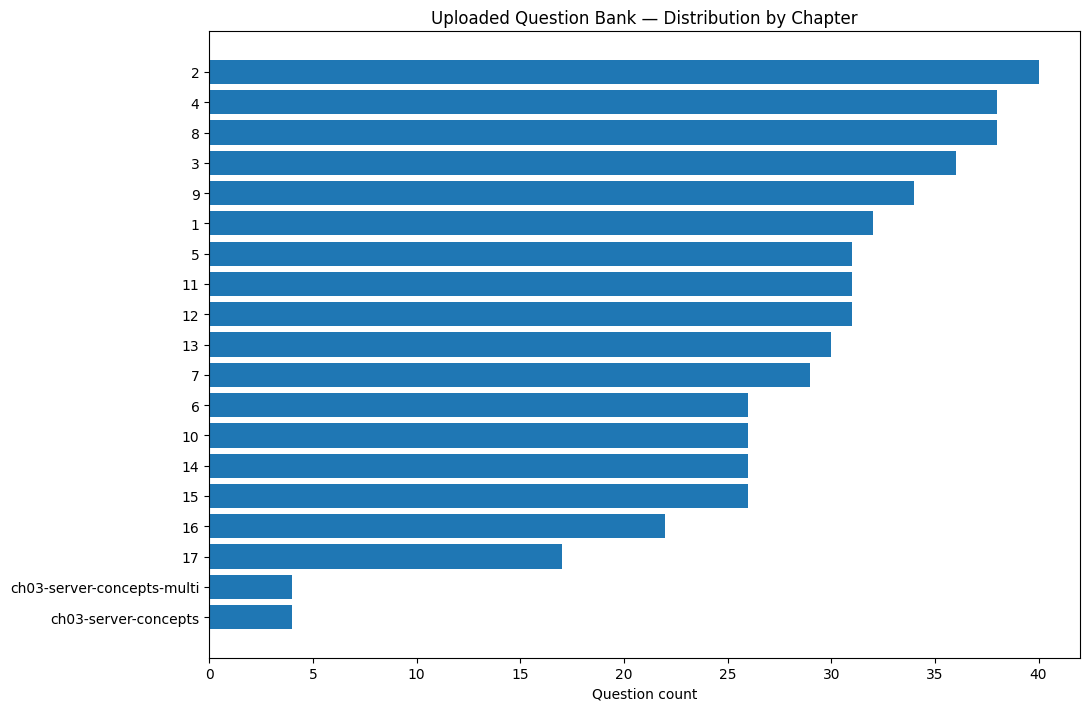

In [29]:
# Visualize question-bank chapter distribution.
import matplotlib.pyplot as plt

items = chapter_counts.most_common()
labels = [x[0] for x in items]
values = [x[1] for x in items]

fig, ax = plt.subplots(figsize=(11, max(5, len(items)*0.38)))
ax.barh(range(len(labels)), values)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Question count")
ax.set_title("Uploaded Question Bank — Distribution by Chapter")
plt.tight_layout()
plt.show()


# Final certification checklist

Before trusting an answer, ask:

- Can I identify the **actor**?
- Can I identify the **layer**?
- Do I know the exact **observable**?
- Is this **2026-07-28** rather than legacy MCP?
- Is the statement **MUST**, **SHOULD**, or merely common SDK behavior?
- Is this core MCP or an **extension**?
- Is a failure transport-level, JSON-RPC-level, MCP semantic, or tool/application-level?
- Is continuation **MRTR**, a **Task**, or ordinary explicit application state?
- Is a security claim based on the resource server, authorization server, gateway, or downstream API?
- Is the answer supported by the **normative specification**, or only by the study bank?

## High-value study loop

**Learn visually → solve without notes → classify the failure/layer → reveal → verify disputed claims → record weak topic → repeat.**


# Official reference set

Primary authority:
- https://modelcontextprotocol.io/specification/2026-07-28
- https://modelcontextprotocol.io/llms.txt

Official supporting material used in the audit:
- https://blog.modelcontextprotocol.io/posts/2026-07-28/
- https://tasks.extensions.modelcontextprotocol.io/specification/draft/tasks
- https://ts.sdk.modelcontextprotocol.io/v2/migration/support-2026-07-28

When exact protocol behavior conflicts with generated study material, prefer the normative 2026-07-28 specification/schema.
